In [12]:
import numpy as np
from pathlib import Path

base_dir = Path("mnist23_1-32")

# 🔑 파일 이름 안 숫자 기준으로 정렬
def npz_index(path: Path):
    # "mnist_1.npz" -> "mnist_1" -> ["mnist", "1"] -> 1
    return int(path.stem.split('_')[1])

npz_files = sorted(base_dir.glob("mnist_*.npz"), key=npz_index)

print("🔍 찾은 npz 파일 수:", len(npz_files))
print()

for path in npz_files:
    data = np.load(path)
    print(f"[{path.name}] keys:", data.files)



🔍 찾은 npz 파일 수: 32

[mnist_1.npz] keys: ['img', 'label']
[mnist_2.npz] keys: ['img', 'label']
[mnist_3.npz] keys: ['img', 'label']
[mnist_4.npz] keys: ['img', 'label']
[mnist_5.npz] keys: ['img', 'label']
[mnist_6.npz] keys: ['img', 'label']
[mnist_7.npz] keys: ['img', 'label']
[mnist_8.npz] keys: ['img', 'label']
[mnist_9.npz] keys: ['img', 'label']
[mnist_10.npz] keys: ['img', 'label']
[mnist_11.npz] keys: ['img', 'label']
[mnist_12.npz] keys: ['img', 'label']
[mnist_13.npz] keys: ['img', 'label']
[mnist_14.npz] keys: ['img', 'label']
[mnist_15.npz] keys: ['img', 'label']
[mnist_16.npz] keys: ['img', 'label']
[mnist_17.npz] keys: ['img', 'label']
[mnist_18.npz] keys: ['img', 'label']
[mnist_19.npz] keys: ['img', 'label']
[mnist_20.npz] keys: ['img', 'label']
[mnist_21.npz] keys: ['img', 'label']
[mnist_22.npz] keys: ['img', 'label']
[mnist_23.npz] keys: ['img', 'label']
[mnist_24.npz] keys: ['img', 'label']
[mnist_25.npz] keys: ['img', 'label']
[mnist_26.npz] keys: ['img', 'label']
[m

찾은 npz 파일 수: 32
 - mnist_1.npz
 - mnist_2.npz
 - mnist_3.npz
 - mnist_4.npz
 - mnist_5.npz
 - mnist_6.npz
 - mnist_7.npz
 - mnist_8.npz
 - mnist_9.npz
 - mnist_10.npz
 - mnist_11.npz
 - mnist_12.npz
 - mnist_13.npz
 - mnist_14.npz
 - mnist_15.npz
 - mnist_16.npz
 - mnist_17.npz
 - mnist_18.npz
 - mnist_19.npz
 - mnist_20.npz
 - mnist_21.npz
 - mnist_22.npz
 - mnist_23.npz
 - mnist_24.npz
 - mnist_25.npz
 - mnist_26.npz
 - mnist_27.npz
 - mnist_28.npz
 - mnist_29.npz
 - mnist_30.npz
 - mnist_31.npz
 - mnist_32.npz

[mnist_1.npz] X shape: (400, 28, 28), y shape: (400,)


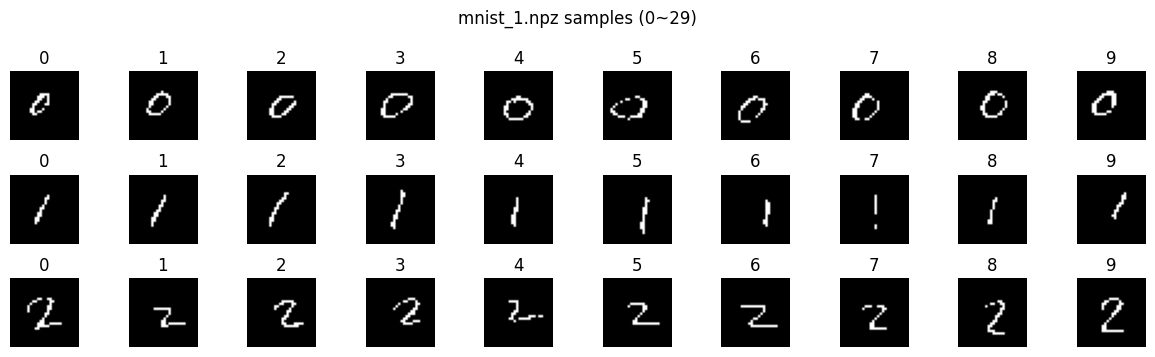

In [13]:
# 파일 이름 안 숫자 기준으로 정렬
def npz_index(path: Path):
    return int(path.stem.split('_')[1])   # "mnist_1" -> 1

npz_files = sorted(base_dir.glob("mnist_*.npz"), key=npz_index)

print("찾은 npz 파일 수:", len(npz_files))
for p in npz_files:
    print(" -", p.name)

def show_npz_samples(file_idx: int, n: int = 20):
    """
    mnist_{file_idx}.npz에서 앞 n개 샘플을 시각화.
    file_idx: 1~32
    """
    path = base_dir / f"mnist_{file_idx}.npz"
    data = np.load(path)
    X = data["img"]      # (N, 28, 28) 또는 (N, 784)
    y = data["label"]

    print(f"\n[{path.name}] X shape: {X.shape}, y shape: {y.shape}")

    # (N,28,28) 또는 (N,784) 둘 다 처리
    if X.ndim == 3:
        imgs = X
    elif X.ndim == 2:
        side = int((X.shape[1]) ** 0.5)
        imgs = X.reshape(-1, side, side)
    else:
        raise ValueError("예상치 못한 X shape:", X.shape)

    n = min(n, len(imgs))
    ncols = 10
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(ncols * 1.2, nrows * 1.2))
    for i in range(n):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(imgs[i], cmap="gray")
        plt.title(str(y[i]))
        plt.axis("off")
    plt.suptitle(f"{path.name} samples (0~{n-1})")
    plt.tight_layout()
    plt.show()

# 예시: mnist_1.npz 앞 30개 보기
show_npz_samples(file_idx=1, n=30)

In [14]:
import numpy as np
from pathlib import Path

base_dir = Path("mnist23_1-32")

def npz_index(path: Path):
    return int(path.stem.split('_')[1])

npz_files = sorted(base_dir.glob("mnist_*.npz"), key=npz_index)

all_imgs = []
all_labels = []

for path in npz_files:
    data = np.load(path)
    X = data["img"]
    y = data["label"]
    print(f"로드: {path.name} -> X {X.shape}, y {y.shape}")
    all_imgs.append(X)
    all_labels.append(y)

X_merged = np.concatenate(all_imgs, axis=0)
y_merged = np.concatenate(all_labels, axis=0)

print("\n=== 최종 합친 결과 ===")
print("X_merged shape:", X_merged.shape)
print("y_merged shape:", y_merged.shape)

out_name = "handmade_extra_mnist_1to32.npz"
np.savez_compressed(out_name, img=X_merged, label=y_merged)
print(f"\n✅ 저장 완료: {out_name}")


로드: mnist_1.npz -> X (400, 28, 28), y (400,)
로드: mnist_2.npz -> X (100, 28, 28), y (100,)
로드: mnist_3.npz -> X (100, 28, 28), y (100,)
로드: mnist_4.npz -> X (100, 28, 28), y (100,)
로드: mnist_5.npz -> X (400, 28, 28), y (400,)
로드: mnist_6.npz -> X (400, 28, 28), y (400,)
로드: mnist_7.npz -> X (400, 28, 28), y (400,)
로드: mnist_8.npz -> X (400, 28, 28), y (400,)
로드: mnist_9.npz -> X (400, 28, 28), y (400,)
로드: mnist_10.npz -> X (400, 28, 28), y (400,)
로드: mnist_11.npz -> X (400, 28, 28), y (400,)
로드: mnist_12.npz -> X (400, 28, 28), y (400,)
로드: mnist_13.npz -> X (400, 28, 28), y (400,)
로드: mnist_14.npz -> X (400, 28, 28), y (400,)
로드: mnist_15.npz -> X (400, 28, 28), y (400,)
로드: mnist_16.npz -> X (400, 28, 28), y (400,)
로드: mnist_17.npz -> X (400, 28, 28), y (400,)
로드: mnist_18.npz -> X (100, 28, 28), y (100,)
로드: mnist_19.npz -> X (100, 28, 28), y (100,)
로드: mnist_20.npz -> X (100, 28, 28), y (100,)
로드: mnist_21.npz -> X (100, 28, 28), y (100,)
로드: mnist_22.npz -> X (400, 28, 28), y (400

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# 👉 너가 합친 최종 파일명
data = np.load("handmade_extra_mnist_1to32.npz")

X = data["img"]      # shape: (N, 28, 28) 또는 (N,784)
y = data["label"]    # shape: (N,)

print("총 이미지 개수:", X.shape[0])

# reshape 처리 (혹시 784인지 확인)
if X.ndim == 2:
    side = int((X.shape[1]) ** 0.5)
    X = X.reshape(-1, side, side)

num_samples = len(X)
batch_size = 100
num_batches = math.ceil(num_samples / batch_size)

save_dir = "handmade_extra_visualized"
os.makedirs(save_dir, exist_ok=True)

print(f"총 {num_samples}개 → {num_batches}개 PNG로 저장됩니다.")
print("저장 폴더:", save_dir)

for b in range(num_batches):
    start = b * batch_size
    end = min((b + 1) * batch_size, num_samples)
    batch_X = X[start:end]
    batch_y = y[start:end]

    n = len(batch_X)
    ncols = 10
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=(ncols * 1.2, nrows * 1.2))
    for i in range(n):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(batch_X[i], cmap="gray")
        plt.title(str(batch_y[i]))
        plt.axis("off")
    plt.tight_layout()

    filename = f"{save_dir}/samples_{start:05d}_{end-1:05d}.png"
    plt.savefig(filename, dpi=150)
    plt.close()

    print("저장됨:", filename)

print("\n🎉 모든 이미지 저장 완료!")


총 이미지 개수: 9500
총 9500개 → 95개 PNG로 저장됩니다.
저장 폴더: handmade_extra_visualized
저장됨: handmade_extra_visualized/samples_00000_00099.png
저장됨: handmade_extra_visualized/samples_00100_00199.png
저장됨: handmade_extra_visualized/samples_00200_00299.png
저장됨: handmade_extra_visualized/samples_00300_00399.png
저장됨: handmade_extra_visualized/samples_00400_00499.png
저장됨: handmade_extra_visualized/samples_00500_00599.png
저장됨: handmade_extra_visualized/samples_00600_00699.png
저장됨: handmade_extra_visualized/samples_00700_00799.png
저장됨: handmade_extra_visualized/samples_00800_00899.png
저장됨: handmade_extra_visualized/samples_00900_00999.png
저장됨: handmade_extra_visualized/samples_01000_01099.png
저장됨: handmade_extra_visualized/samples_01100_01199.png
저장됨: handmade_extra_visualized/samples_01200_01299.png
저장됨: handmade_extra_visualized/samples_01300_01399.png
저장됨: handmade_extra_visualized/samples_01400_01499.png
저장됨: handmade_extra_visualized/samples_01500_01599.png
저장됨: handmade_extra_visualized/samples_01600_0

In [16]:
import numpy as np

data = np.load("handmade_extra_mnist_1to32.npz")
X = data["img"]

# 혹시 (N,784)일 경우 reshape
if X.ndim == 2:
    side = int((X.shape[1])**0.5)
    X = X.reshape(-1, side, side)

count_01 = 0
count_255 = 0

for i in range(len(X)):
    max_val = X[i].max()
    if max_val <= 1.0:
        count_01 += 1
    else:
        count_255 += 1

print("총 이미지 수:", len(X))
print("0~1 스케일 이미지 수:", count_01)
print("0~255 스케일 이미지 수:", count_255)


총 이미지 수: 9500
0~1 스케일 이미지 수: 9500
0~255 스케일 이미지 수: 0


In [13]:
file_path = "npz모음/handmade_extra_mnist_1to32.npz"
data = np.load(file_path)

print("파일 키 목록:", list(data.keys()))

# 🔹 2) img / label 불러오기
images = data["img"]        # (N, 28, 28)
labels = data["label"]      # (N,)

images = np.array(images)
labels = np.array(labels)

unique_types = {type(v) for v in labels}
print("label types :", unique_types)

파일 키 목록: ['img', 'label']
label types : {<class 'numpy.str_'>}


총 이미지 개수: 9500
총 페이지 수: 95

===== 페이지 1 / 95 | 이미지 0 ~ 99 =====


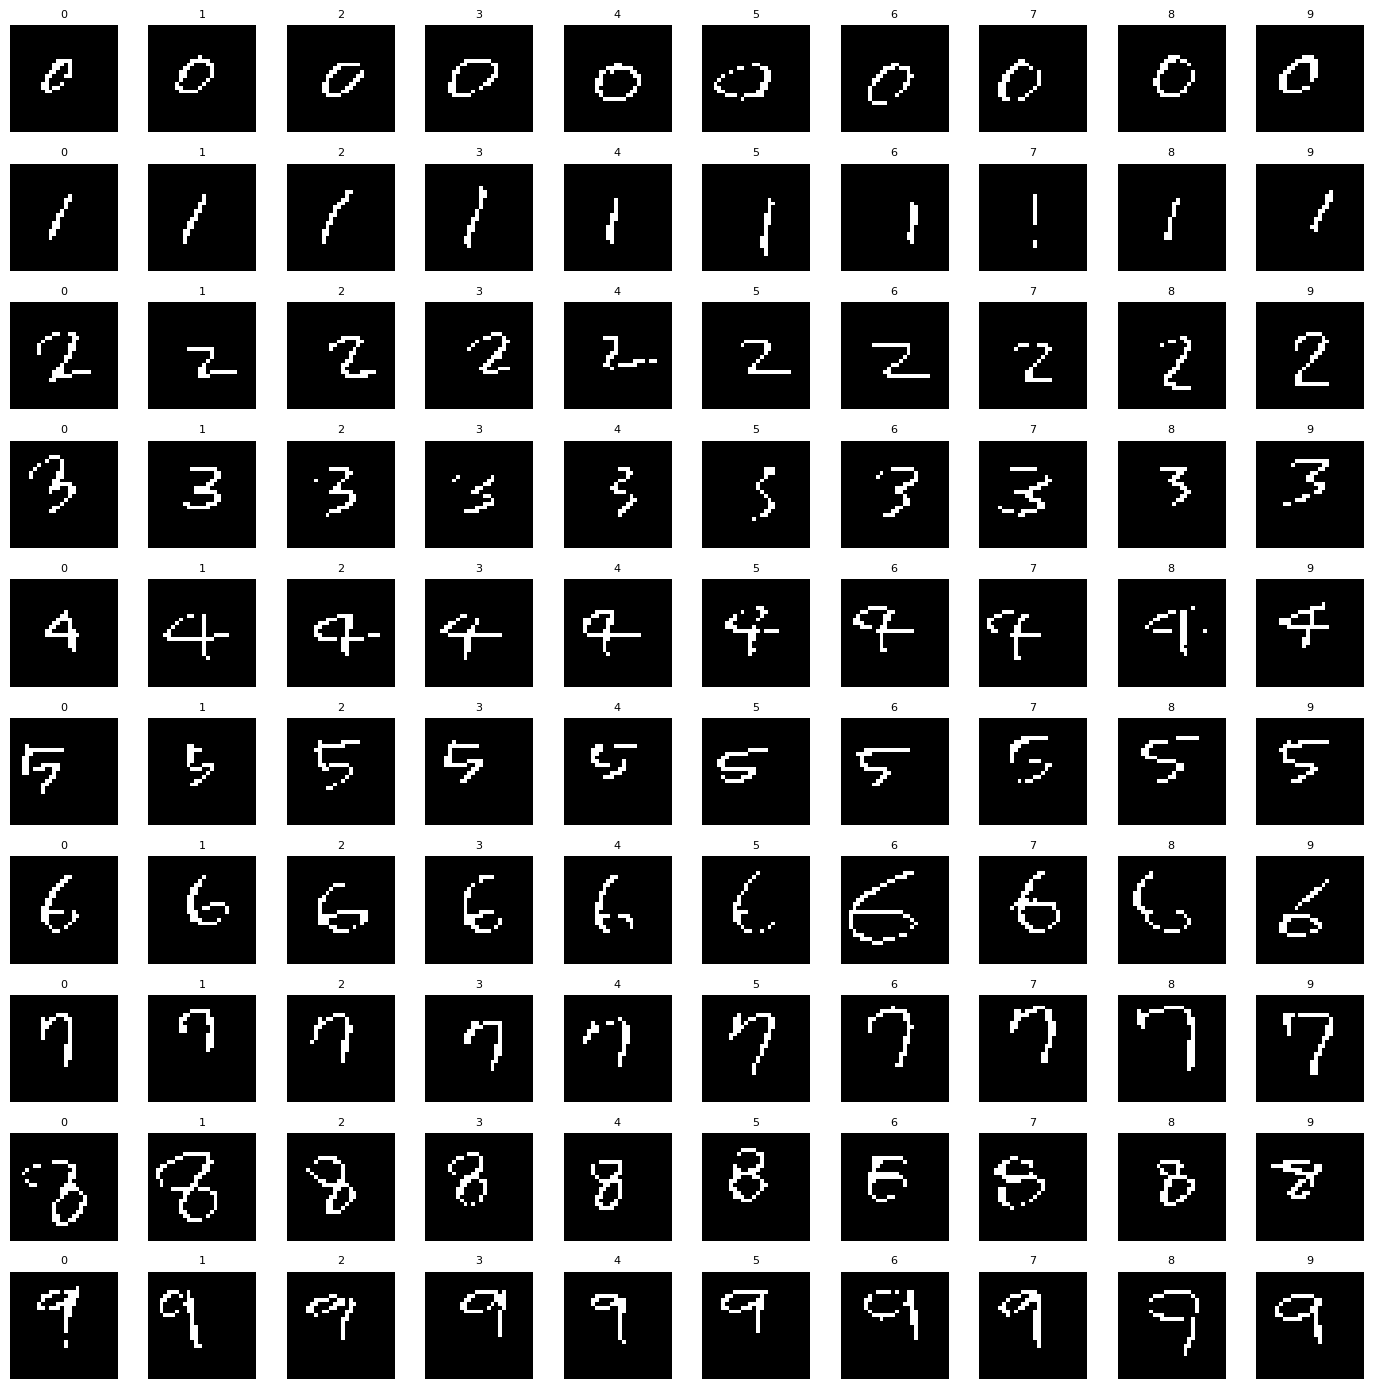


===== 페이지 2 / 95 | 이미지 100 ~ 199 =====


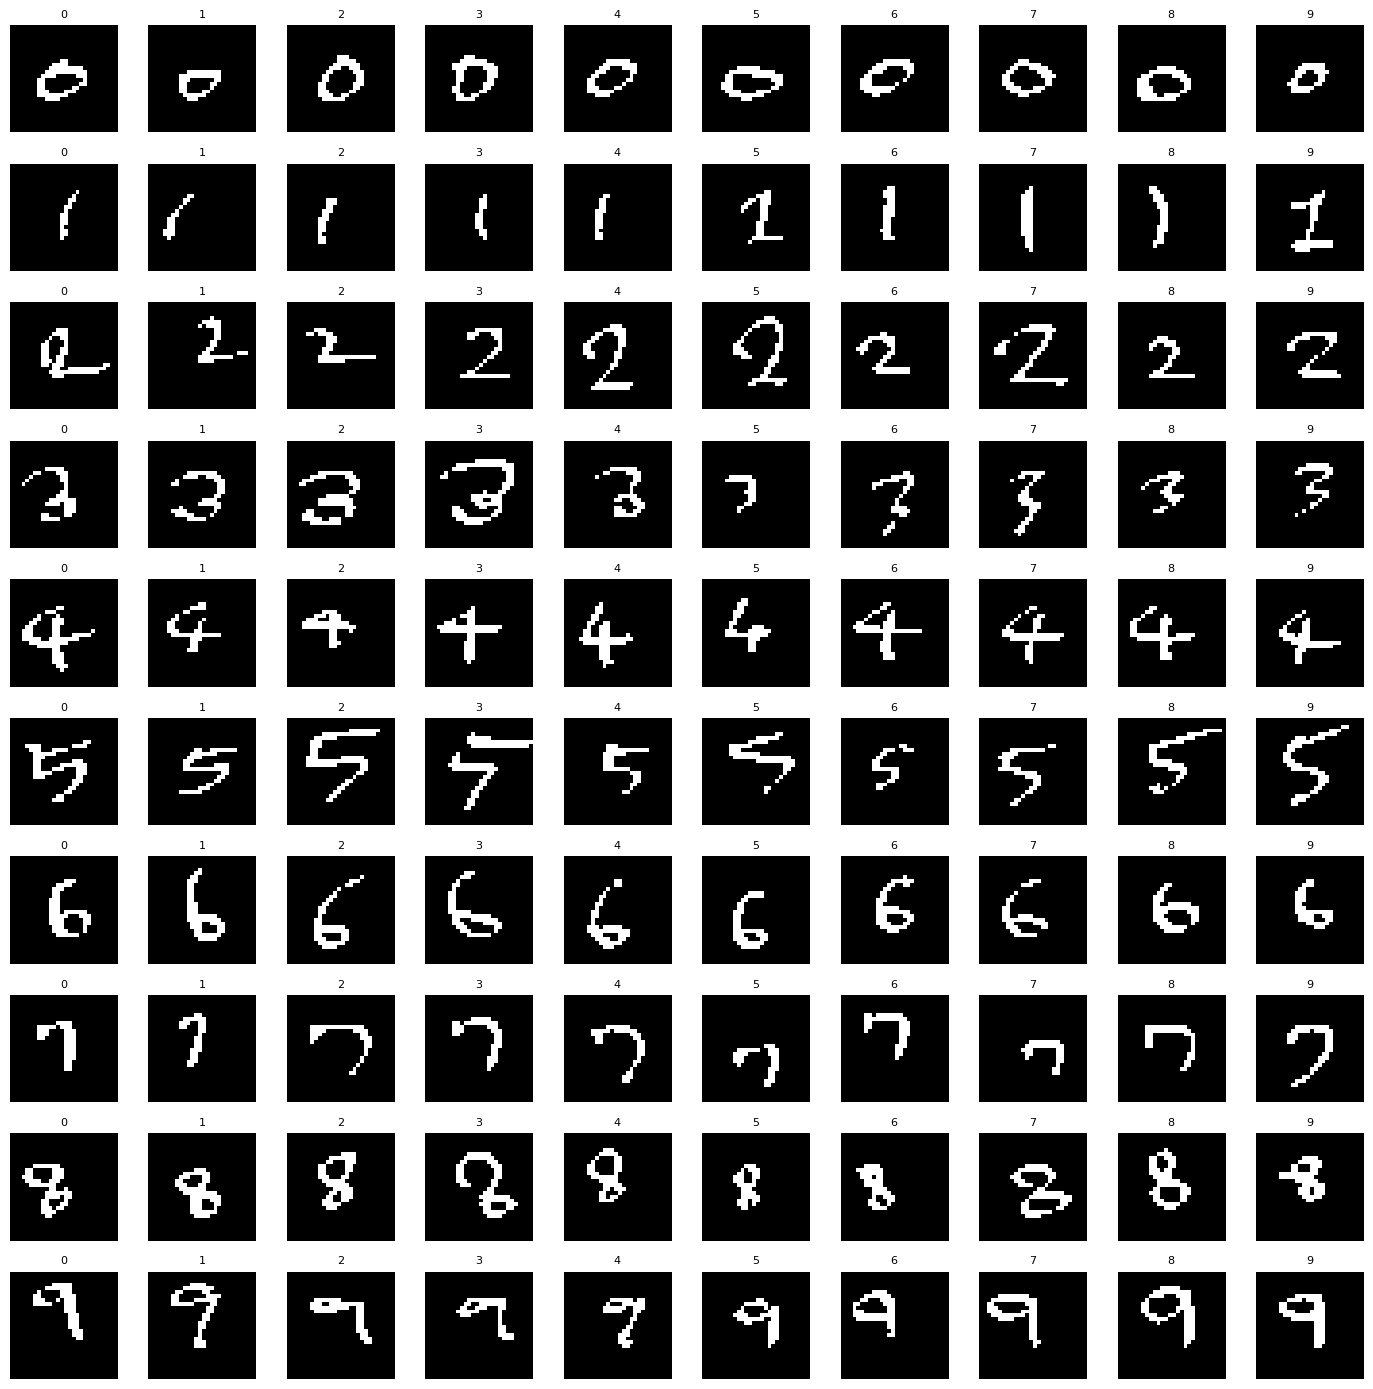


===== 페이지 3 / 95 | 이미지 200 ~ 299 =====


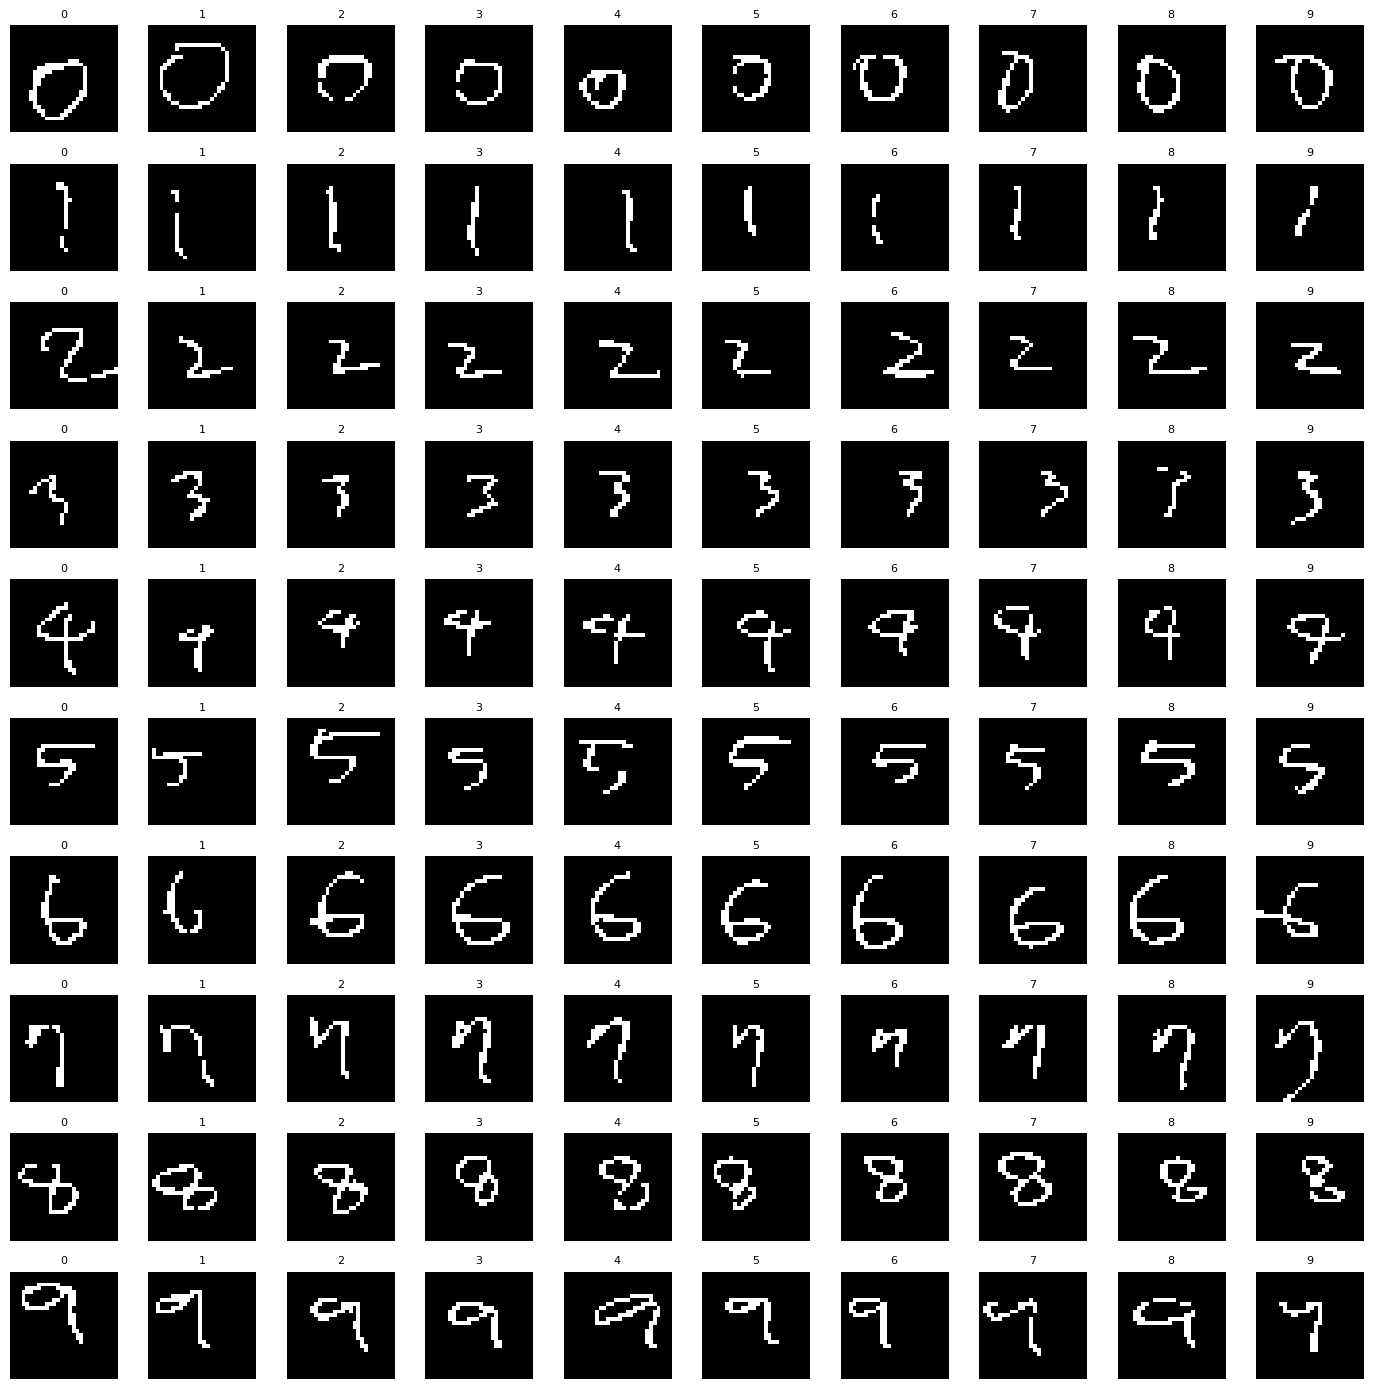


===== 페이지 4 / 95 | 이미지 300 ~ 399 =====


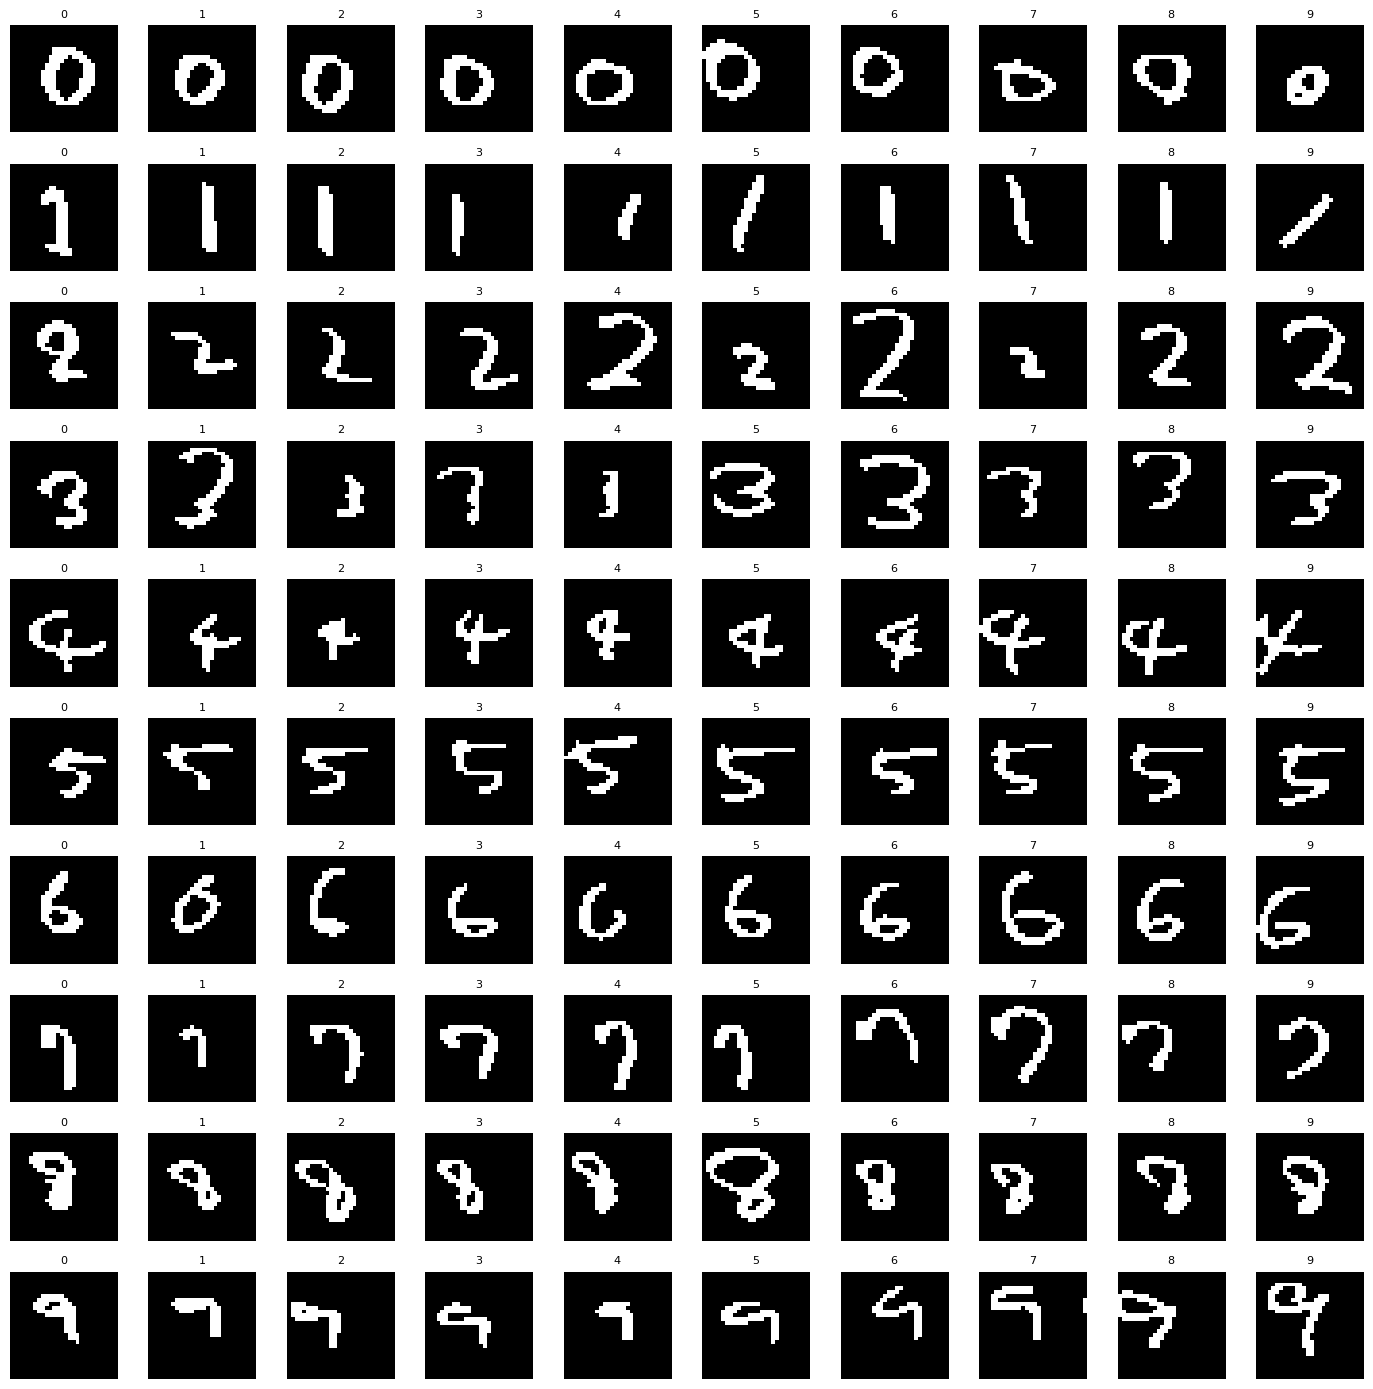


===== 페이지 5 / 95 | 이미지 400 ~ 499 =====


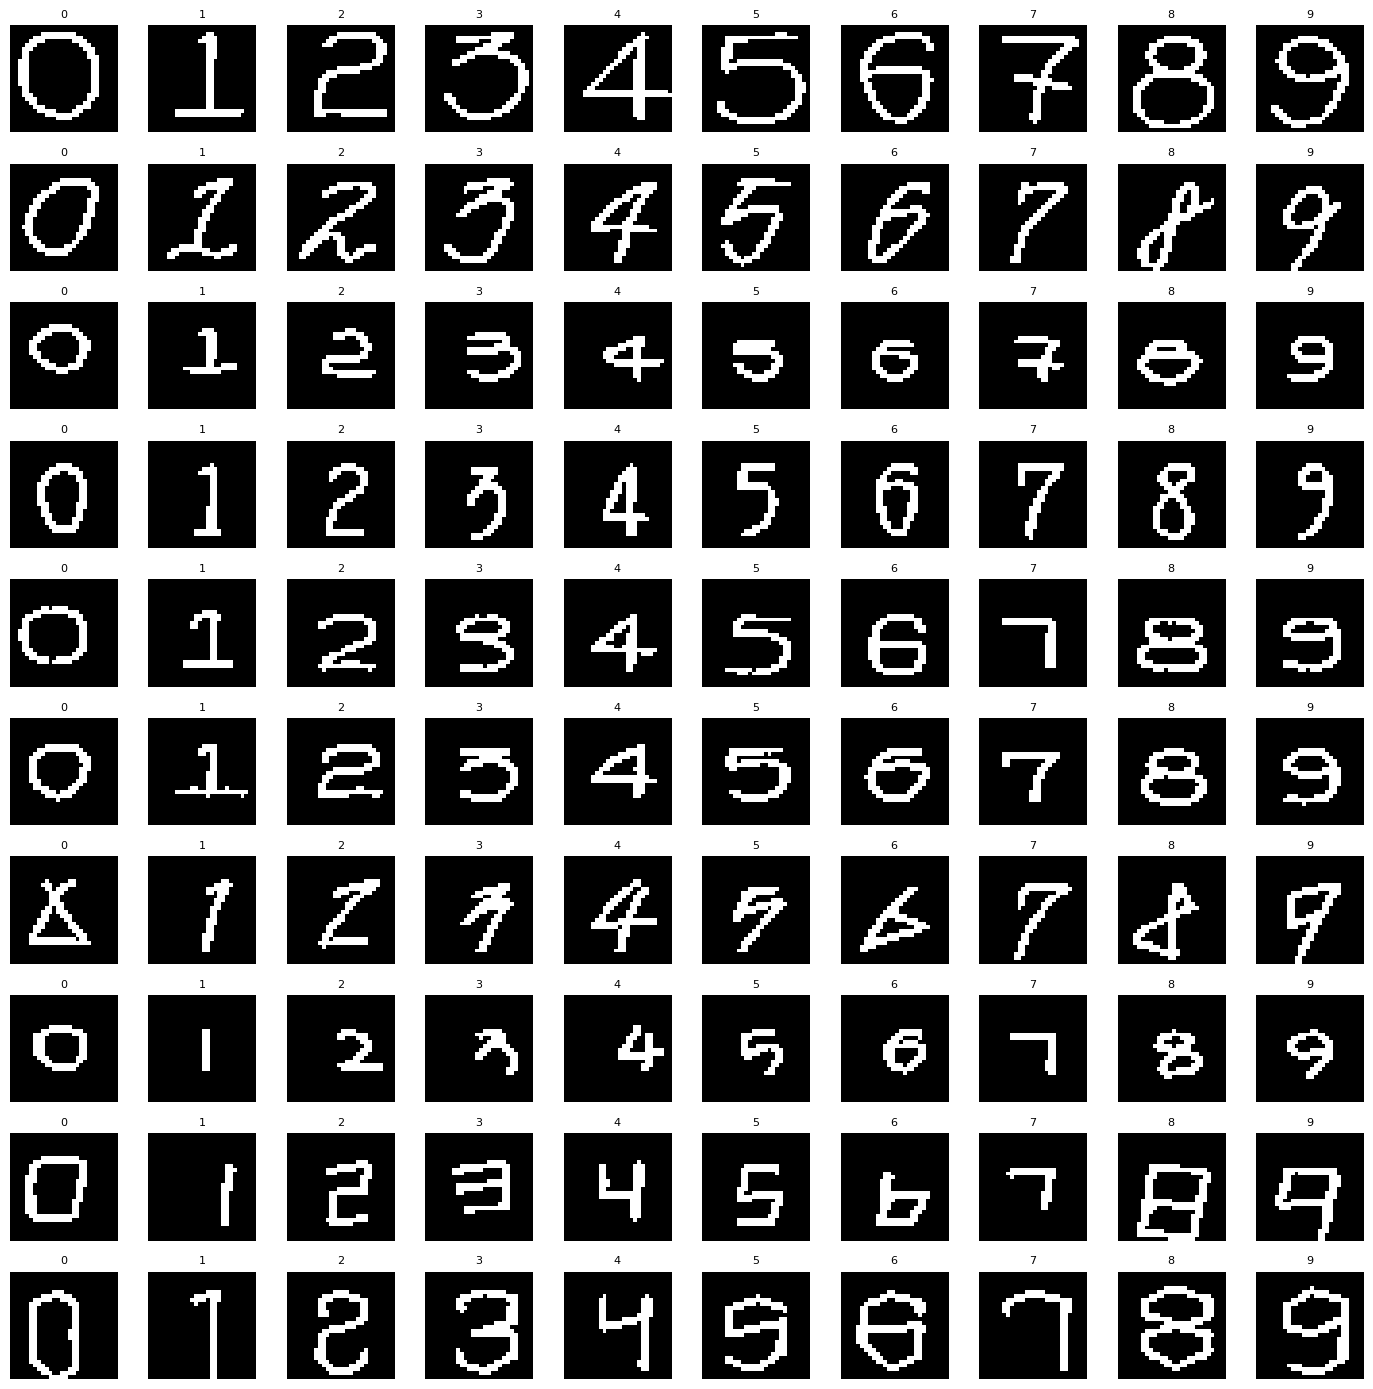


===== 페이지 6 / 95 | 이미지 500 ~ 599 =====


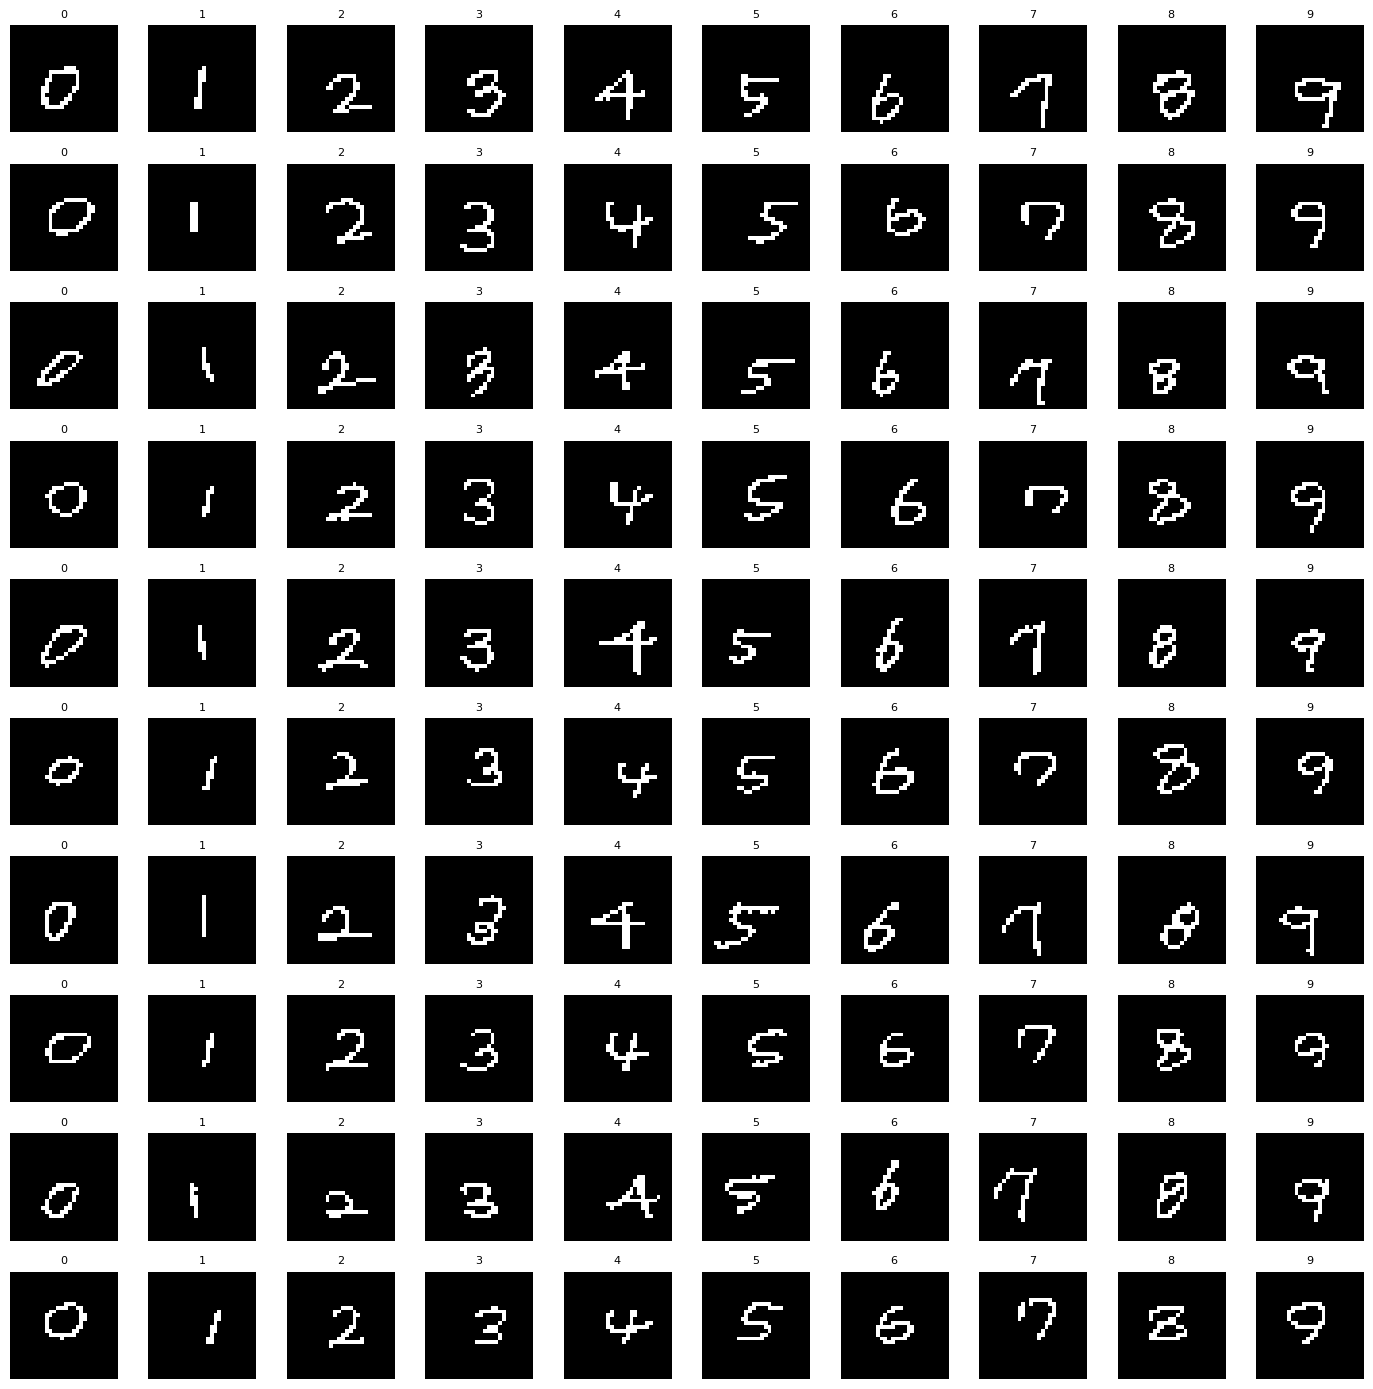


===== 페이지 7 / 95 | 이미지 600 ~ 699 =====


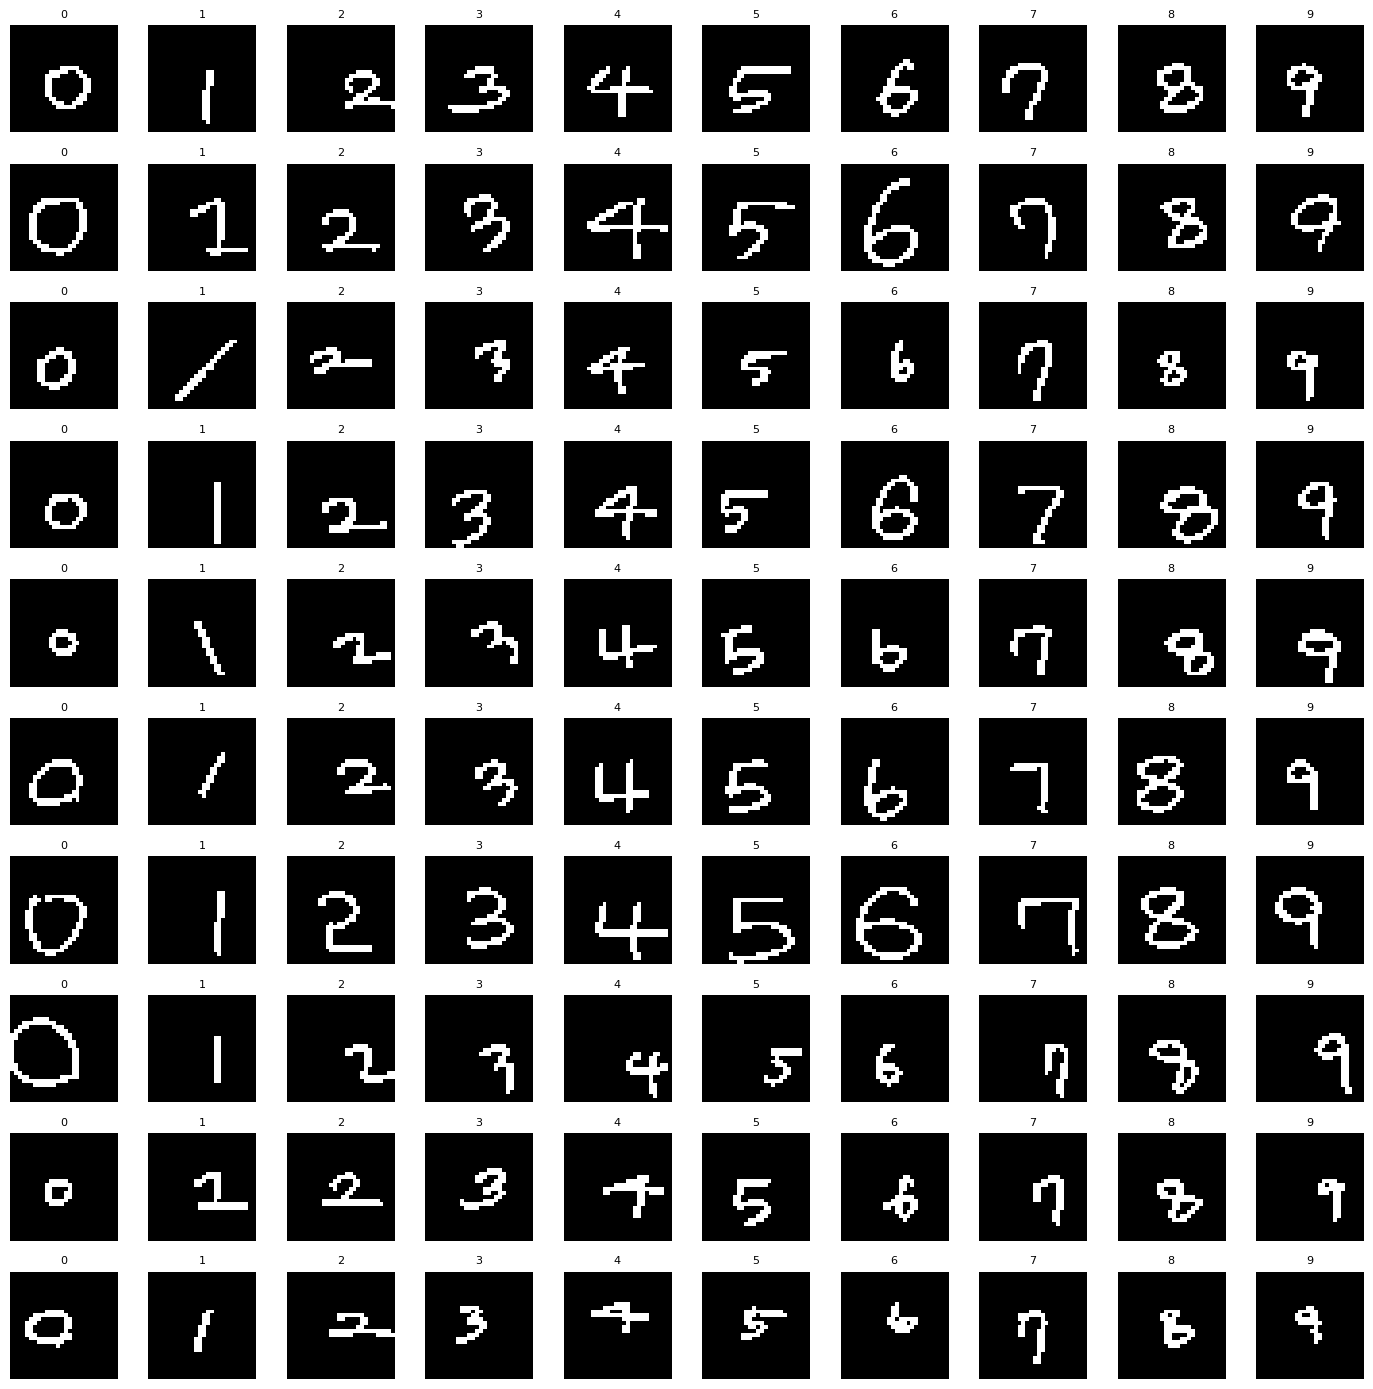


===== 페이지 8 / 95 | 이미지 700 ~ 799 =====


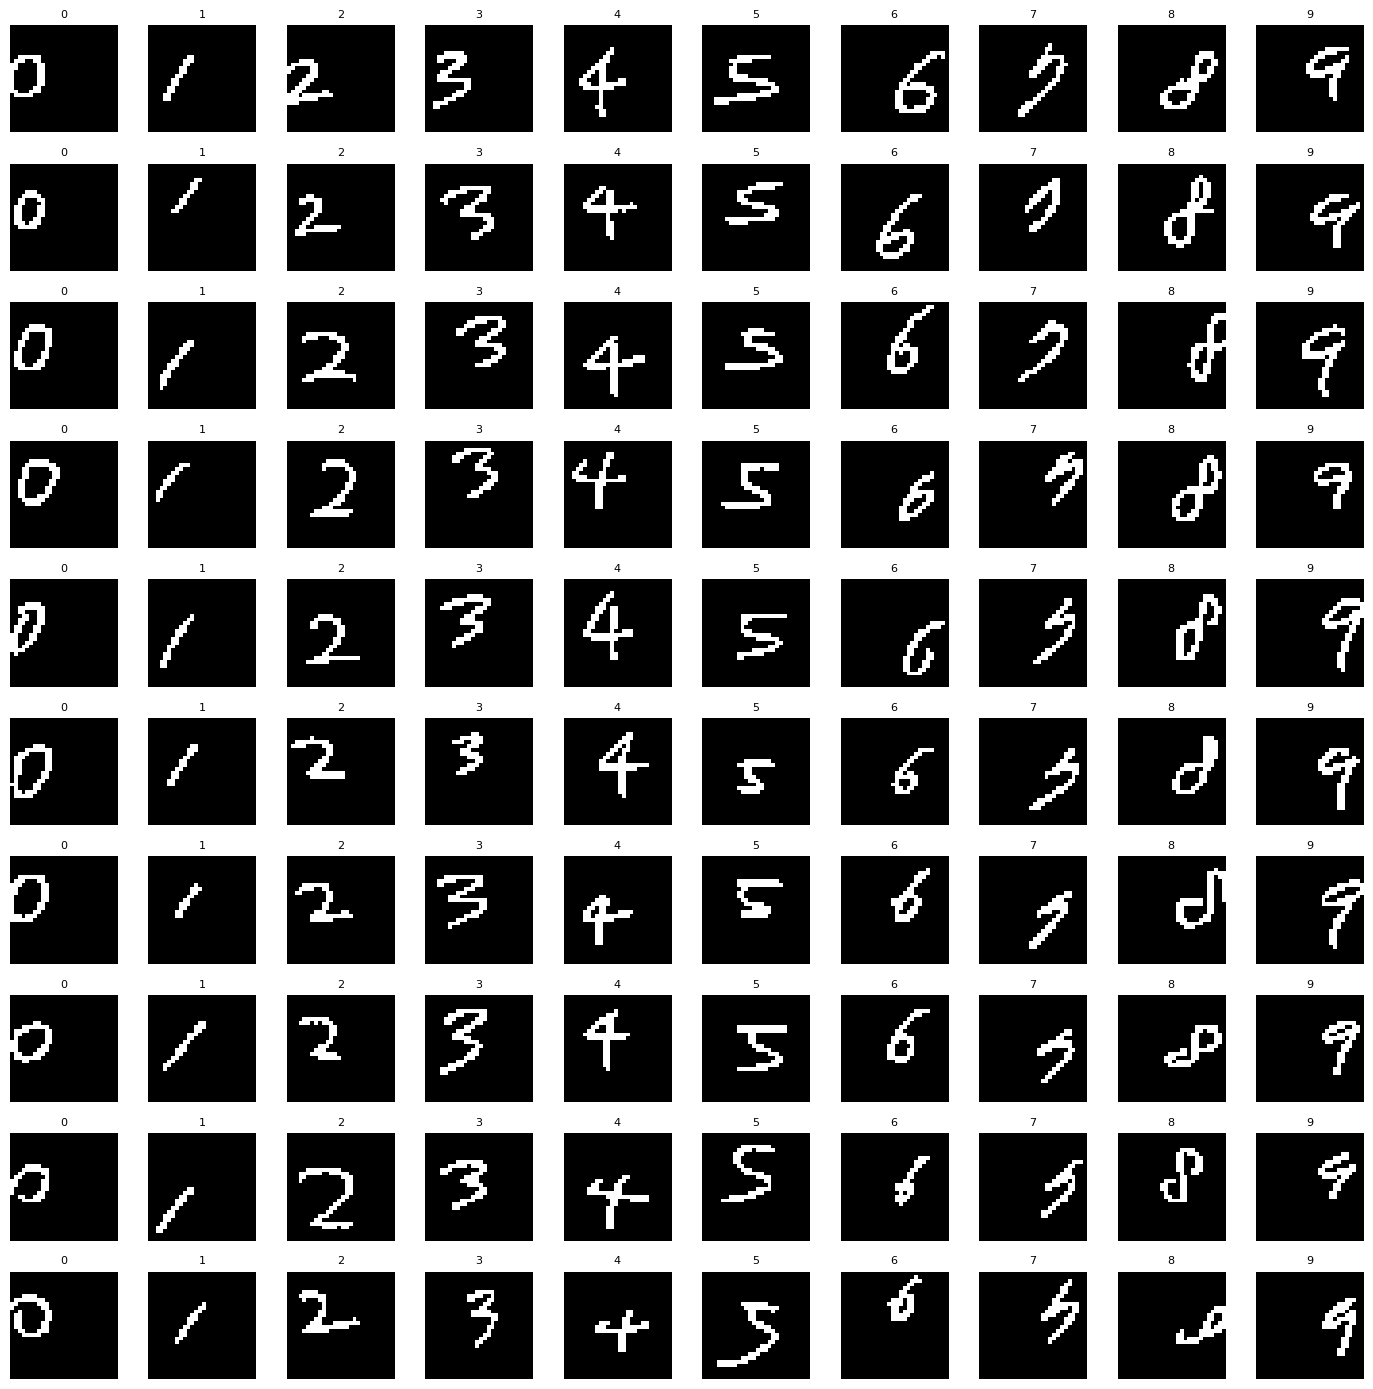


===== 페이지 9 / 95 | 이미지 800 ~ 899 =====


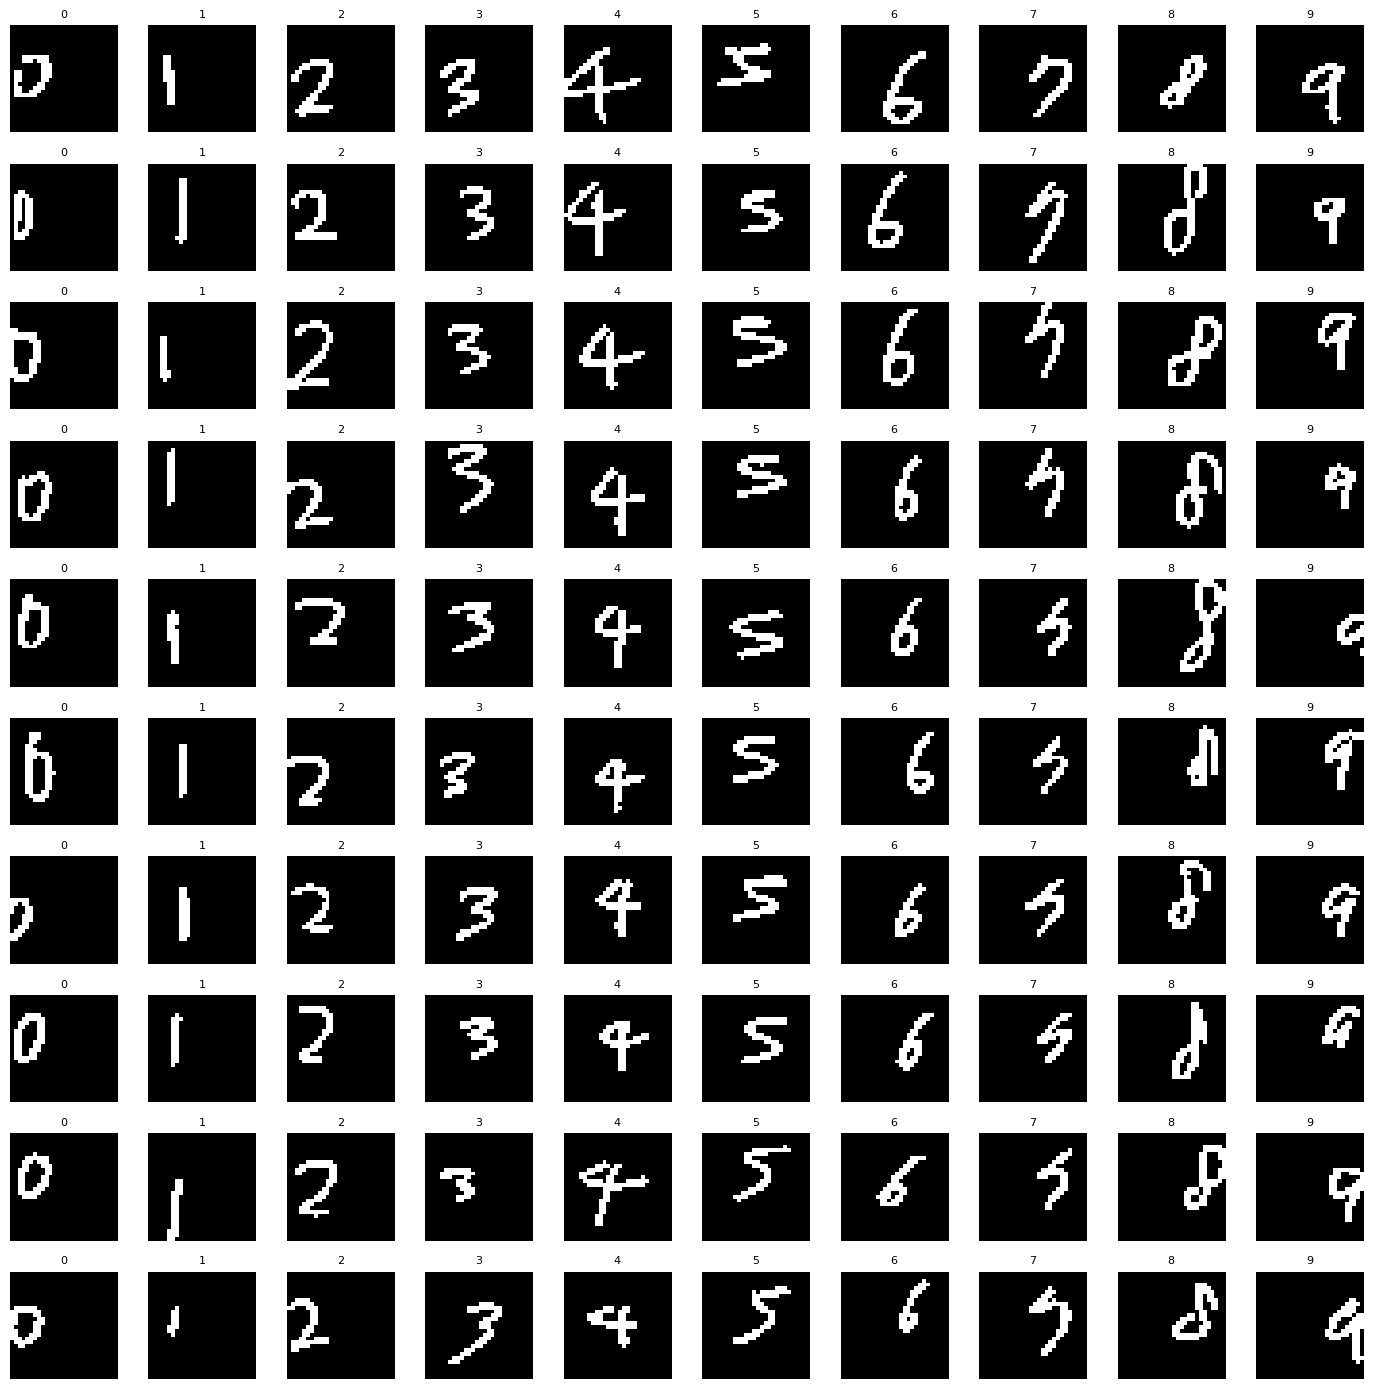


===== 페이지 10 / 95 | 이미지 900 ~ 999 =====


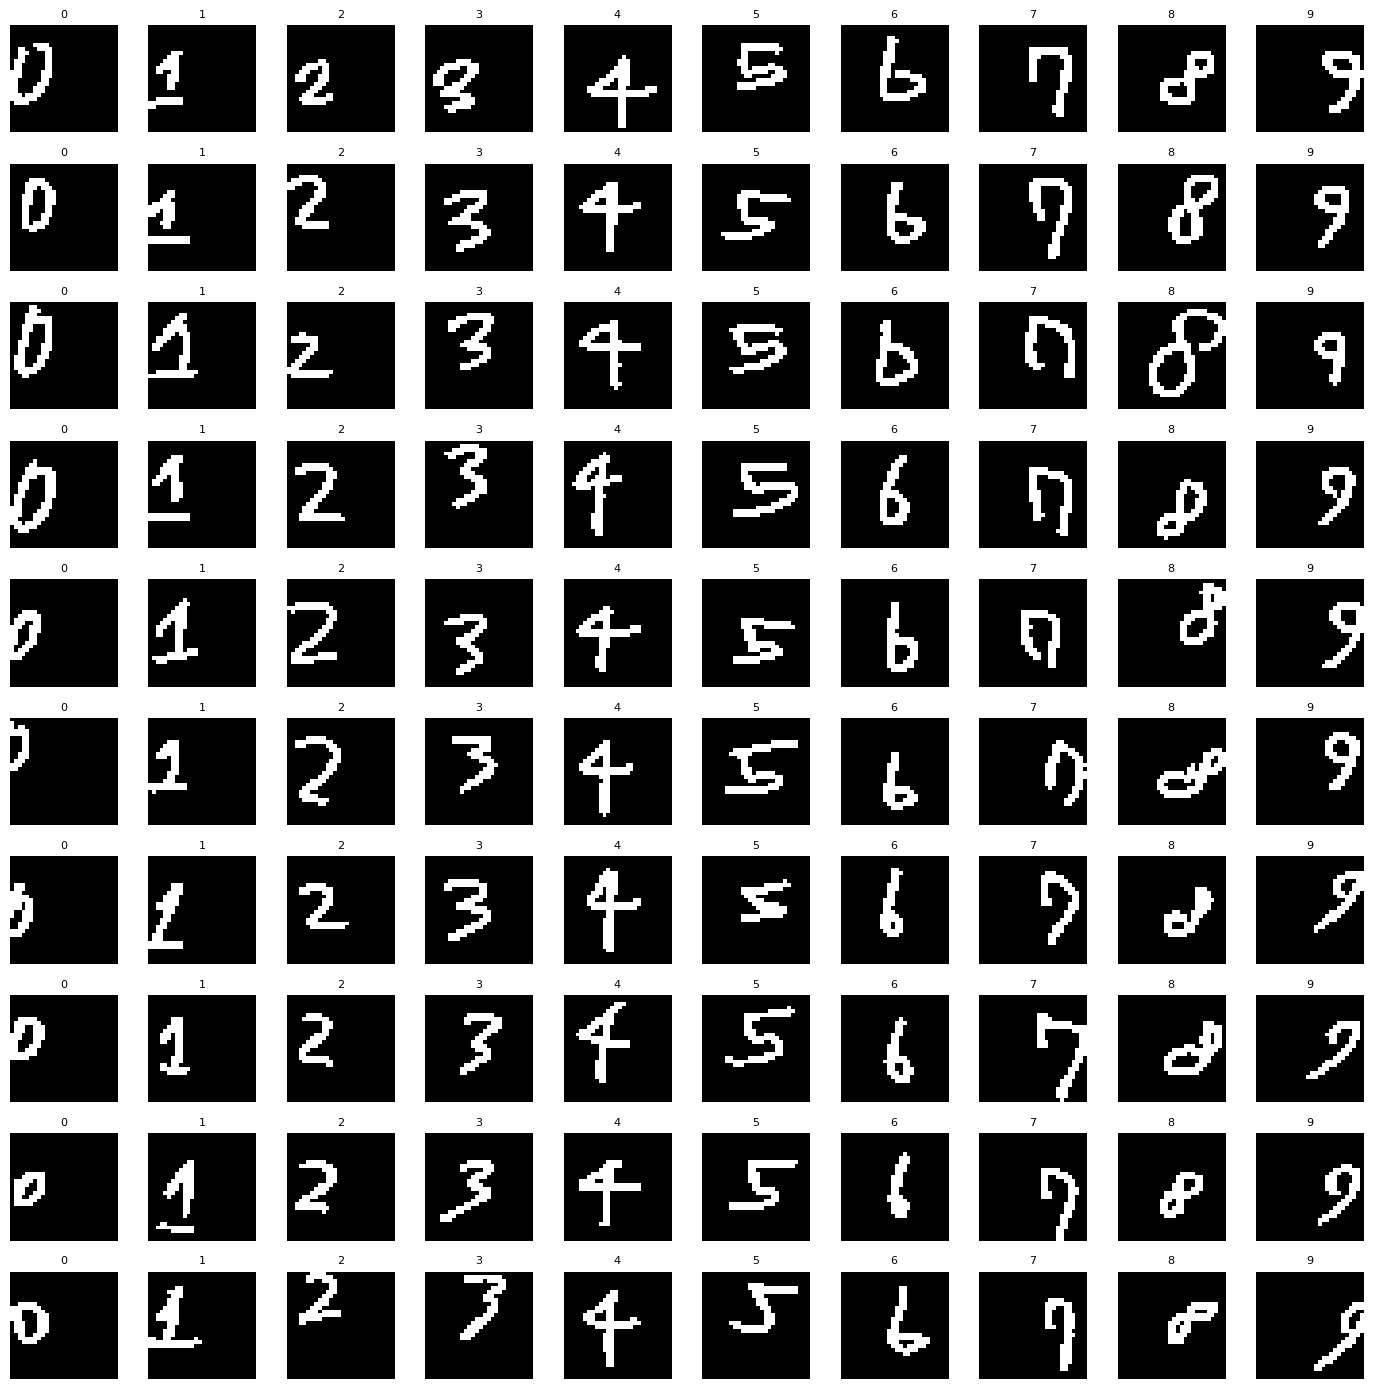


===== 페이지 11 / 95 | 이미지 1000 ~ 1099 =====


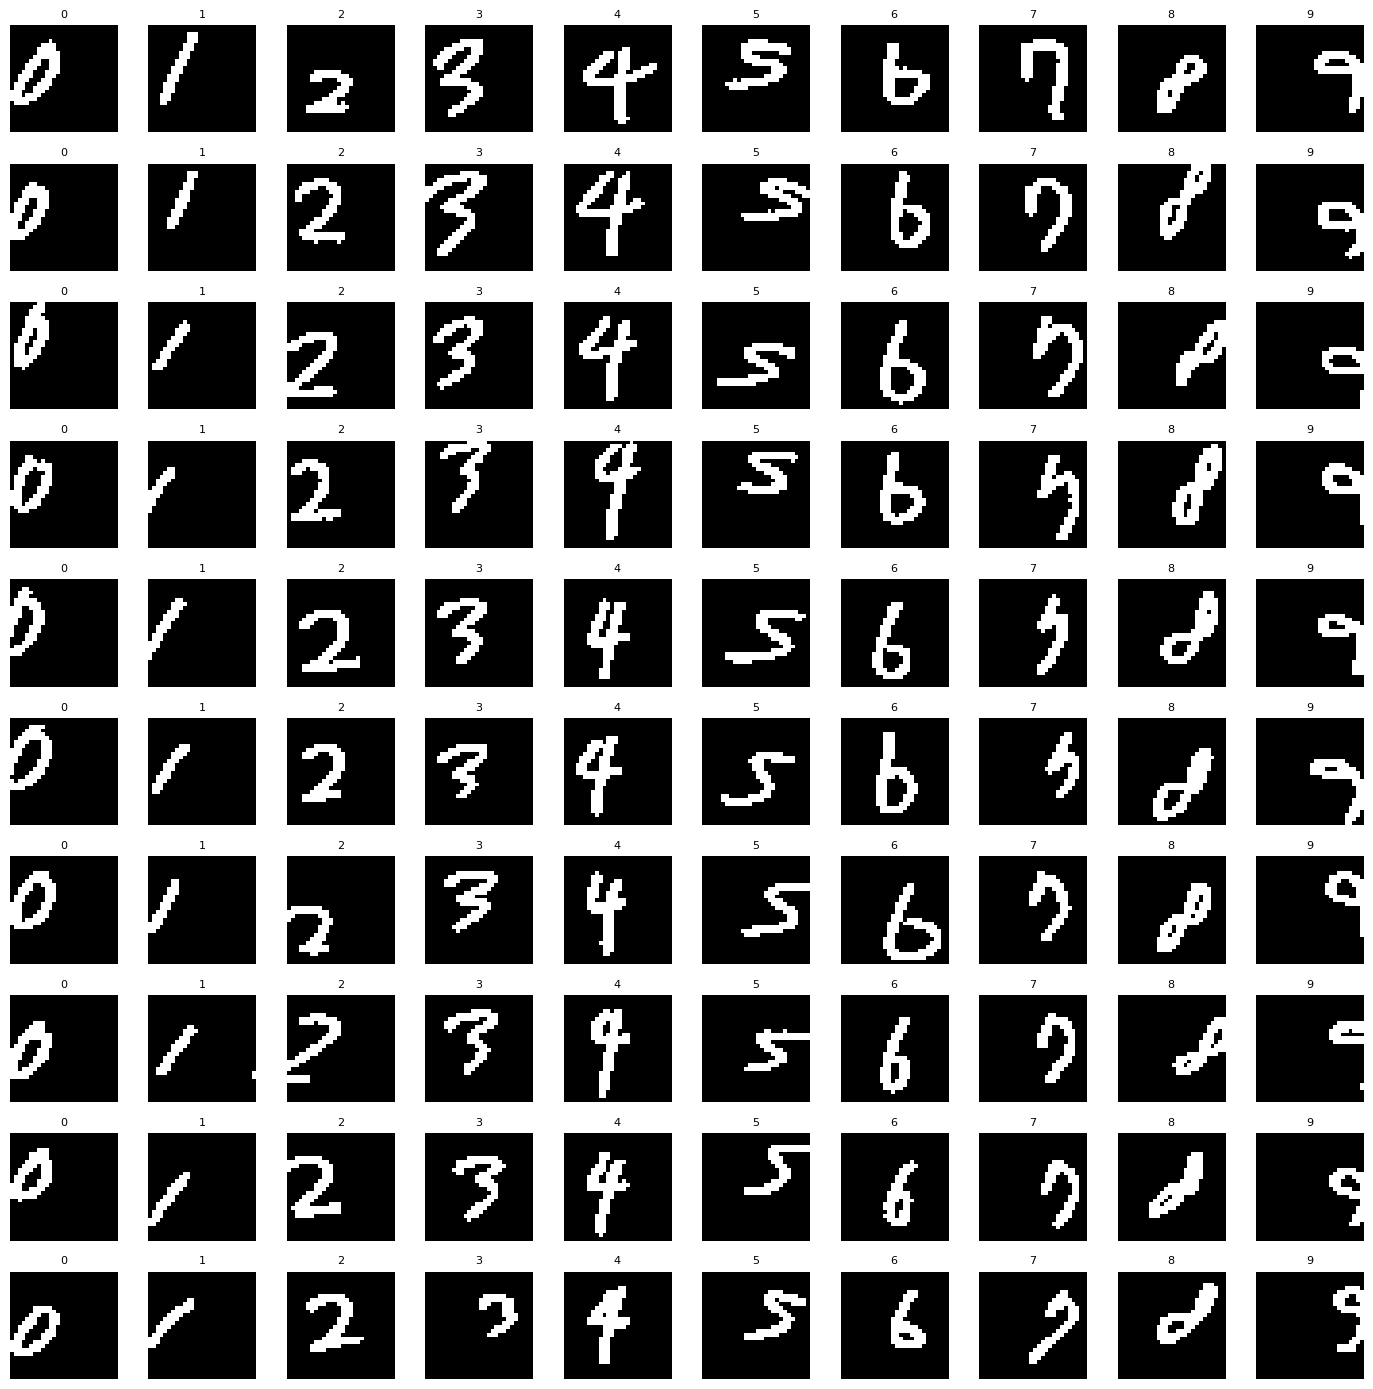


===== 페이지 12 / 95 | 이미지 1100 ~ 1199 =====


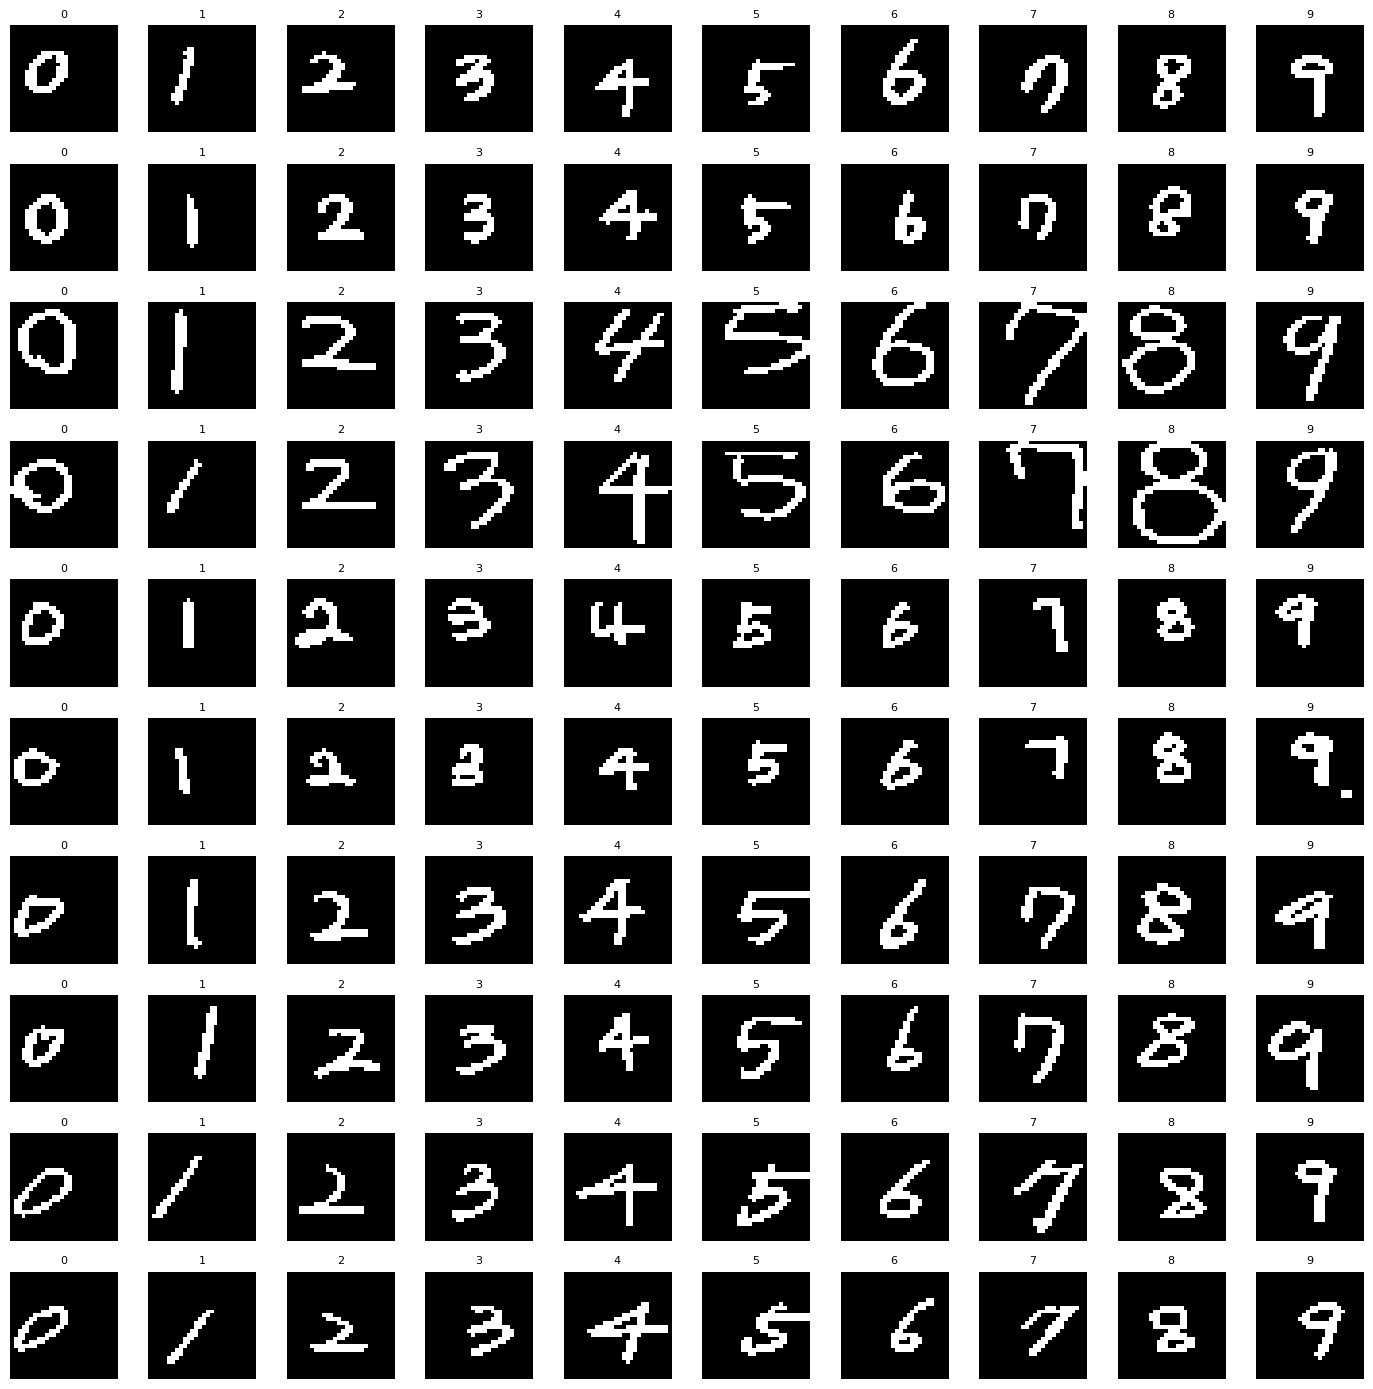


===== 페이지 13 / 95 | 이미지 1200 ~ 1299 =====


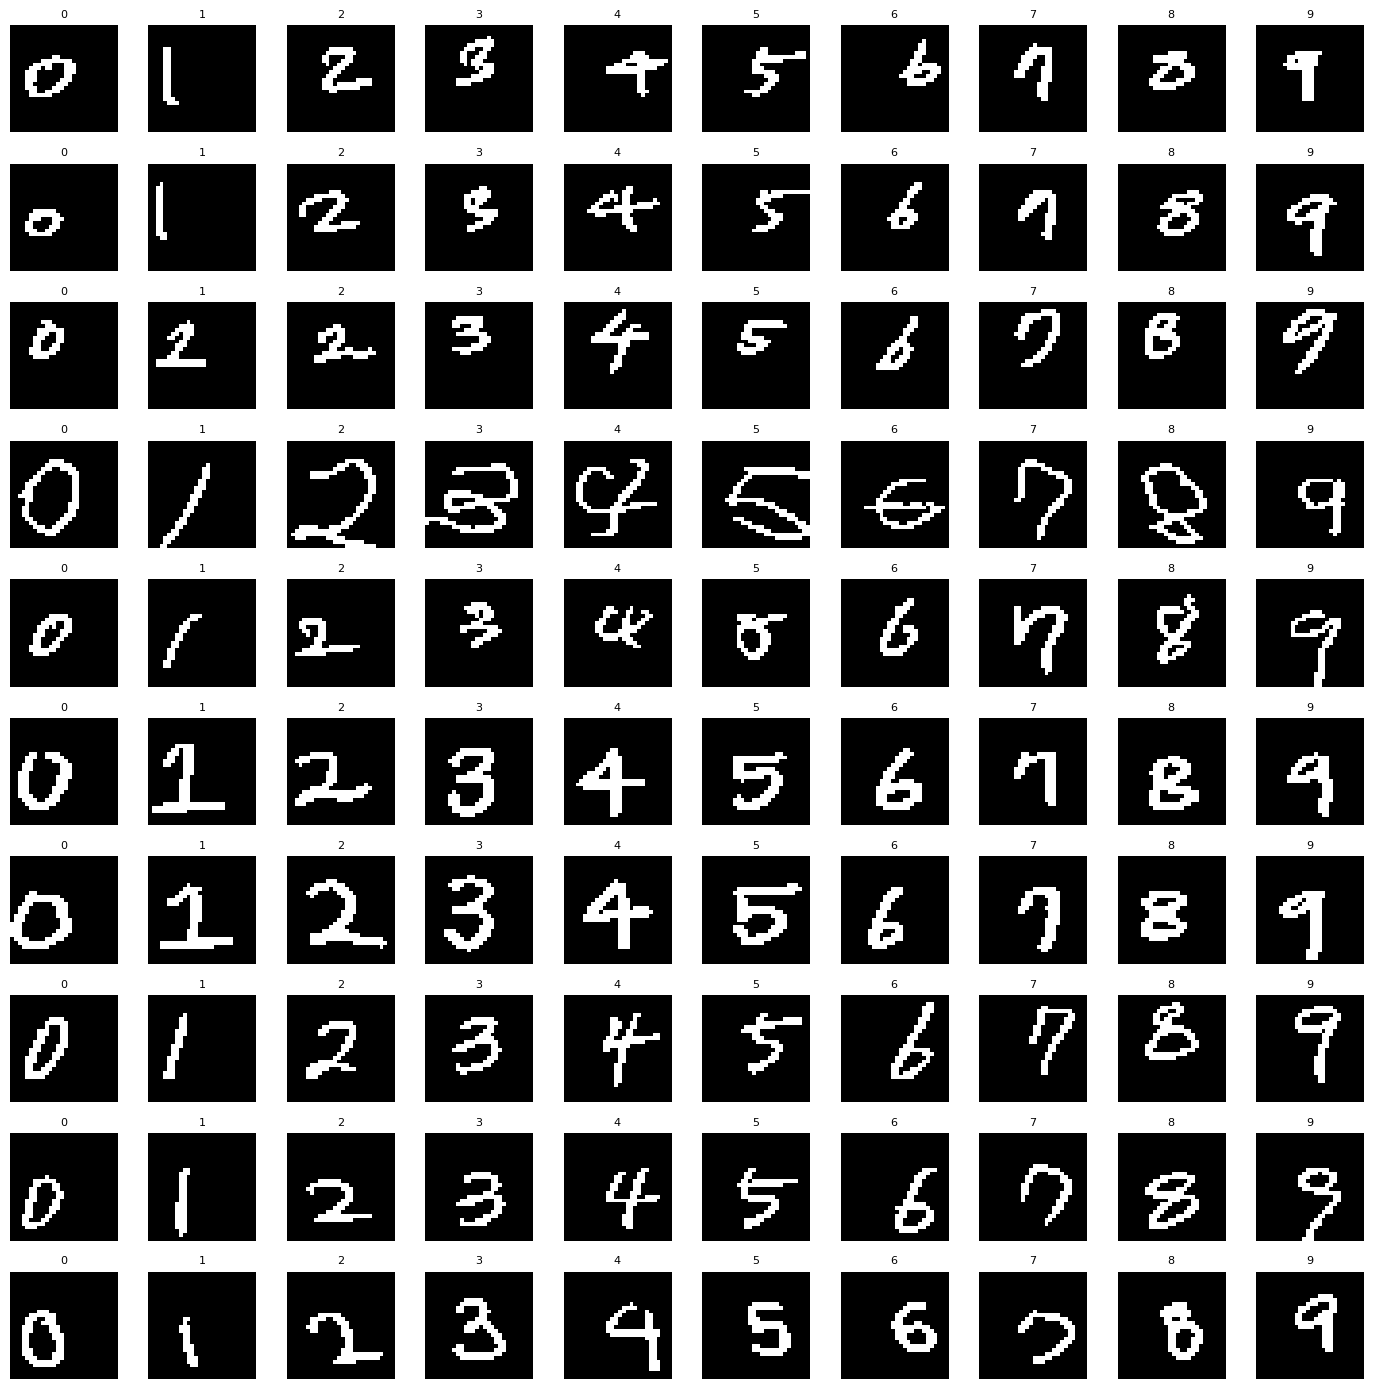


===== 페이지 14 / 95 | 이미지 1300 ~ 1399 =====


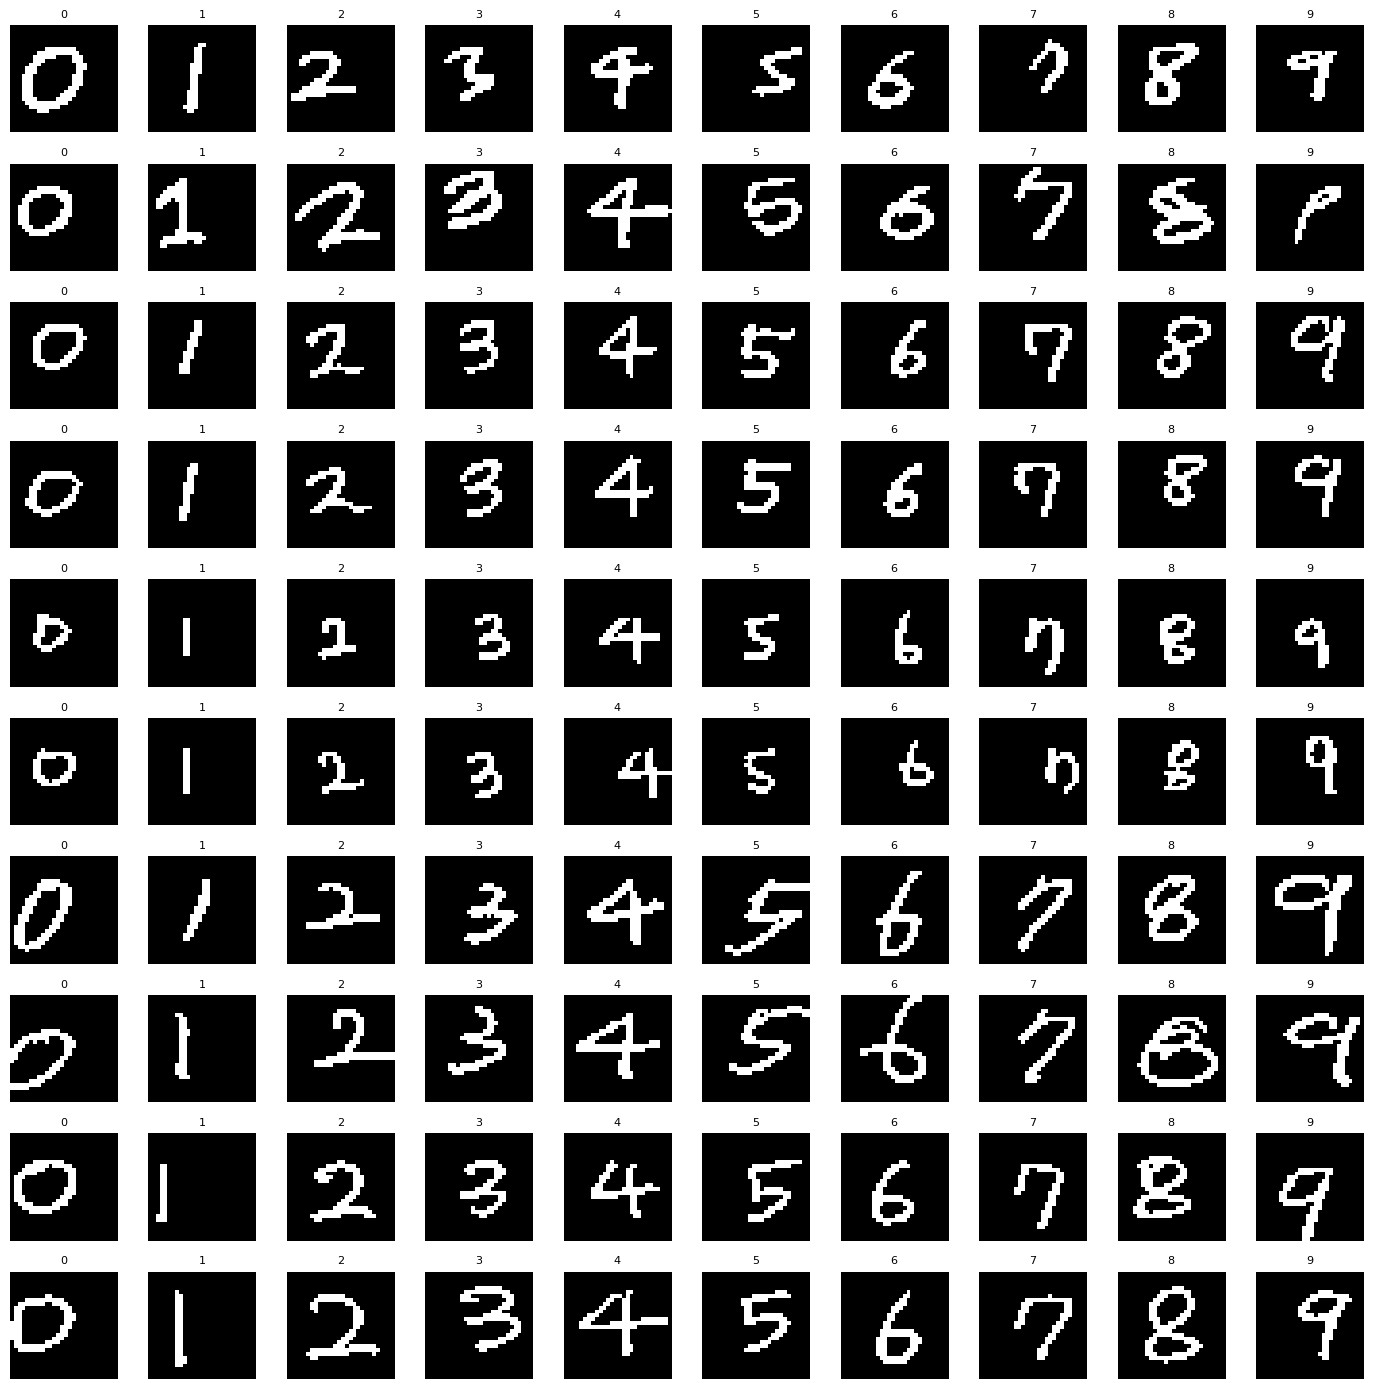


===== 페이지 15 / 95 | 이미지 1400 ~ 1499 =====


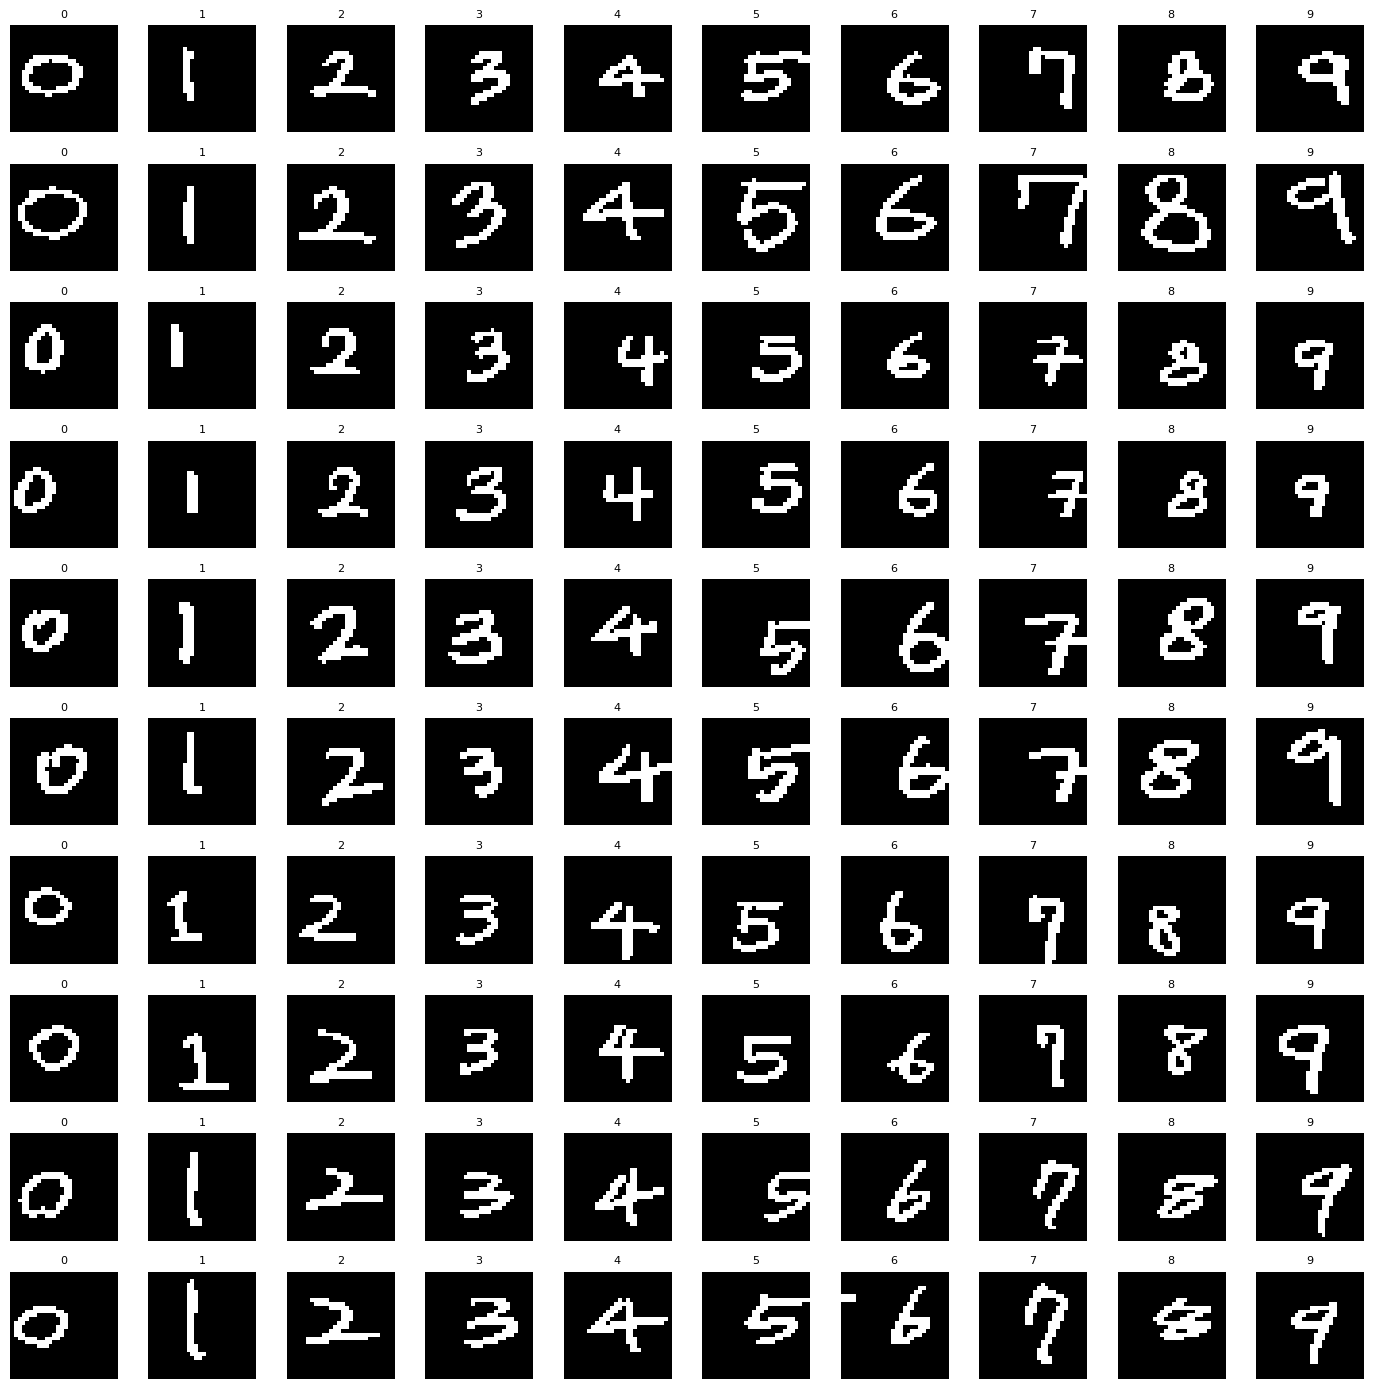


===== 페이지 16 / 95 | 이미지 1500 ~ 1599 =====


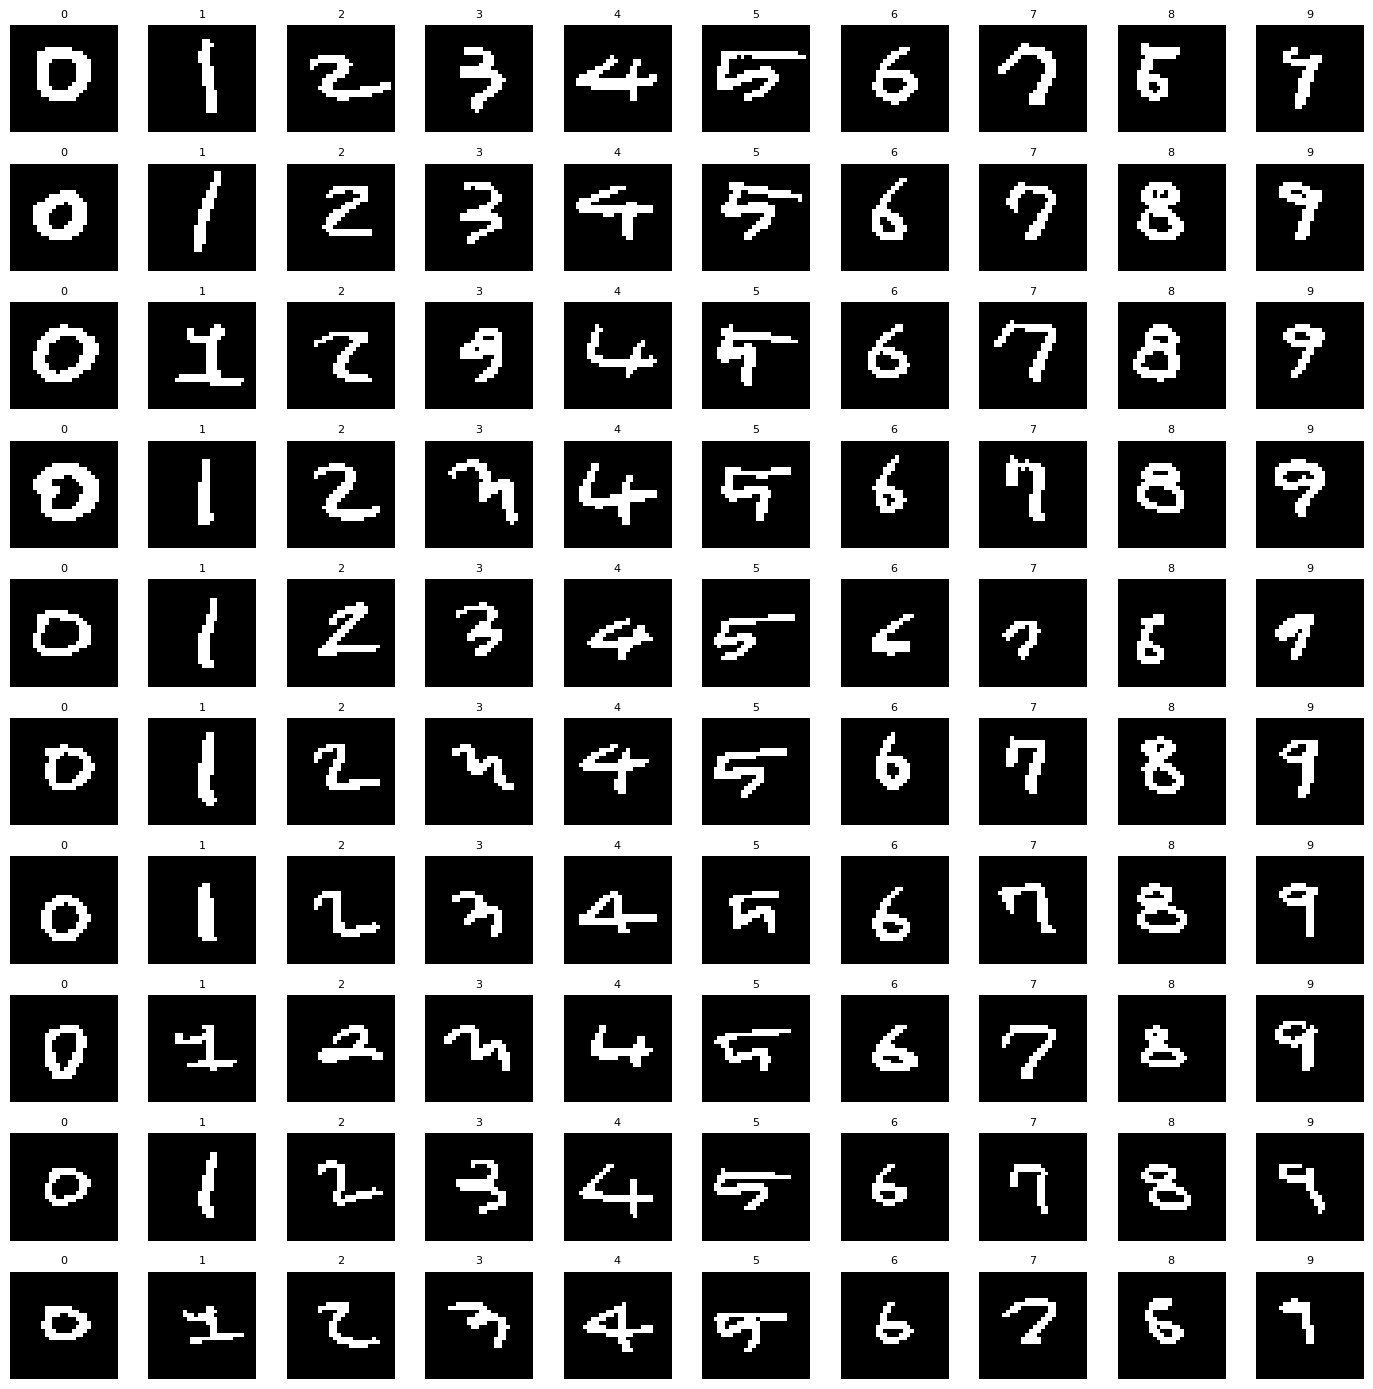


===== 페이지 17 / 95 | 이미지 1600 ~ 1699 =====


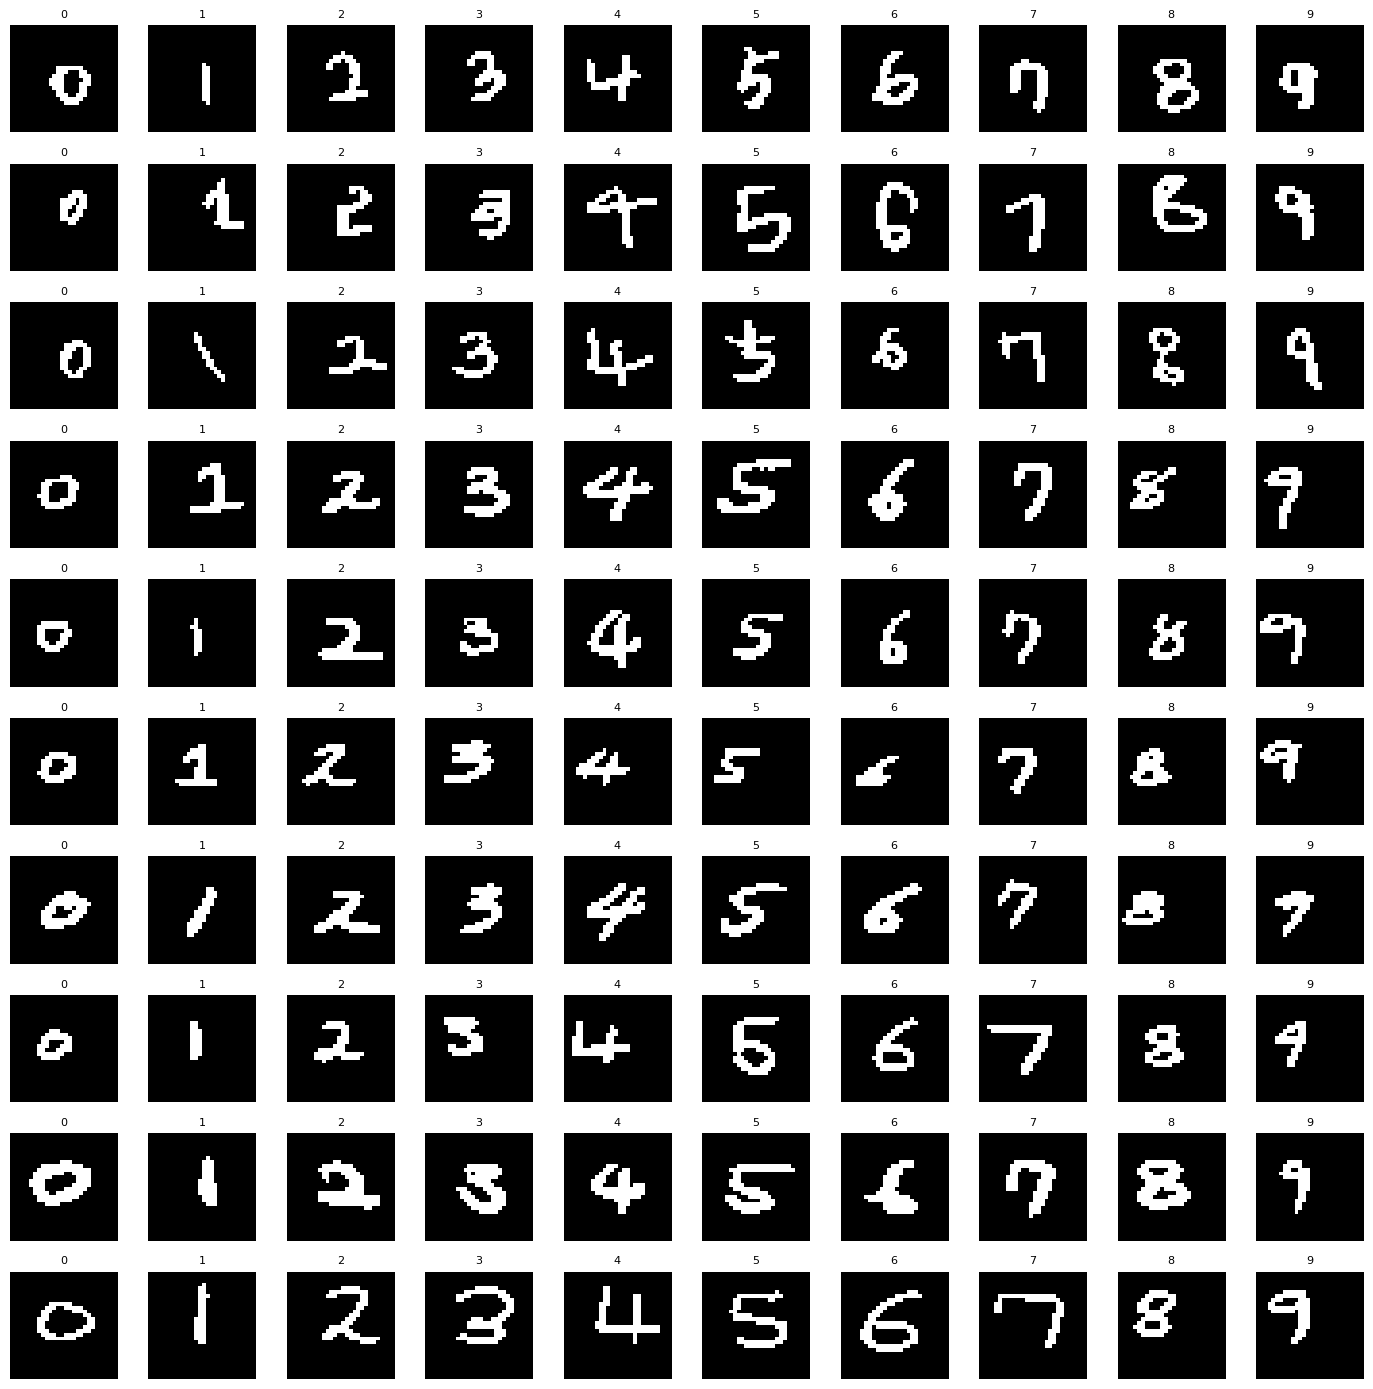


===== 페이지 18 / 95 | 이미지 1700 ~ 1799 =====


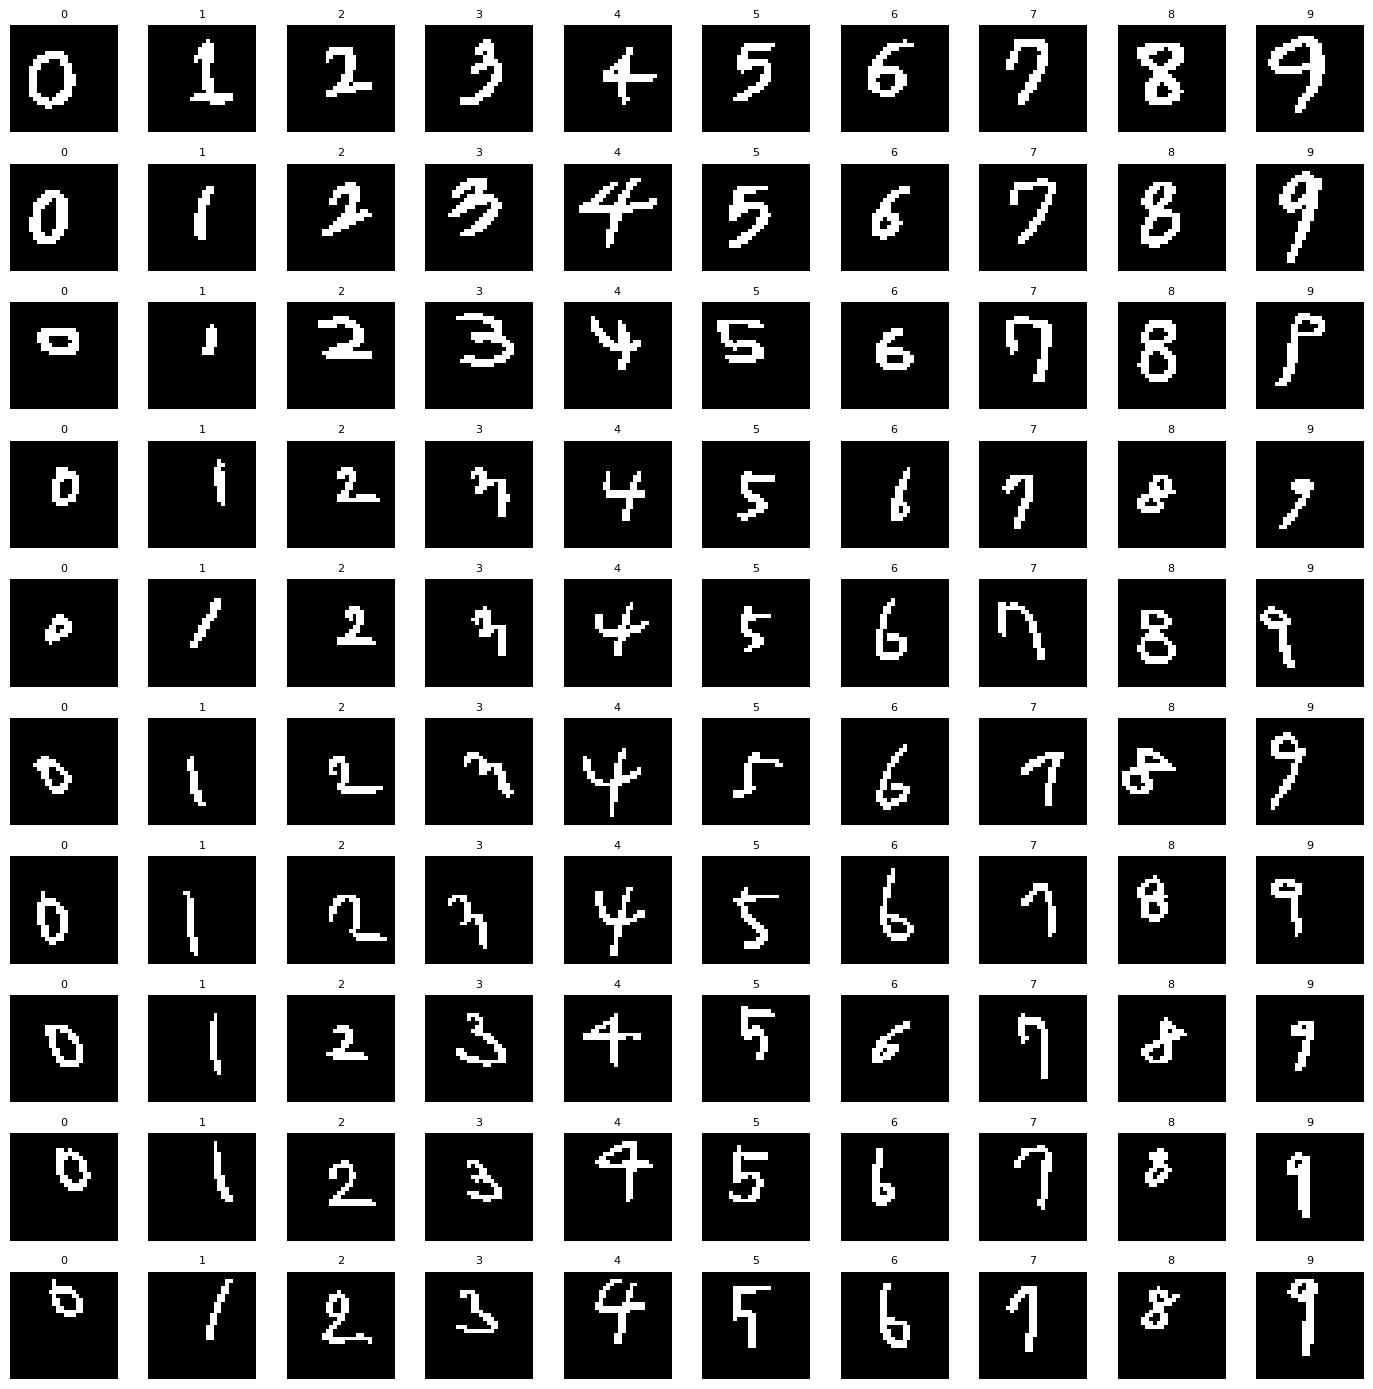


===== 페이지 19 / 95 | 이미지 1800 ~ 1899 =====


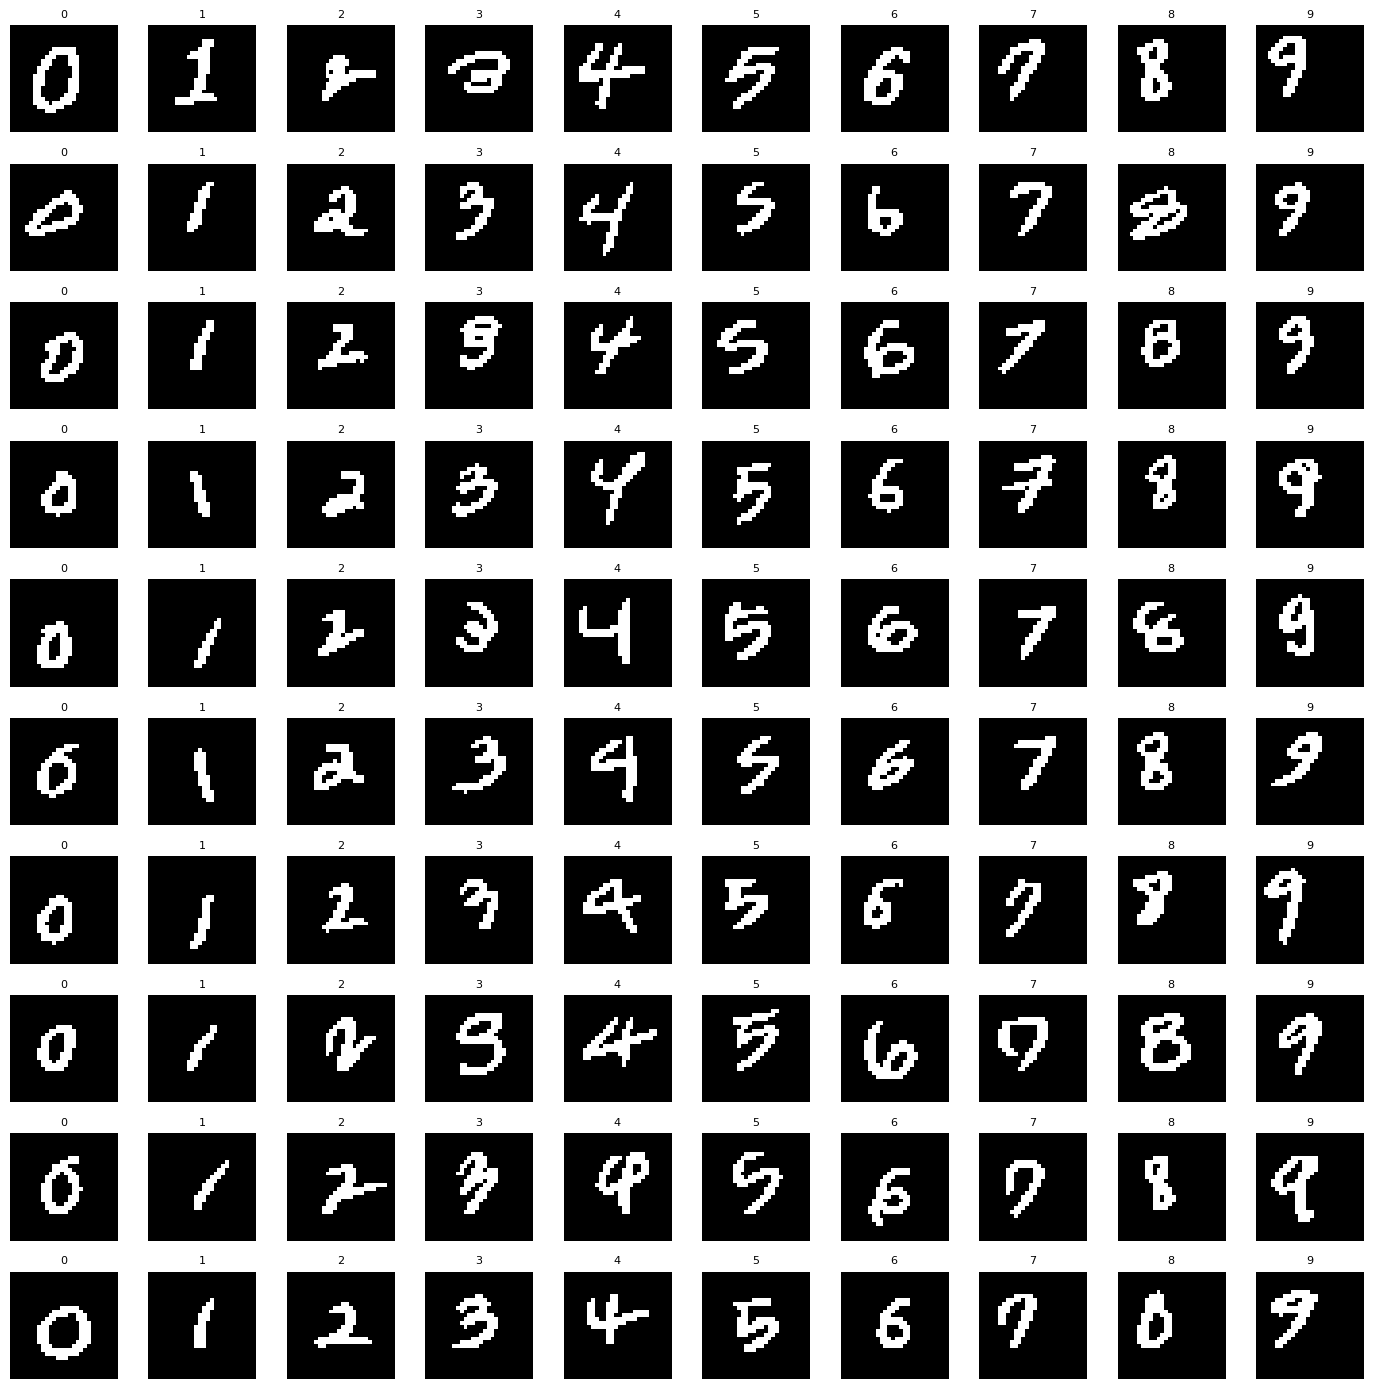


===== 페이지 20 / 95 | 이미지 1900 ~ 1999 =====


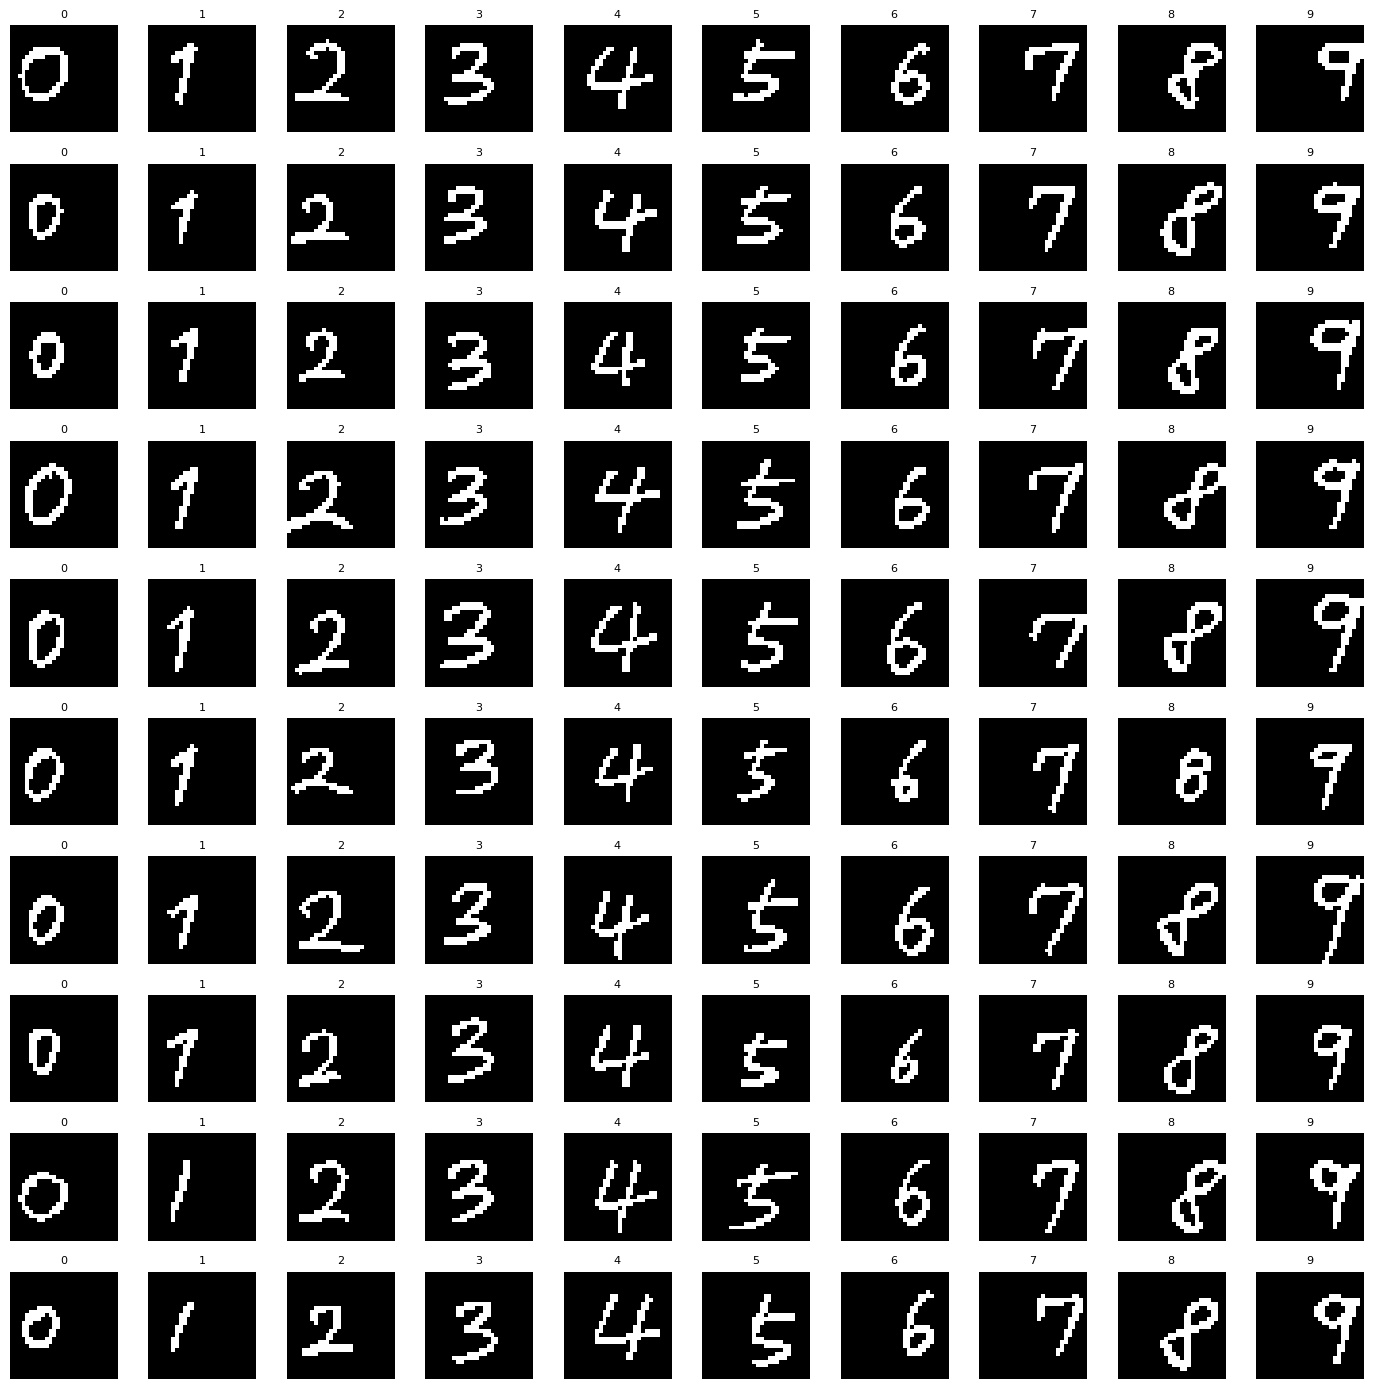


===== 페이지 21 / 95 | 이미지 2000 ~ 2099 =====


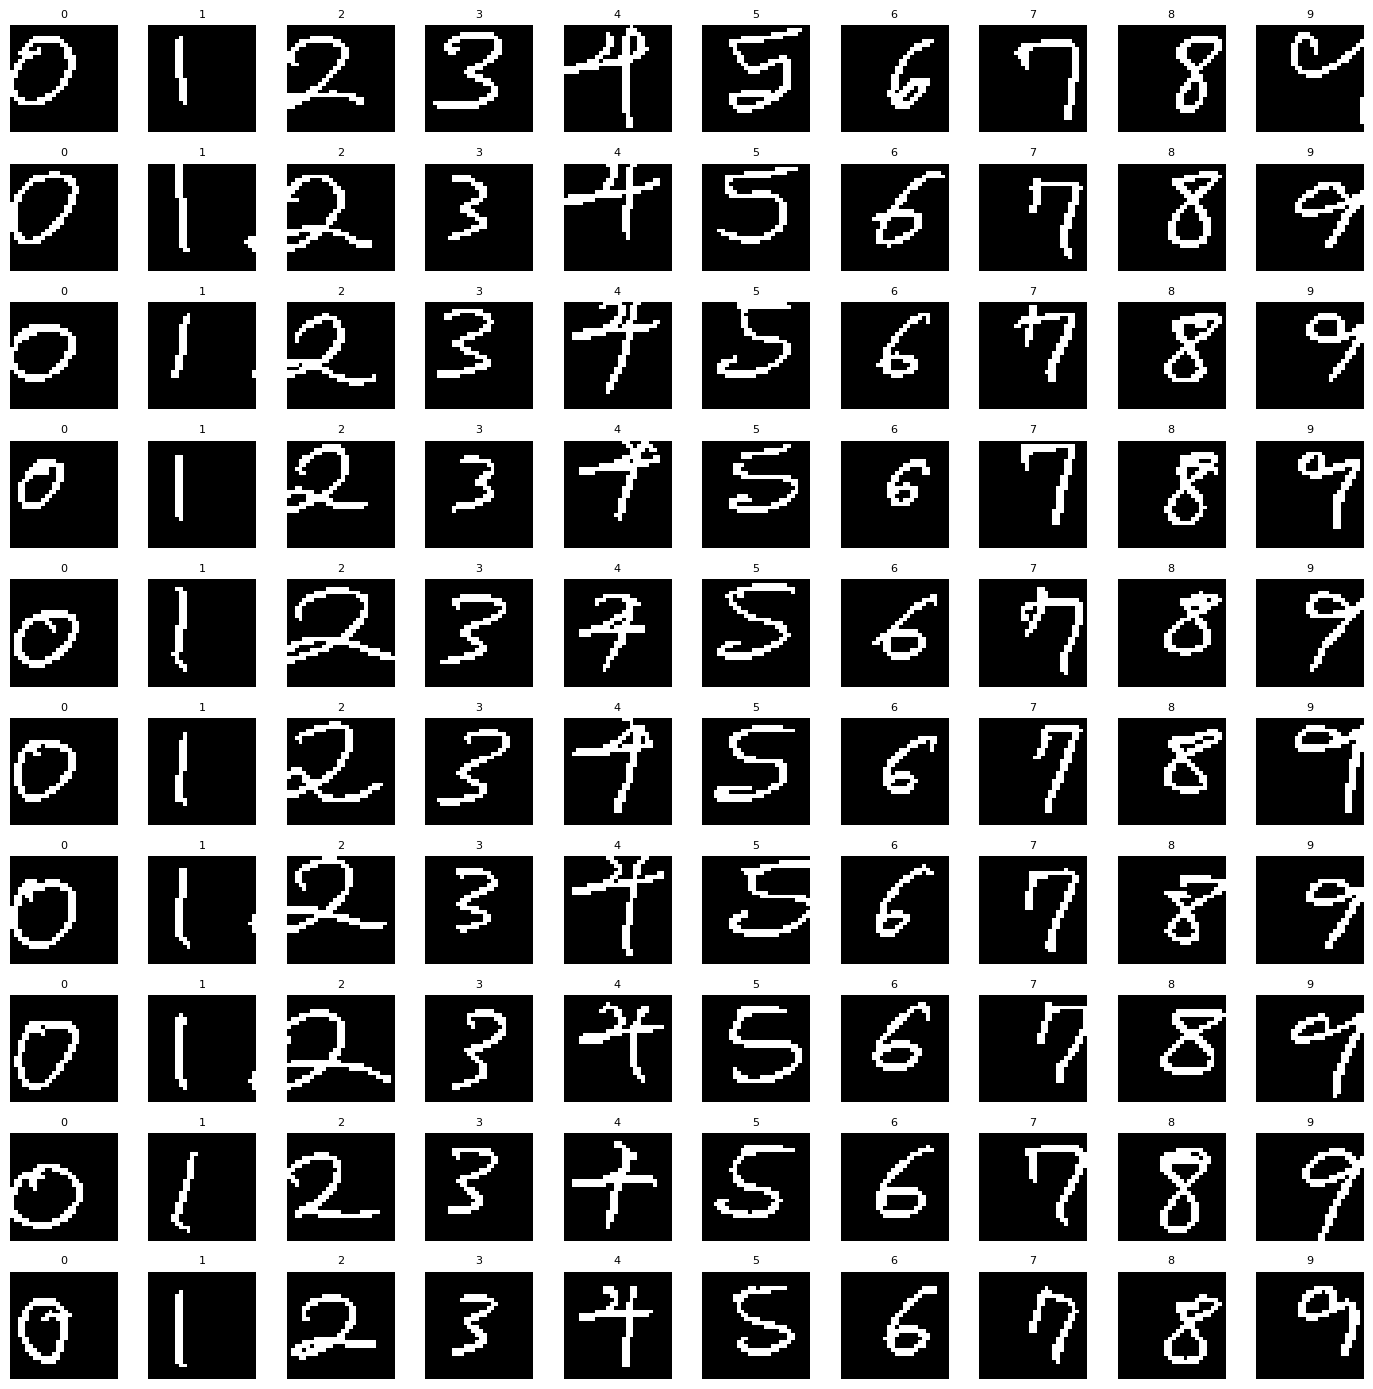


===== 페이지 22 / 95 | 이미지 2100 ~ 2199 =====


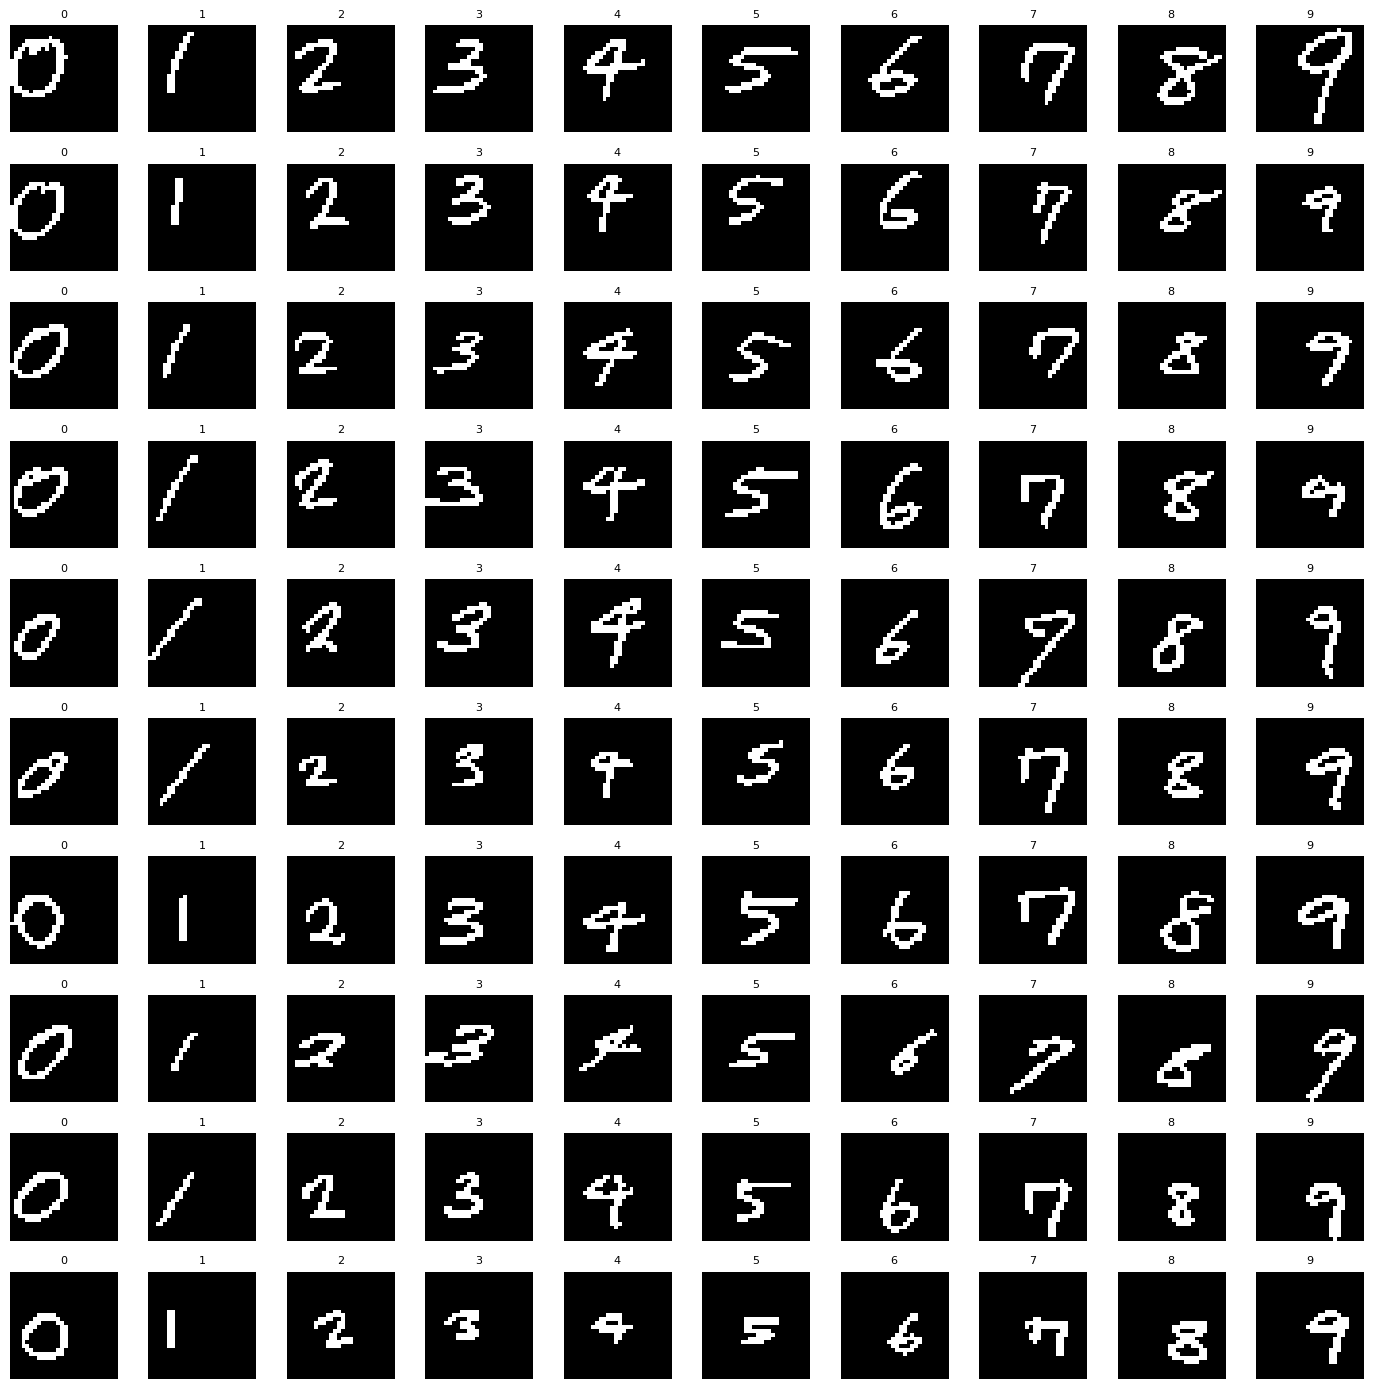


===== 페이지 23 / 95 | 이미지 2200 ~ 2299 =====


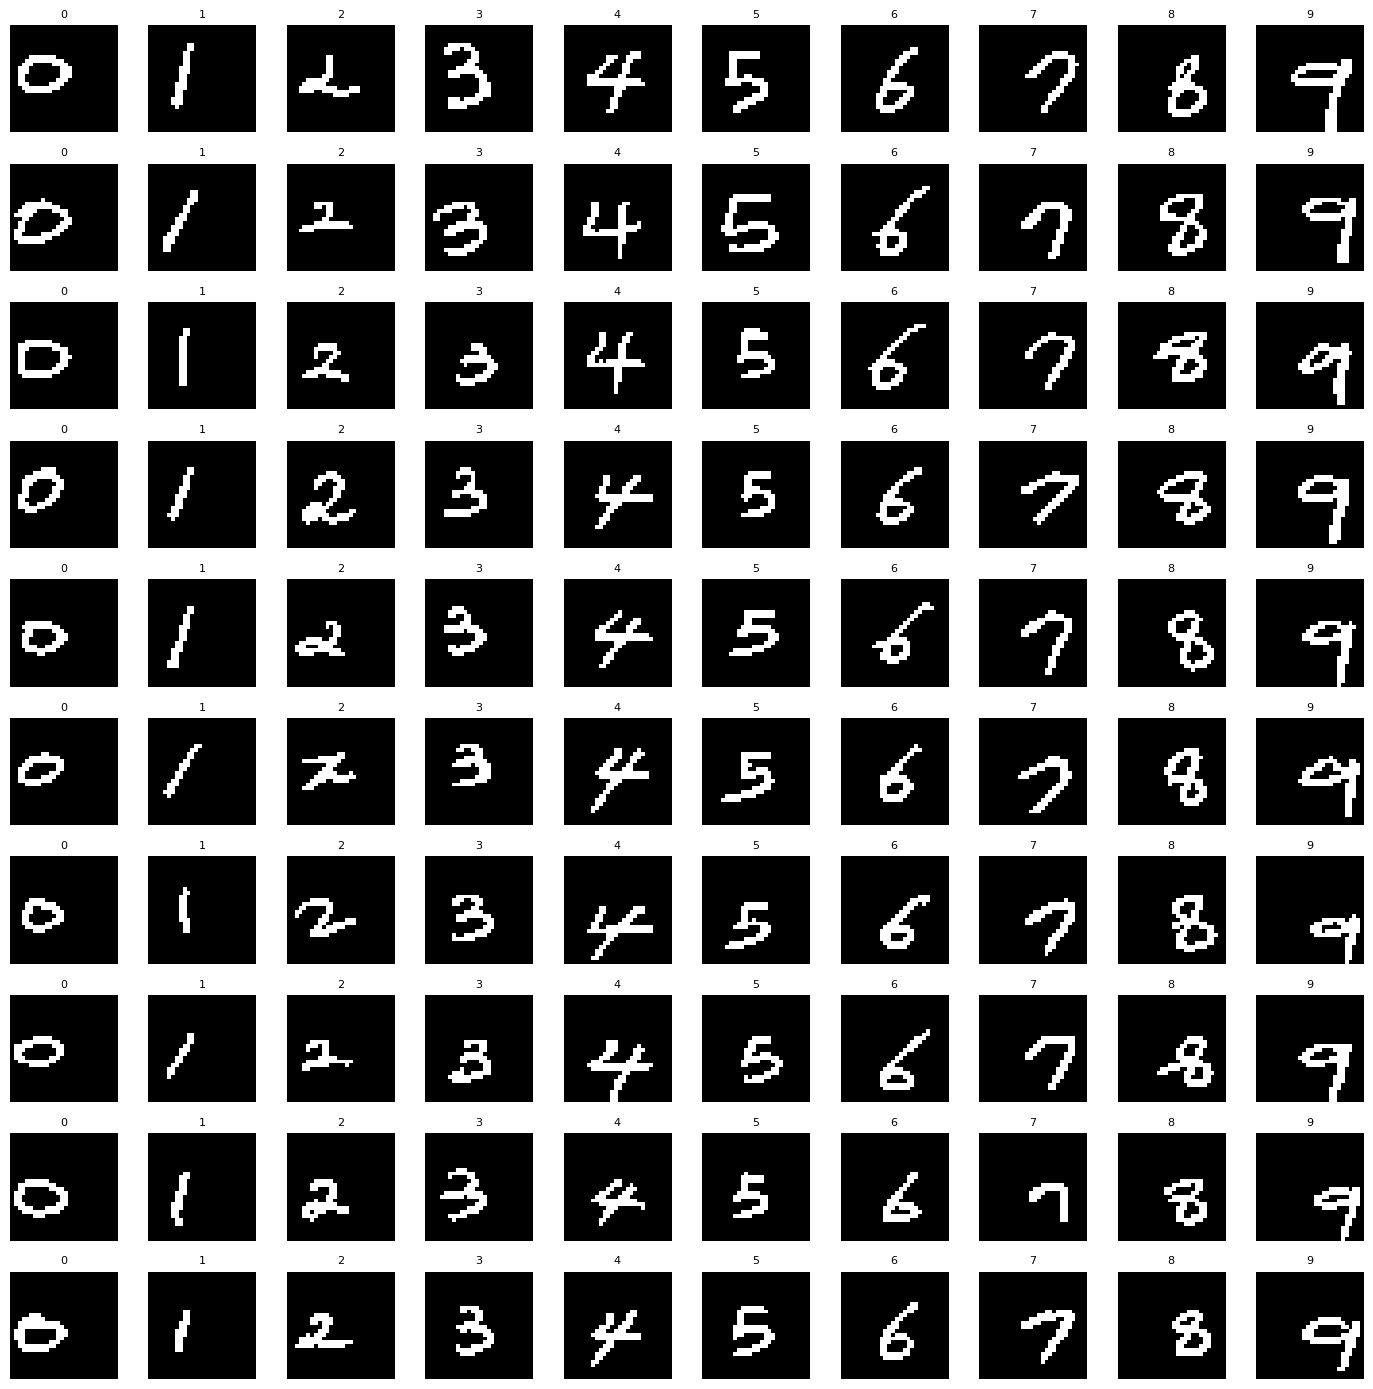


===== 페이지 24 / 95 | 이미지 2300 ~ 2399 =====


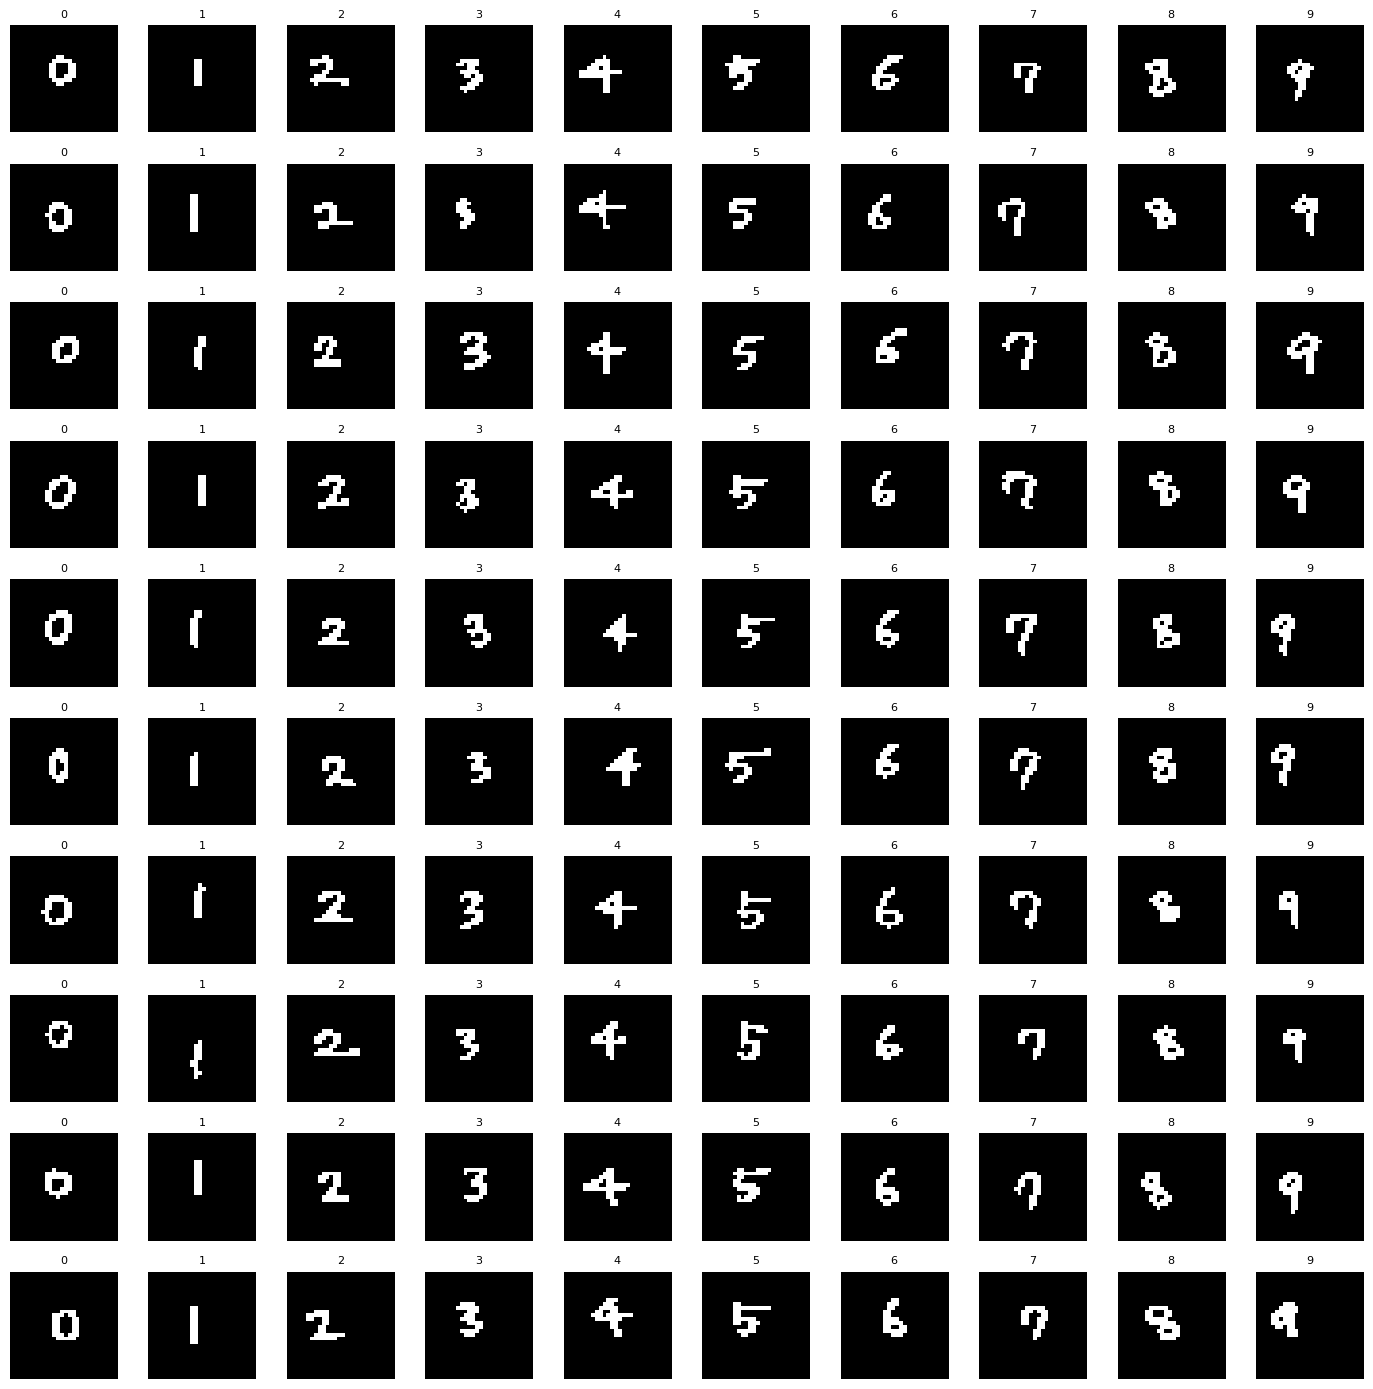


===== 페이지 25 / 95 | 이미지 2400 ~ 2499 =====


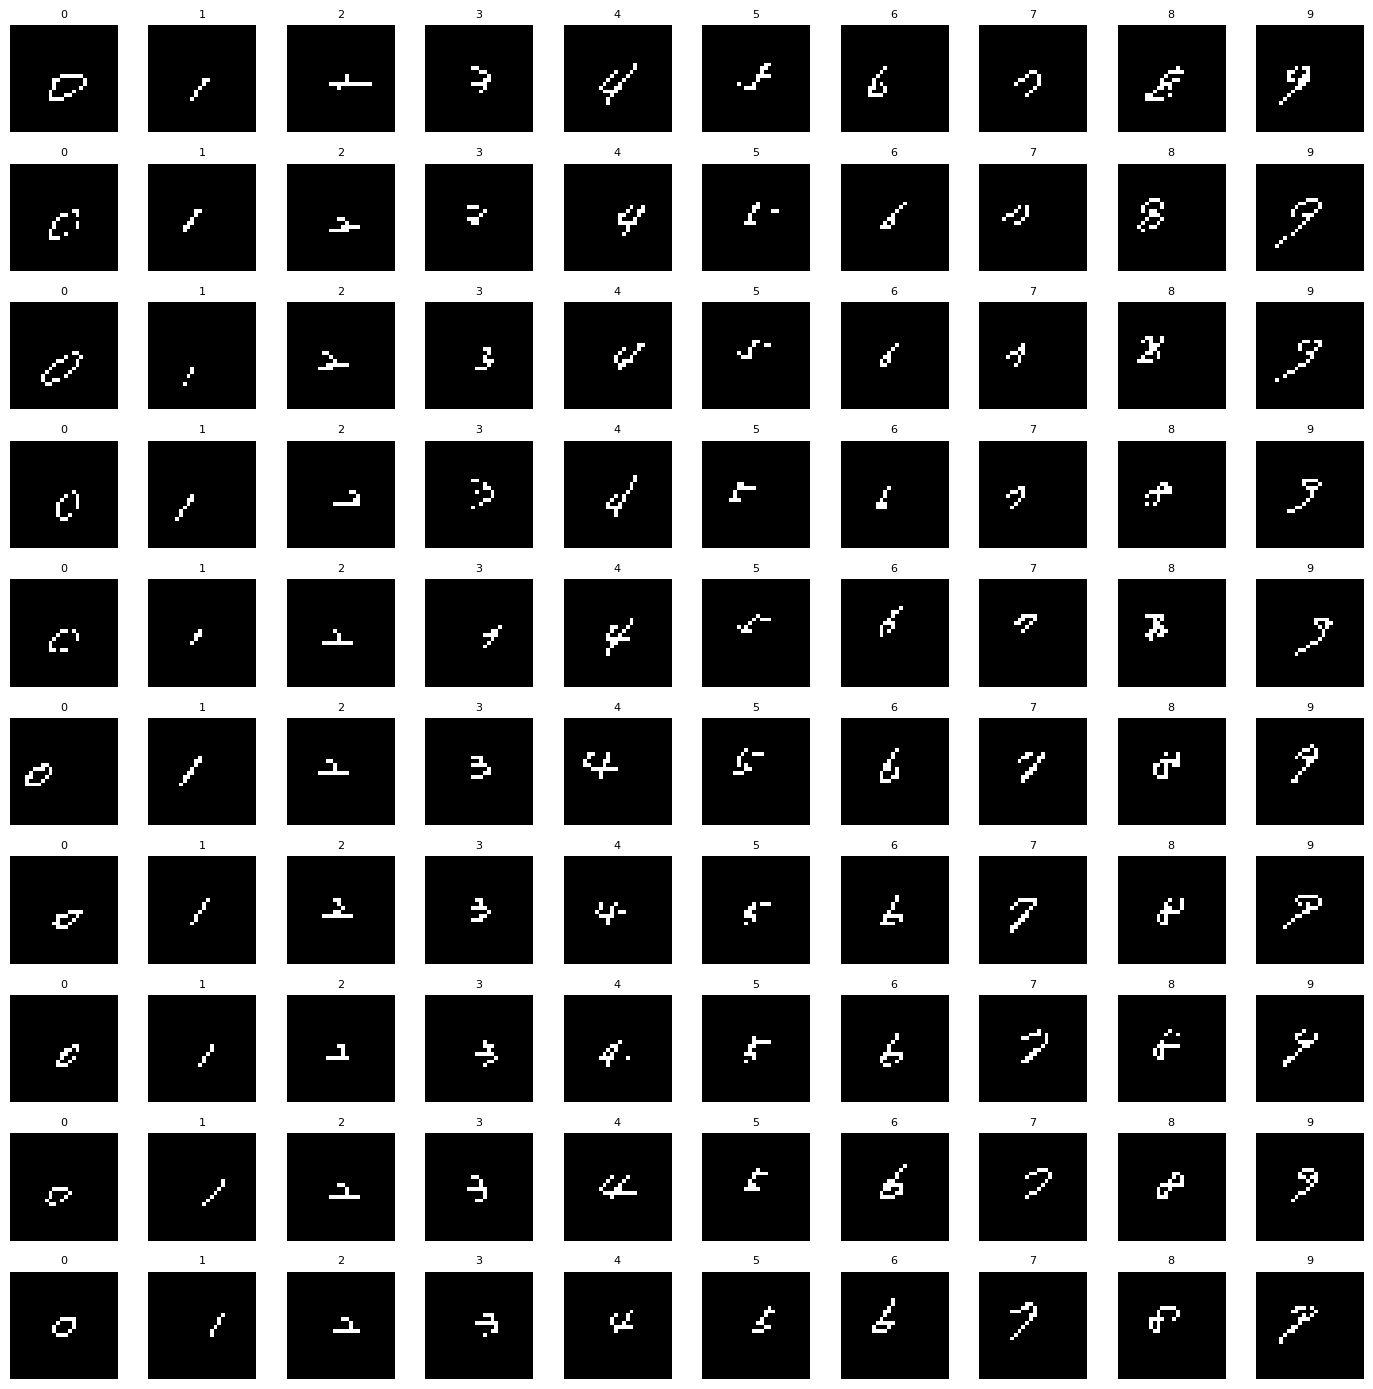


===== 페이지 26 / 95 | 이미지 2500 ~ 2599 =====


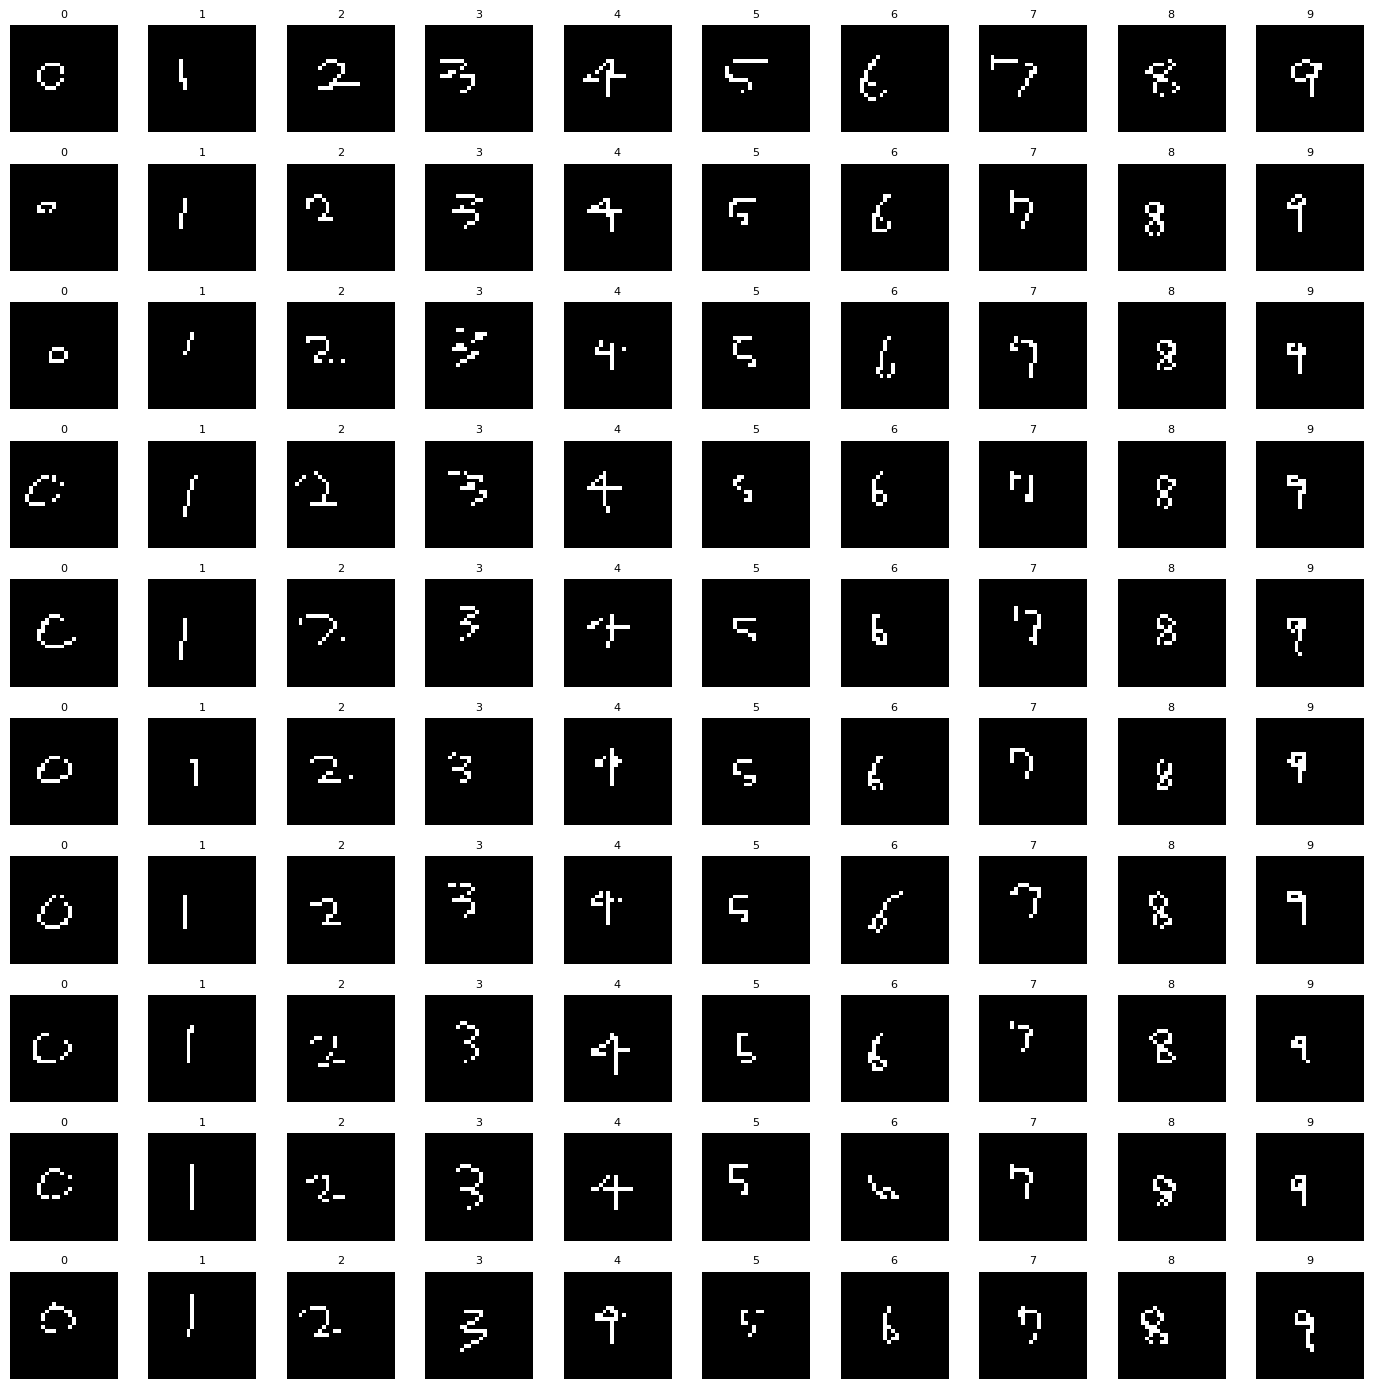


===== 페이지 27 / 95 | 이미지 2600 ~ 2699 =====


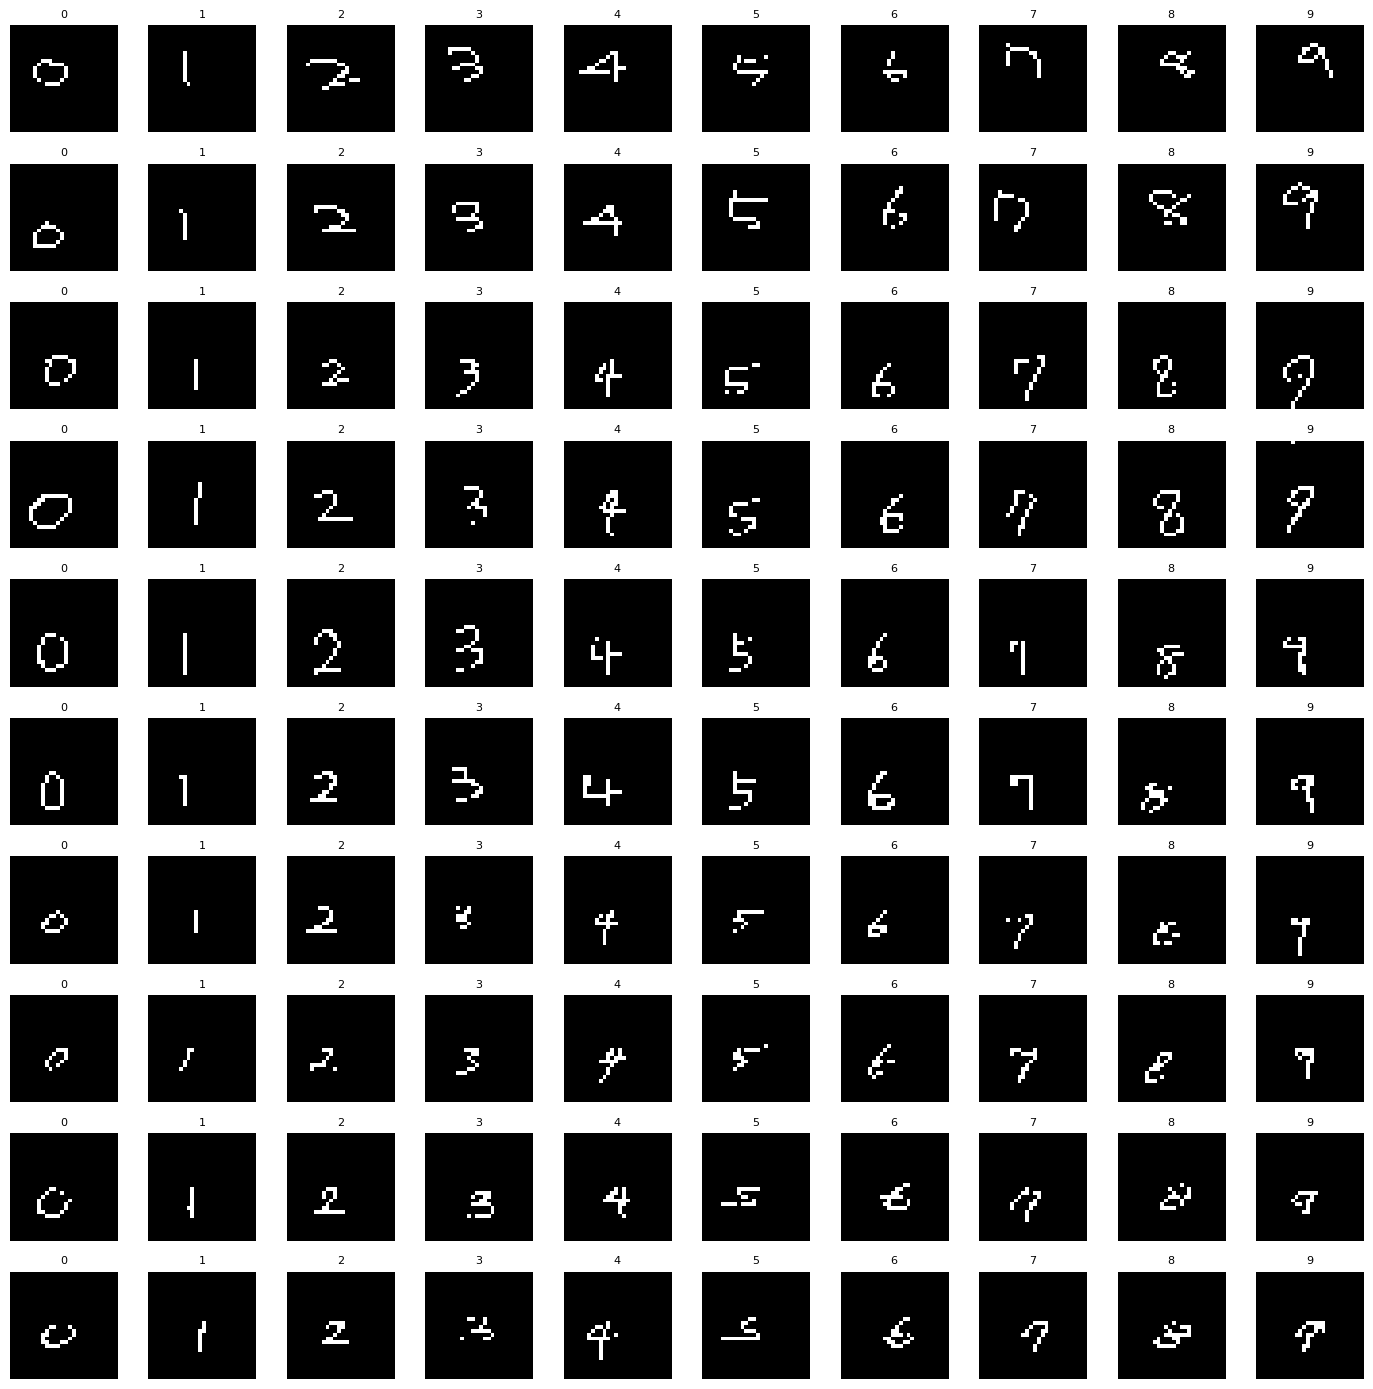


===== 페이지 28 / 95 | 이미지 2700 ~ 2799 =====


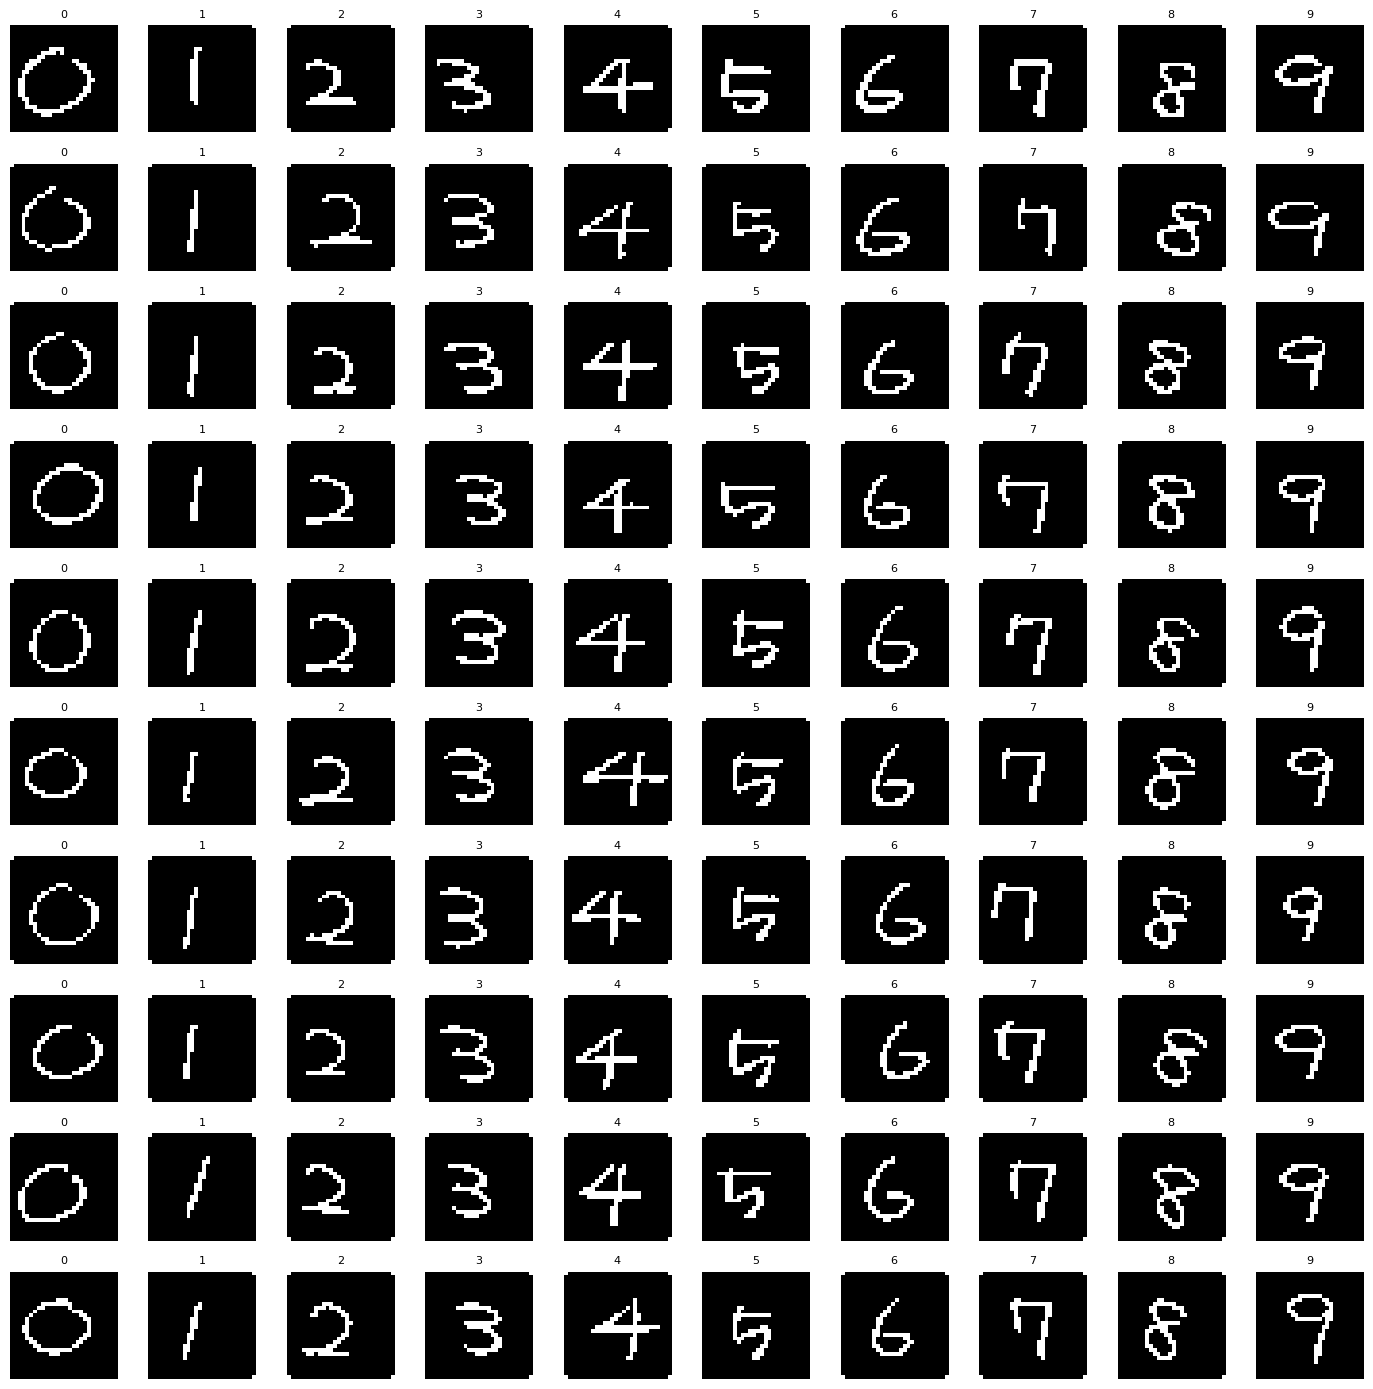


===== 페이지 29 / 95 | 이미지 2800 ~ 2899 =====


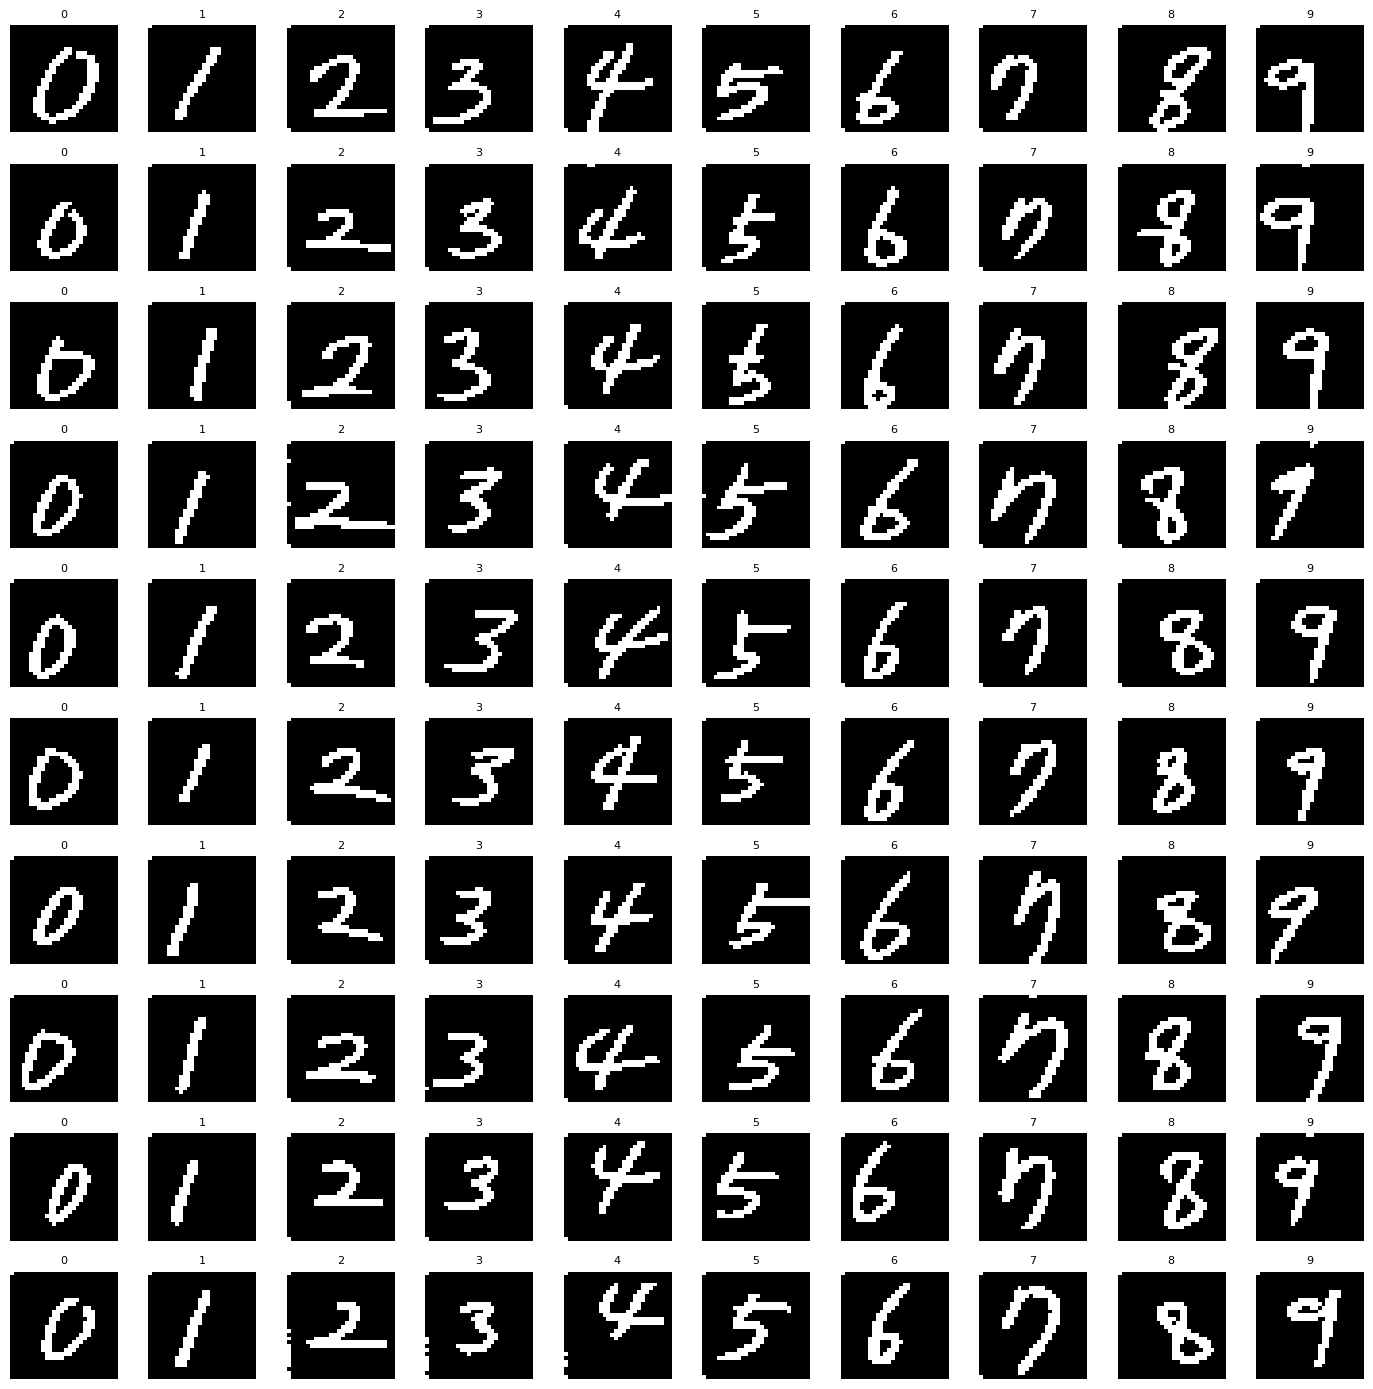


===== 페이지 30 / 95 | 이미지 2900 ~ 2999 =====


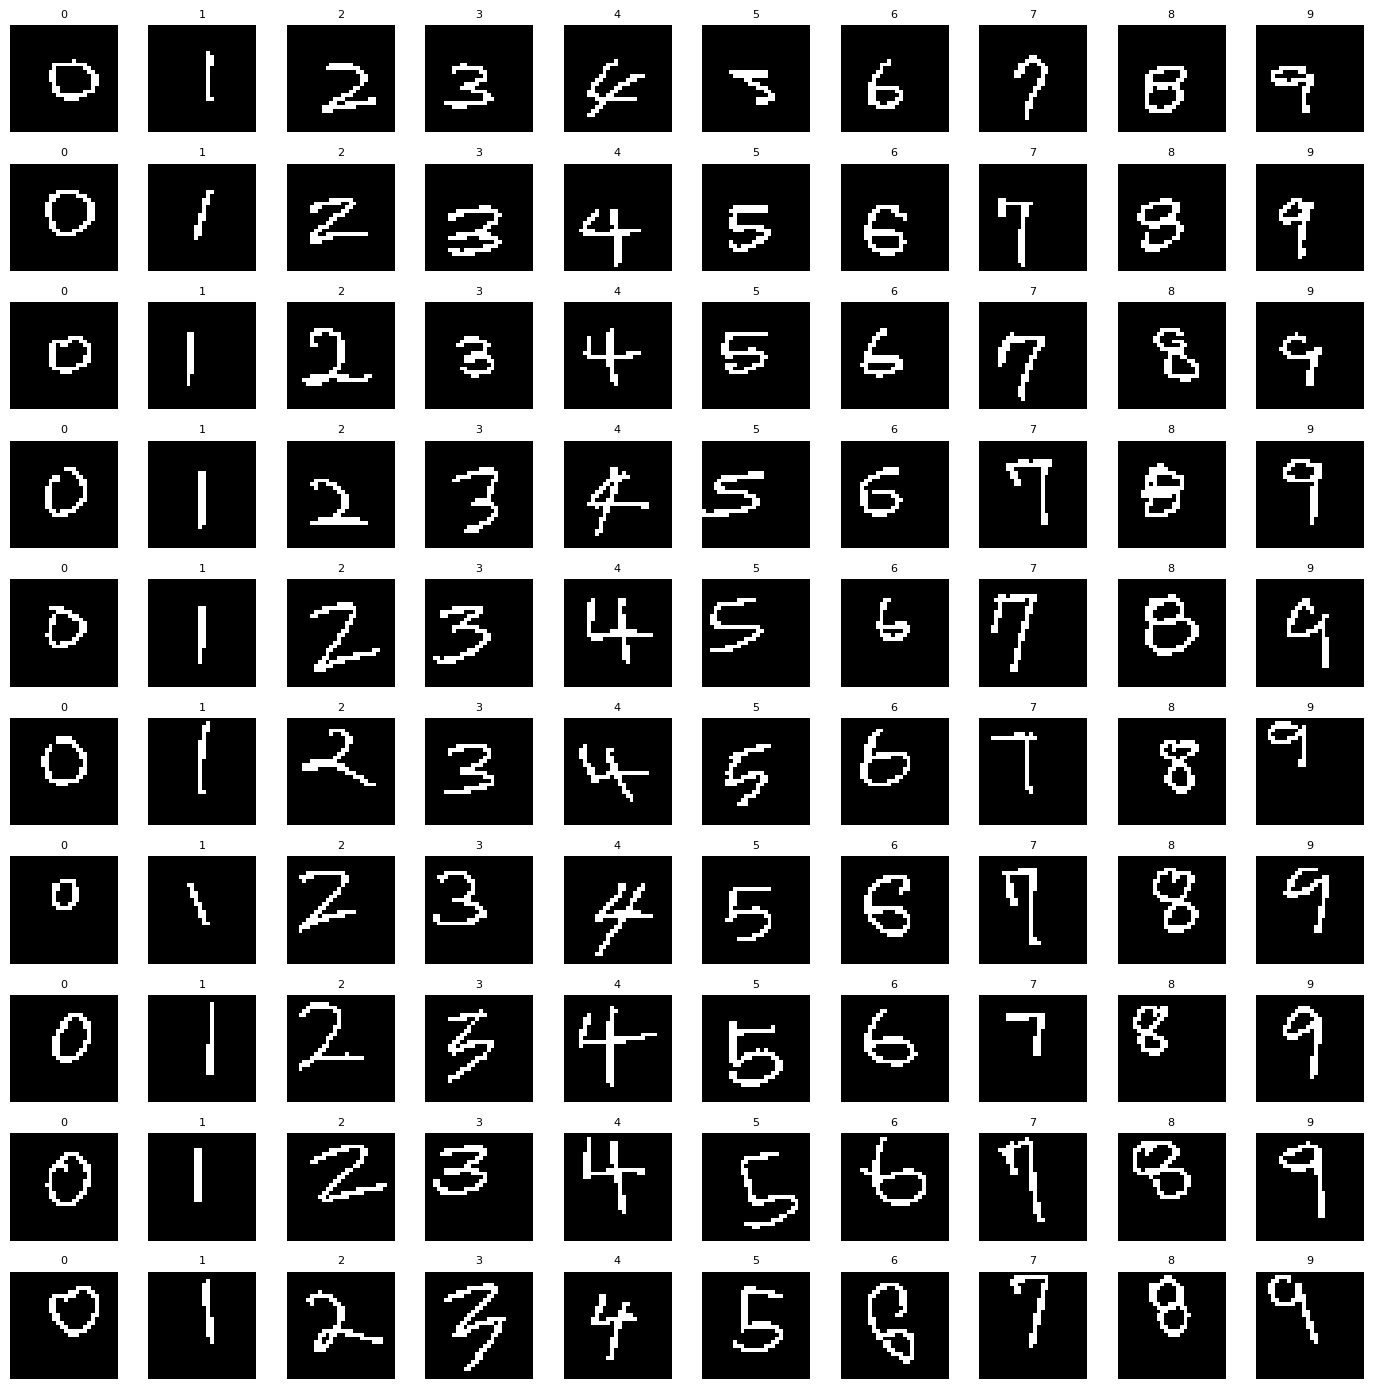


===== 페이지 31 / 95 | 이미지 3000 ~ 3099 =====


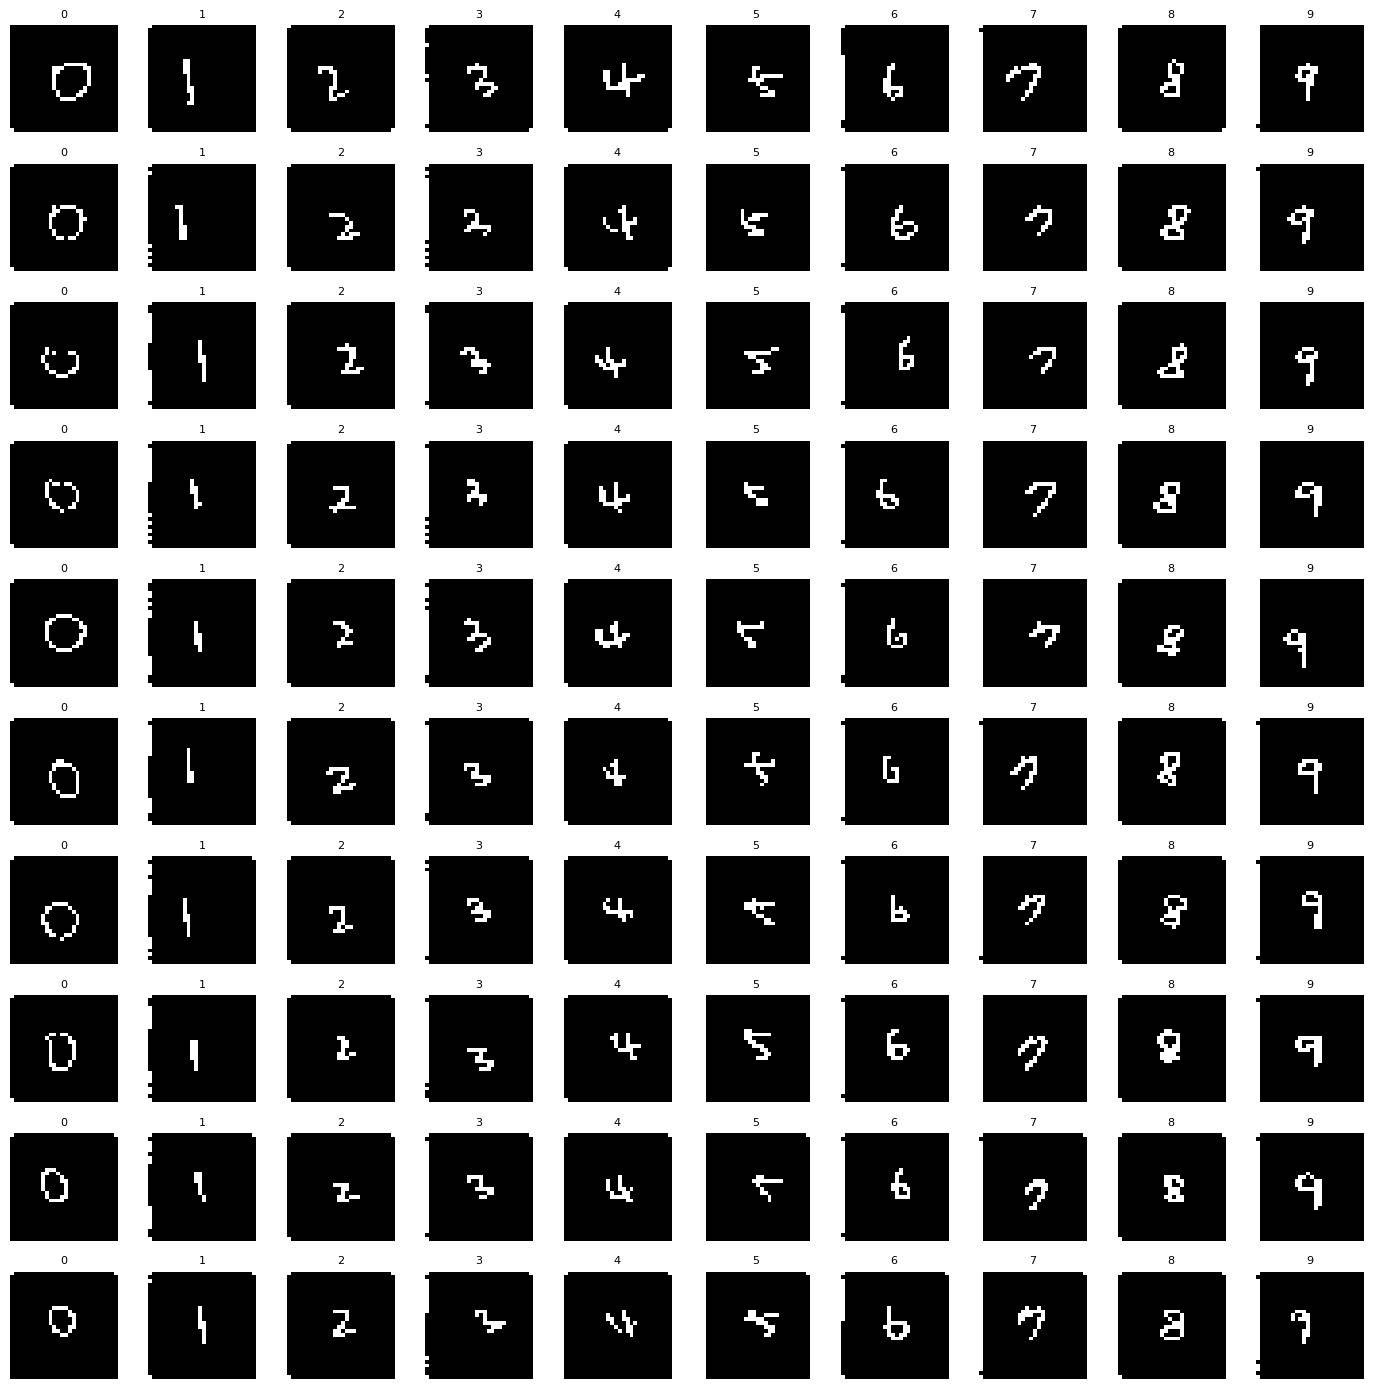


===== 페이지 32 / 95 | 이미지 3100 ~ 3199 =====


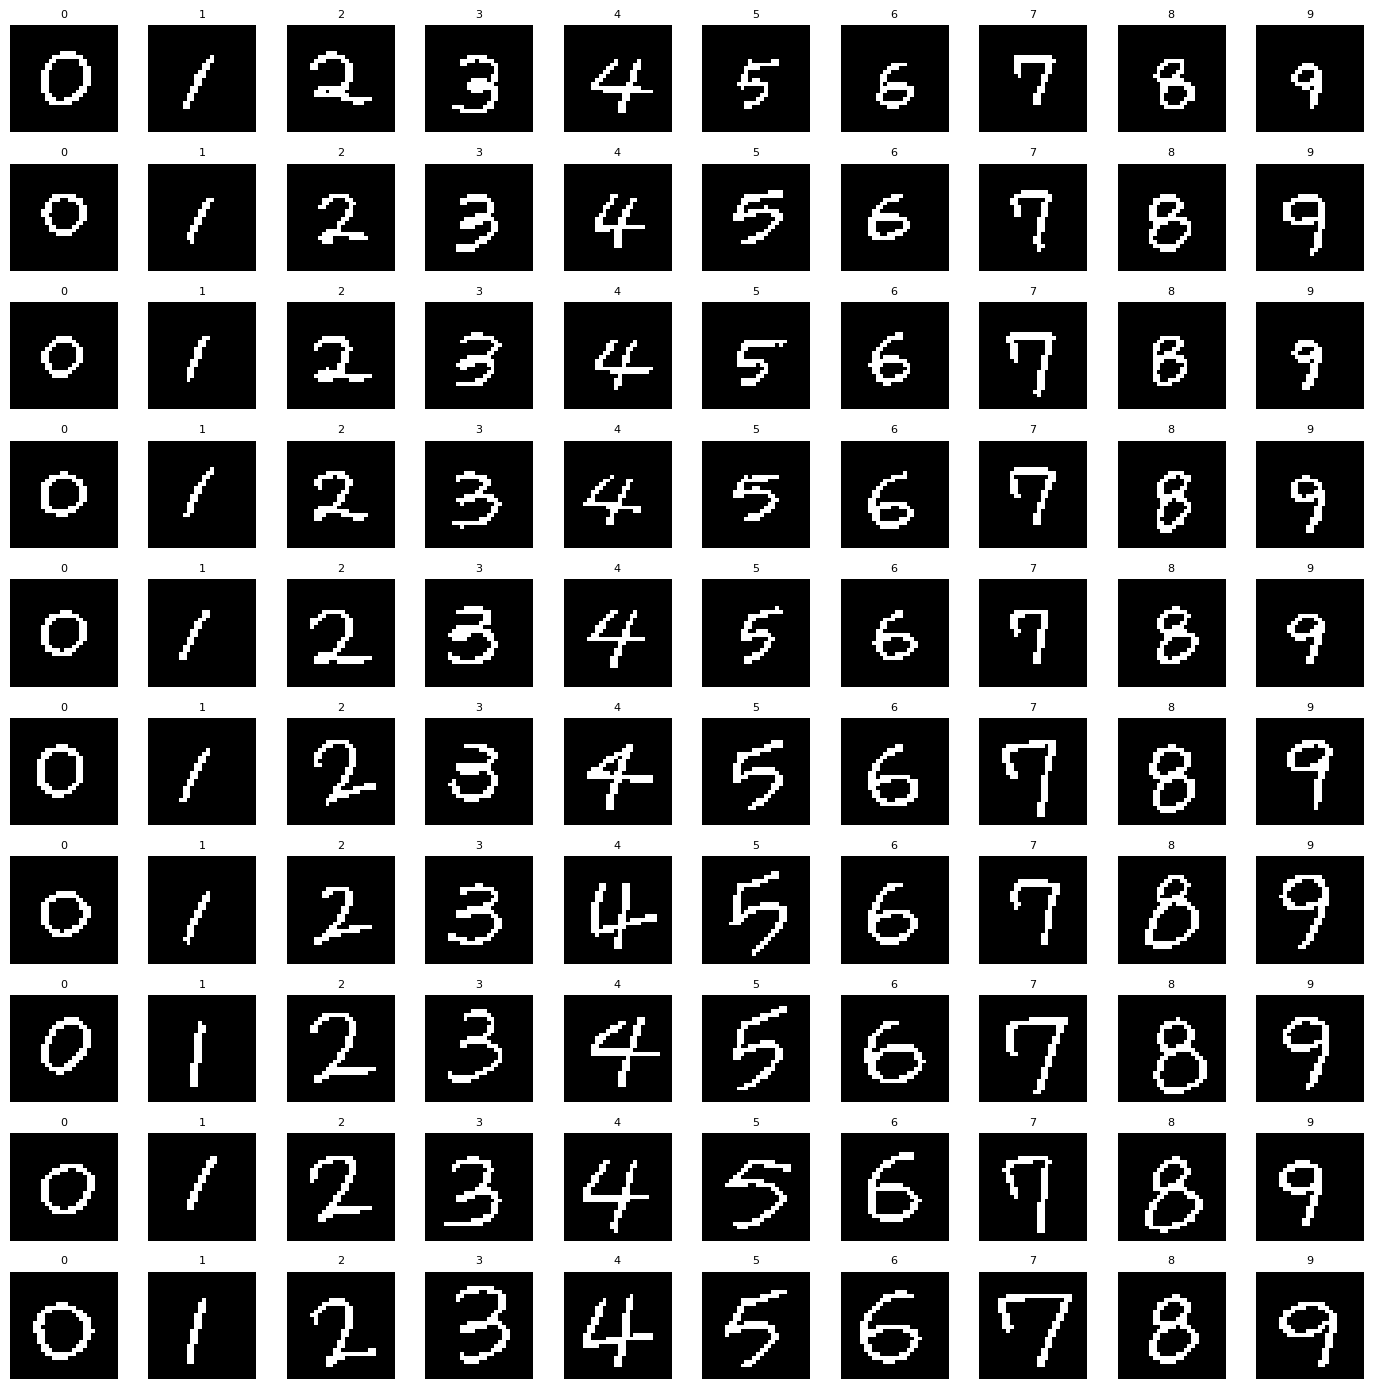


===== 페이지 33 / 95 | 이미지 3200 ~ 3299 =====


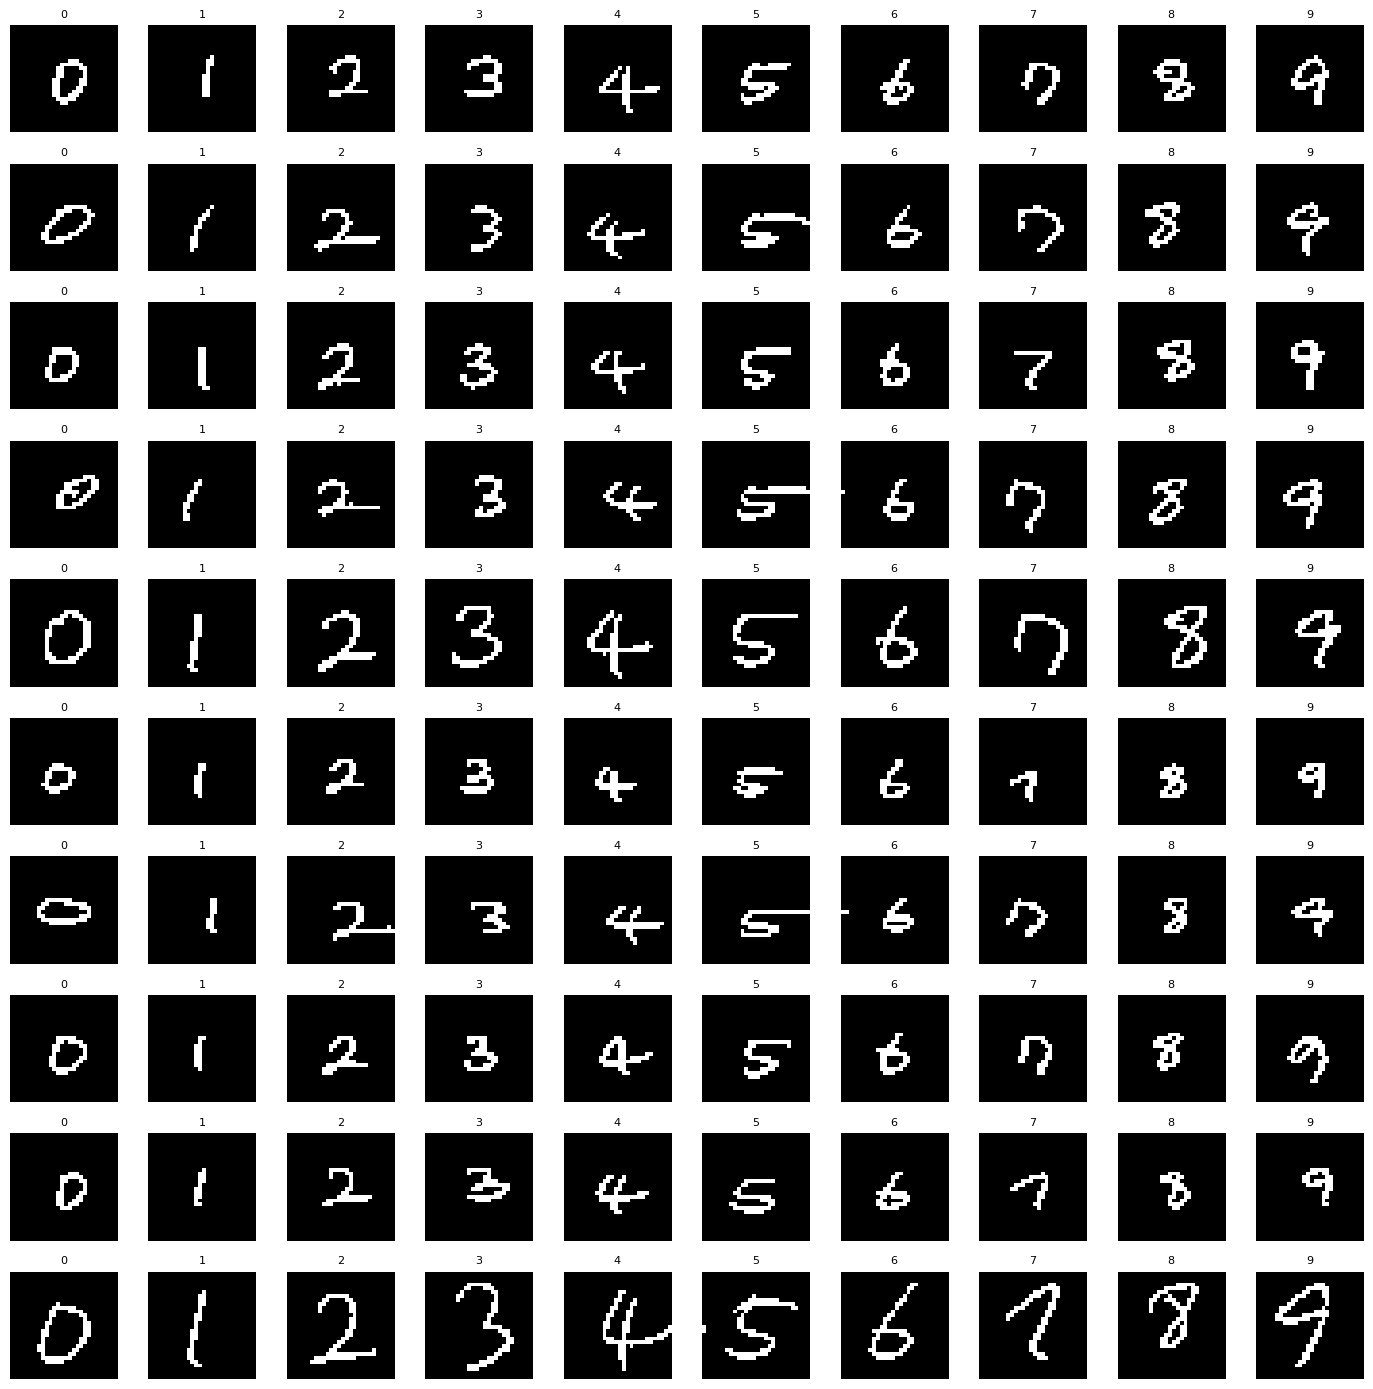


===== 페이지 34 / 95 | 이미지 3300 ~ 3399 =====


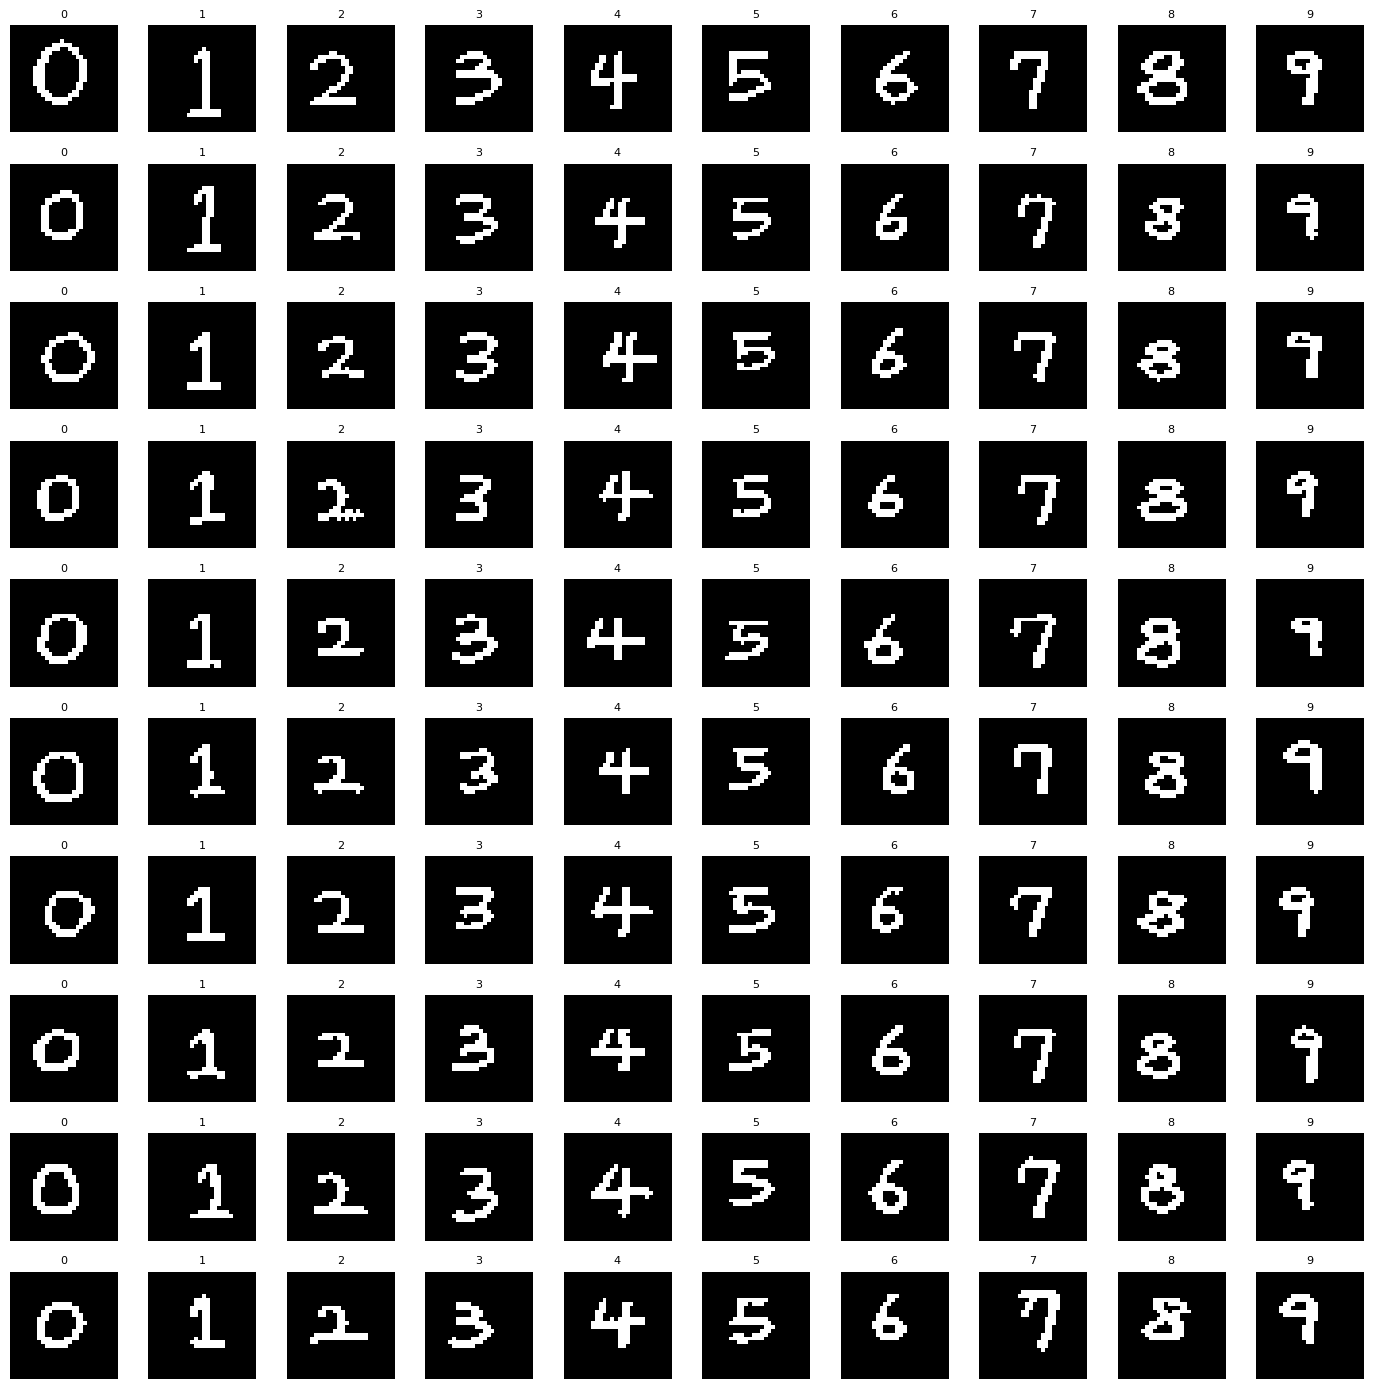


===== 페이지 35 / 95 | 이미지 3400 ~ 3499 =====


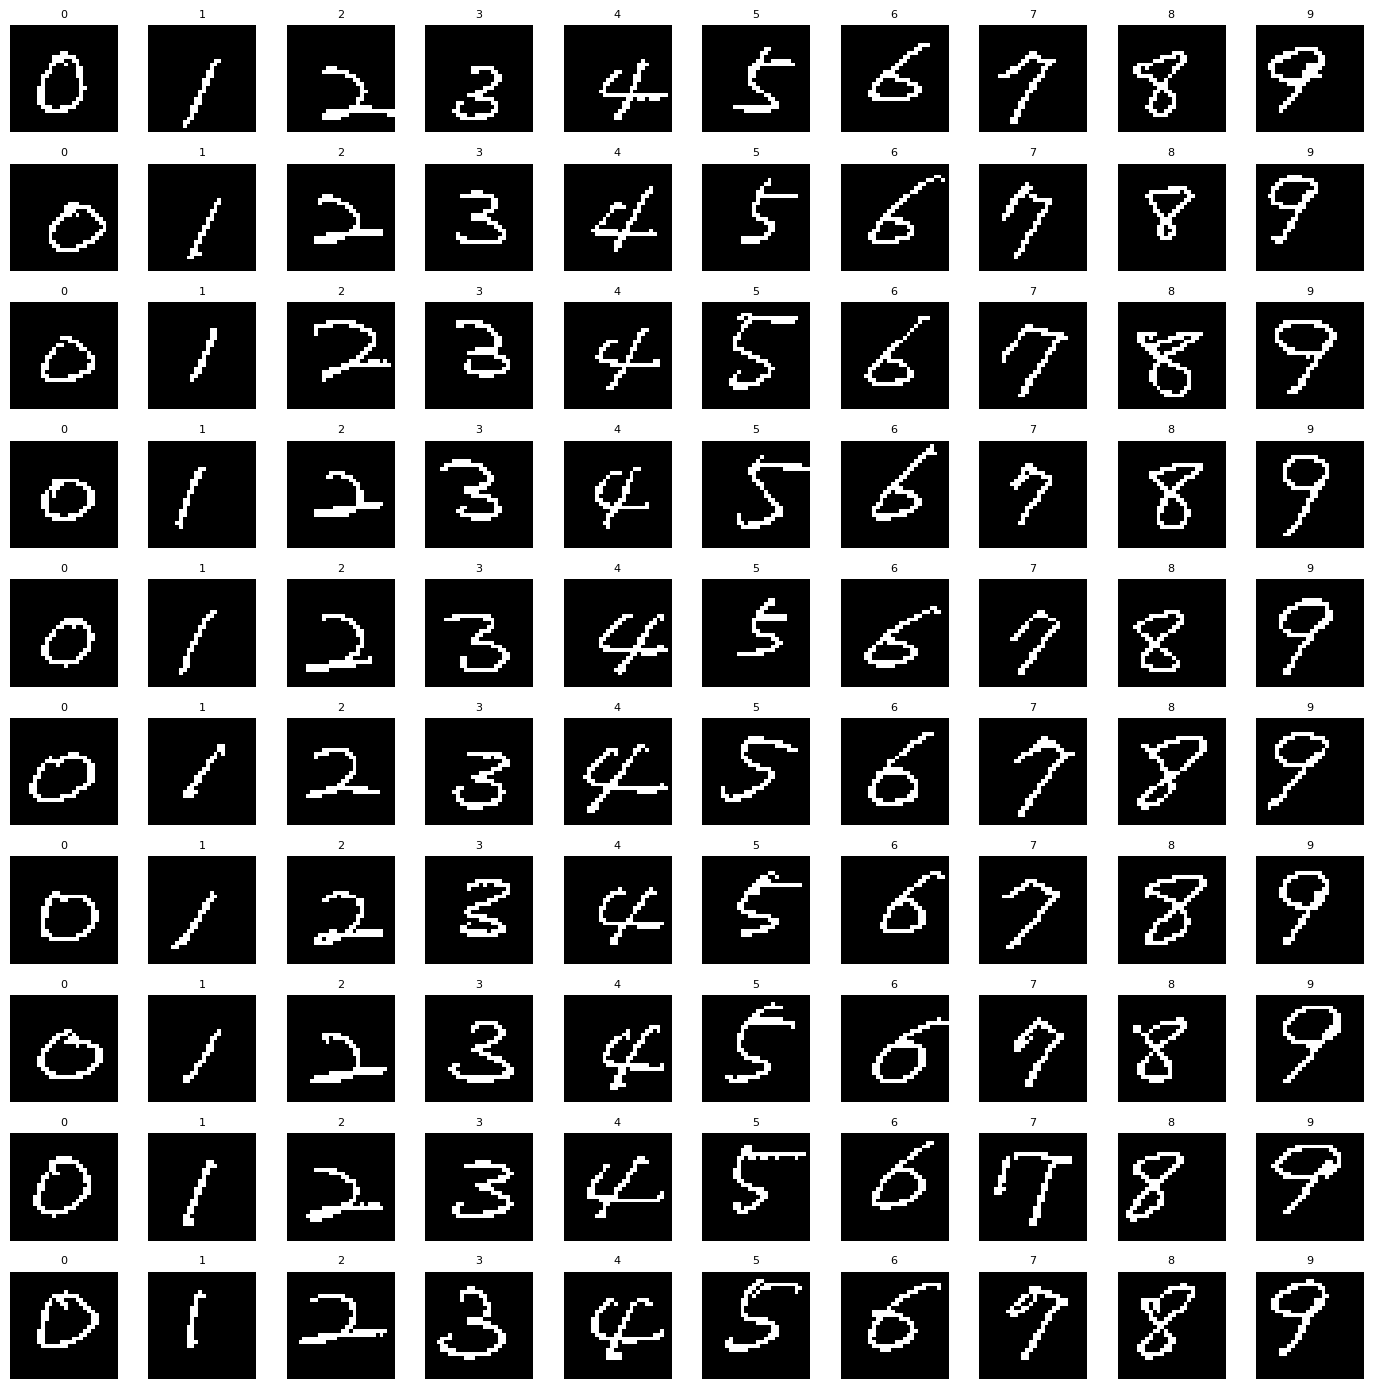


===== 페이지 36 / 95 | 이미지 3500 ~ 3599 =====


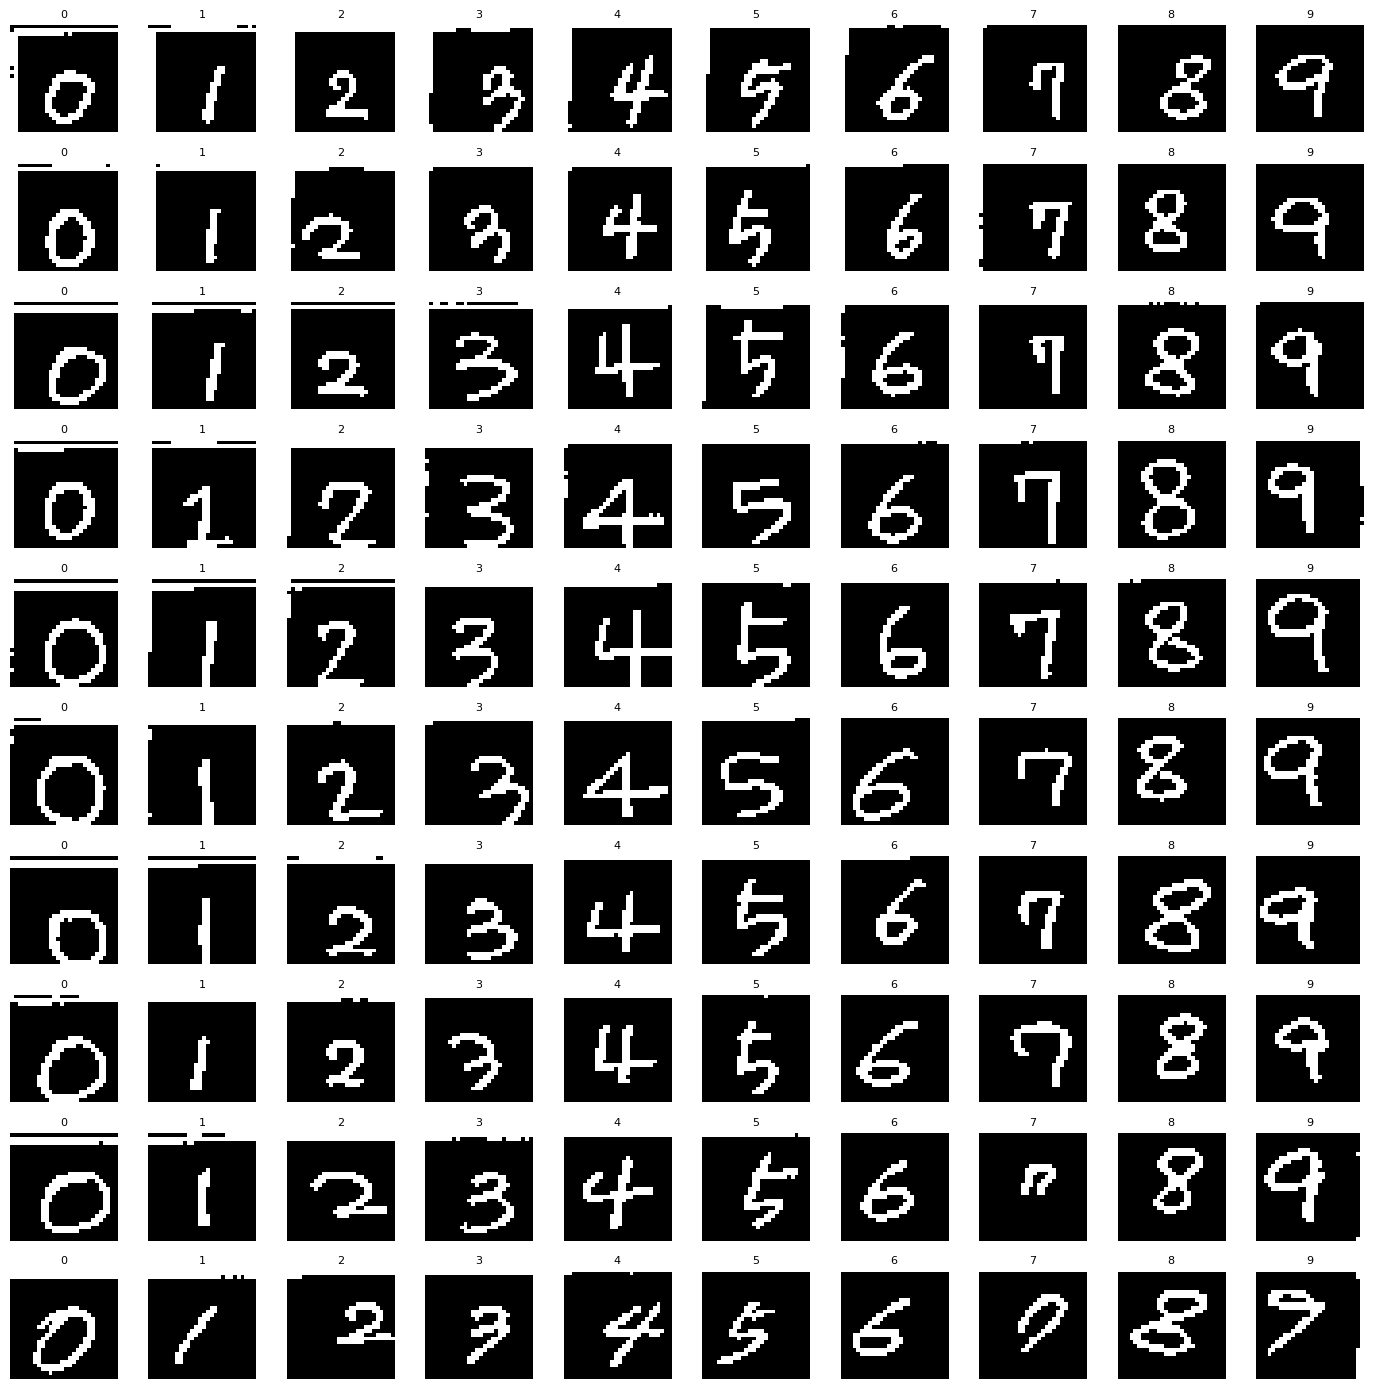


===== 페이지 37 / 95 | 이미지 3600 ~ 3699 =====


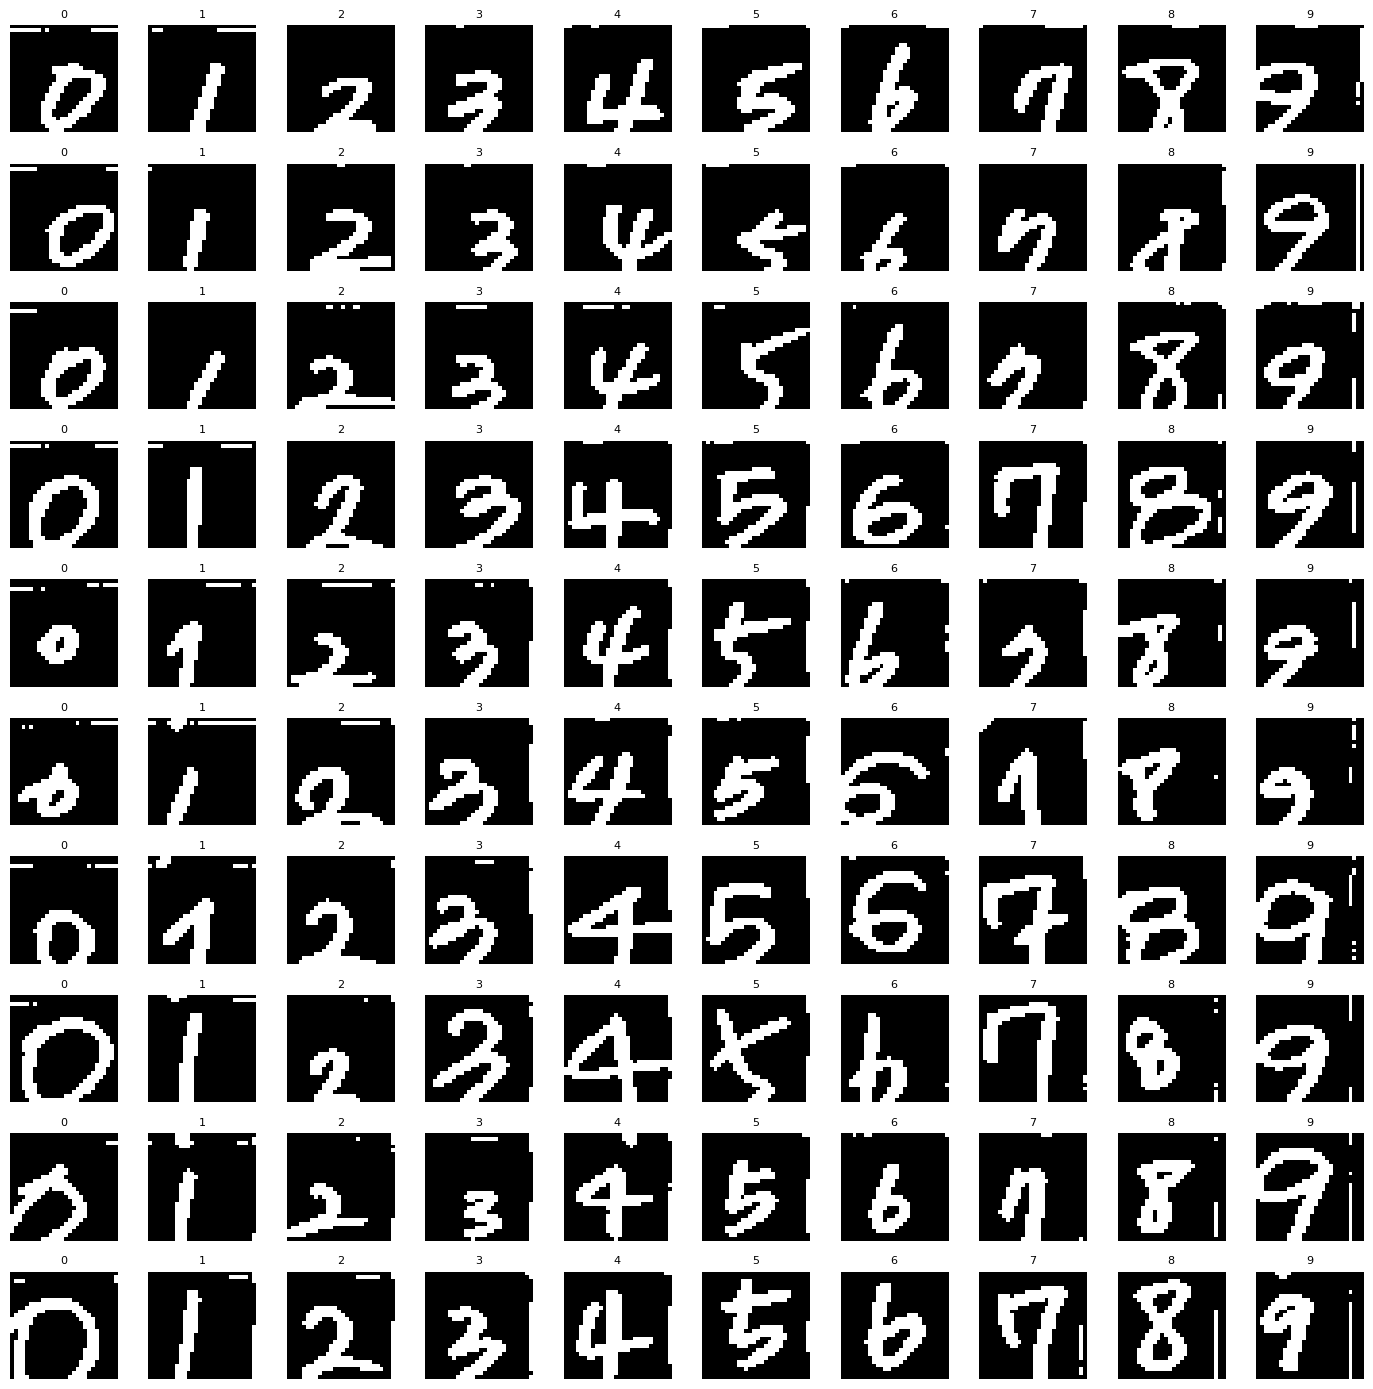


===== 페이지 38 / 95 | 이미지 3700 ~ 3799 =====


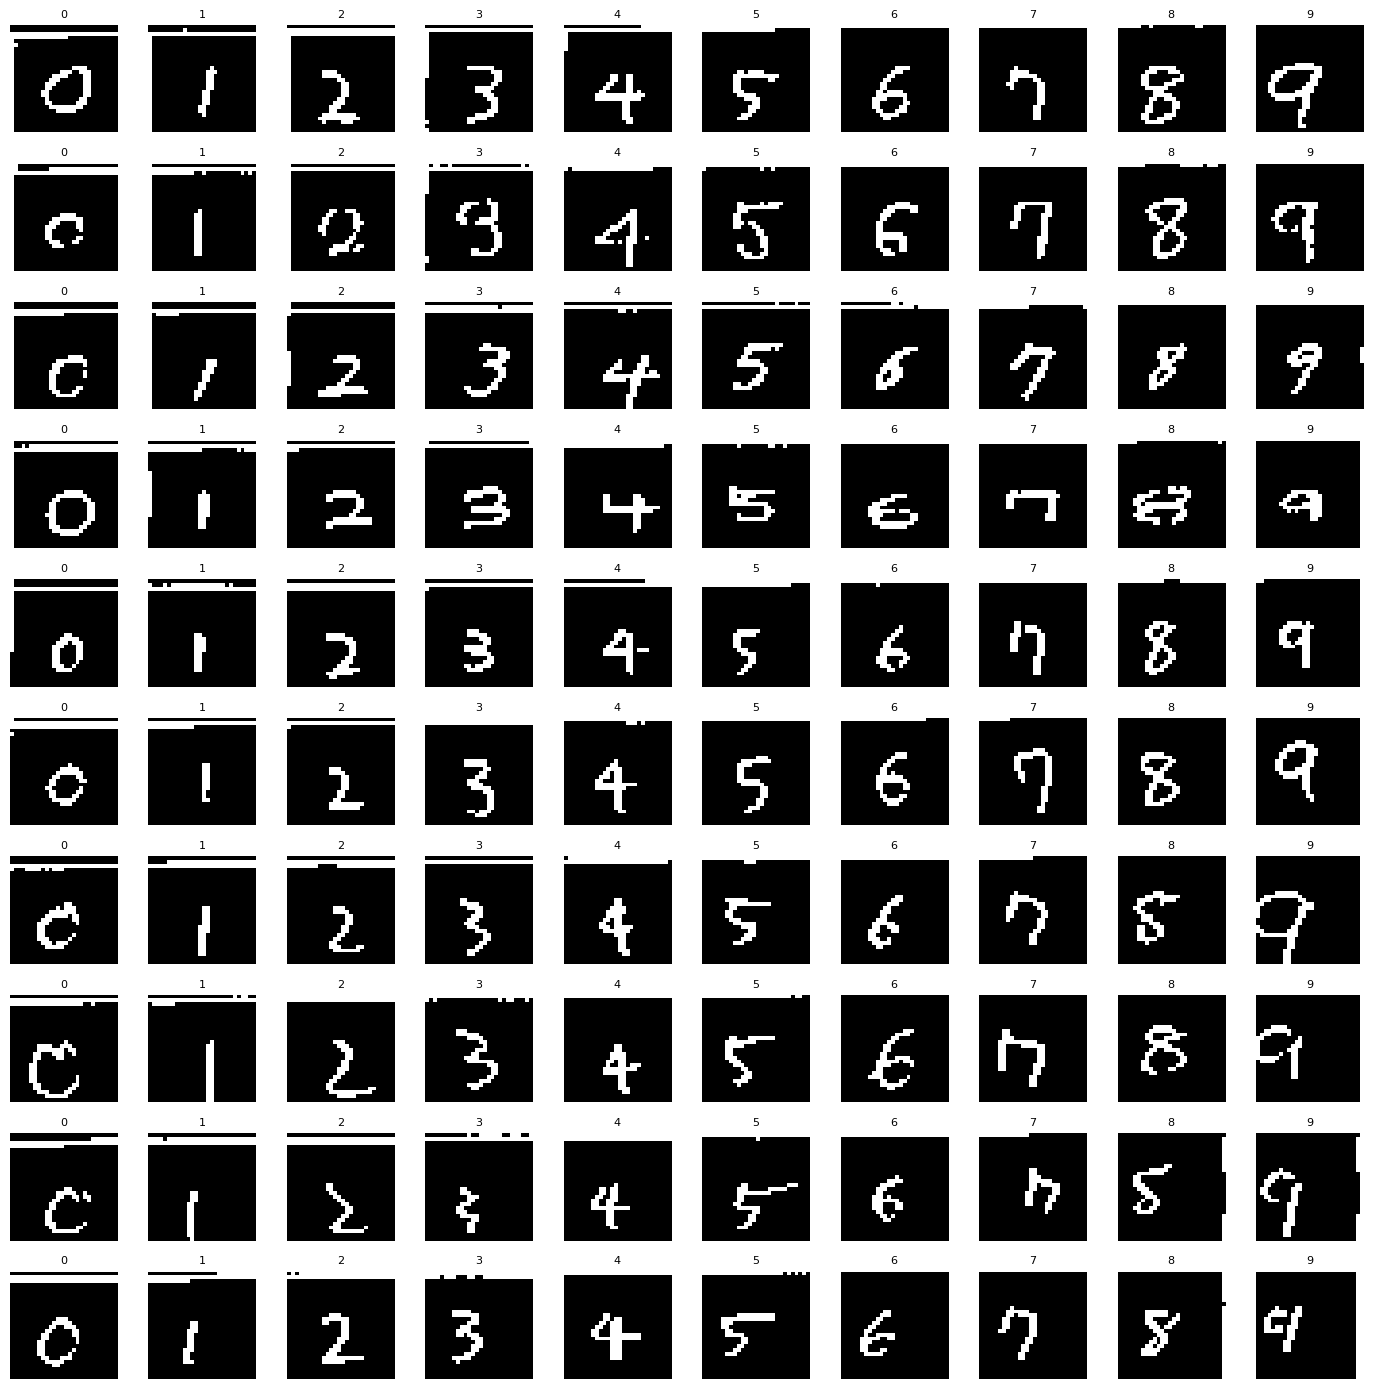


===== 페이지 39 / 95 | 이미지 3800 ~ 3899 =====


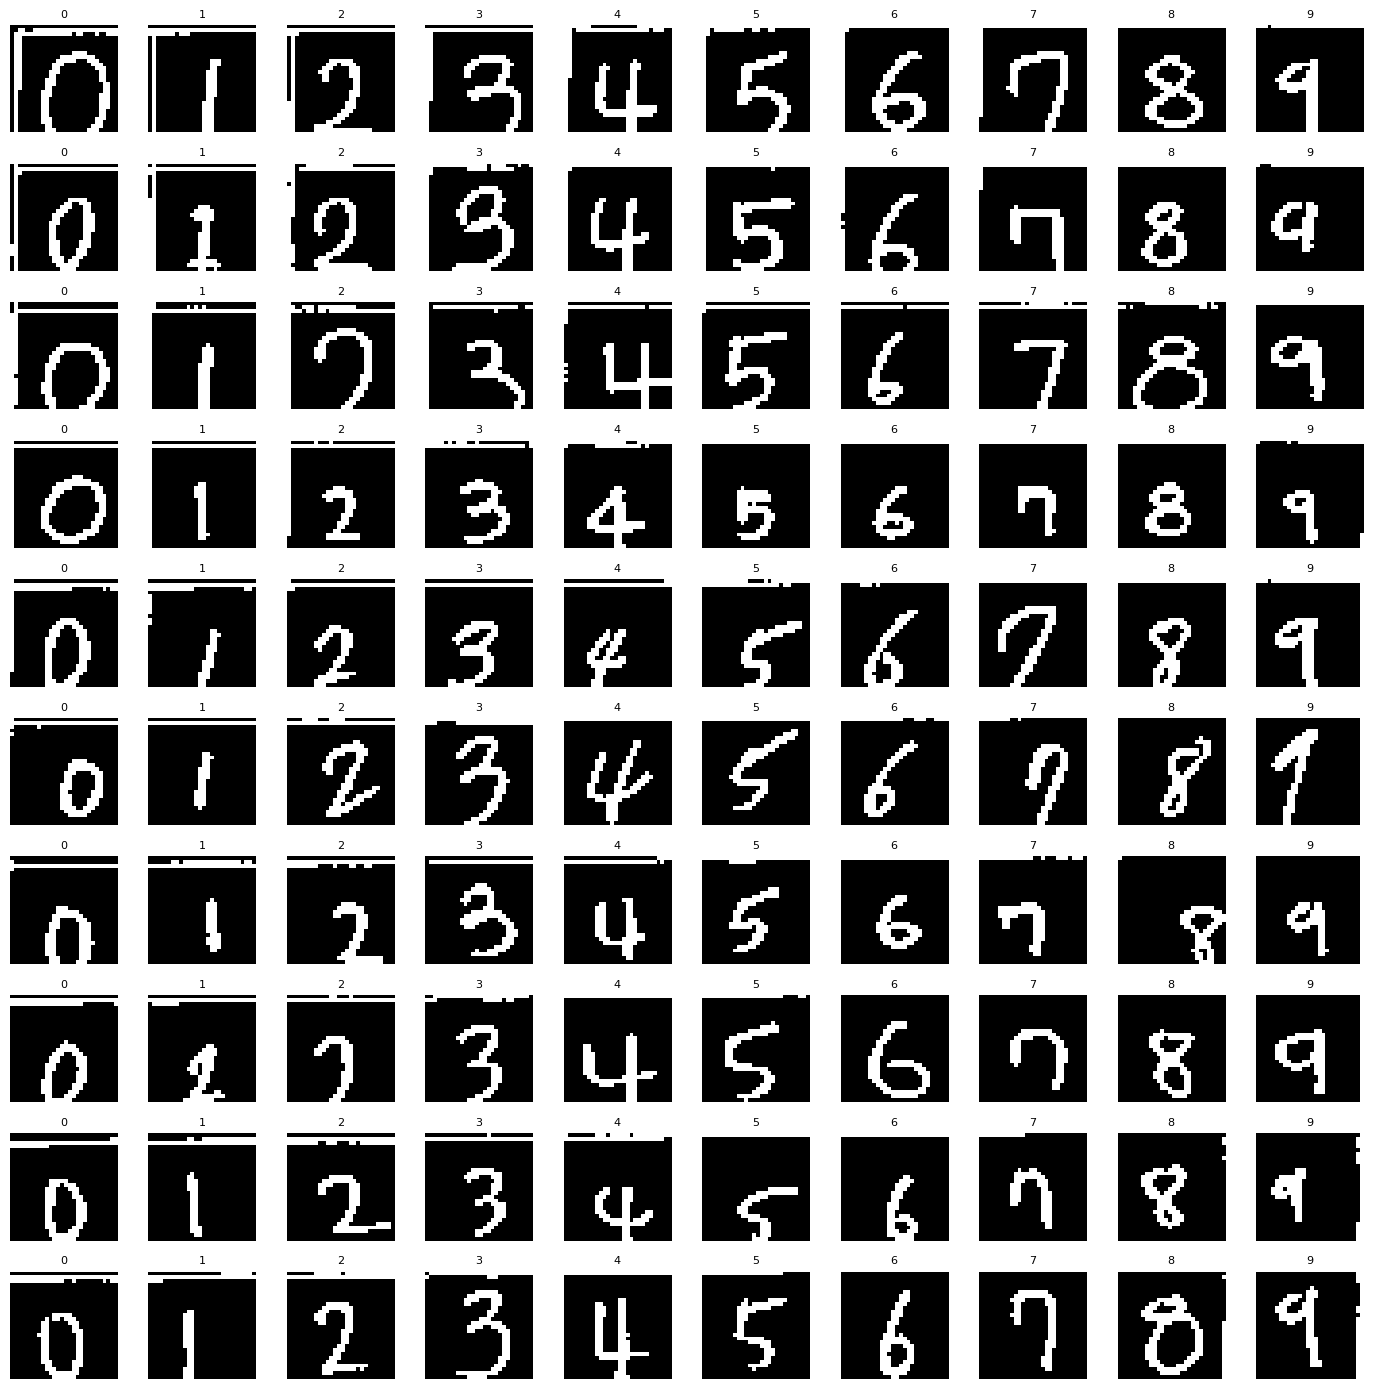


===== 페이지 40 / 95 | 이미지 3900 ~ 3999 =====


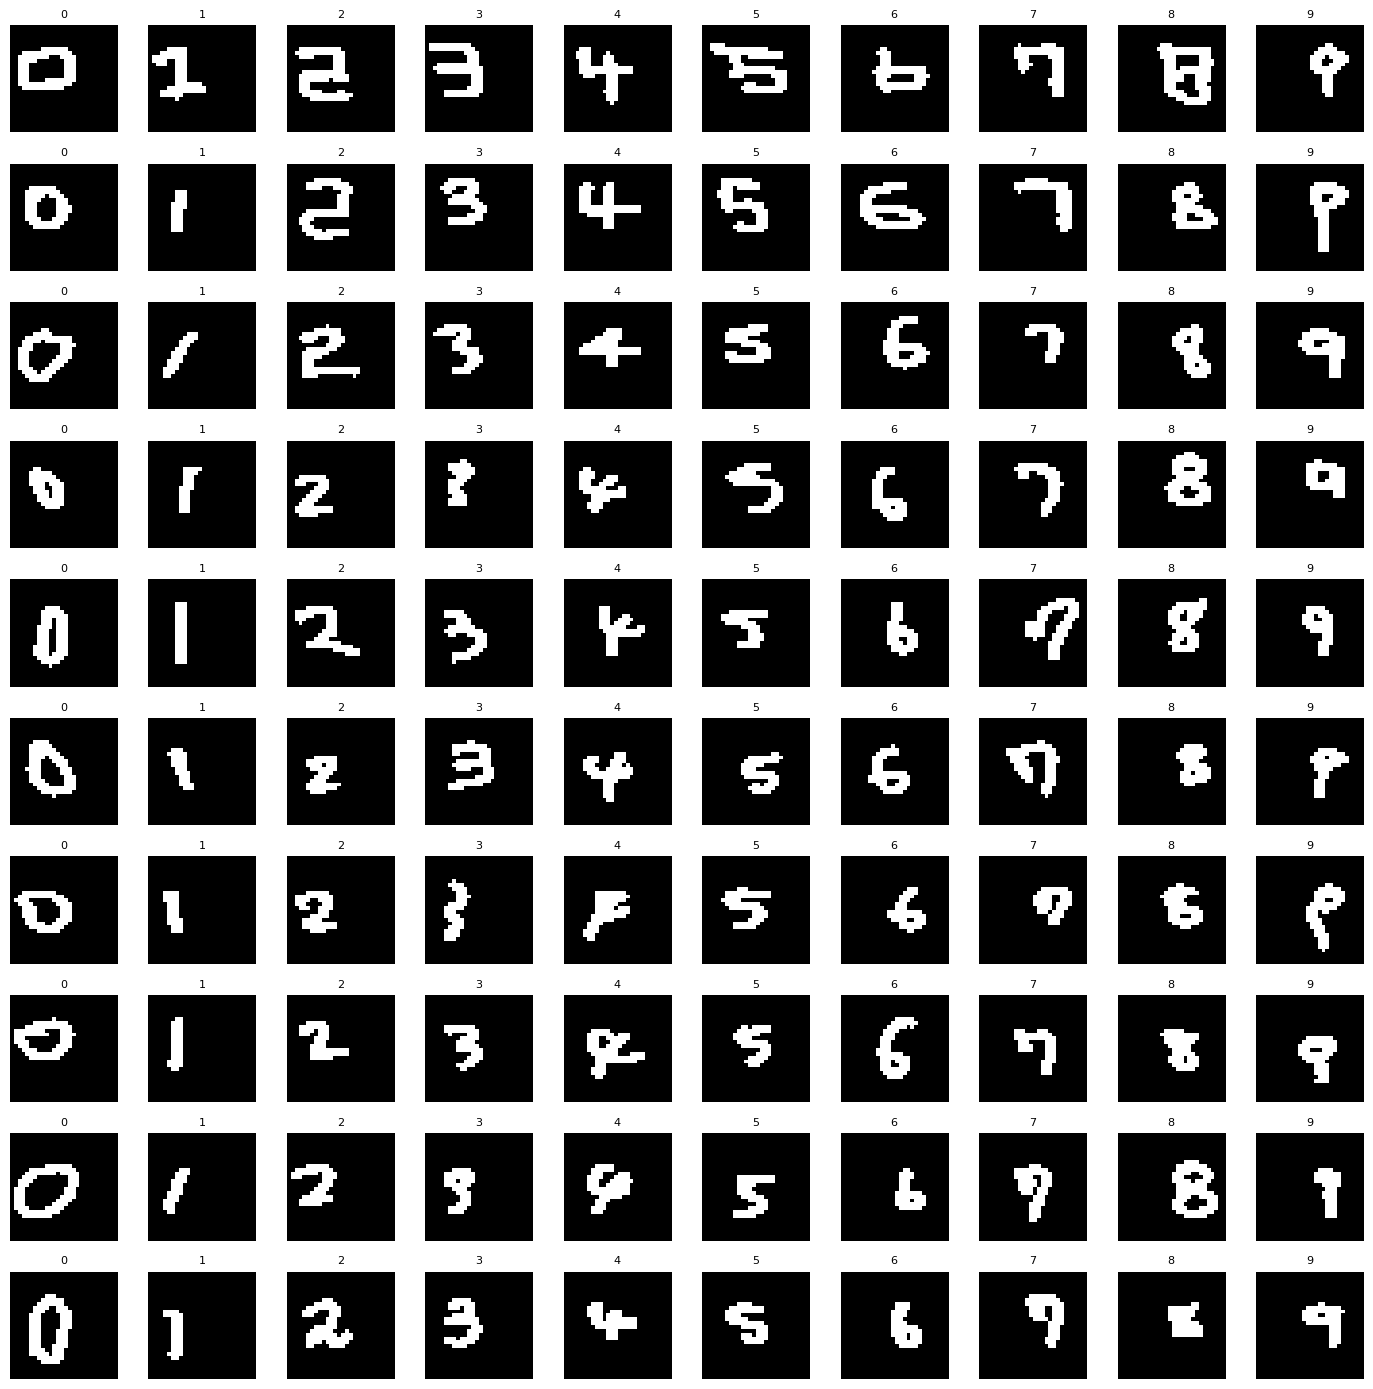


===== 페이지 41 / 95 | 이미지 4000 ~ 4099 =====


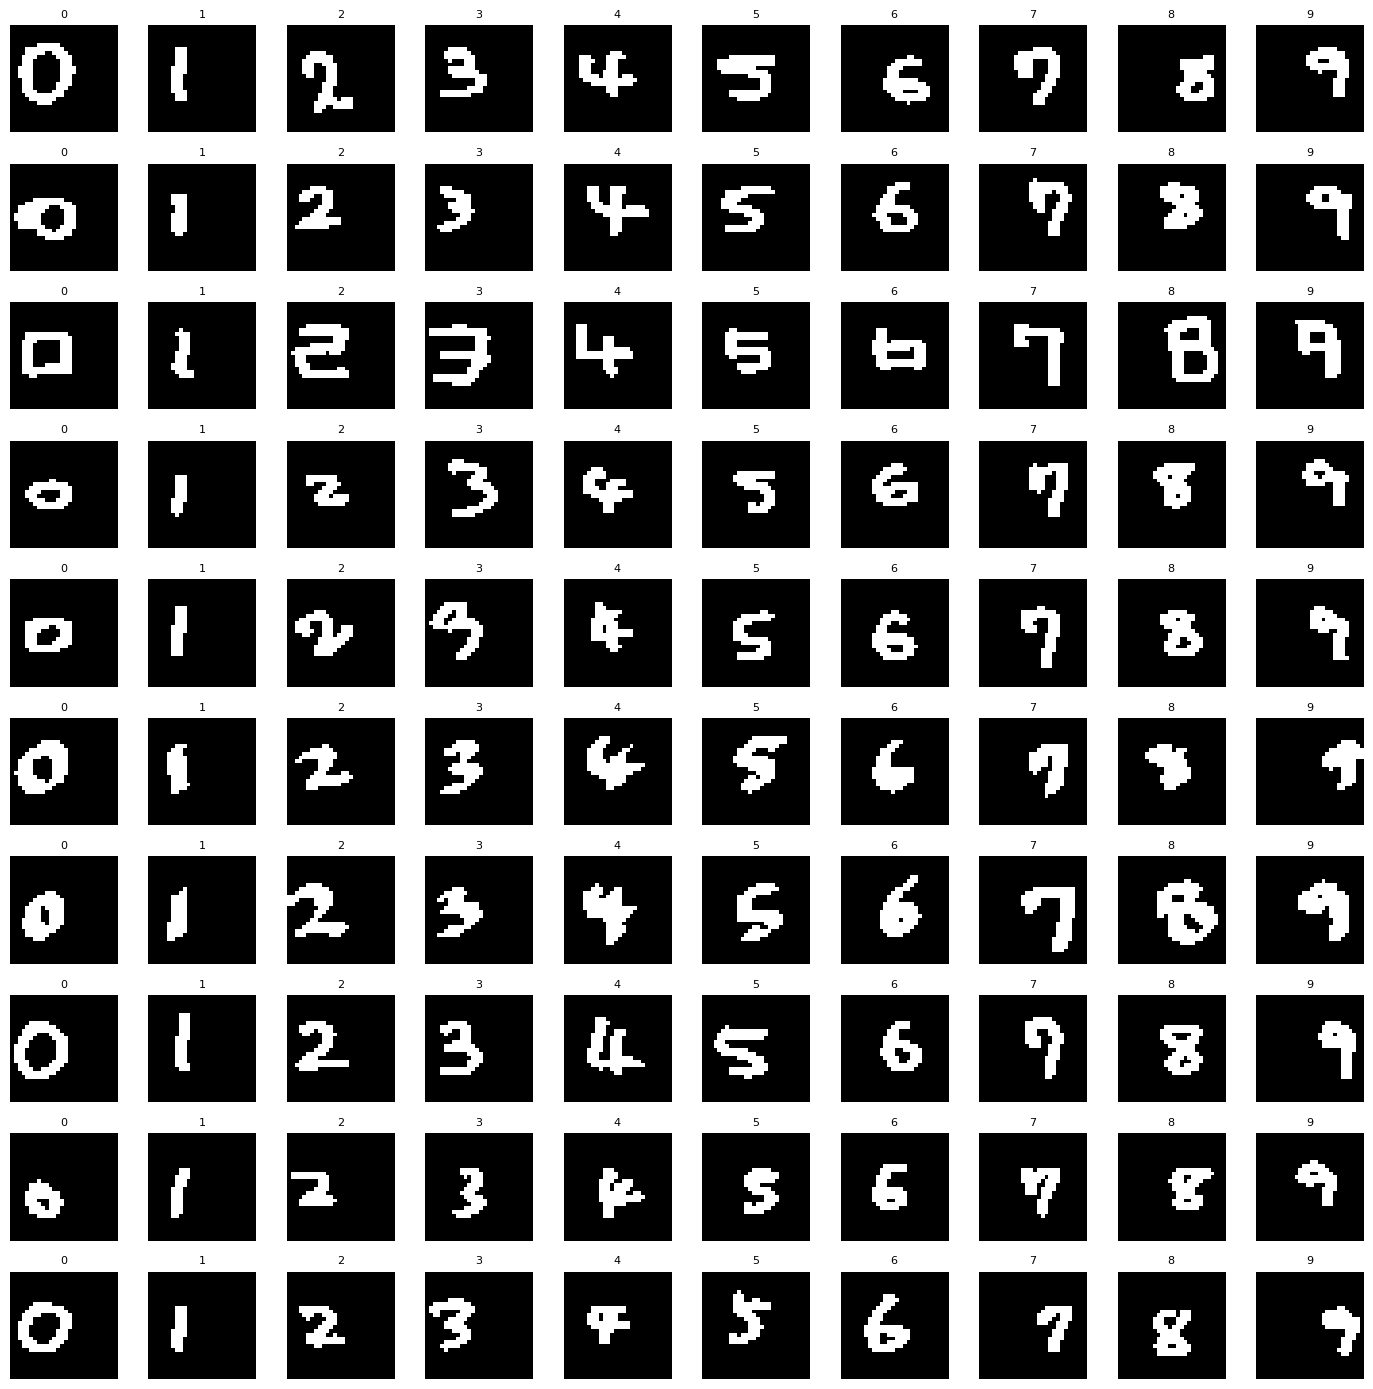


===== 페이지 42 / 95 | 이미지 4100 ~ 4199 =====


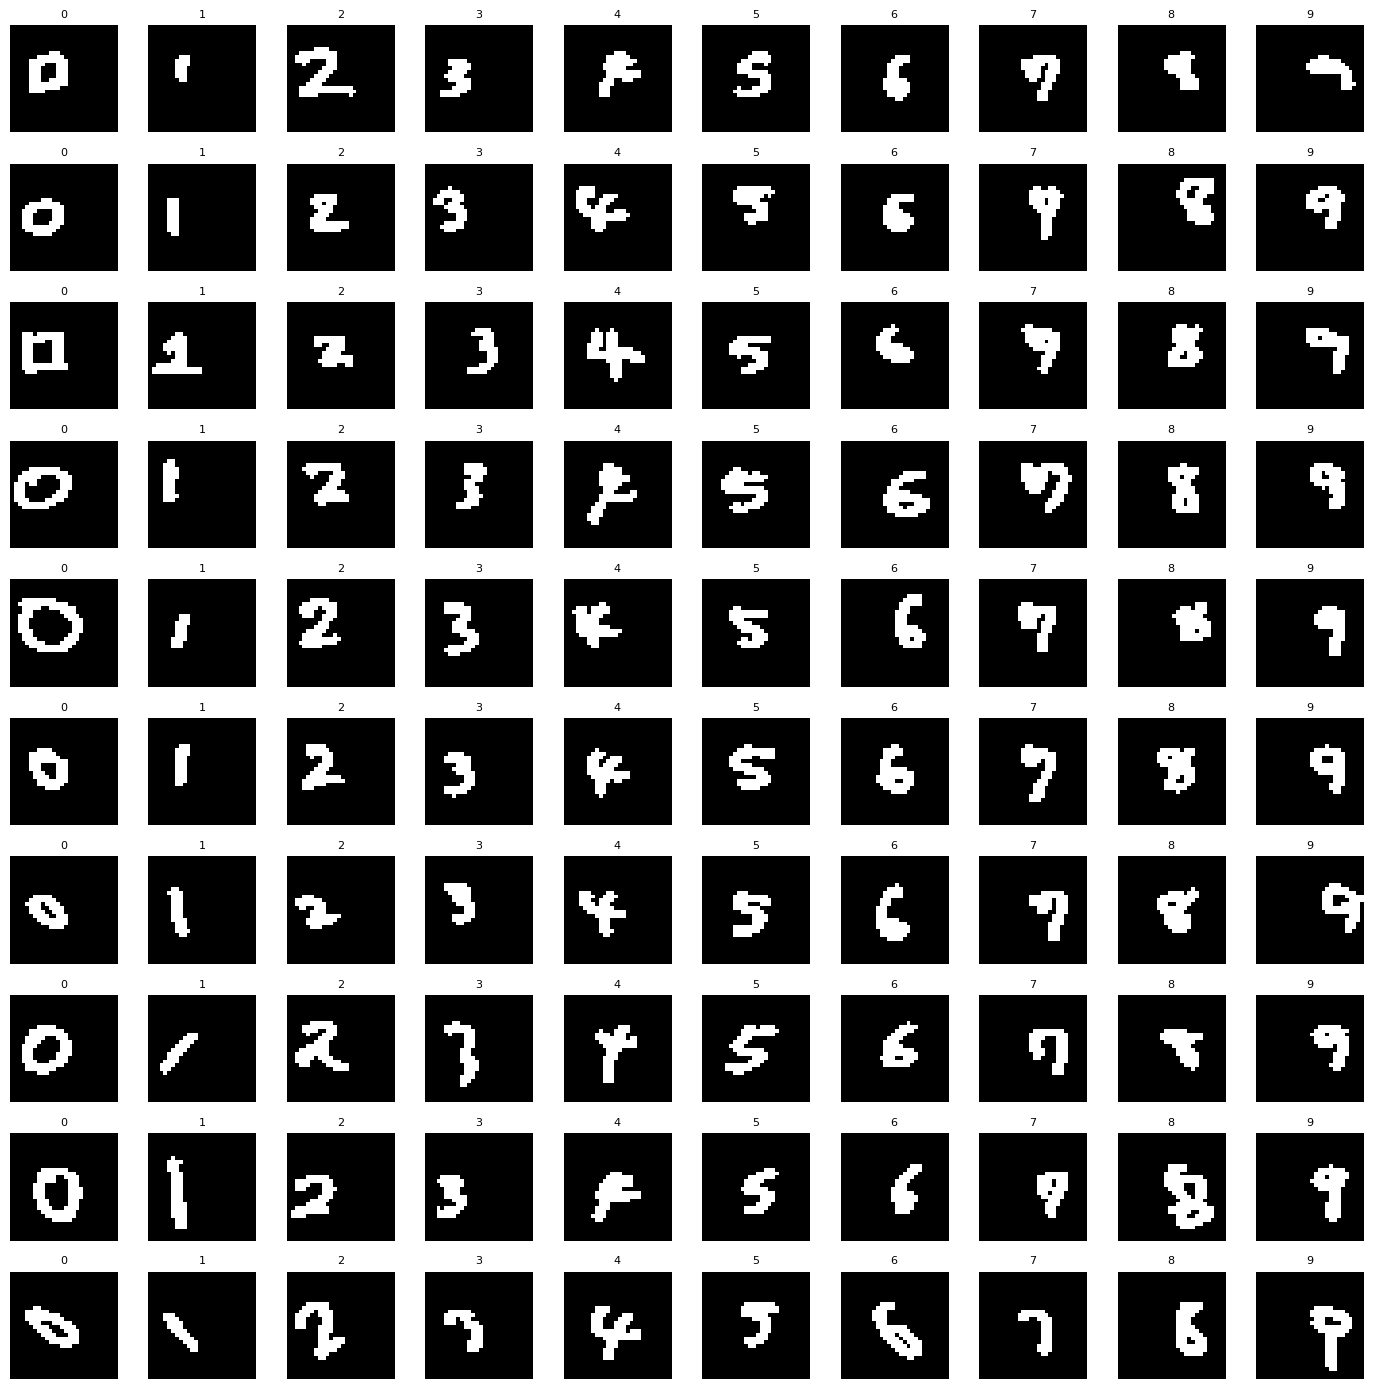


===== 페이지 43 / 95 | 이미지 4200 ~ 4299 =====


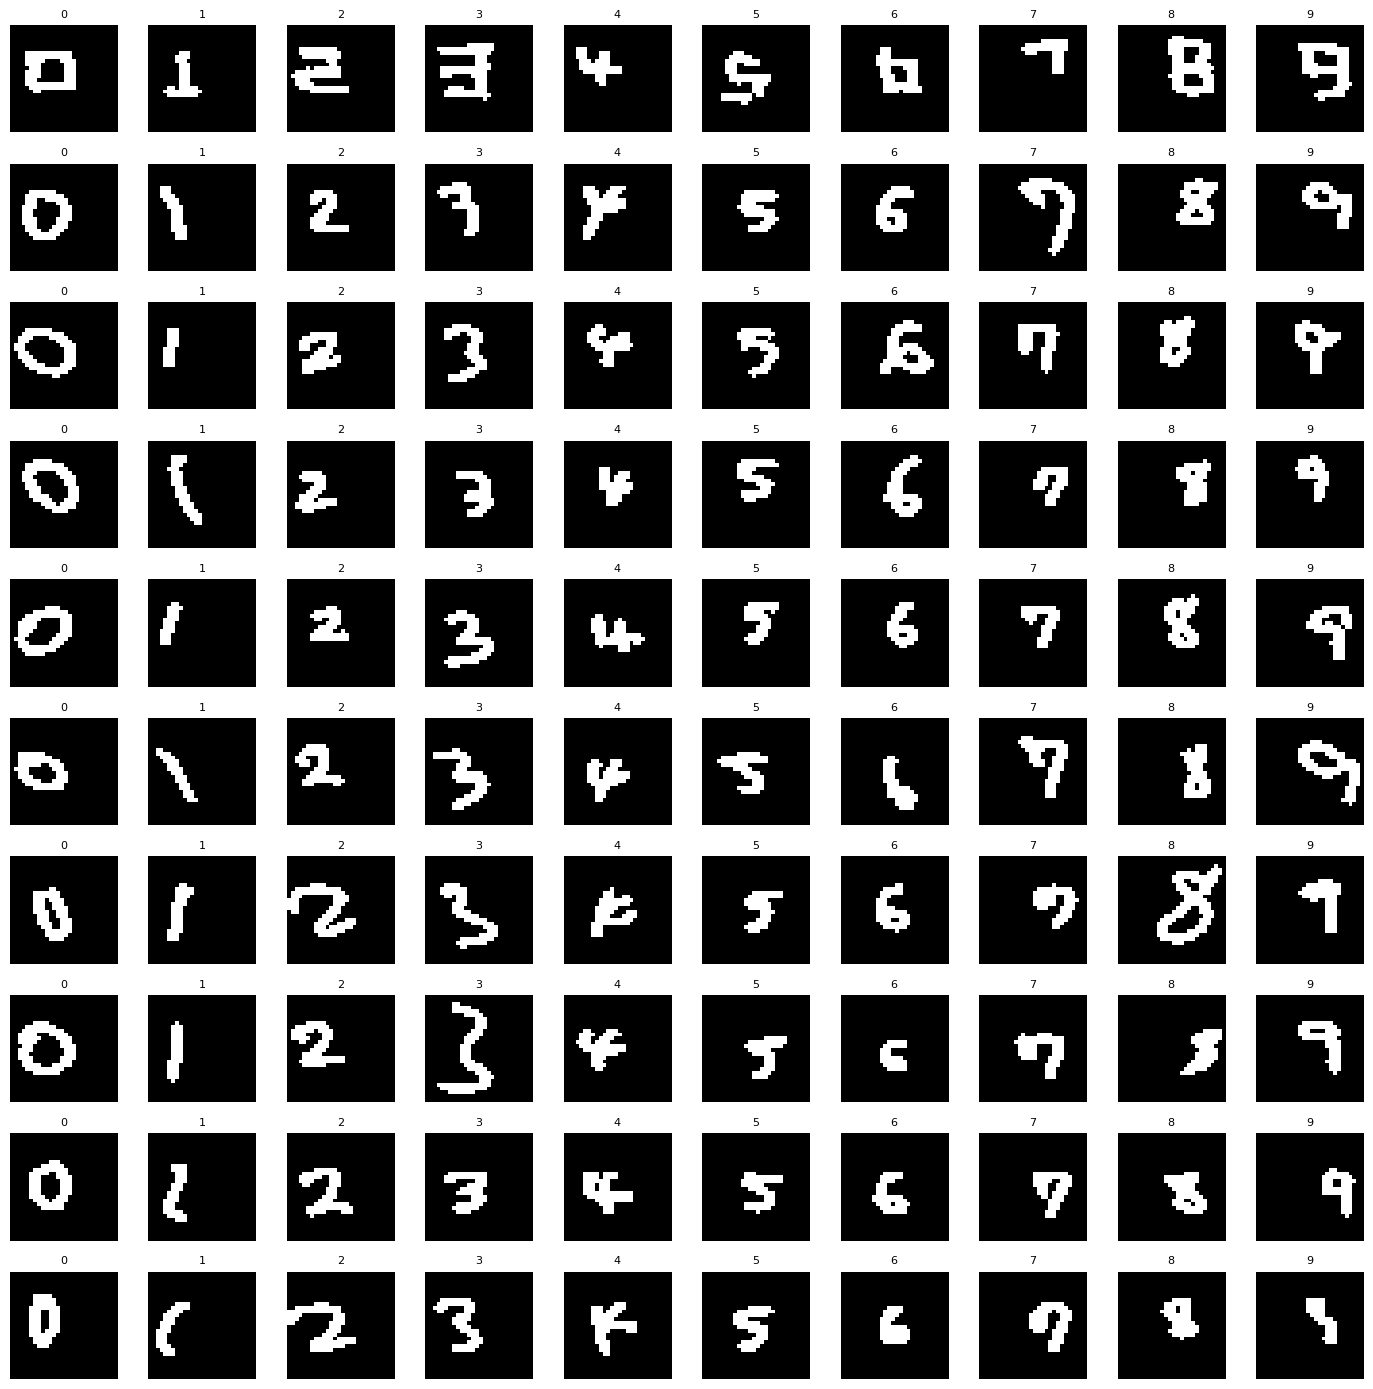


===== 페이지 44 / 95 | 이미지 4300 ~ 4399 =====


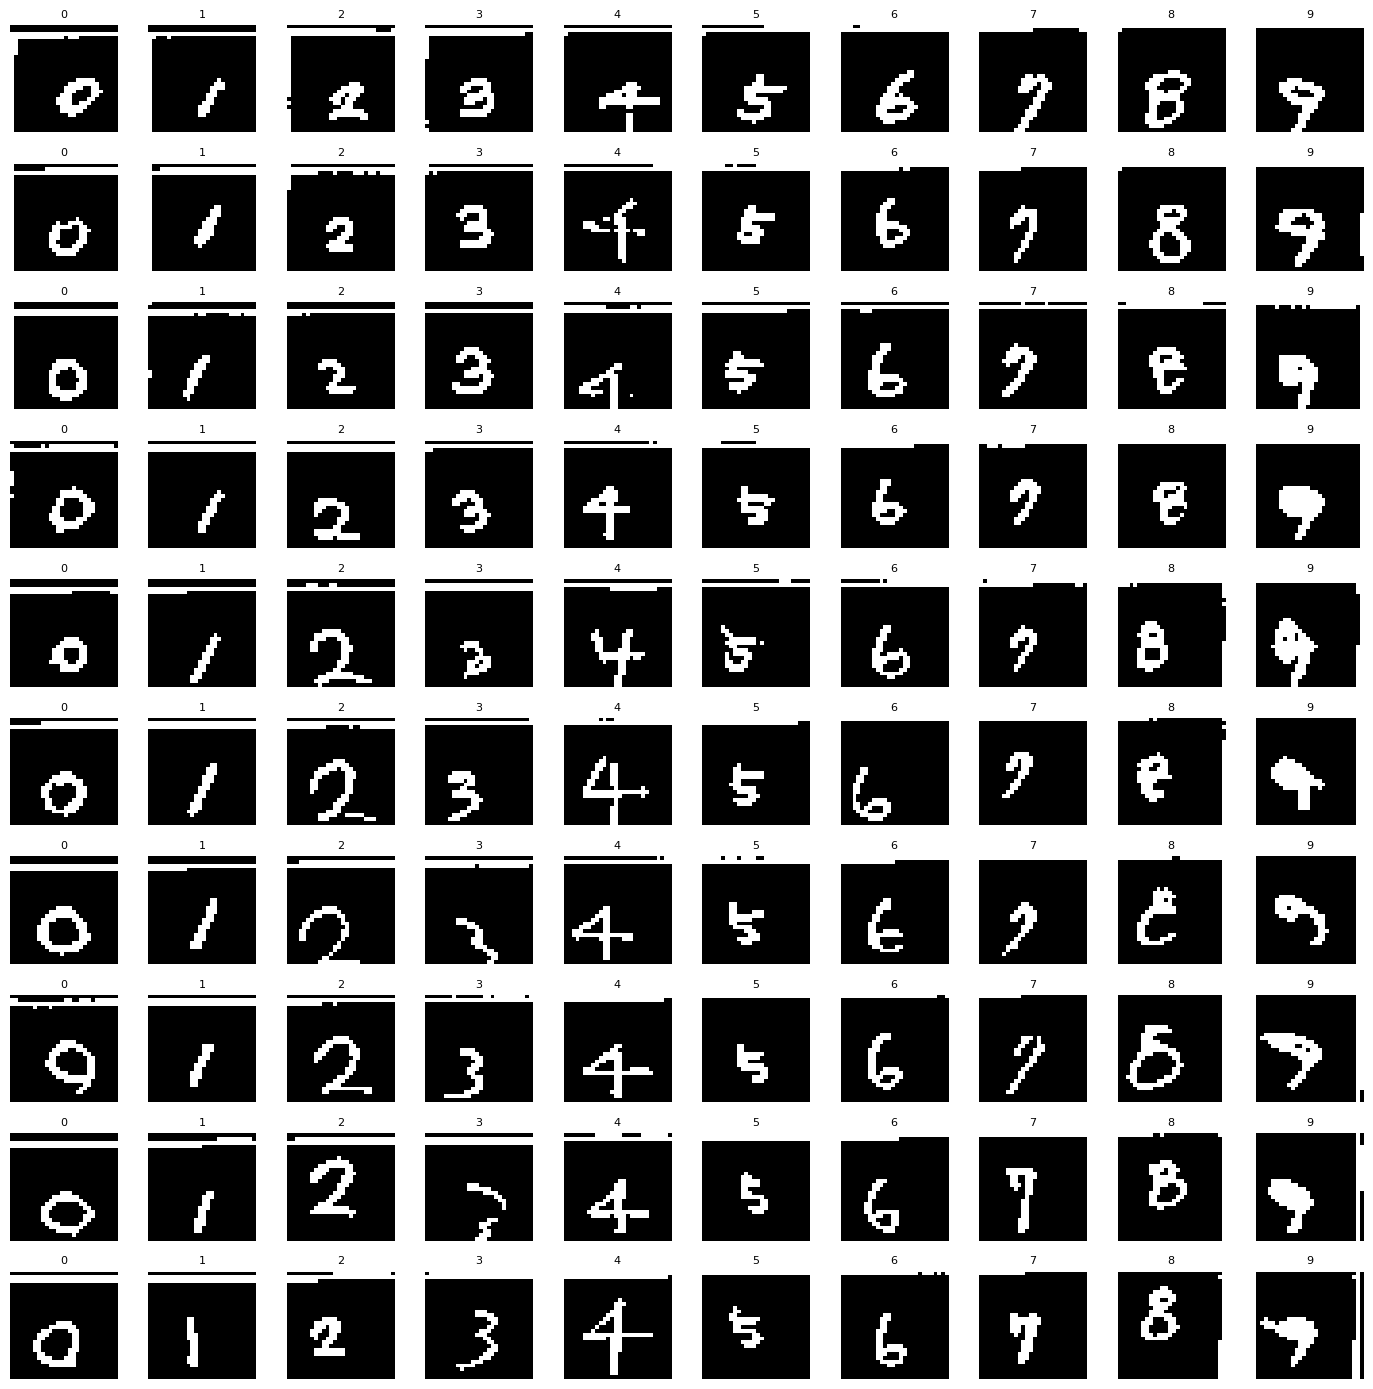


===== 페이지 45 / 95 | 이미지 4400 ~ 4499 =====


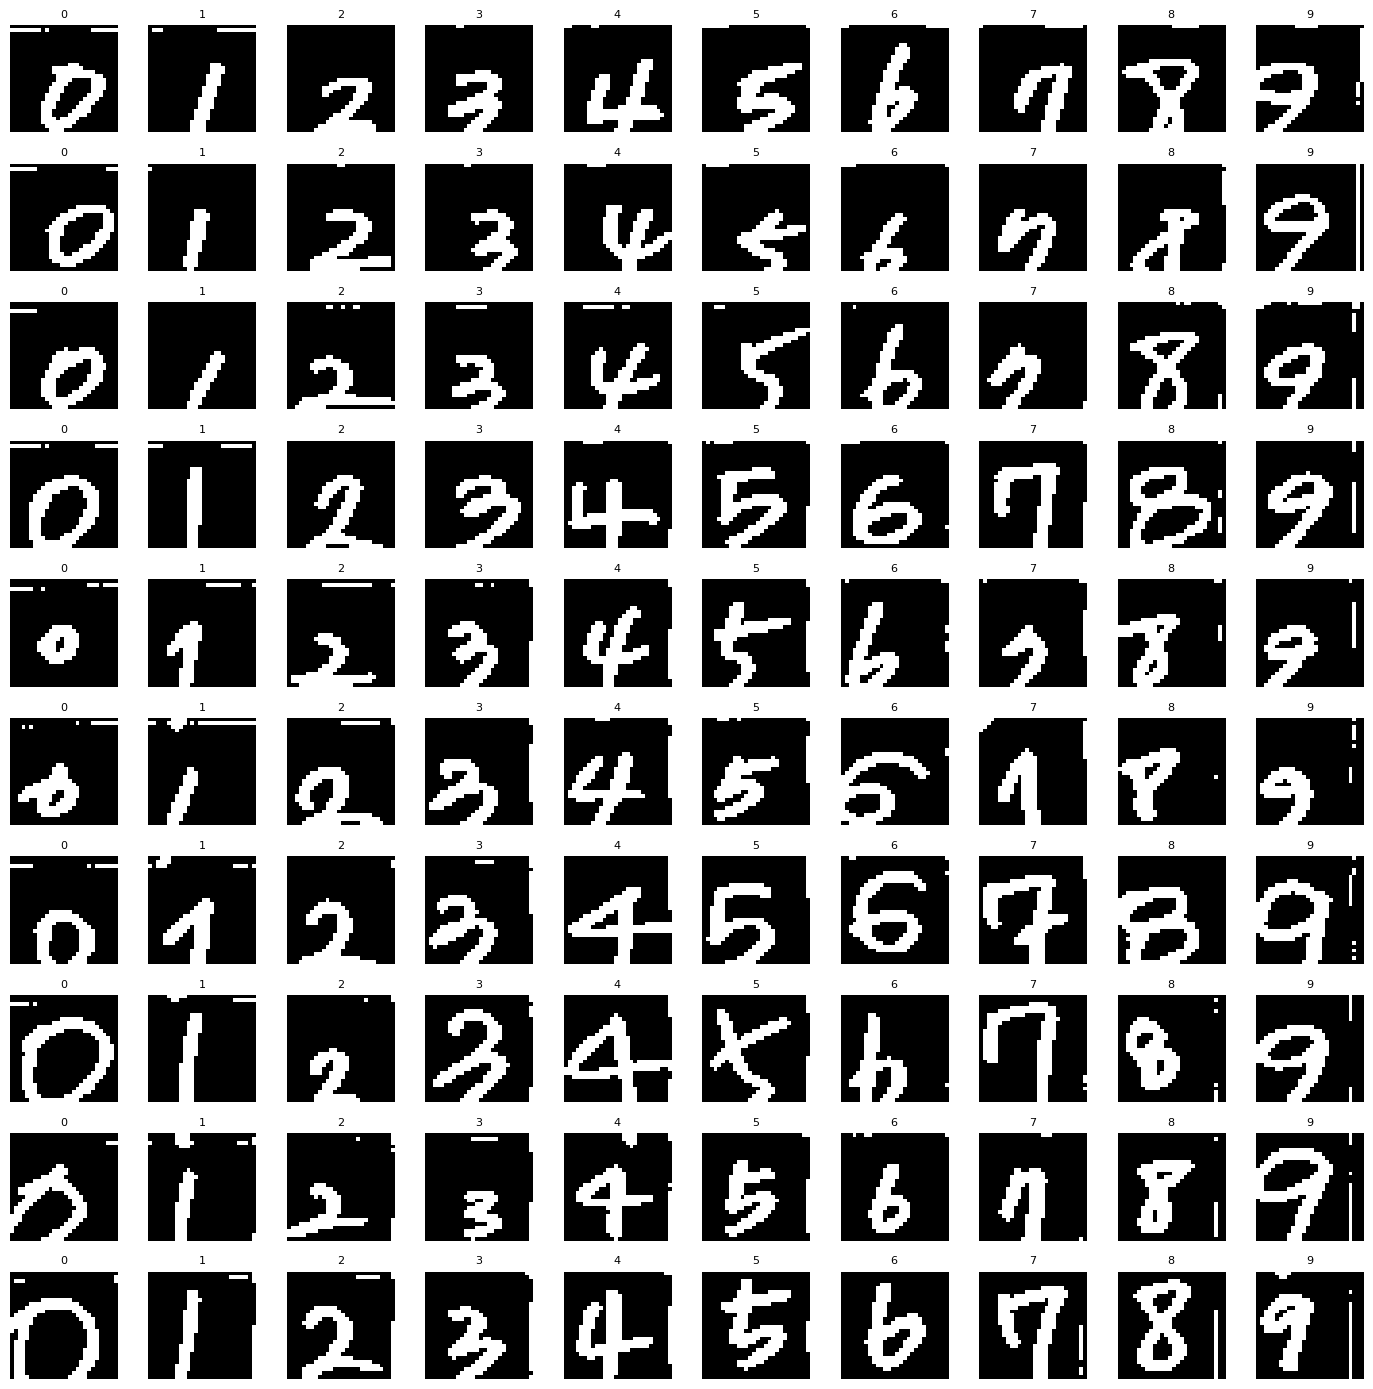


===== 페이지 46 / 95 | 이미지 4500 ~ 4599 =====


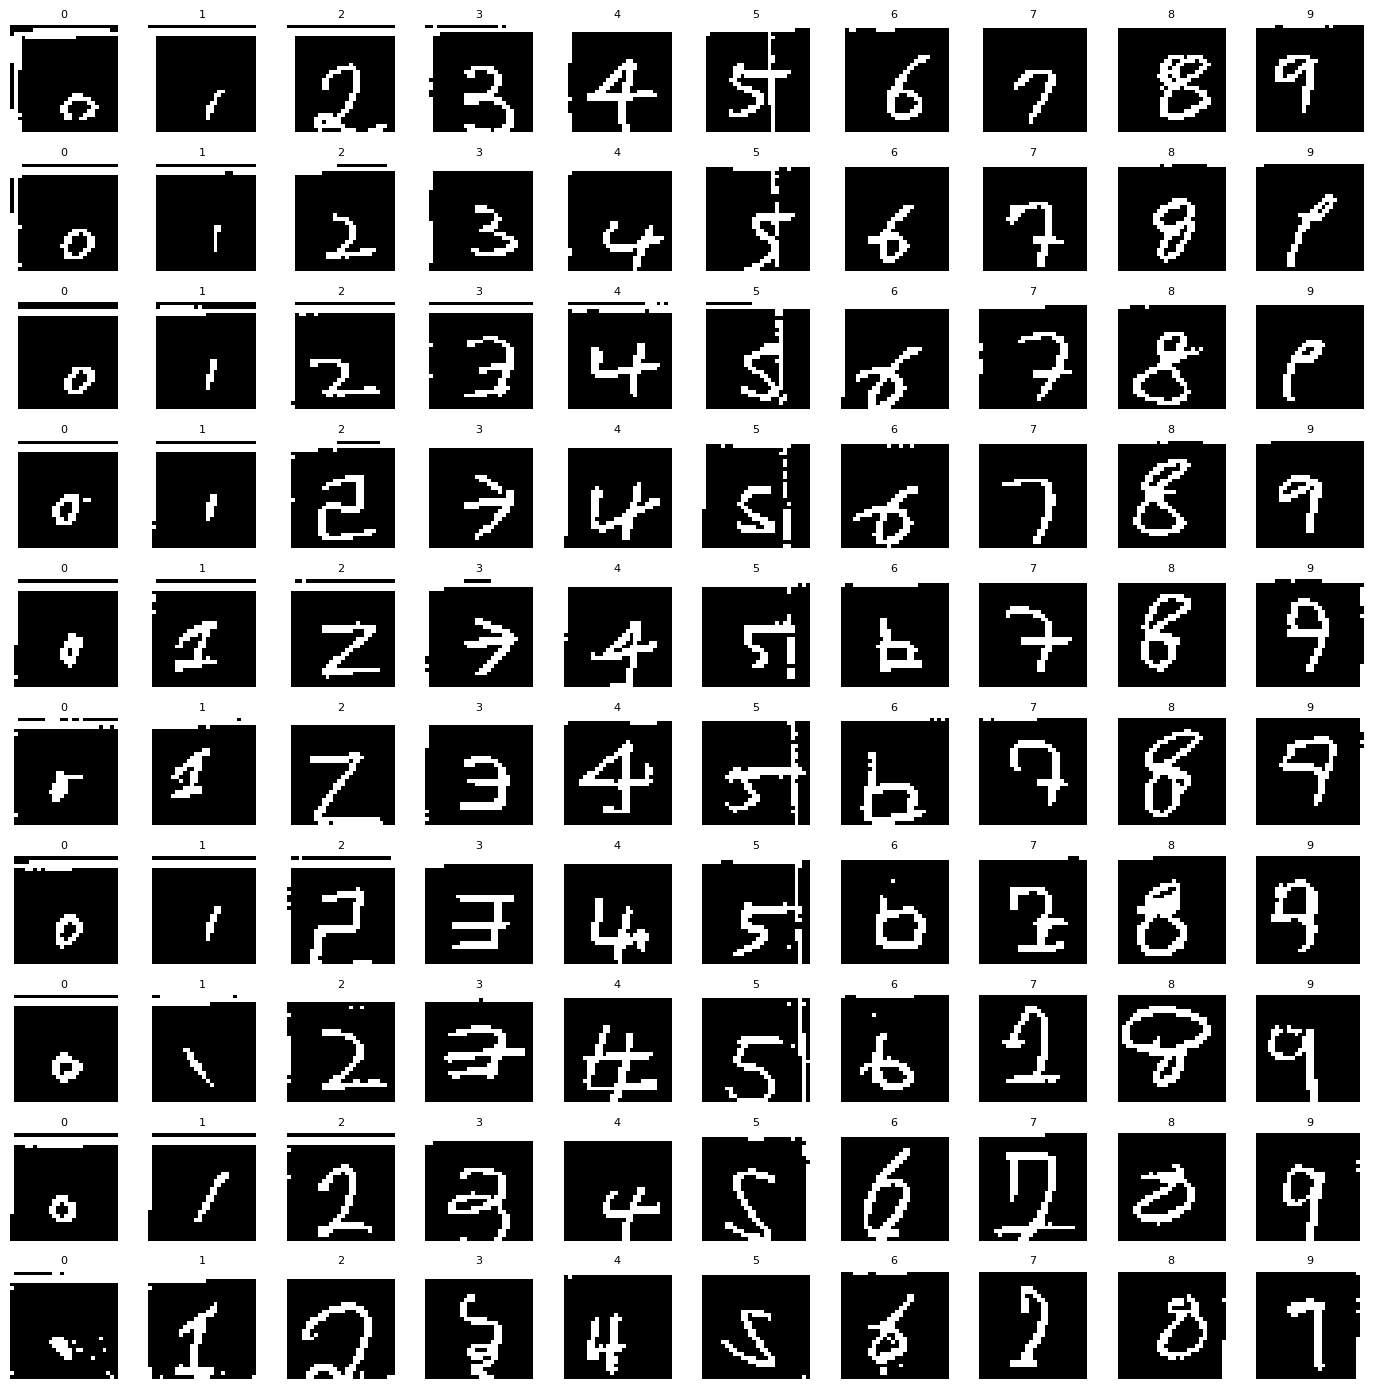


===== 페이지 47 / 95 | 이미지 4600 ~ 4699 =====


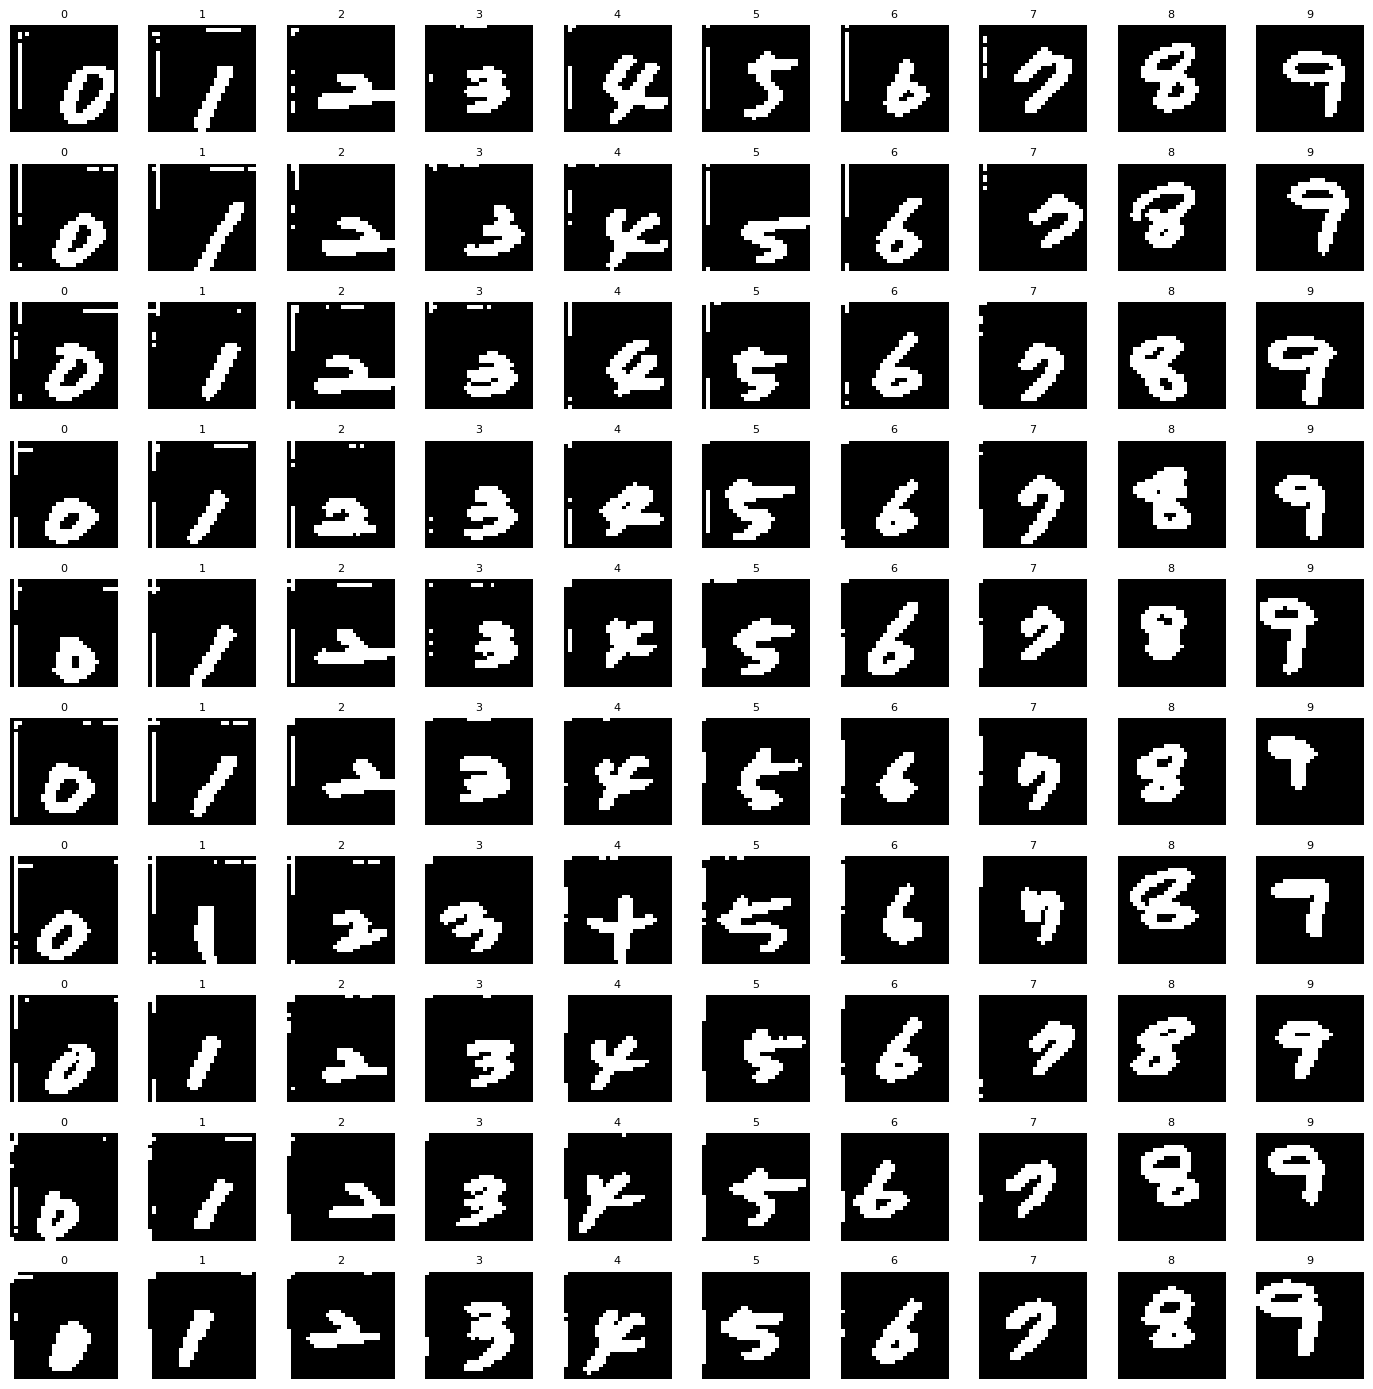


===== 페이지 48 / 95 | 이미지 4700 ~ 4799 =====


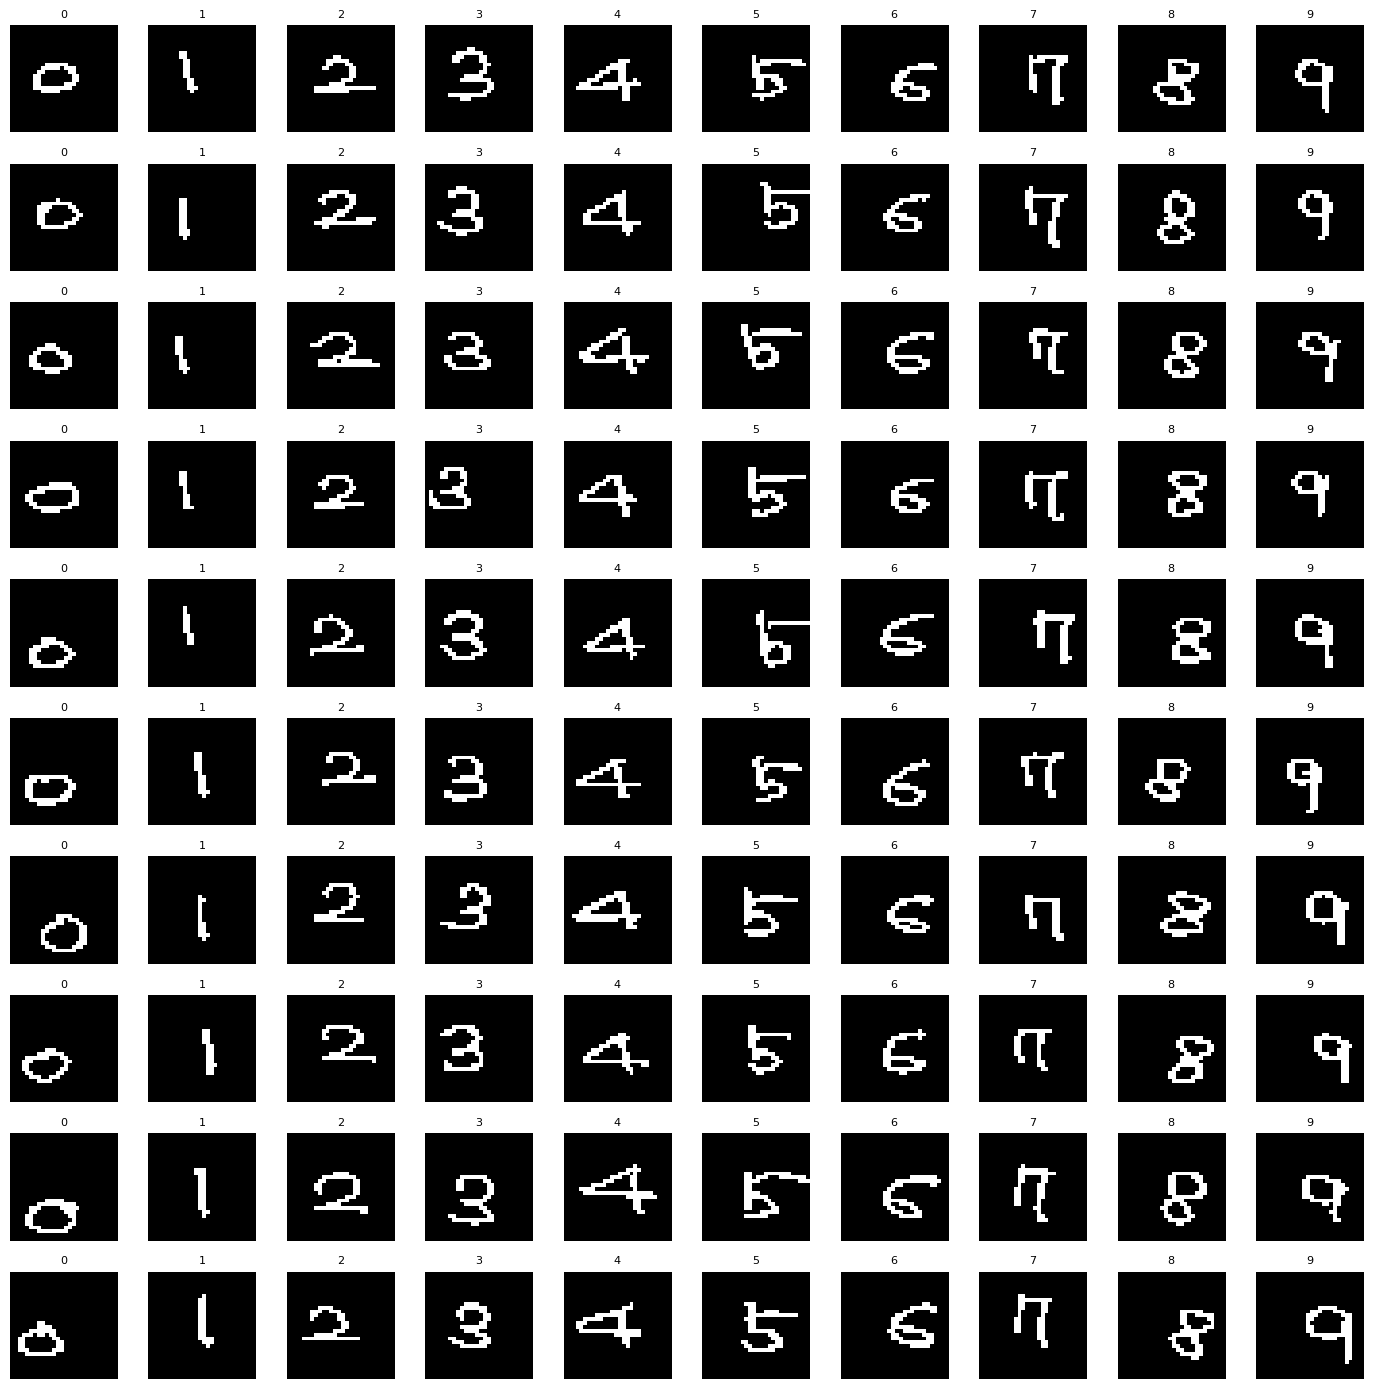


===== 페이지 49 / 95 | 이미지 4800 ~ 4899 =====


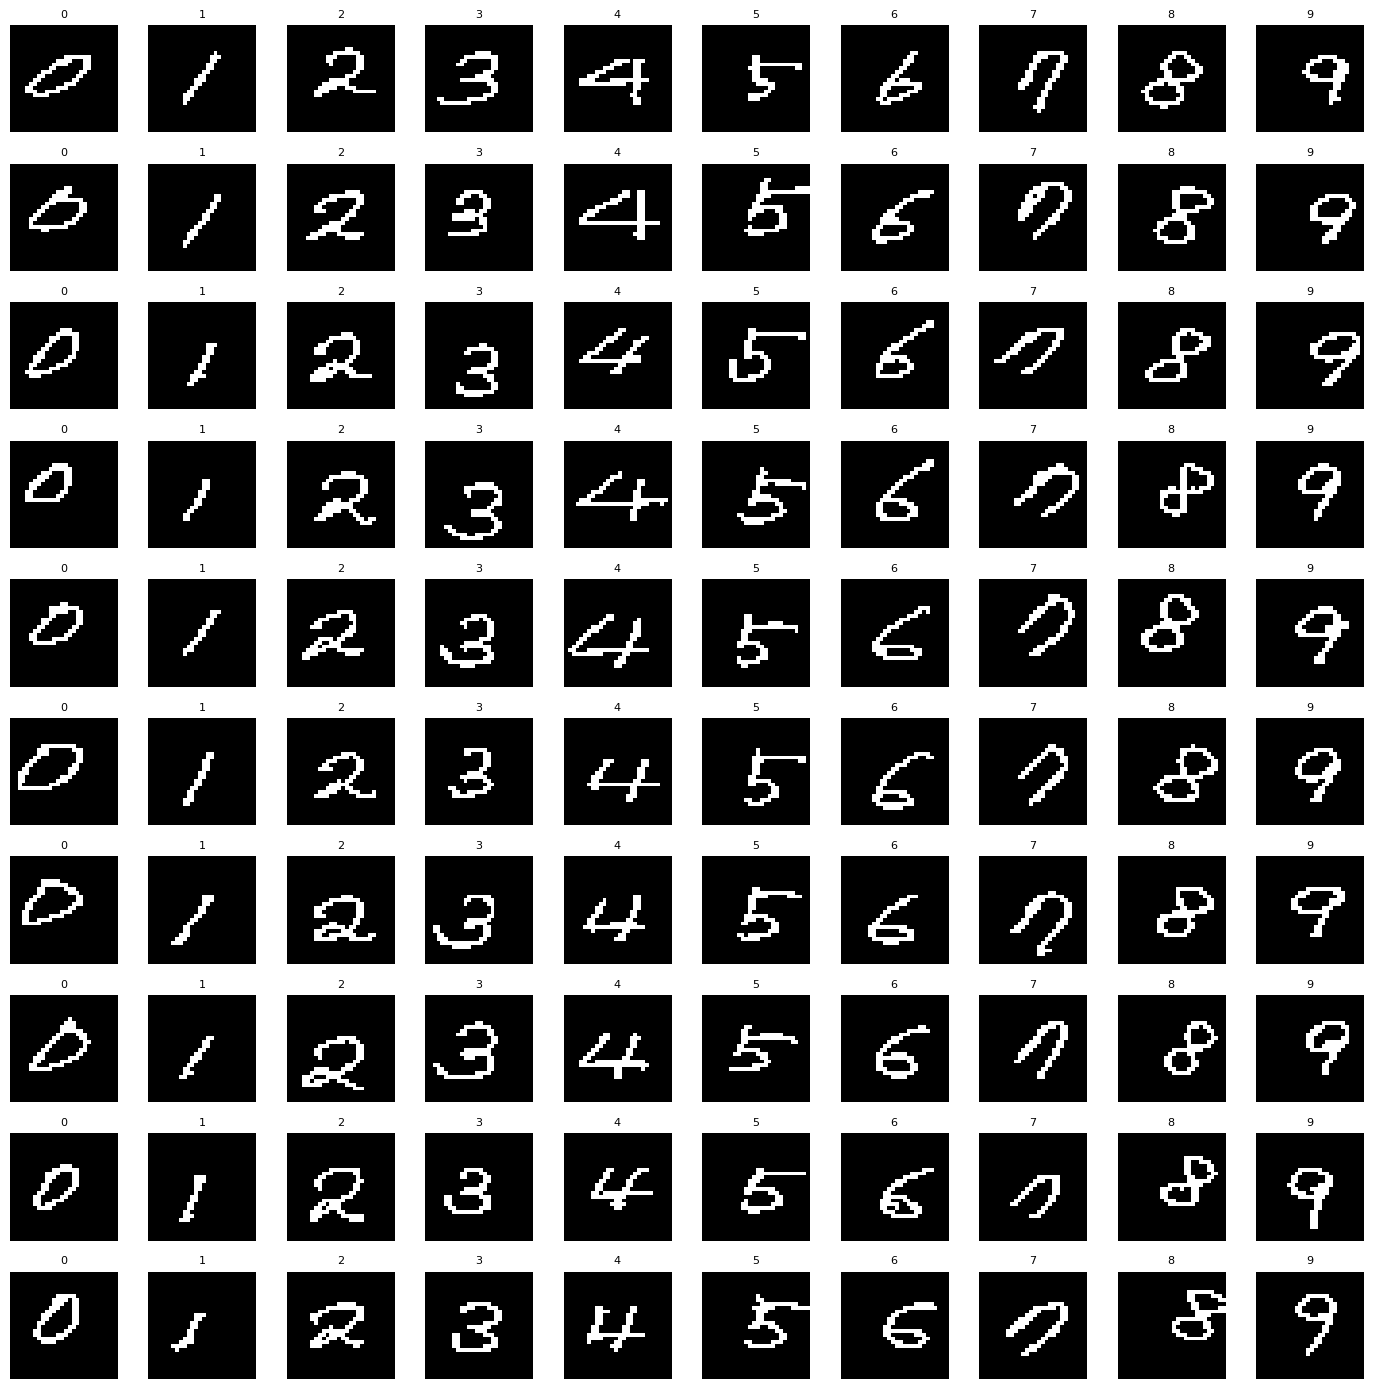


===== 페이지 50 / 95 | 이미지 4900 ~ 4999 =====


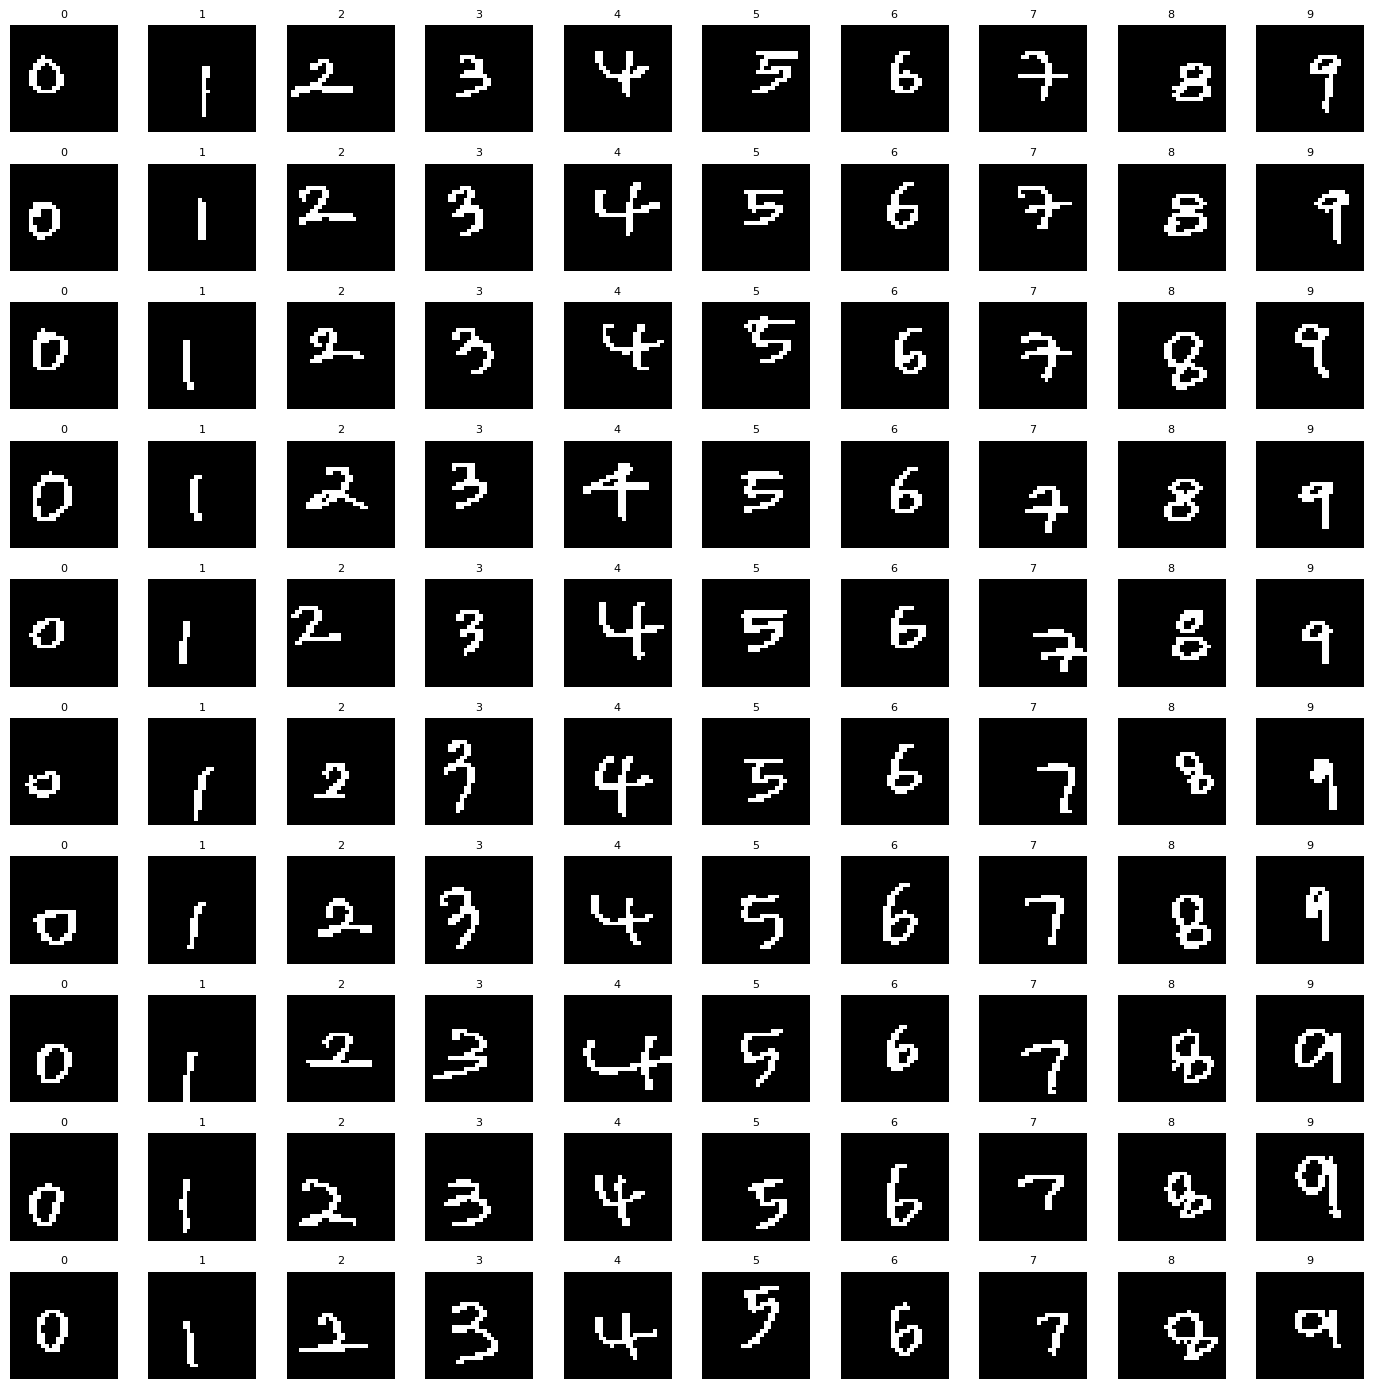


===== 페이지 51 / 95 | 이미지 5000 ~ 5099 =====


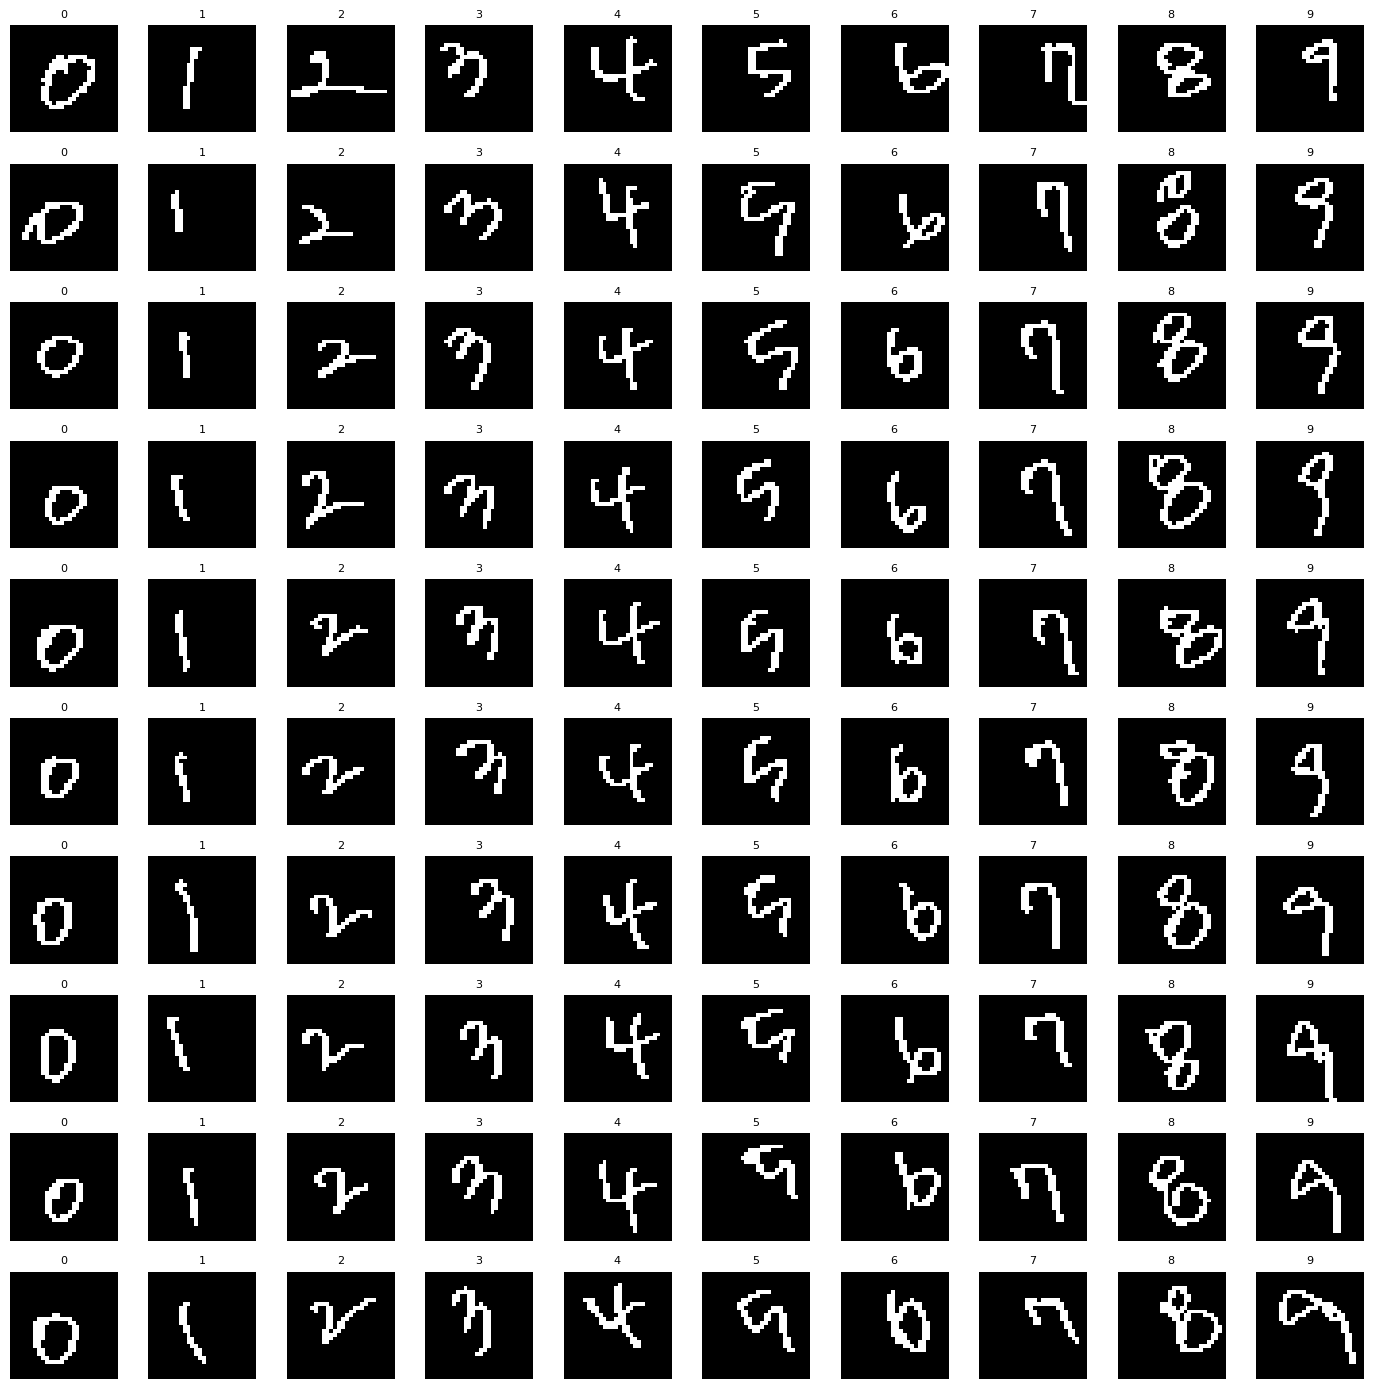


===== 페이지 52 / 95 | 이미지 5100 ~ 5199 =====


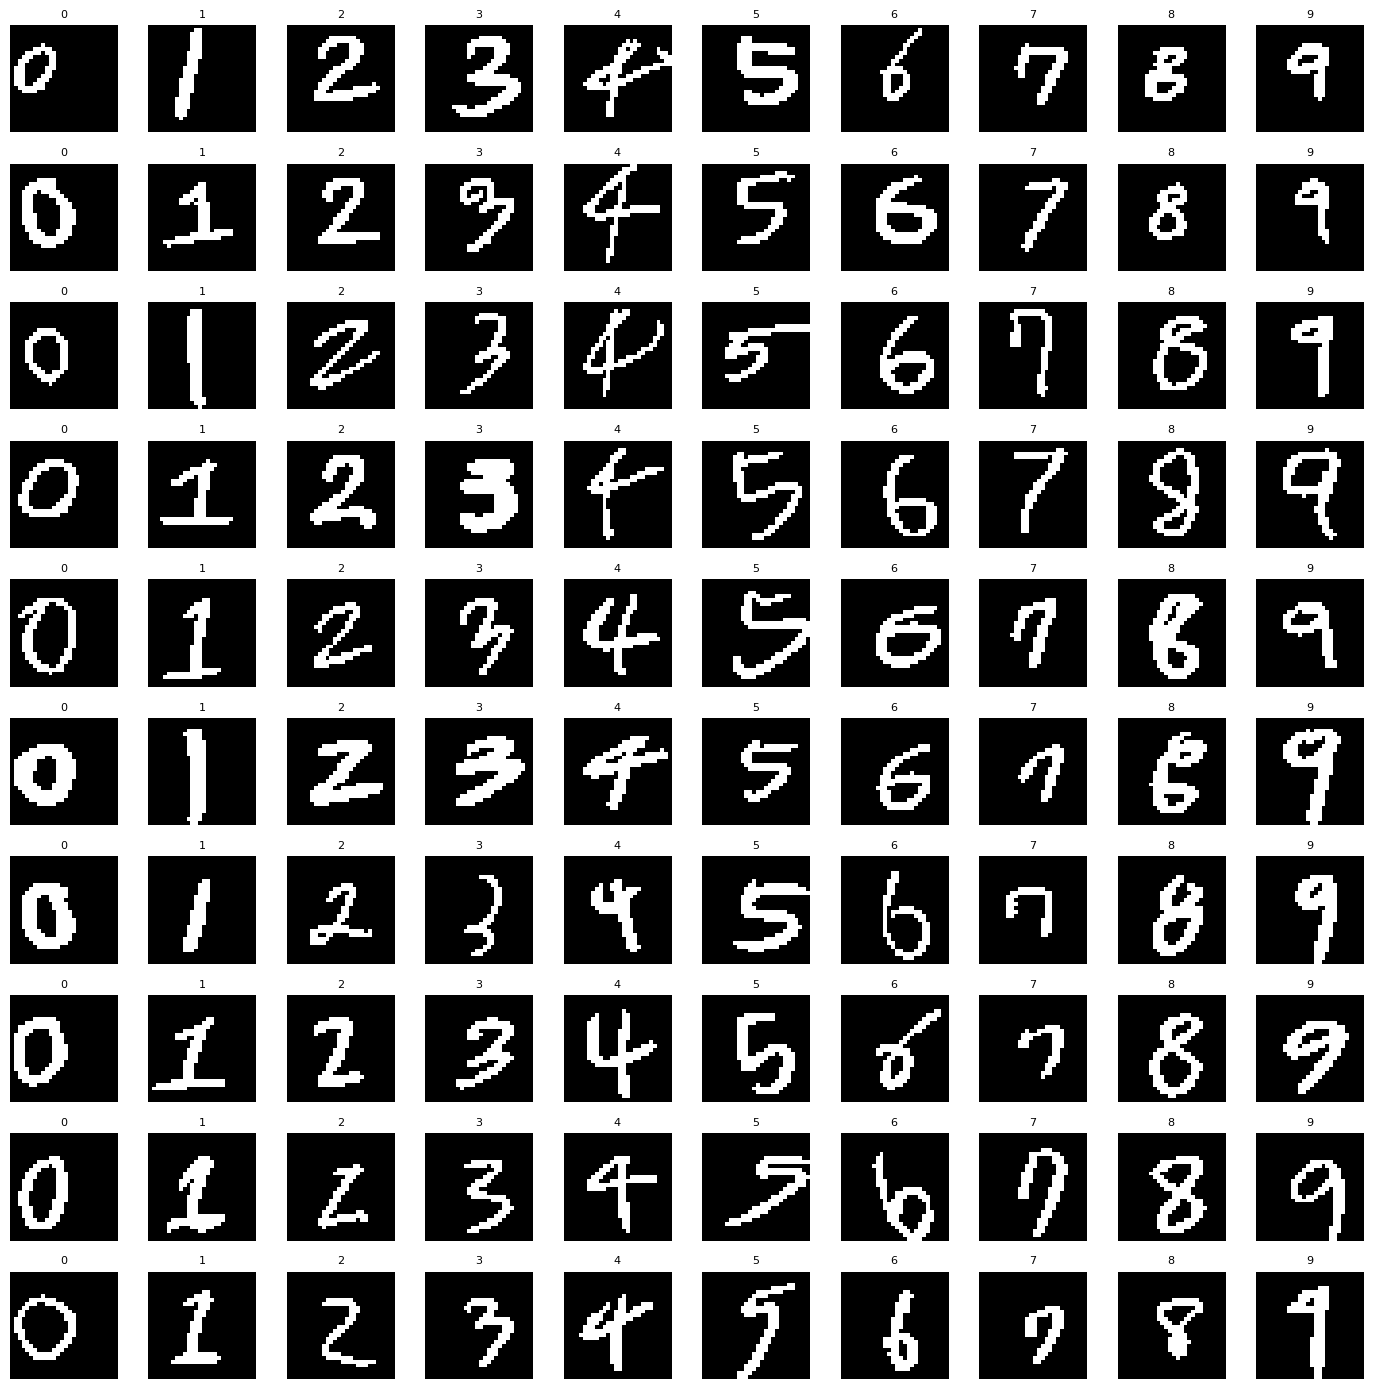


===== 페이지 53 / 95 | 이미지 5200 ~ 5299 =====


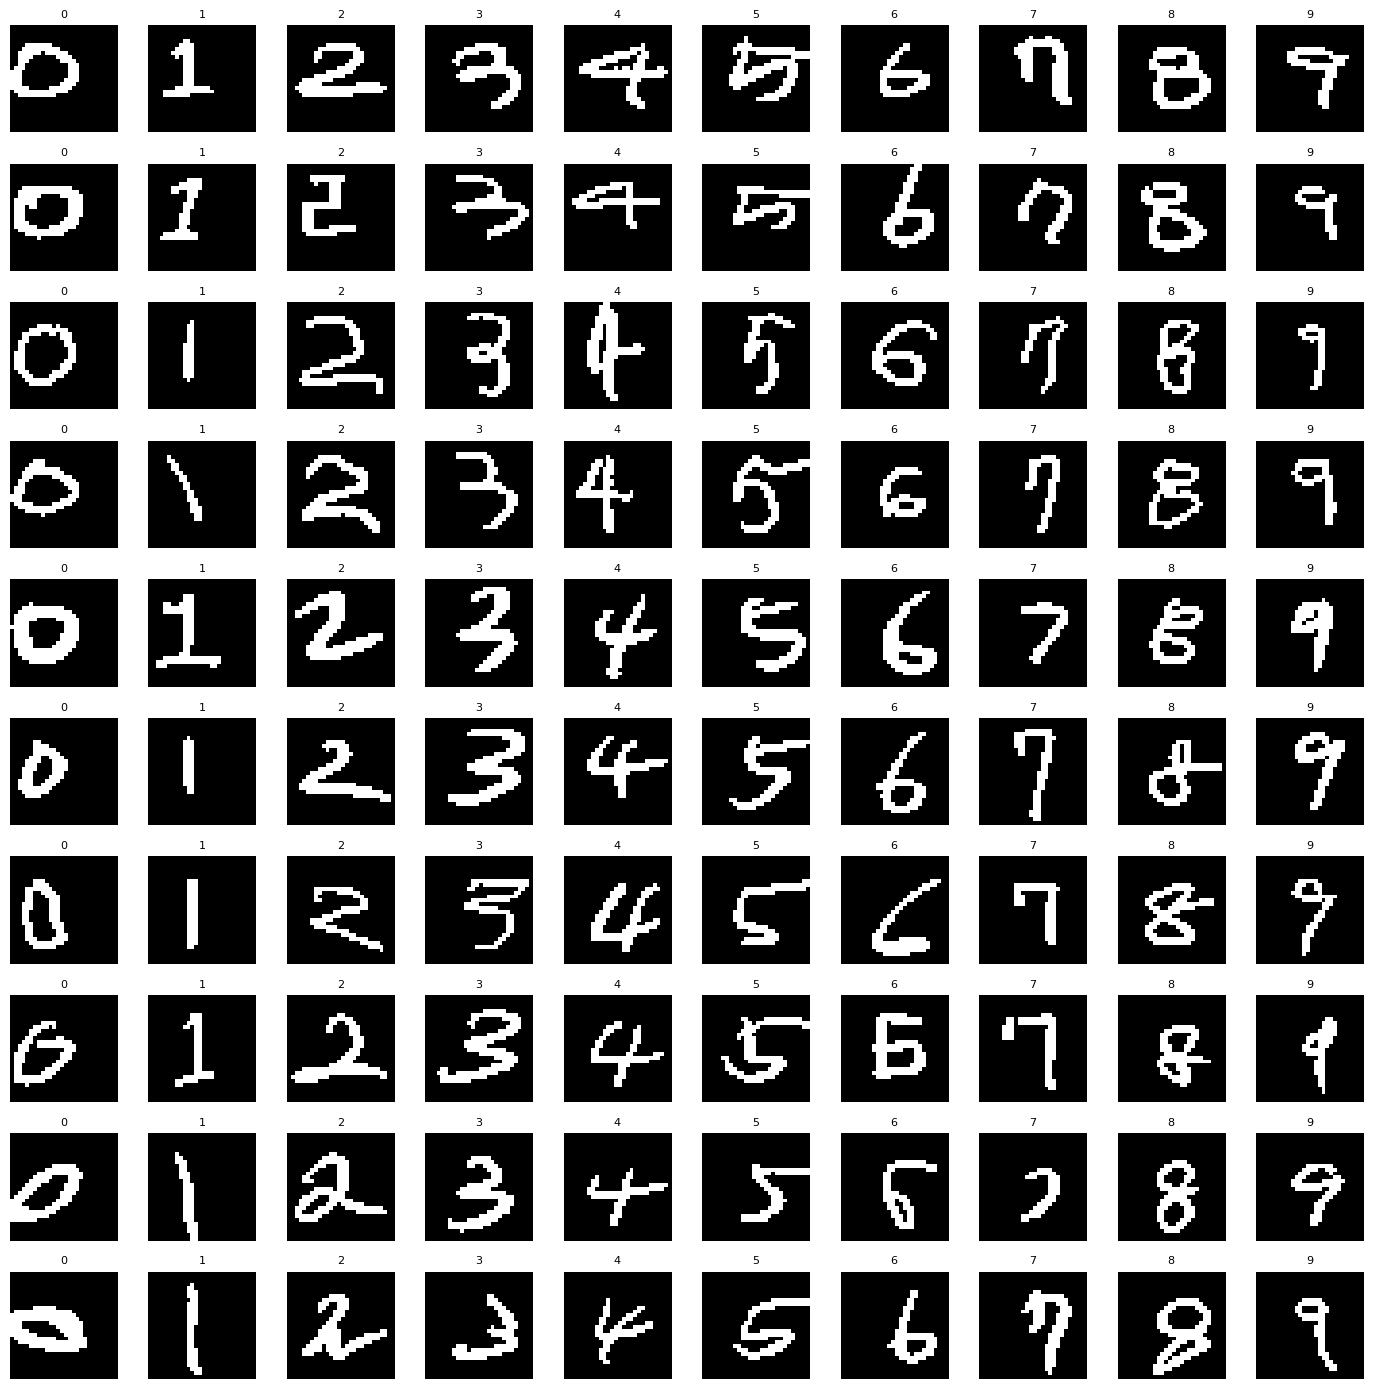


===== 페이지 54 / 95 | 이미지 5300 ~ 5399 =====


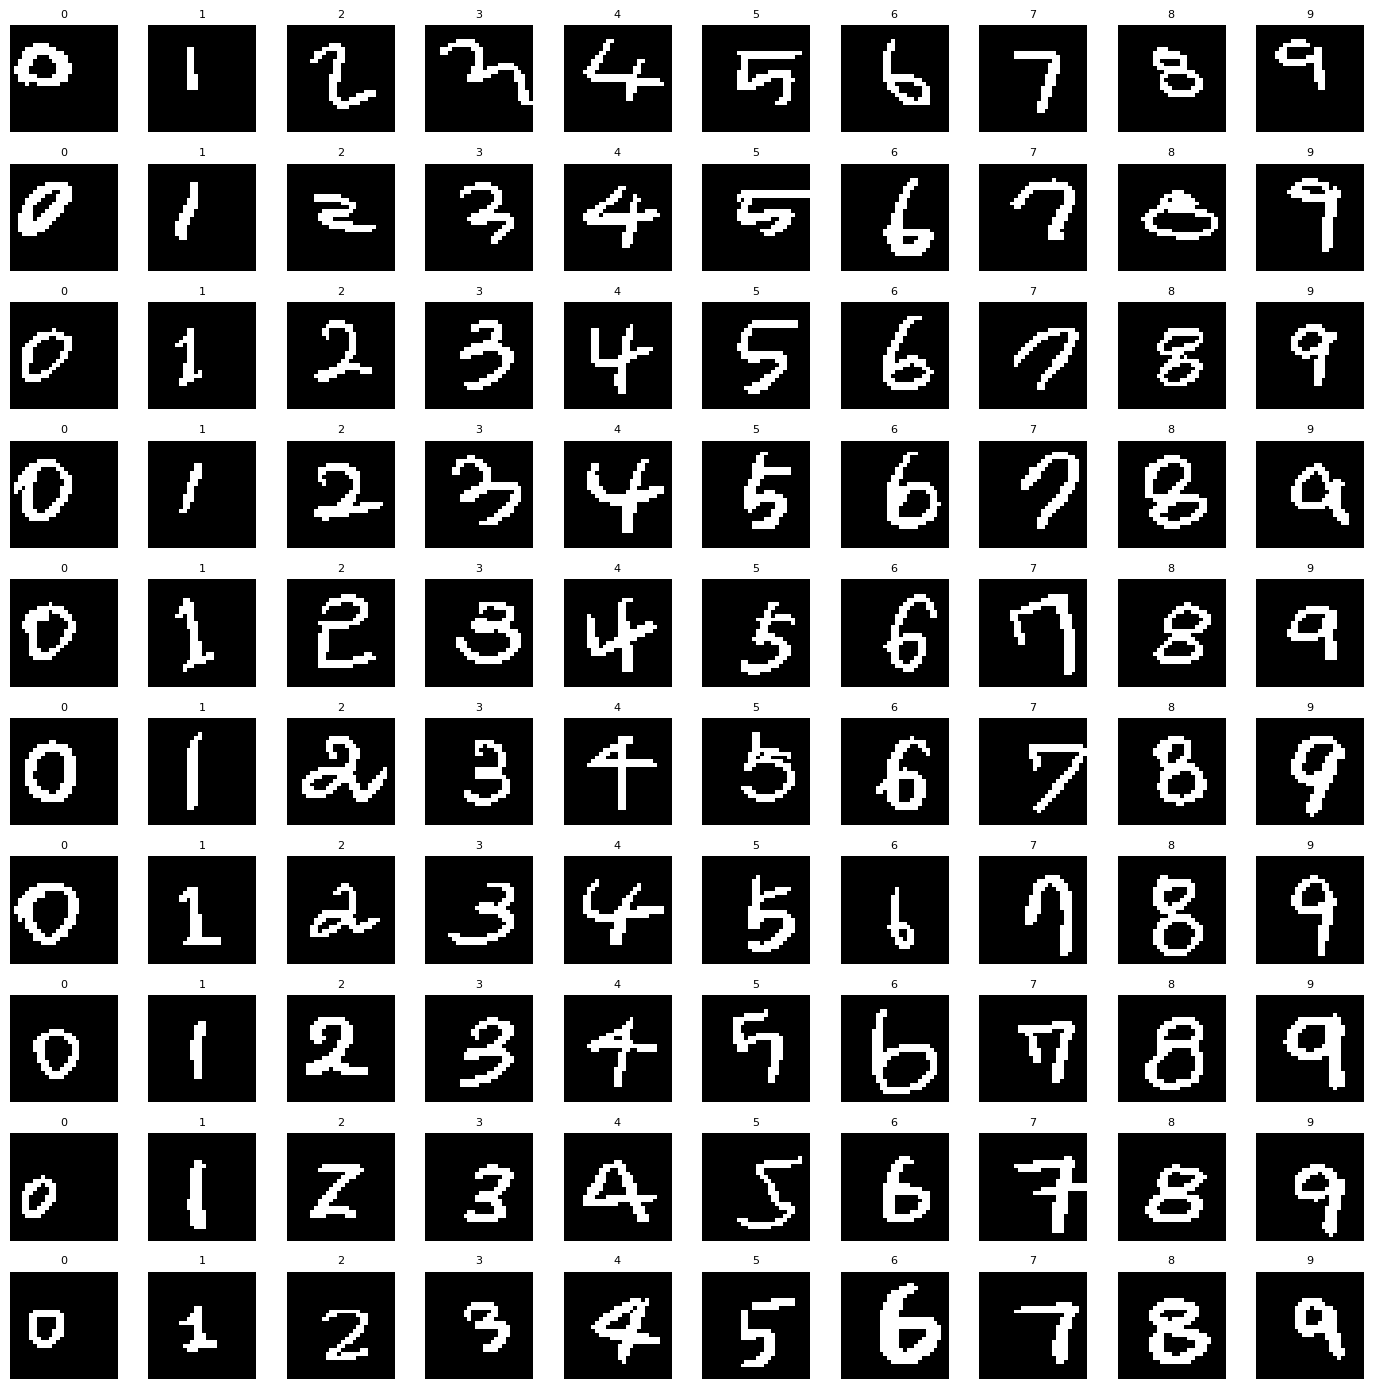


===== 페이지 55 / 95 | 이미지 5400 ~ 5499 =====


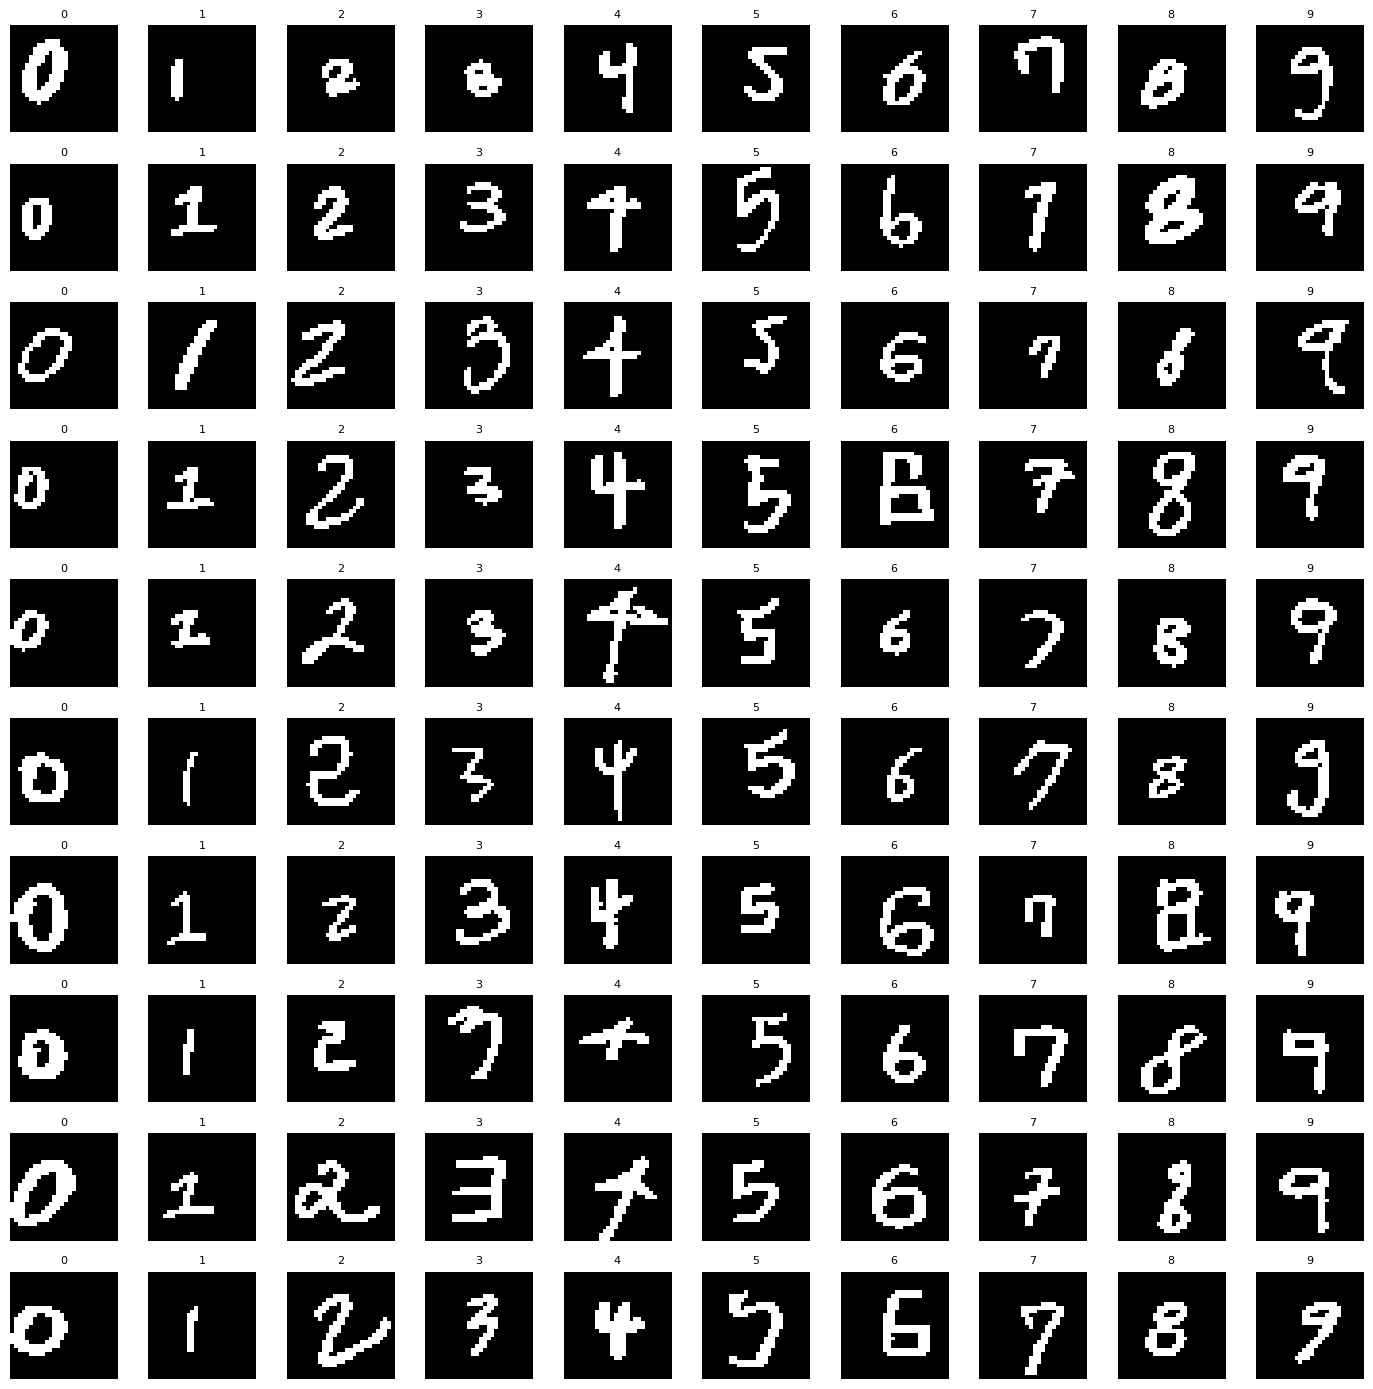


===== 페이지 56 / 95 | 이미지 5500 ~ 5599 =====


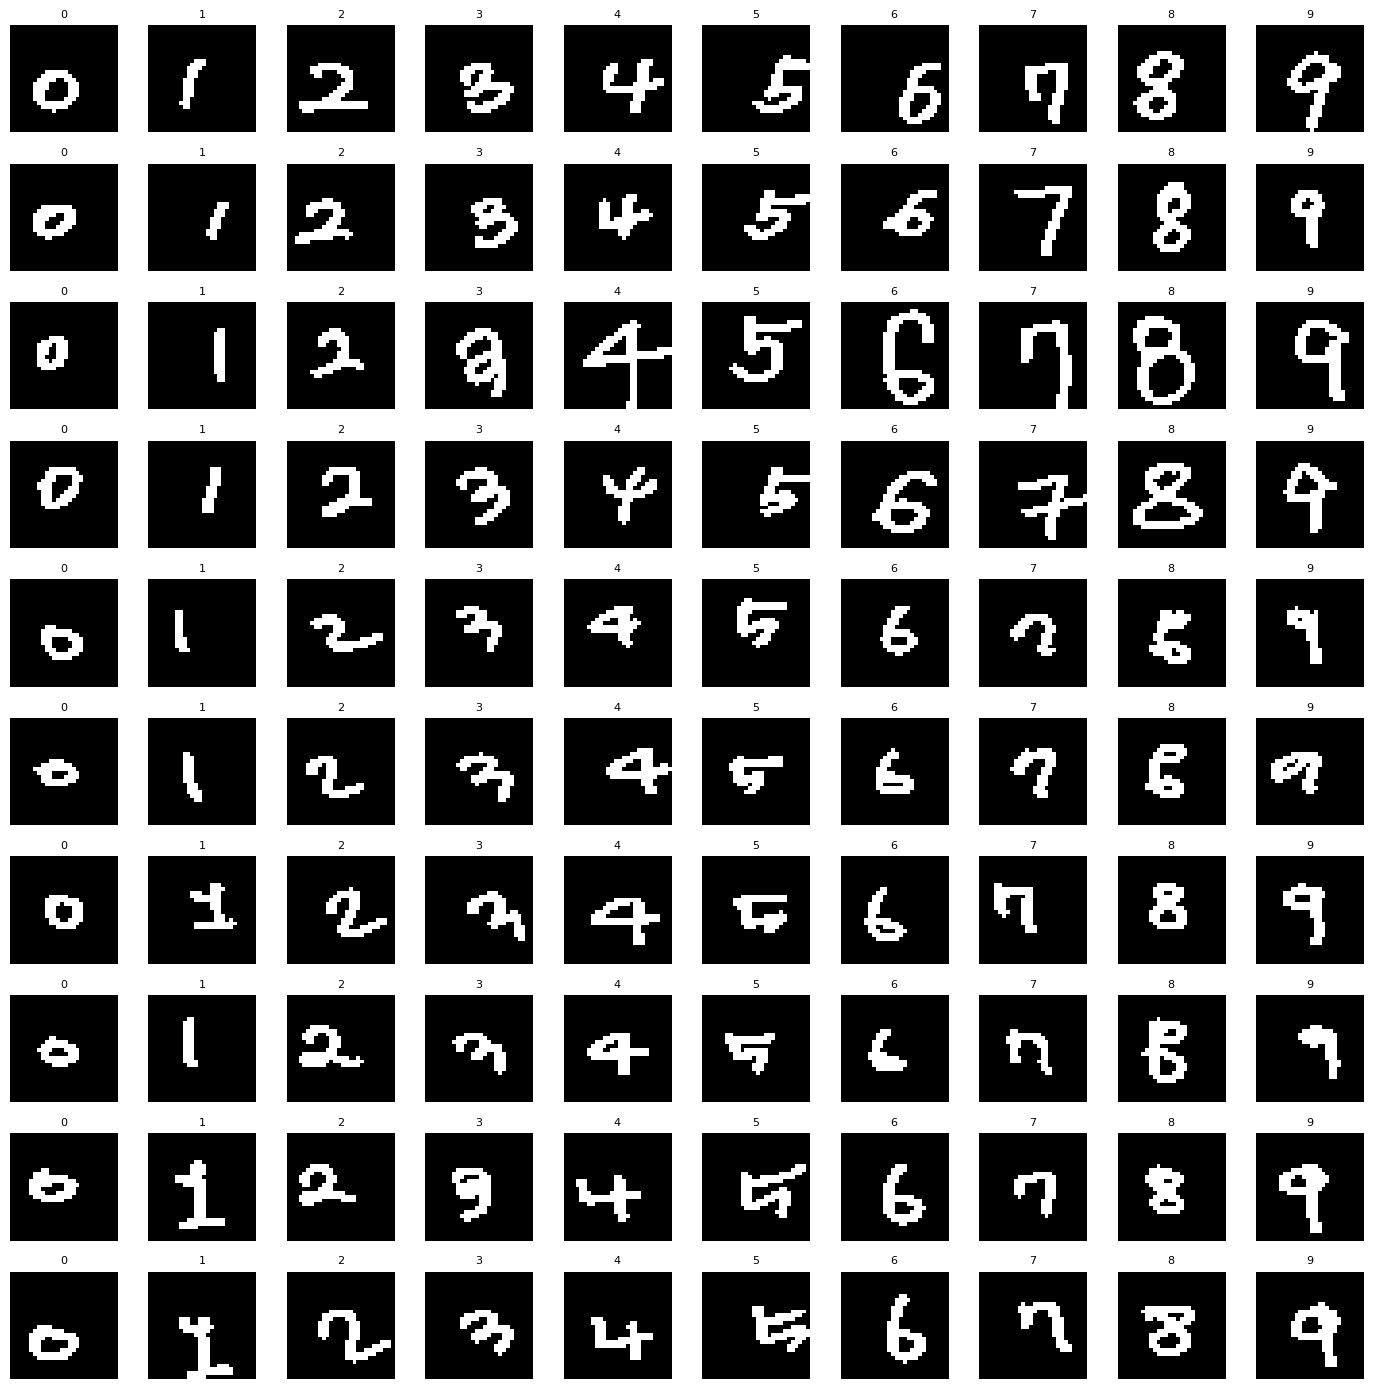


===== 페이지 57 / 95 | 이미지 5600 ~ 5699 =====


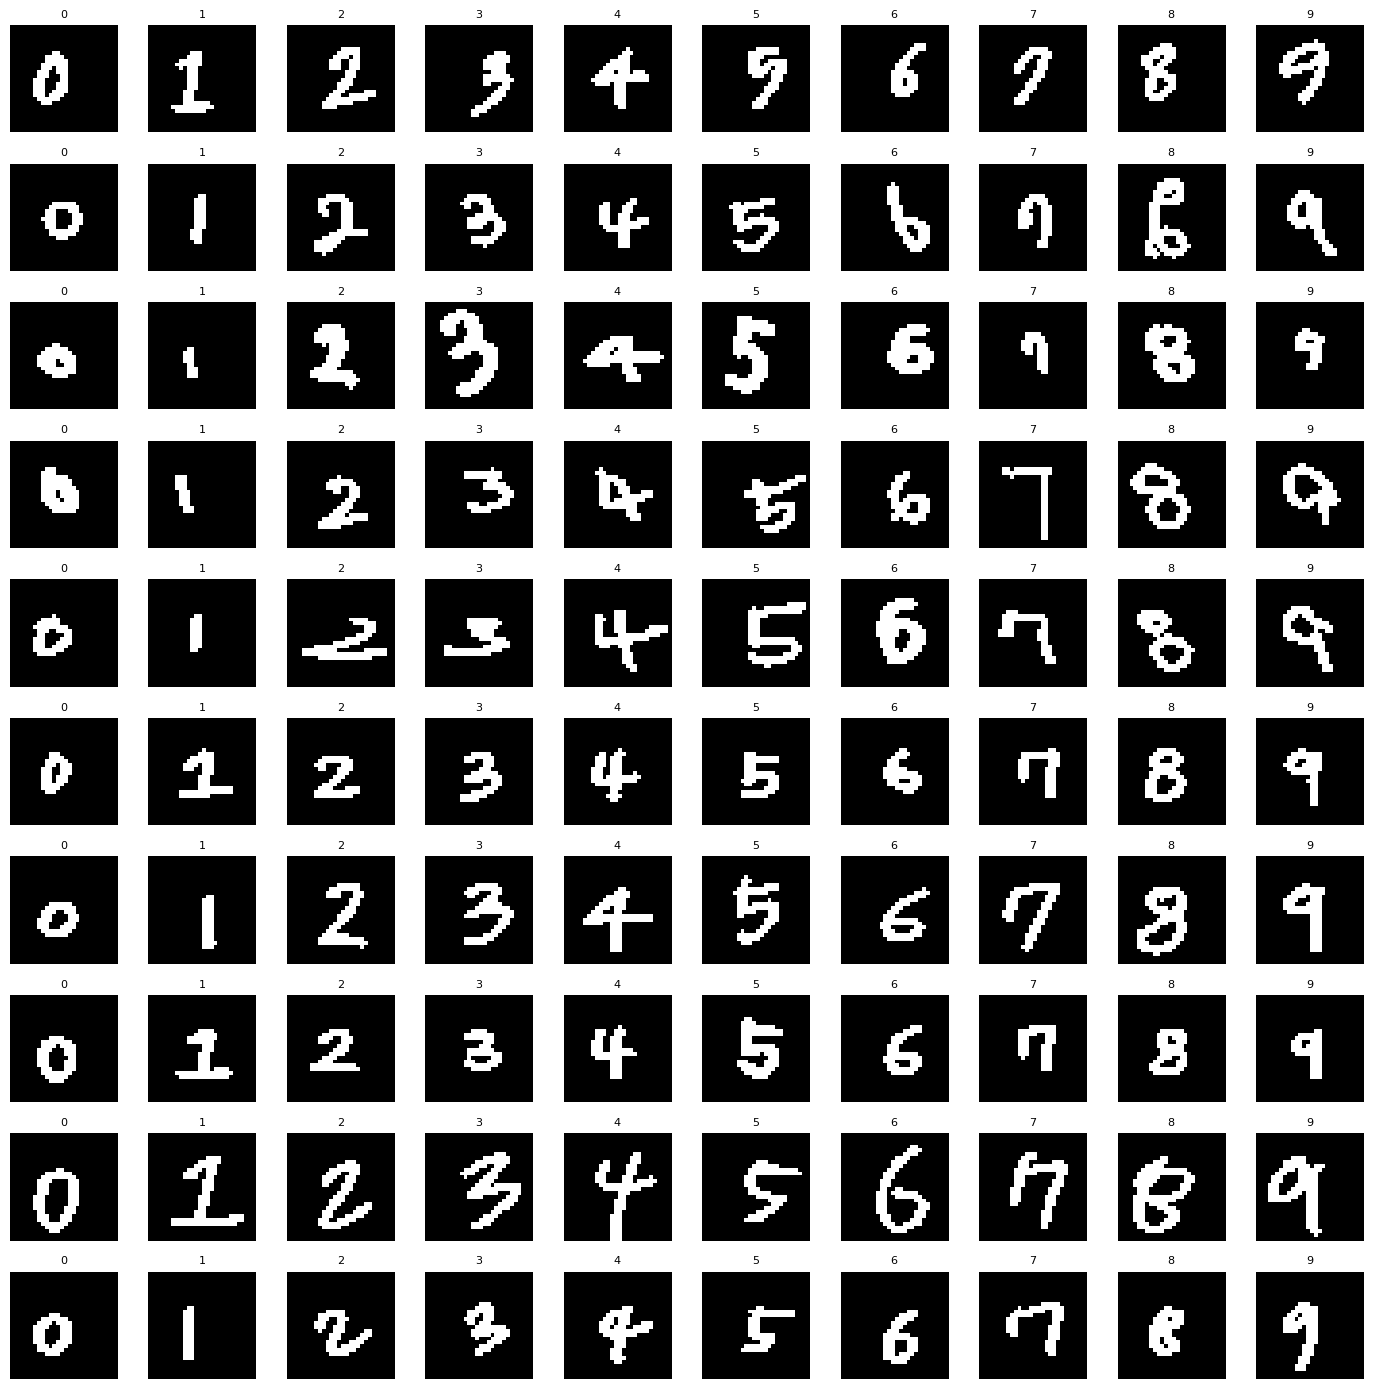


===== 페이지 58 / 95 | 이미지 5700 ~ 5799 =====


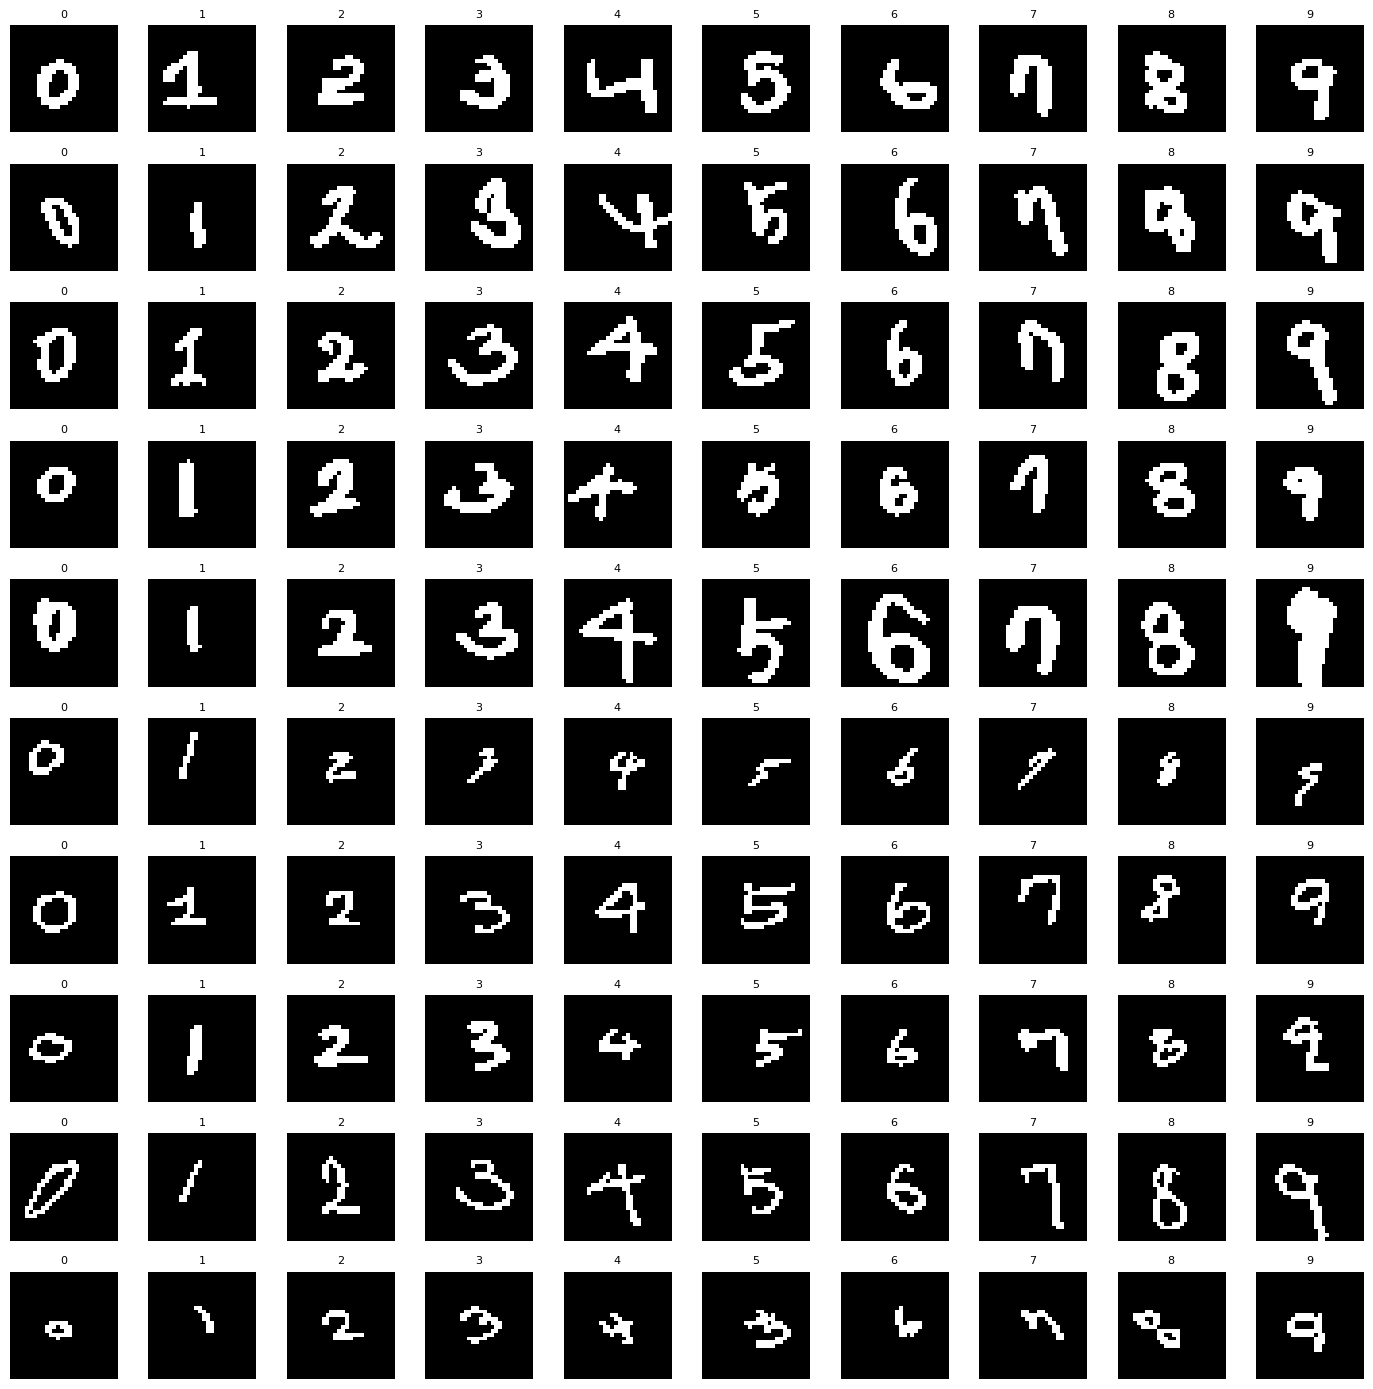


===== 페이지 59 / 95 | 이미지 5800 ~ 5899 =====


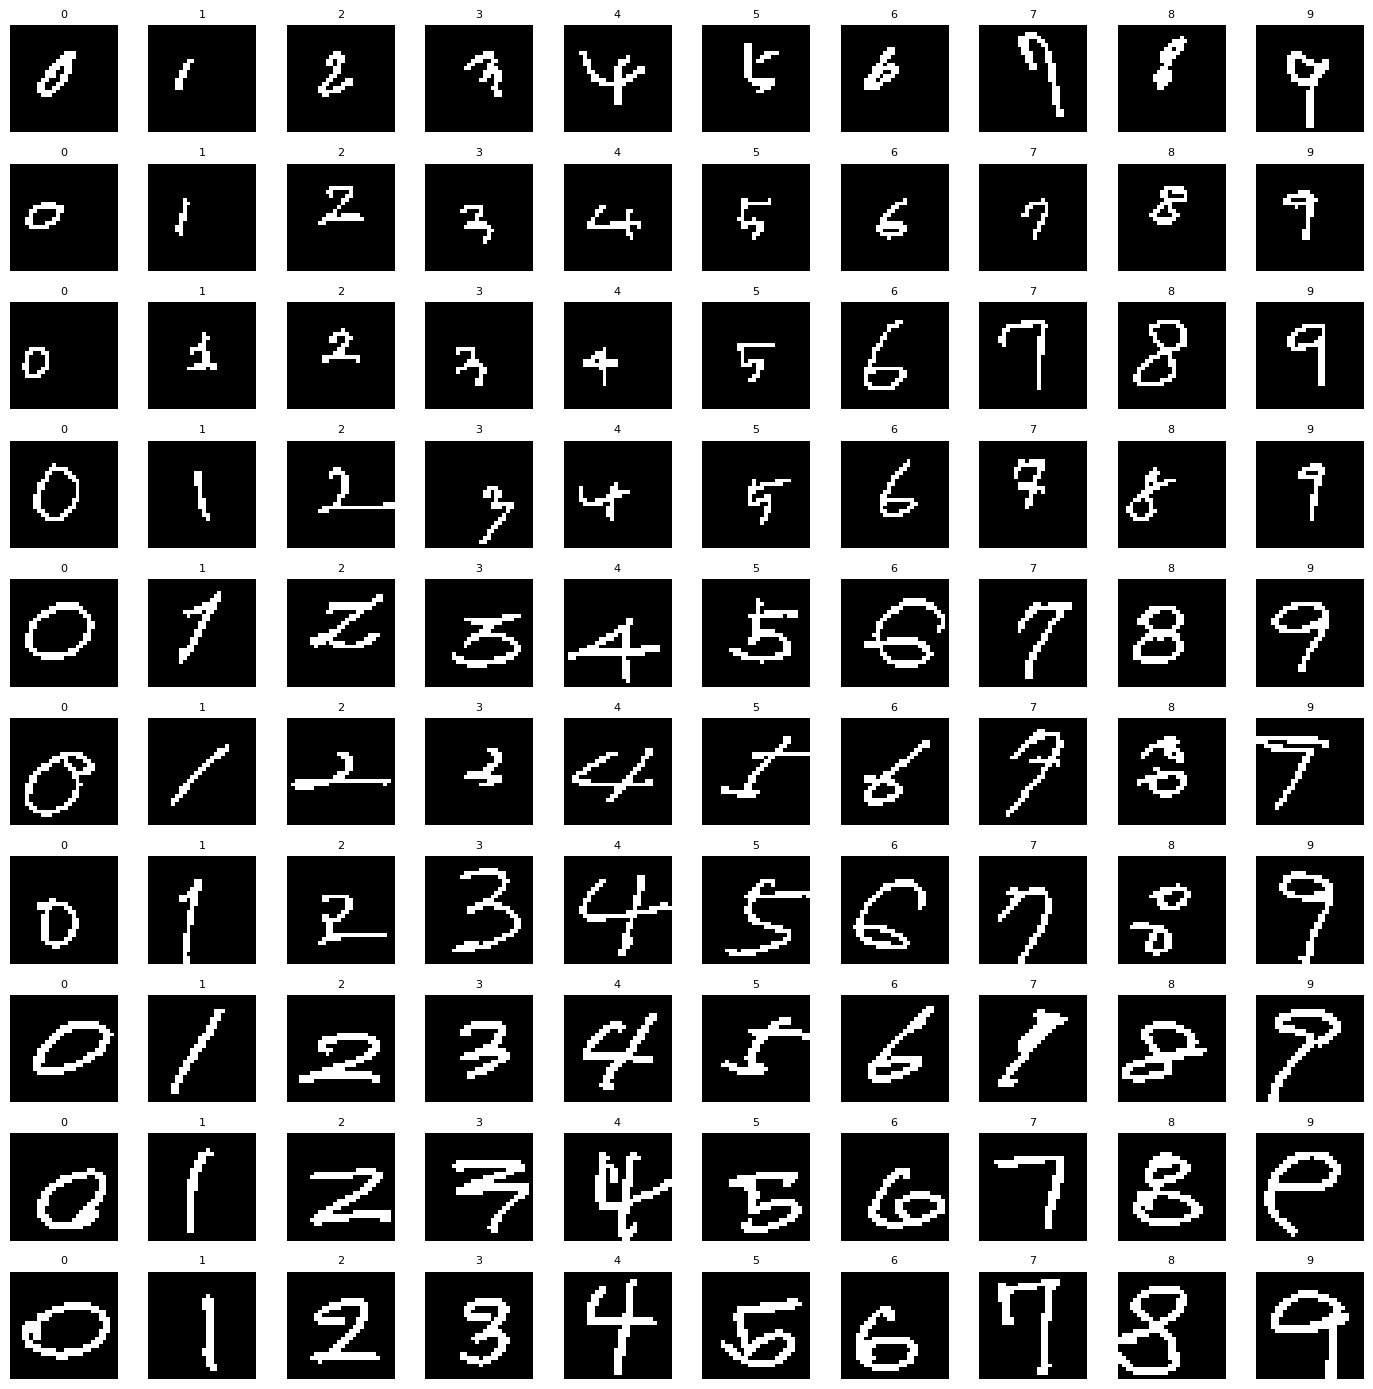


===== 페이지 60 / 95 | 이미지 5900 ~ 5999 =====


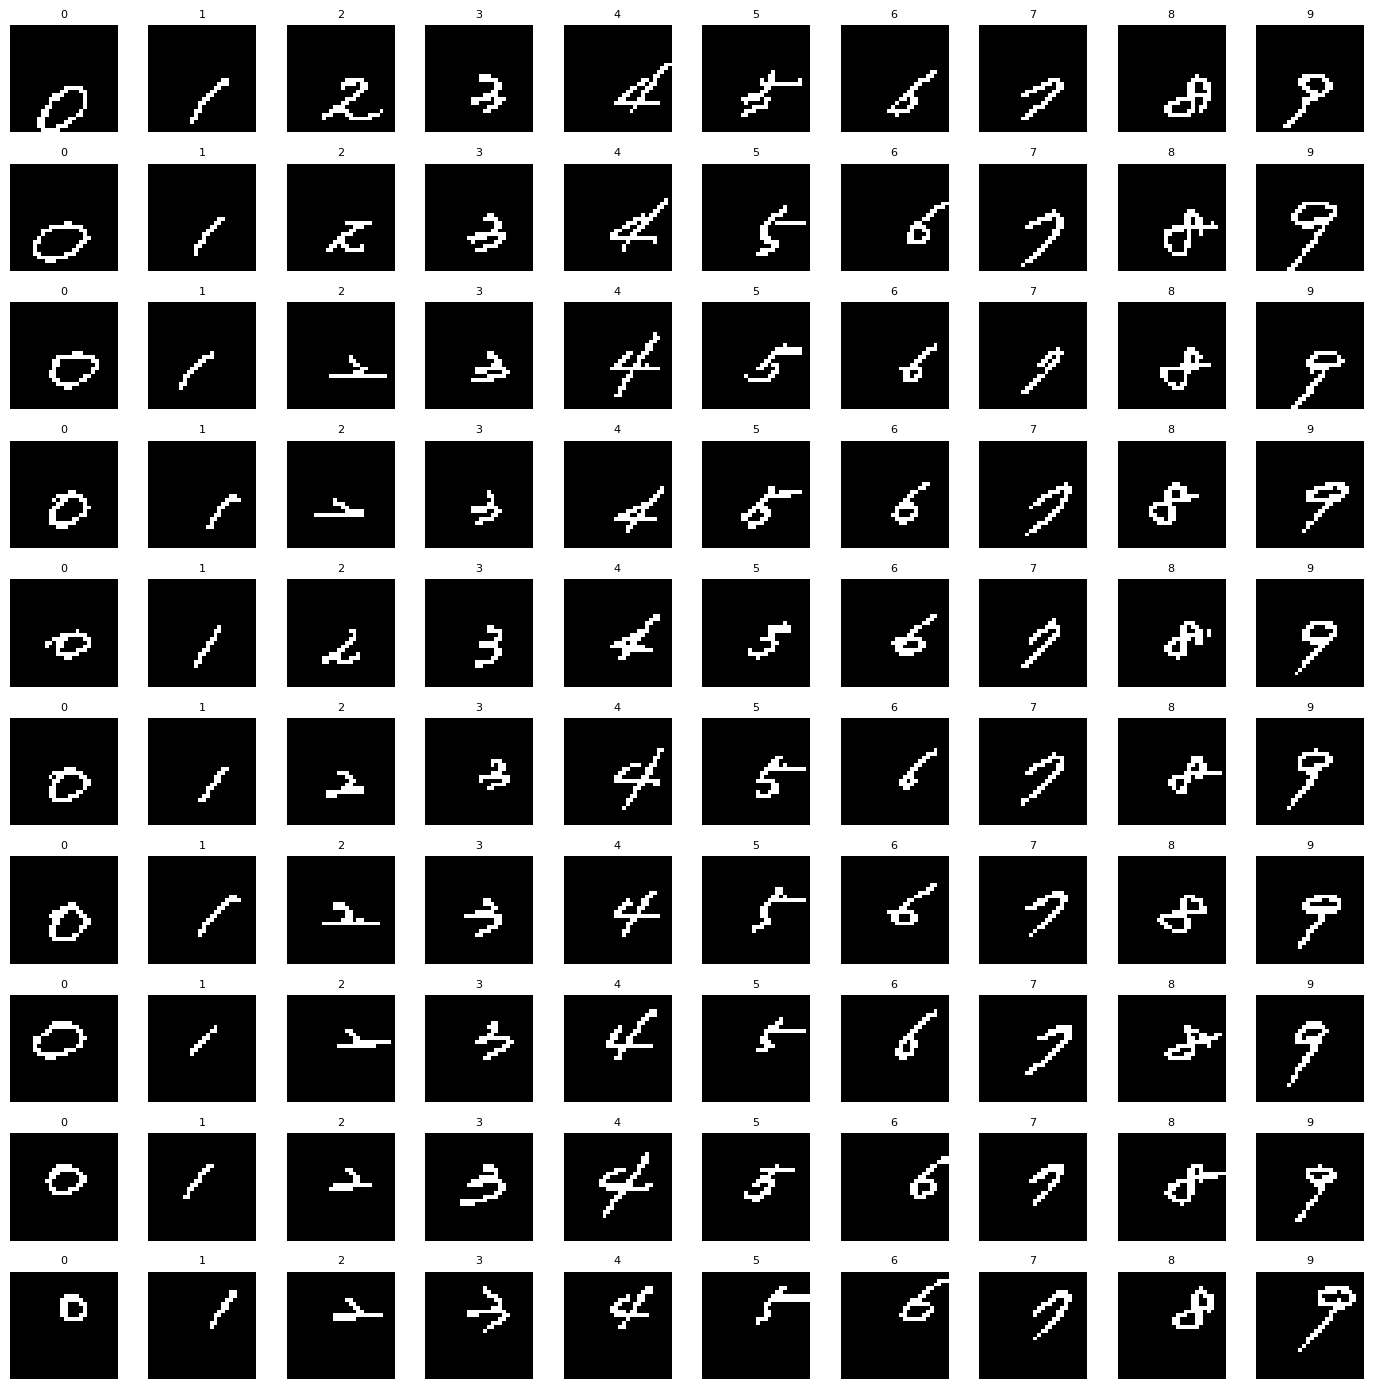


===== 페이지 61 / 95 | 이미지 6000 ~ 6099 =====


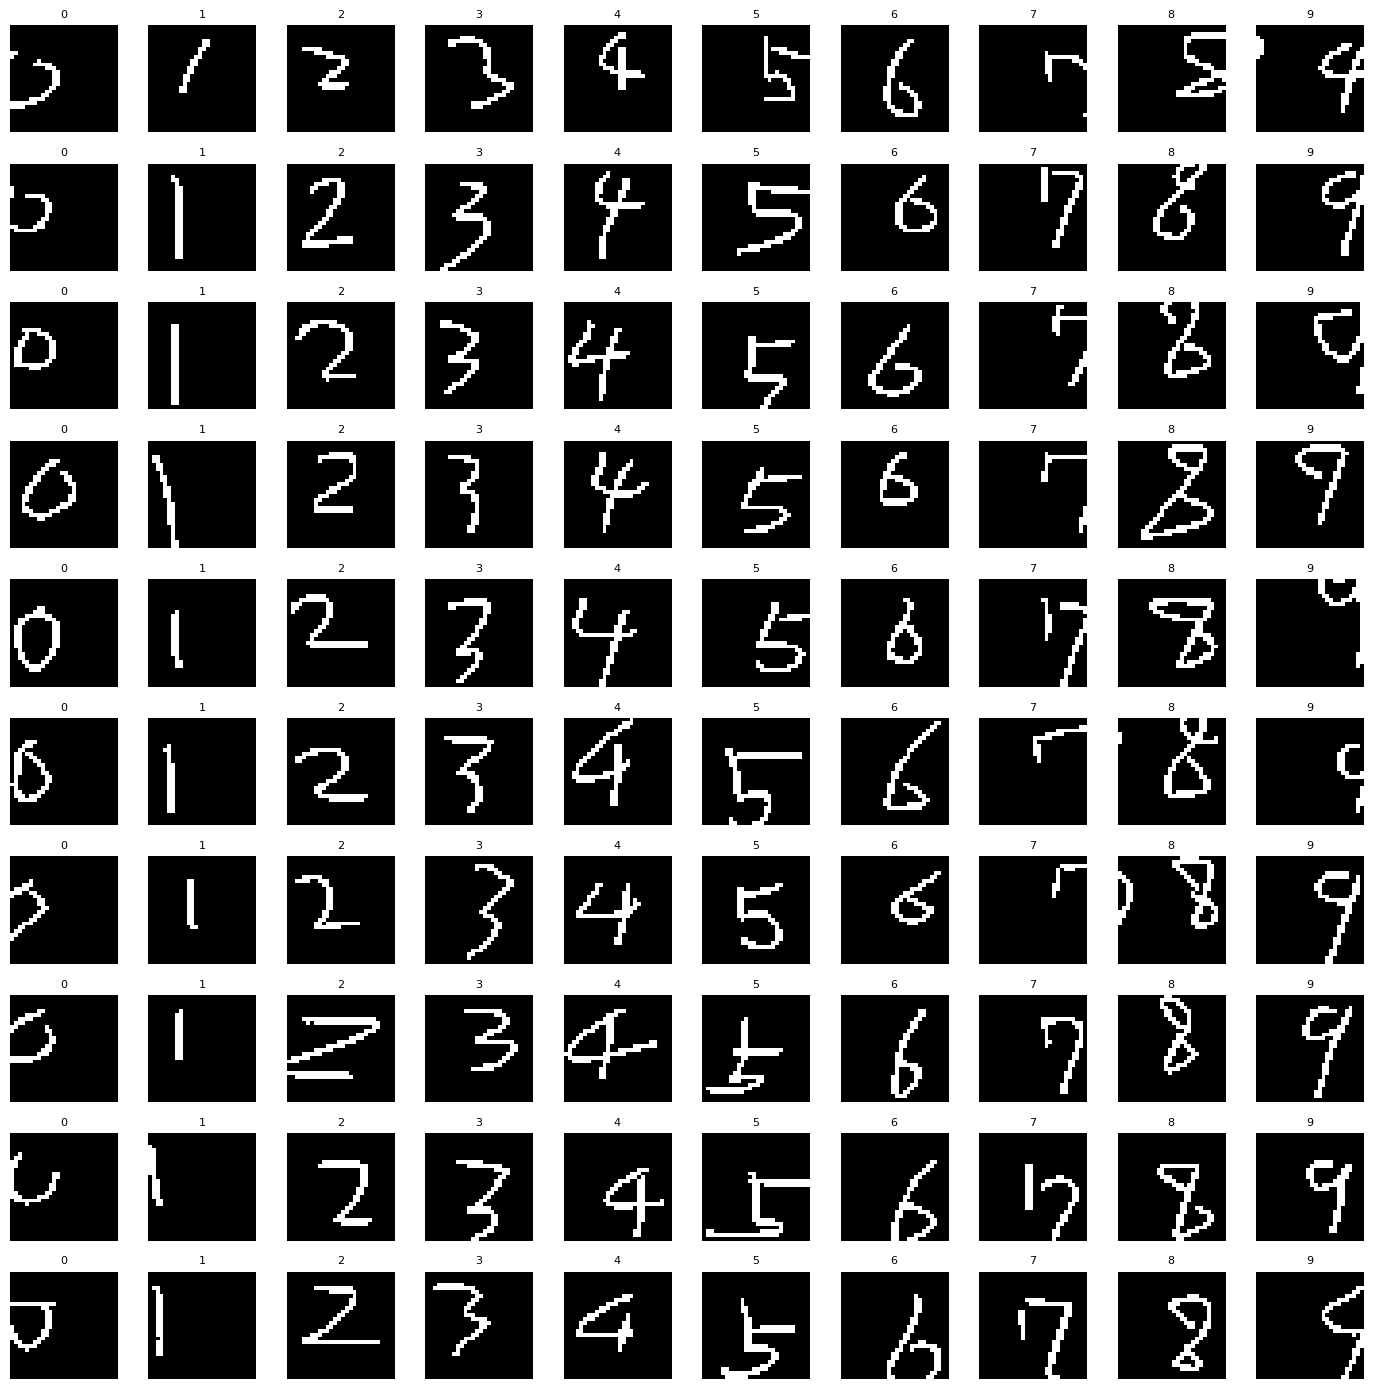


===== 페이지 62 / 95 | 이미지 6100 ~ 6199 =====


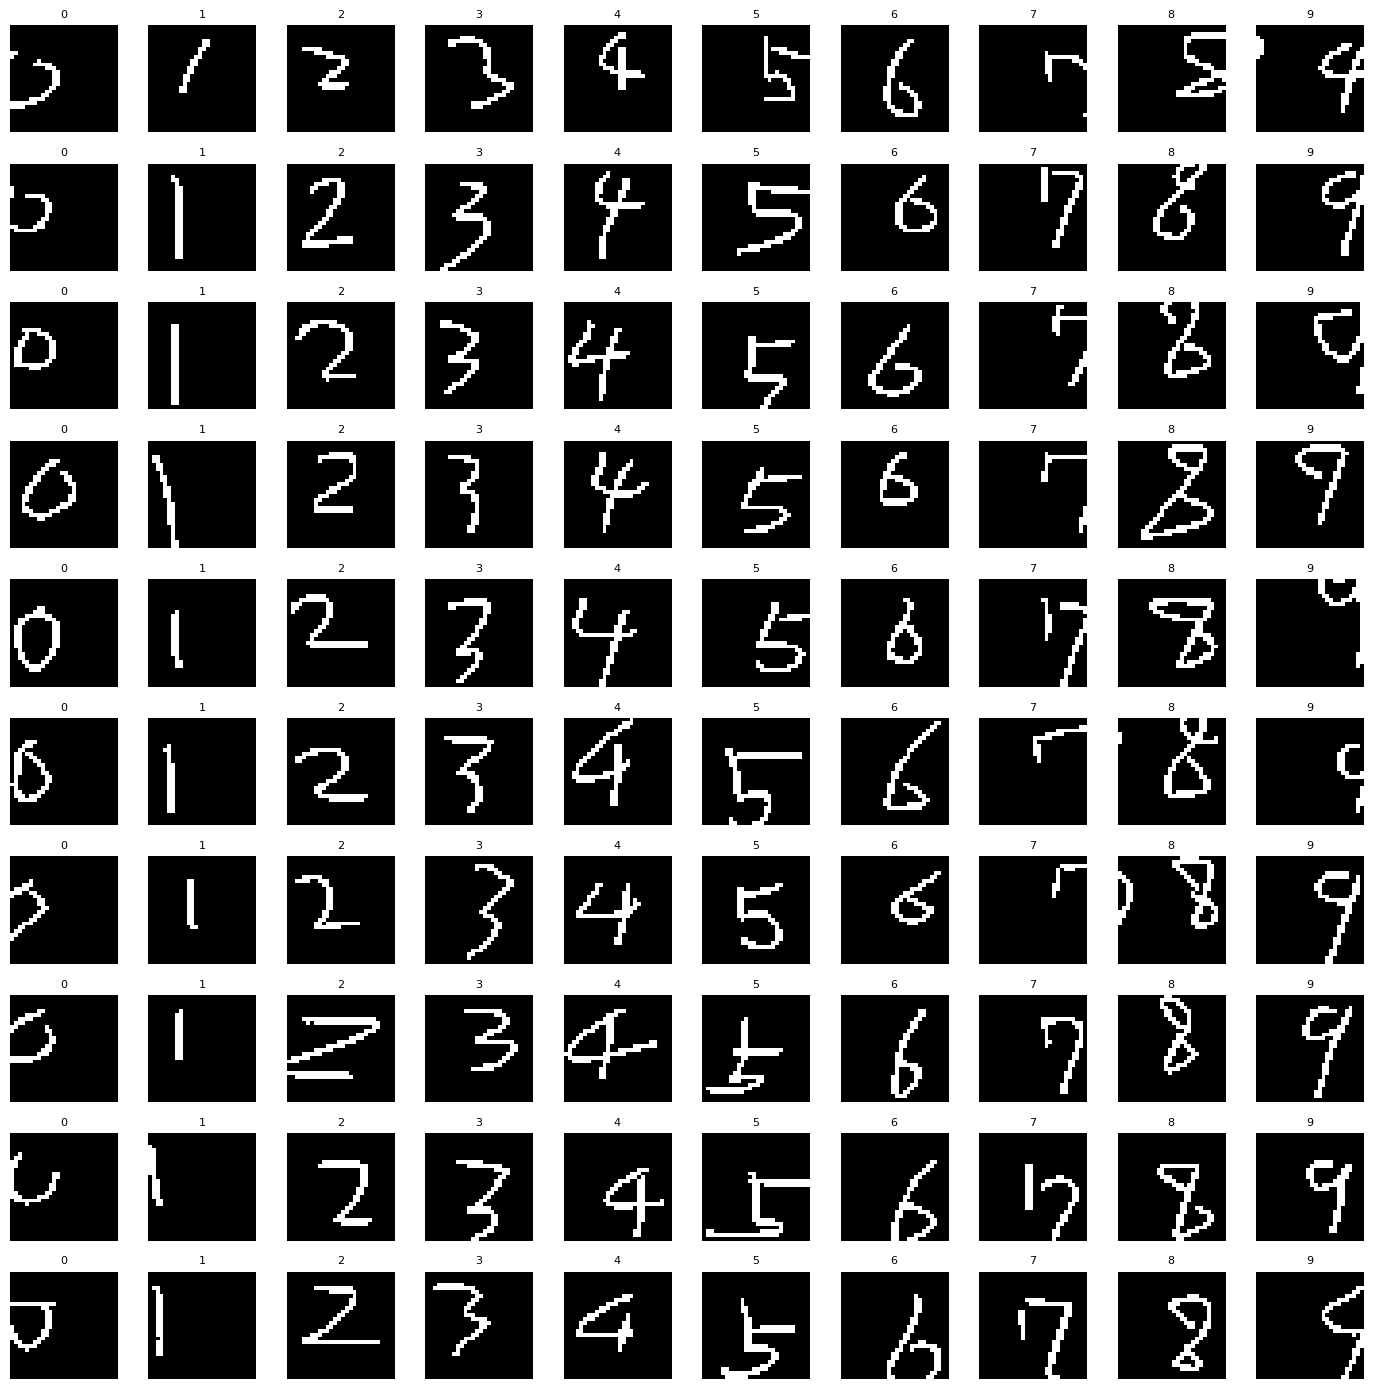


===== 페이지 63 / 95 | 이미지 6200 ~ 6299 =====


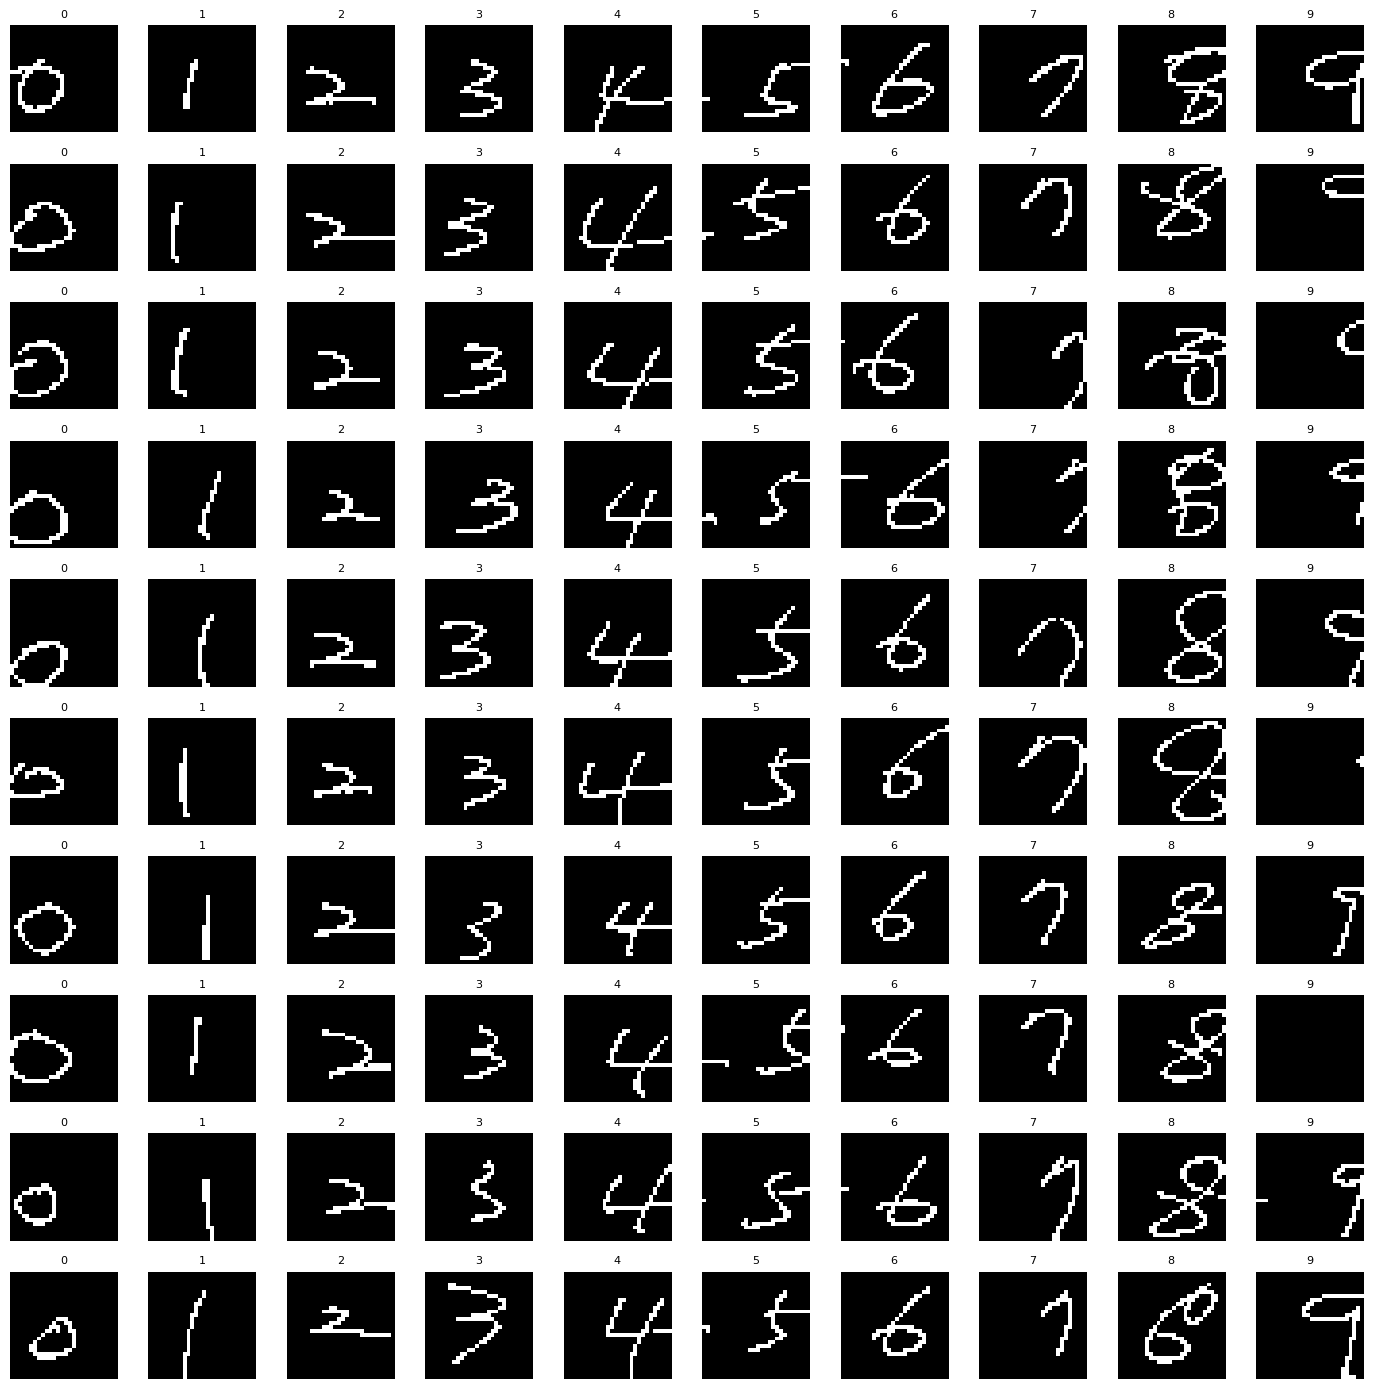


===== 페이지 64 / 95 | 이미지 6300 ~ 6399 =====


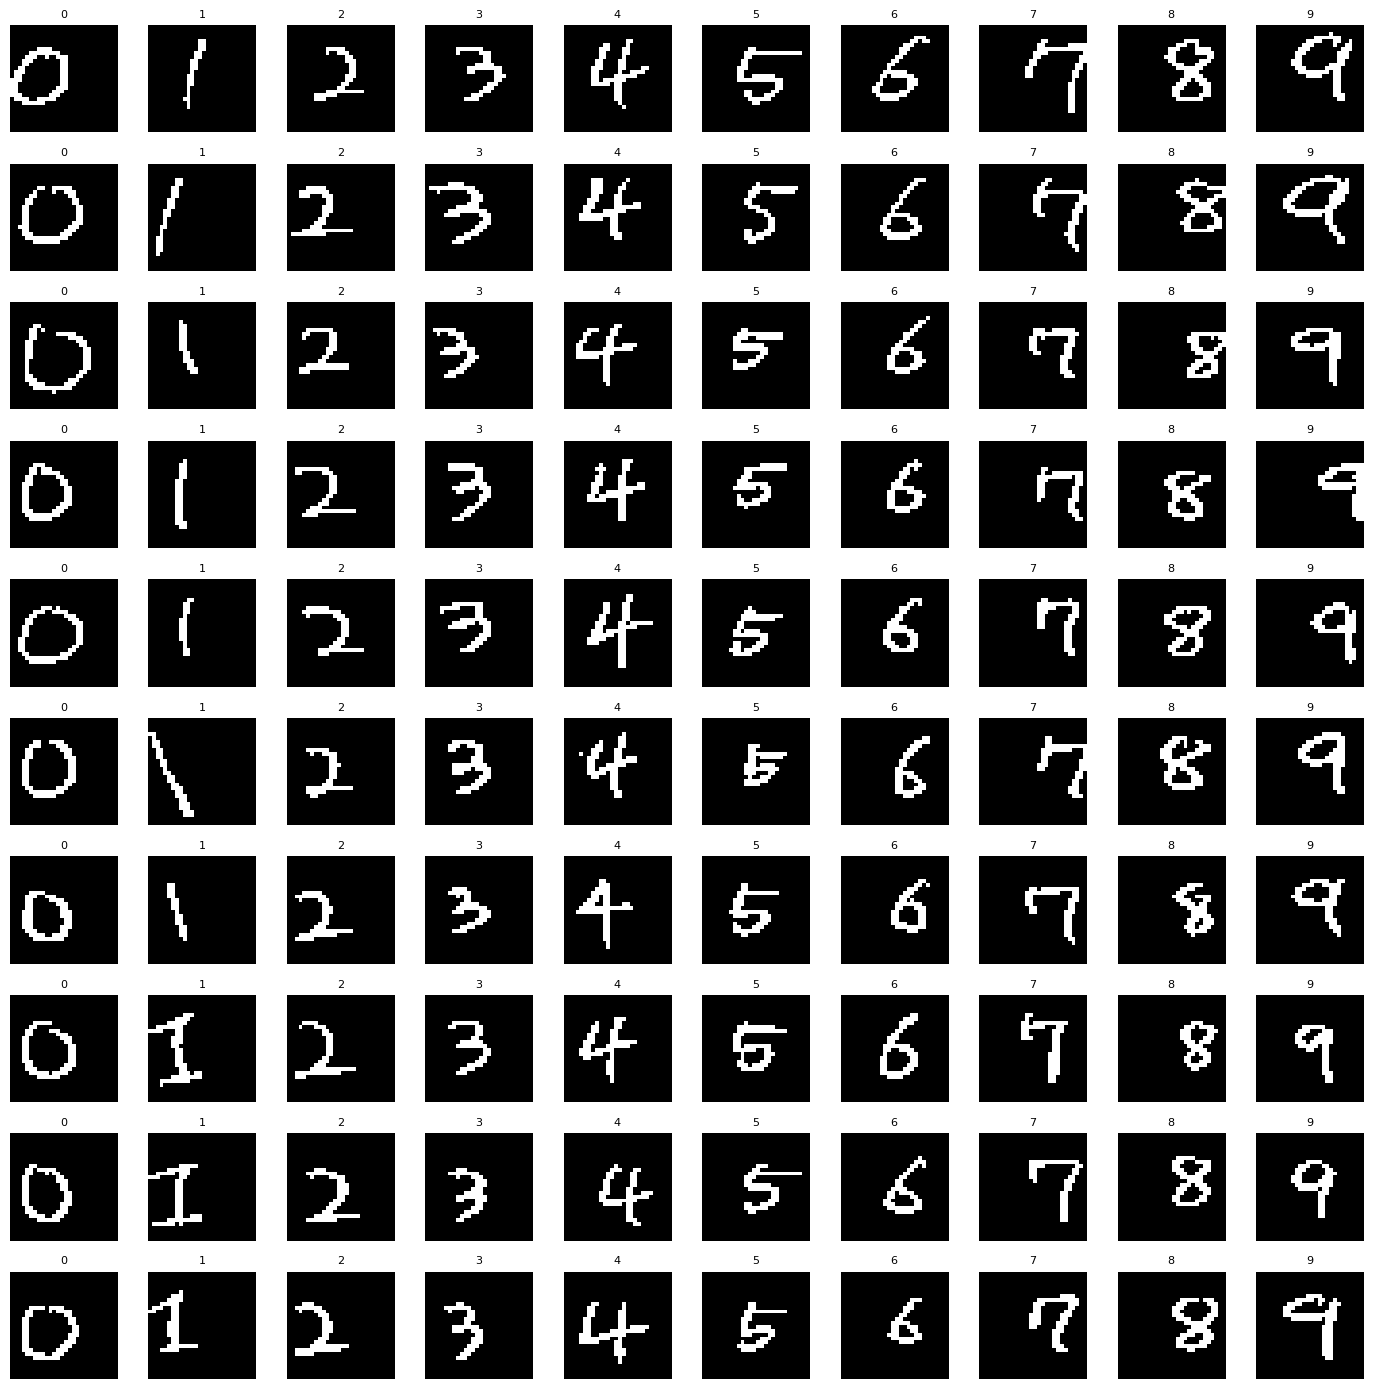


===== 페이지 65 / 95 | 이미지 6400 ~ 6499 =====


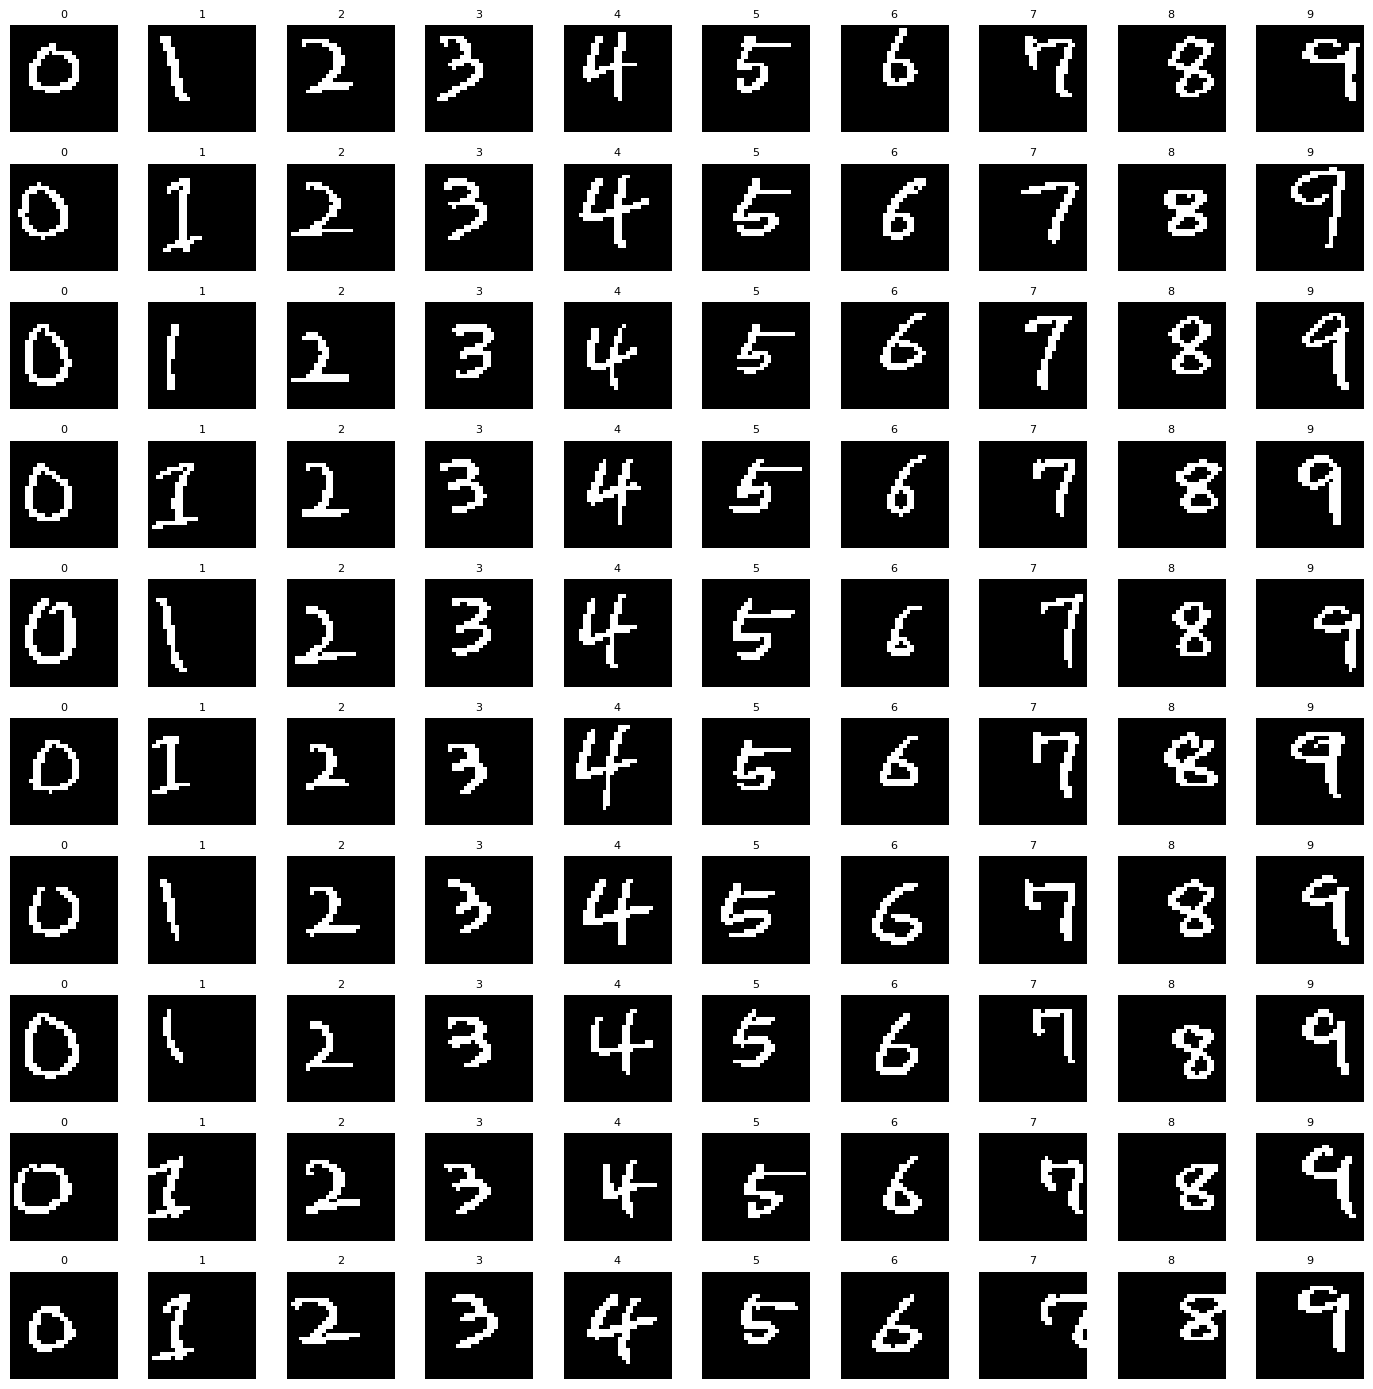


===== 페이지 66 / 95 | 이미지 6500 ~ 6599 =====


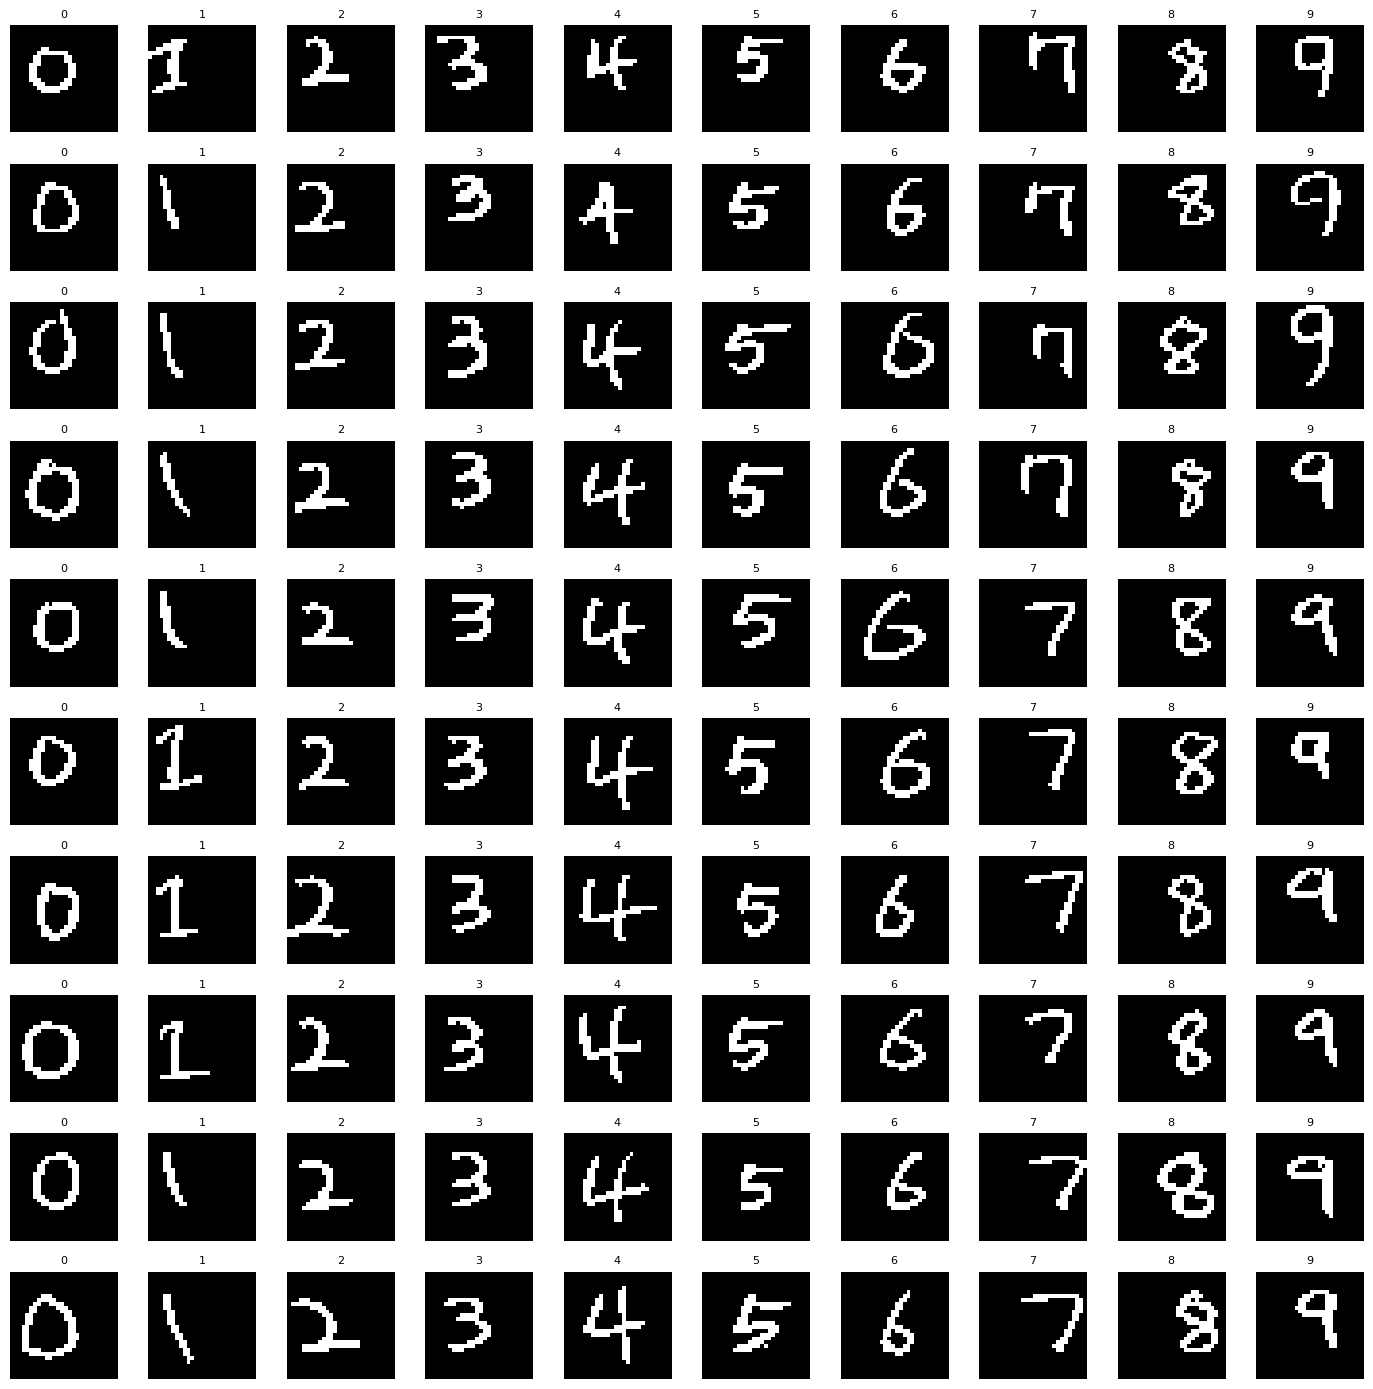


===== 페이지 67 / 95 | 이미지 6600 ~ 6699 =====


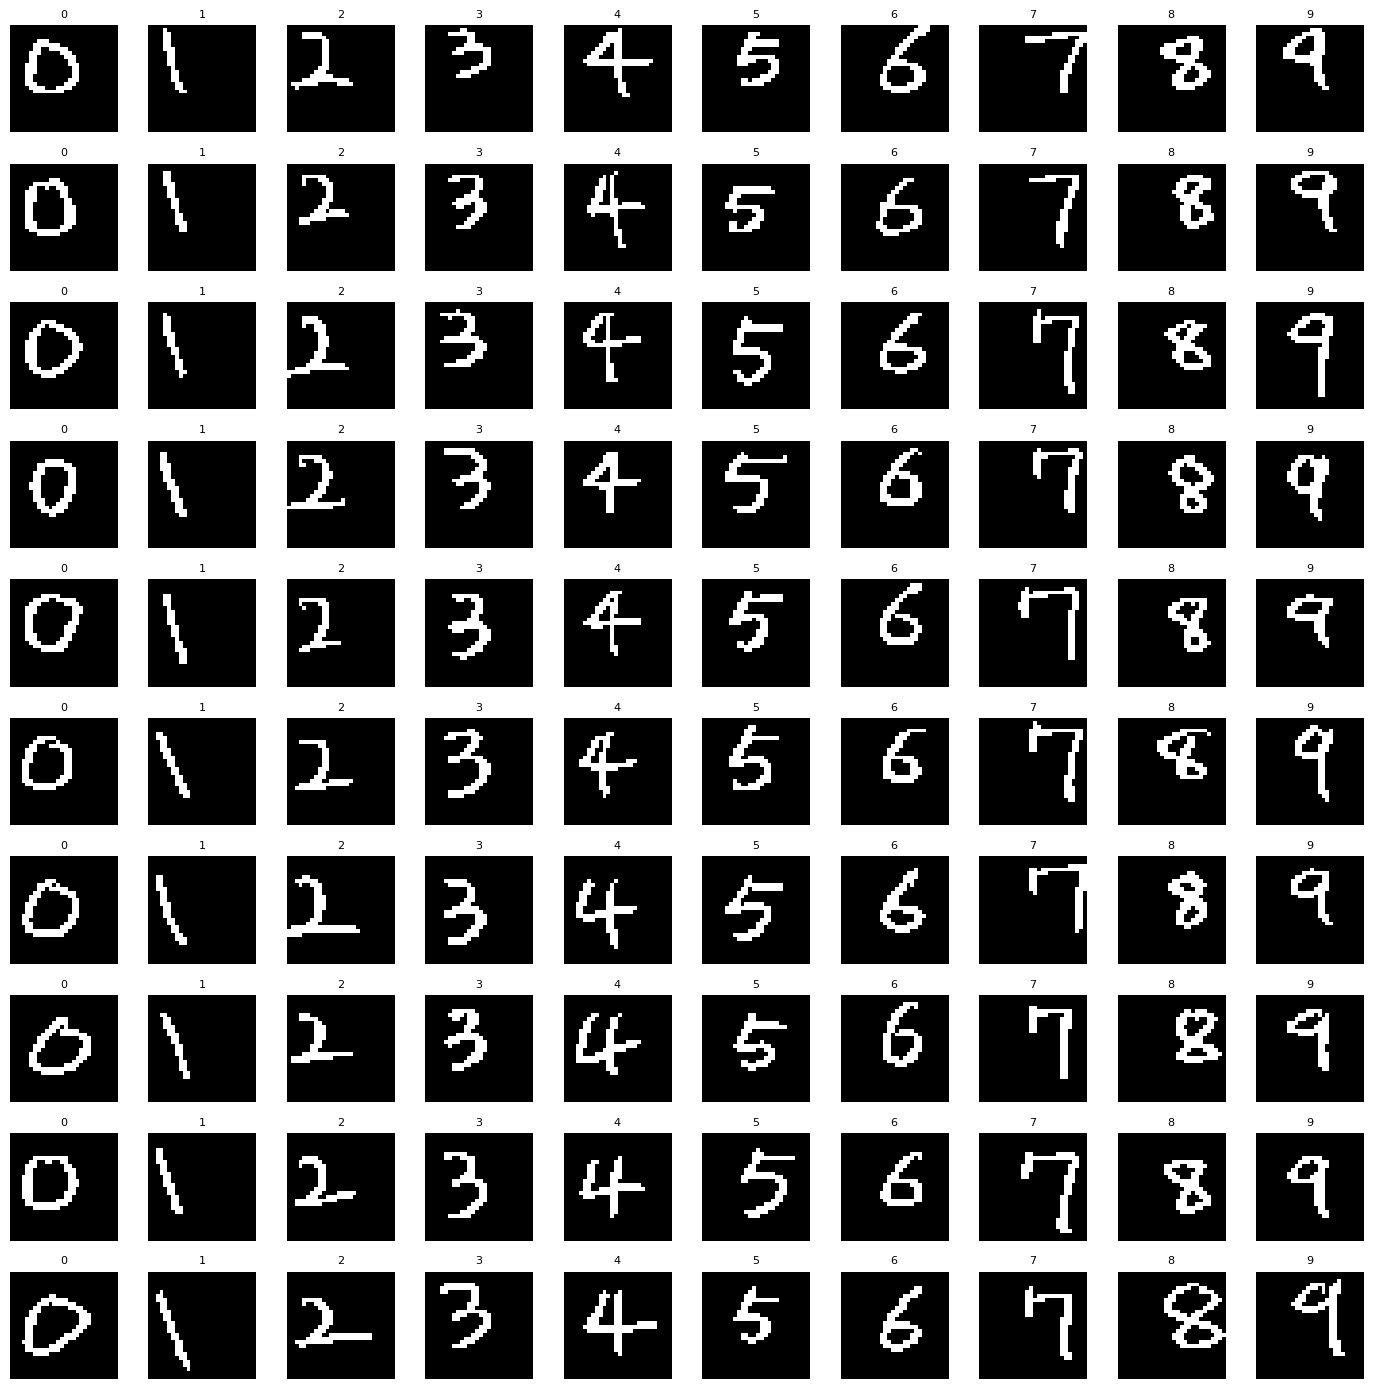


===== 페이지 68 / 95 | 이미지 6700 ~ 6799 =====


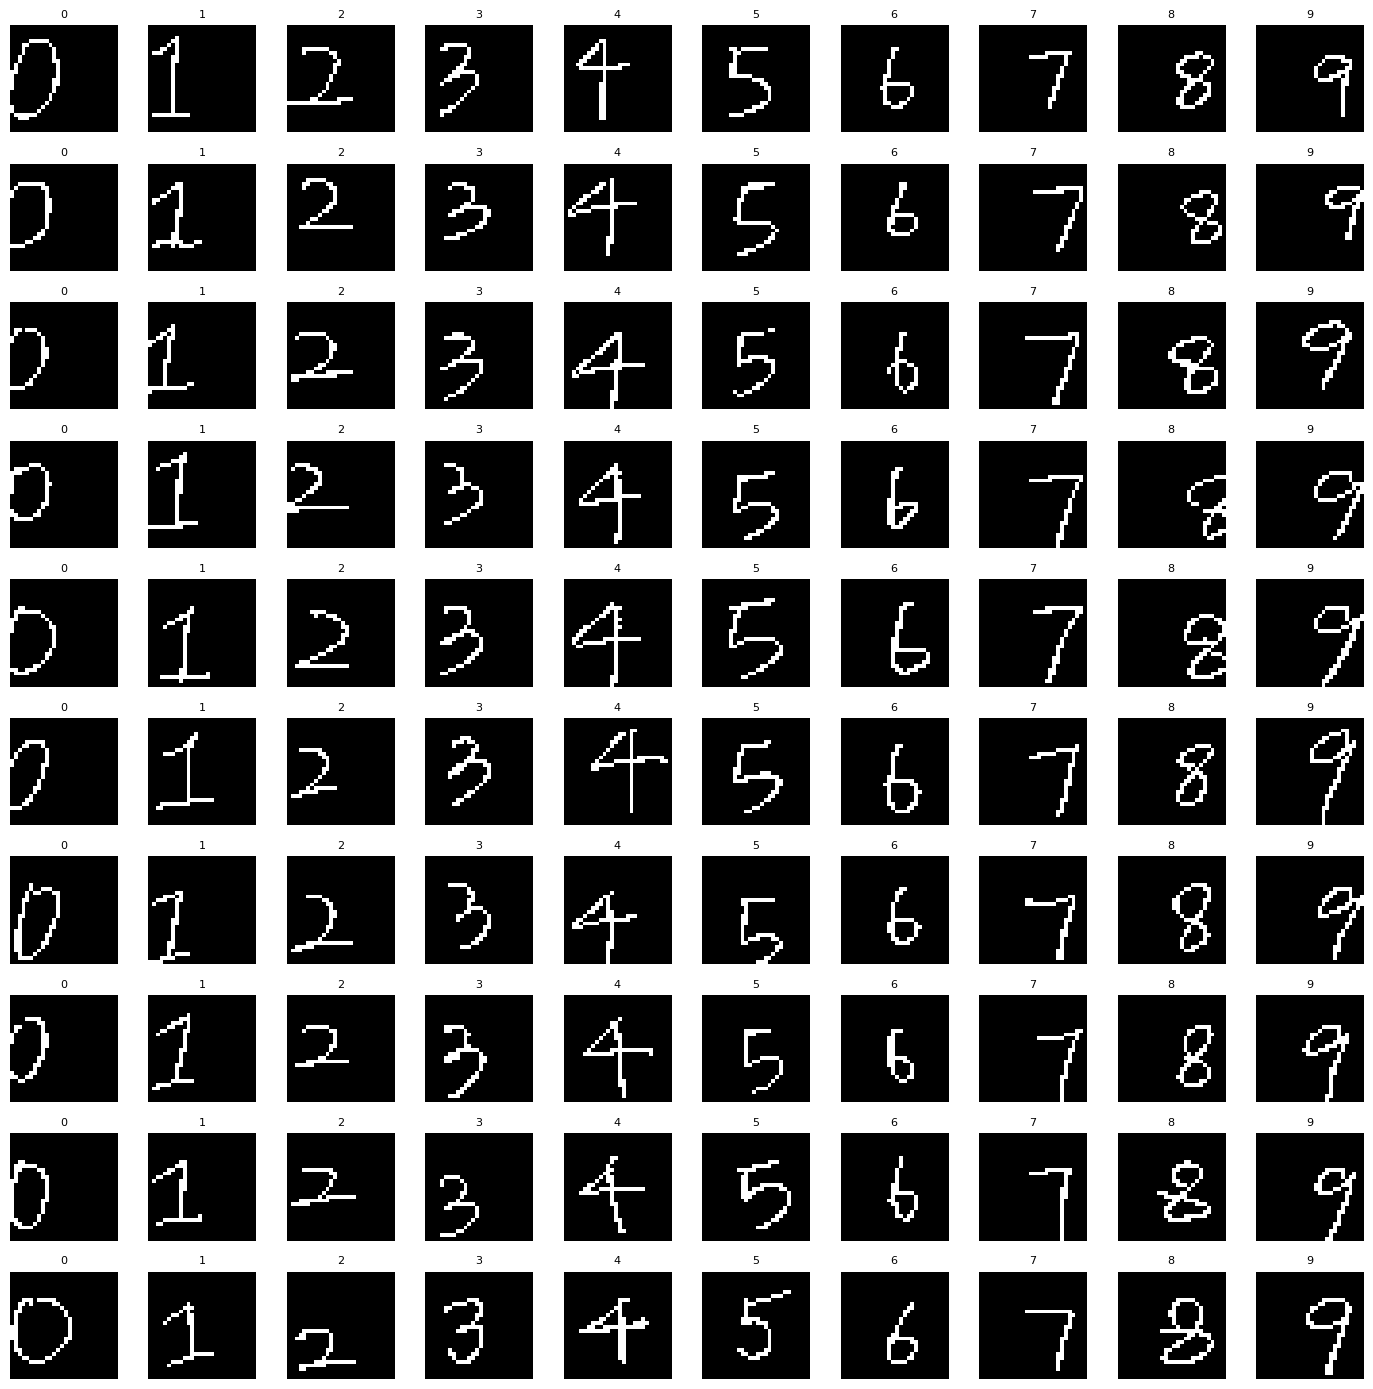


===== 페이지 69 / 95 | 이미지 6800 ~ 6899 =====


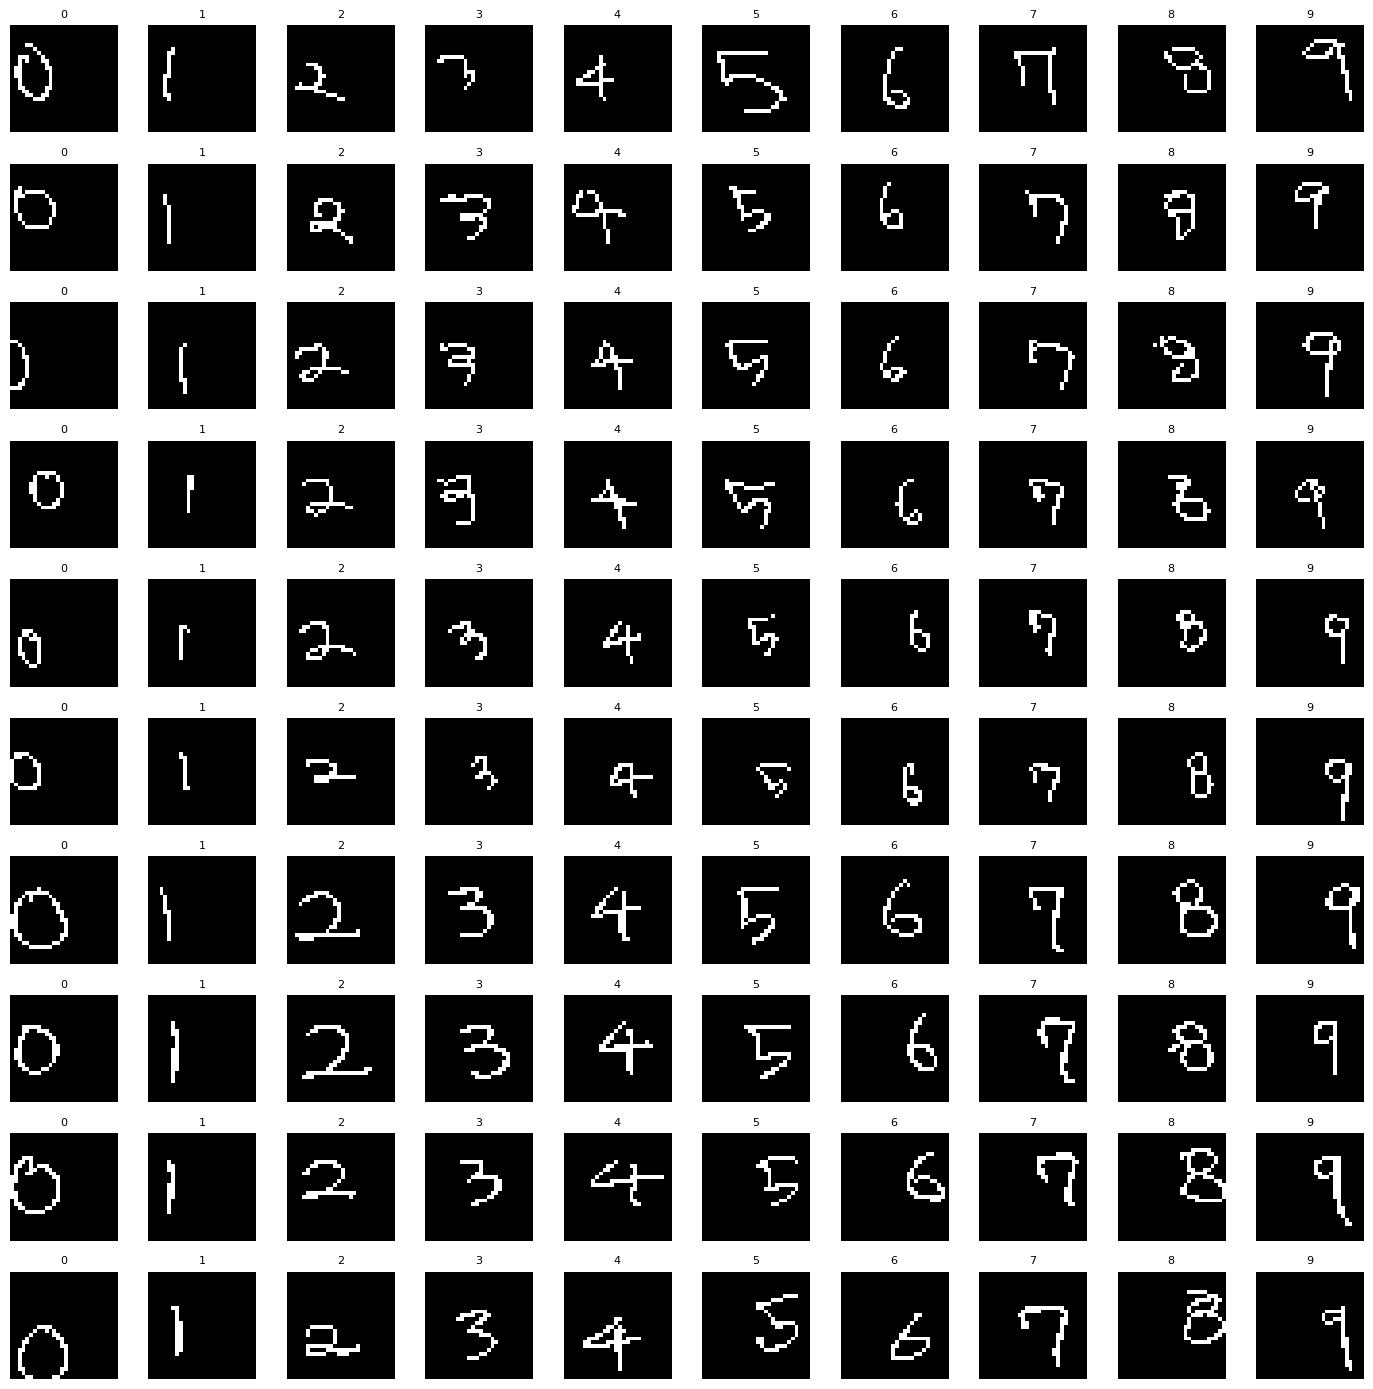


===== 페이지 70 / 95 | 이미지 6900 ~ 6999 =====


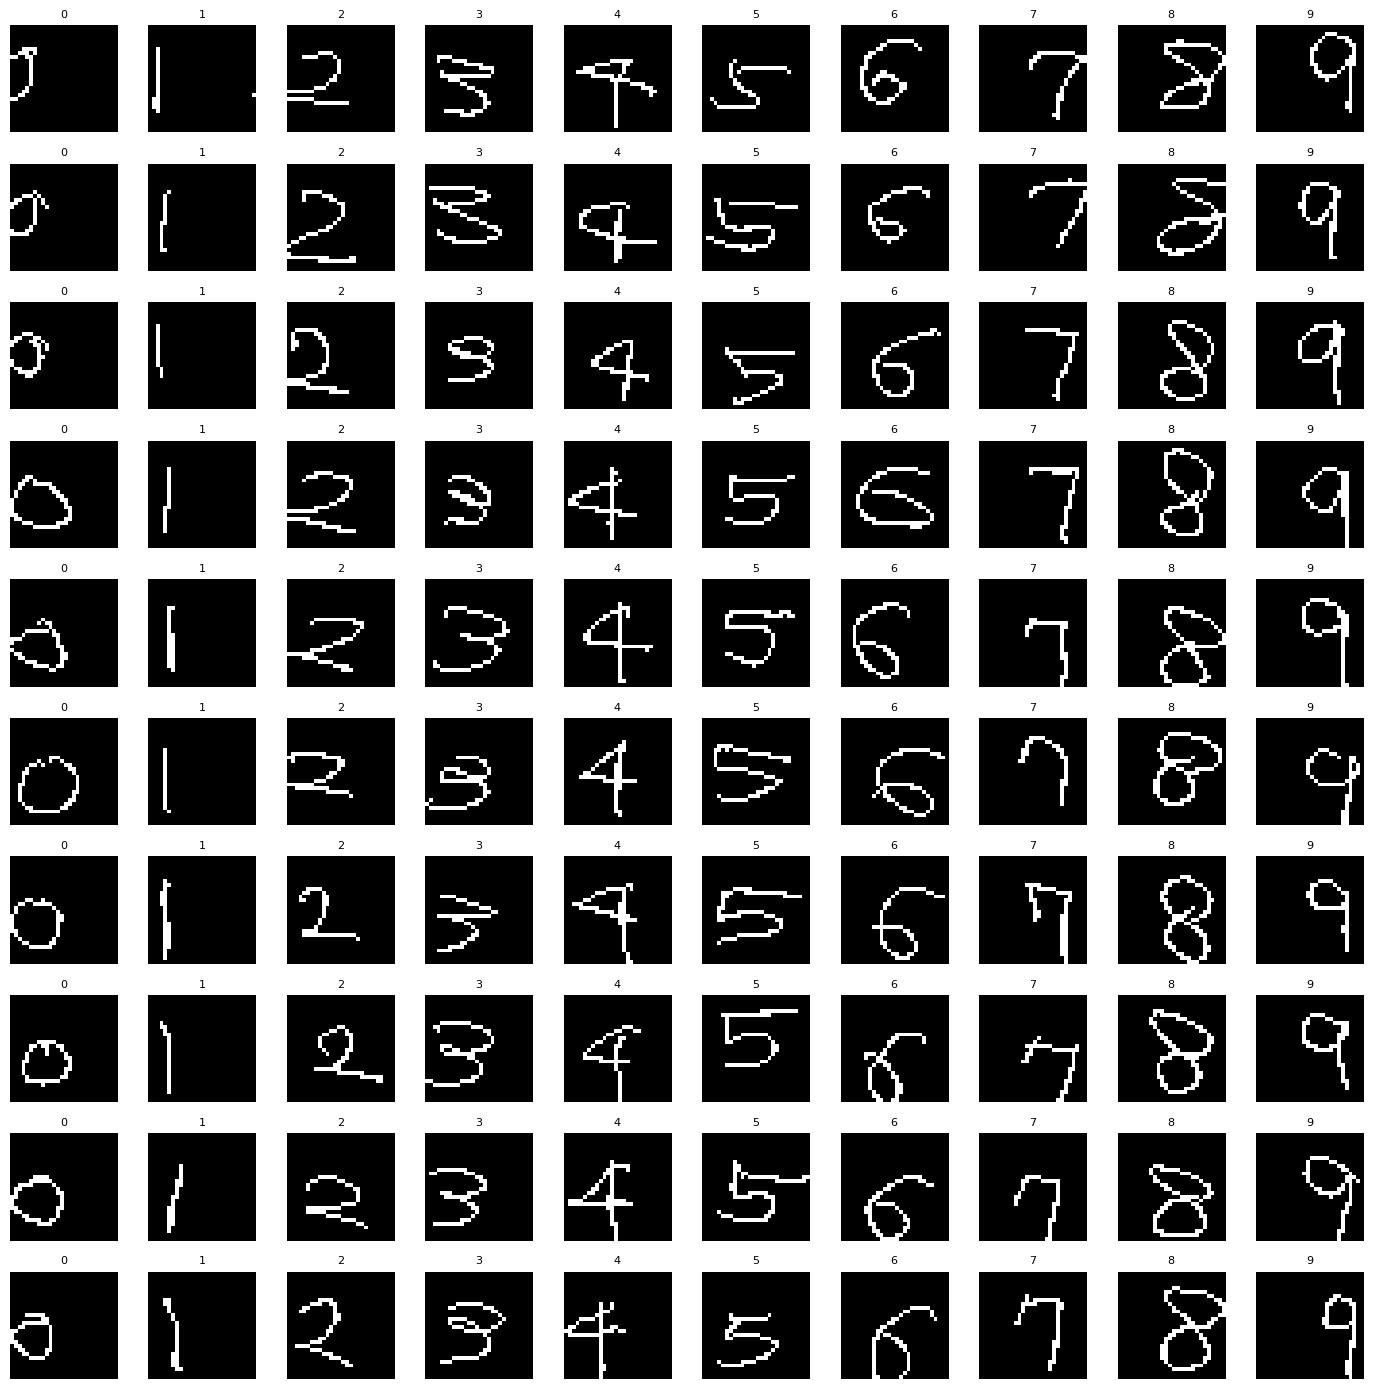


===== 페이지 71 / 95 | 이미지 7000 ~ 7099 =====


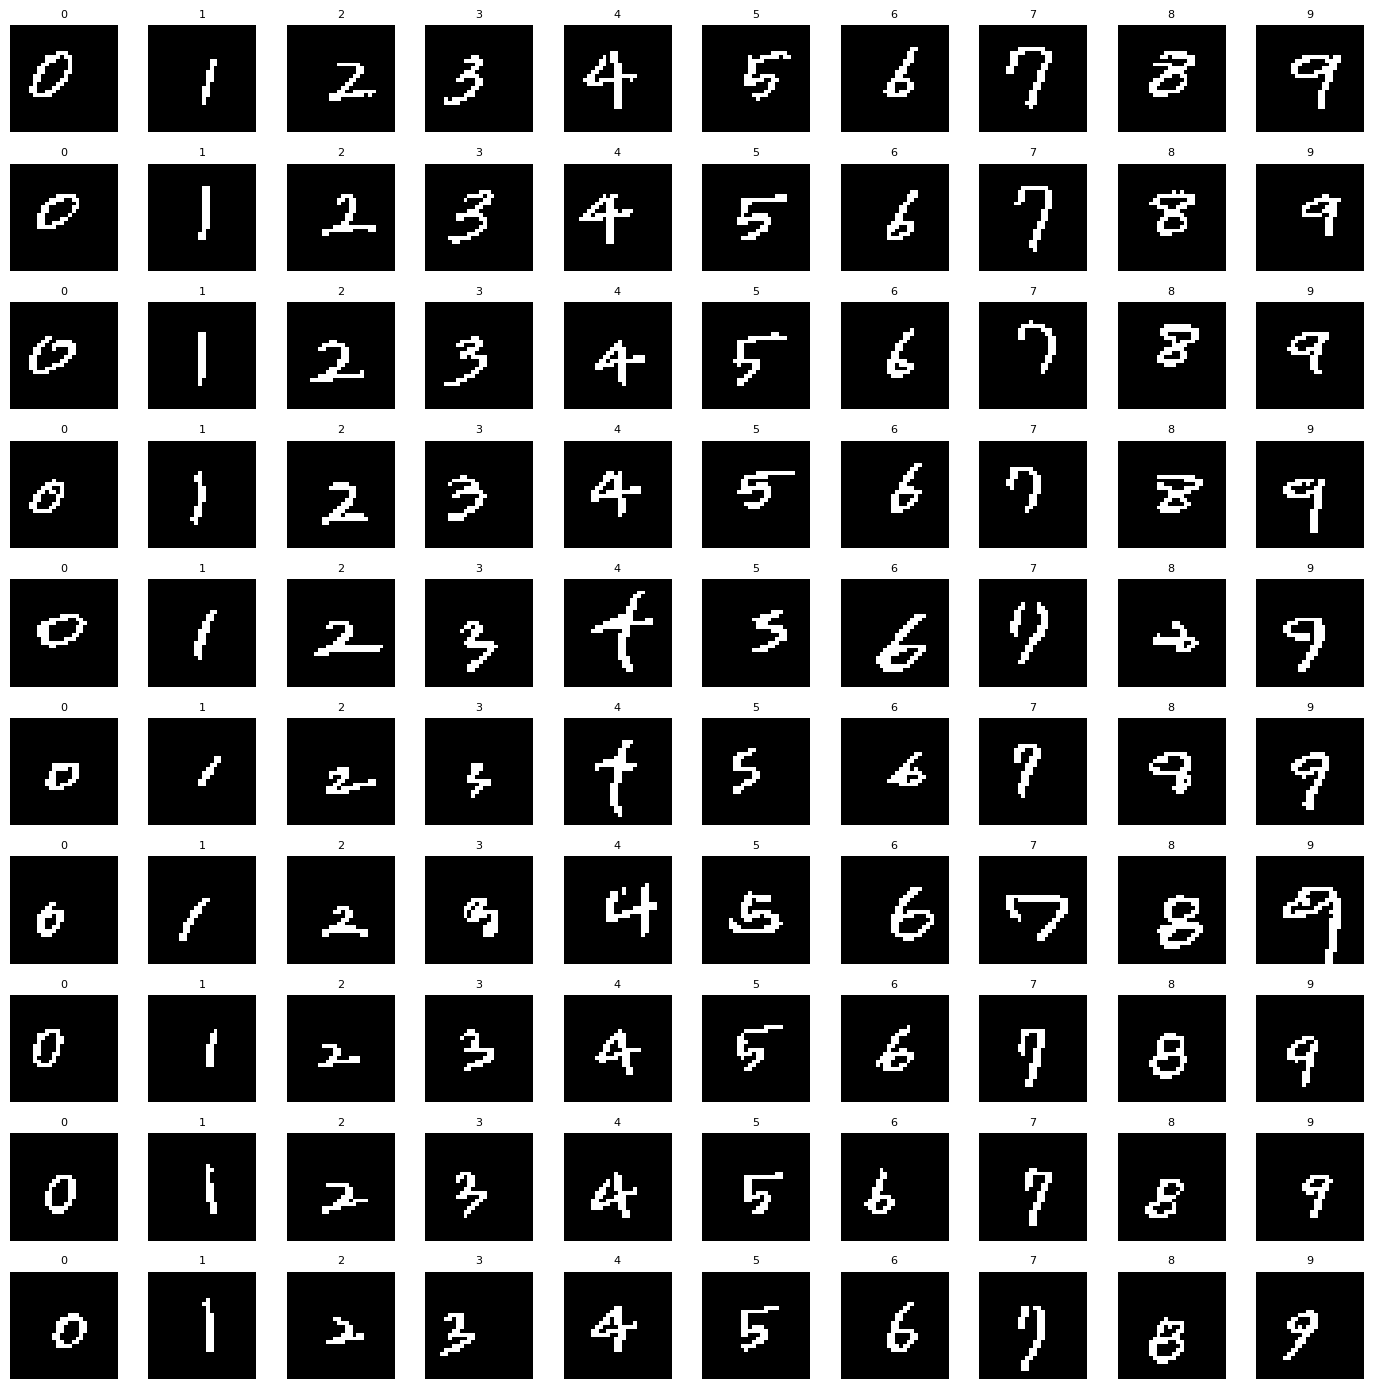


===== 페이지 72 / 95 | 이미지 7100 ~ 7199 =====


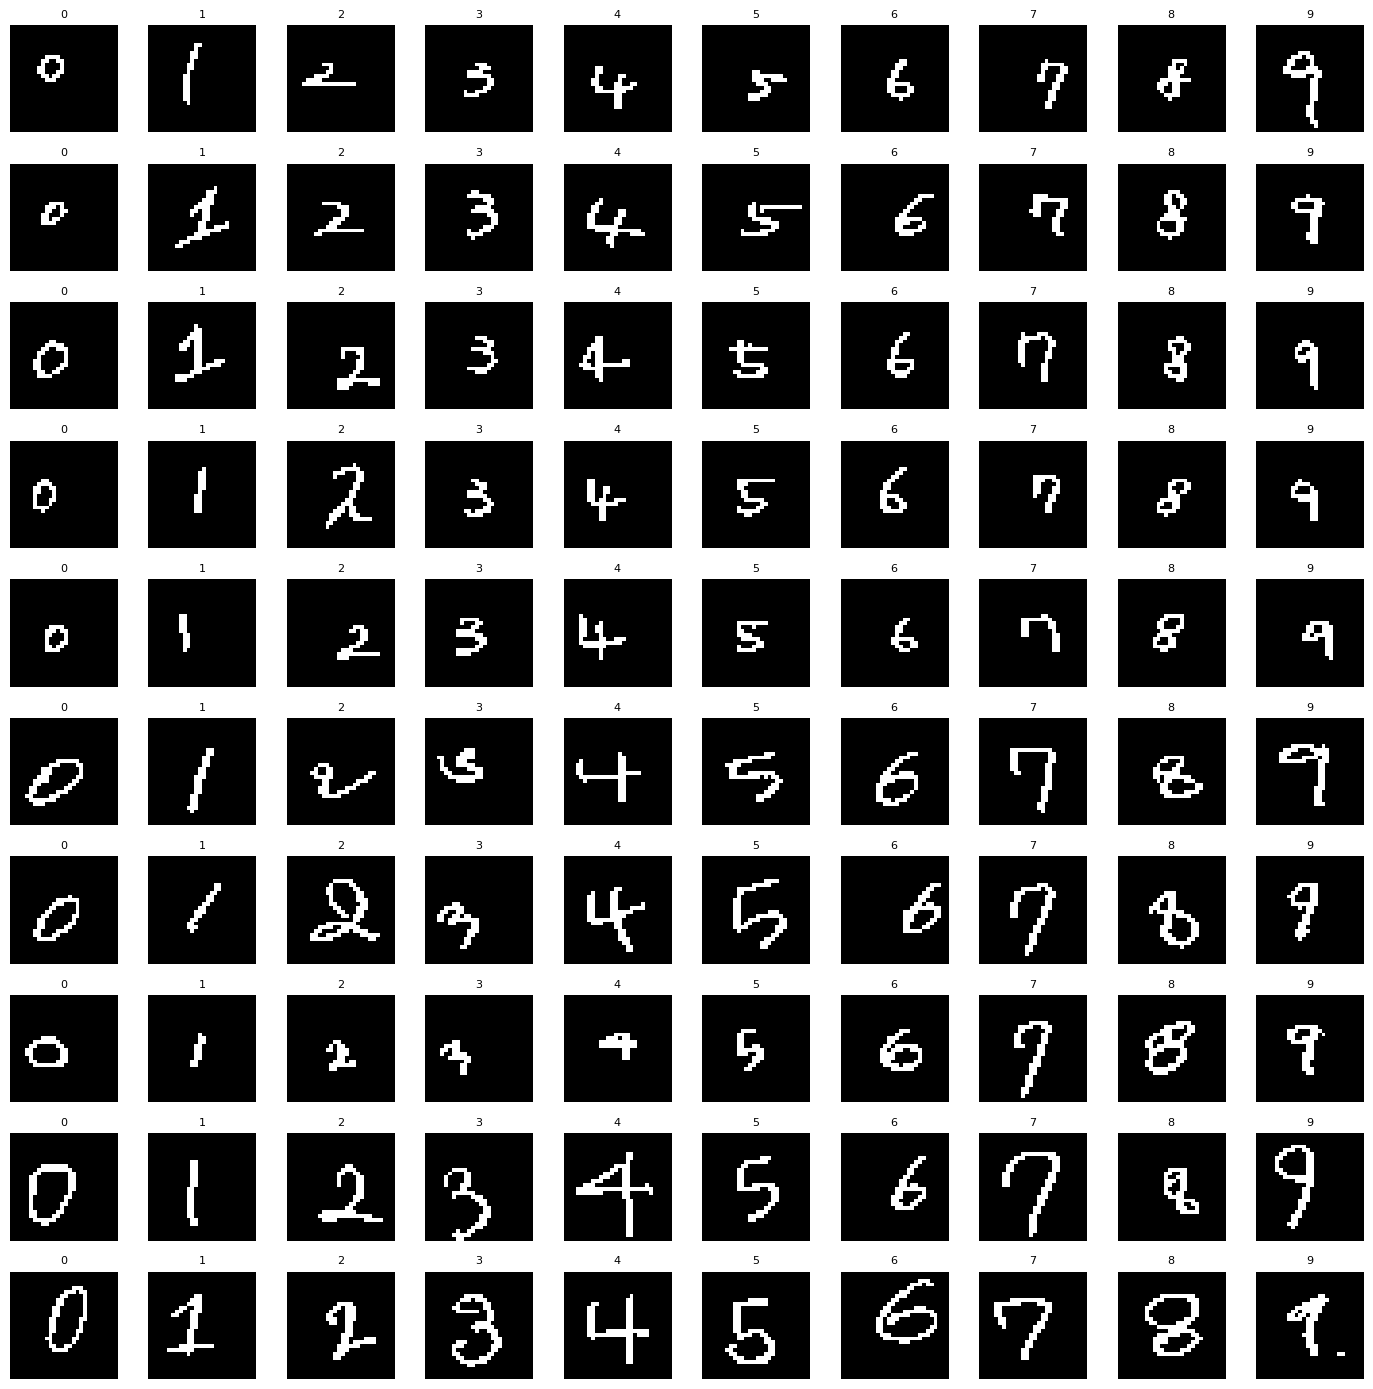


===== 페이지 73 / 95 | 이미지 7200 ~ 7299 =====


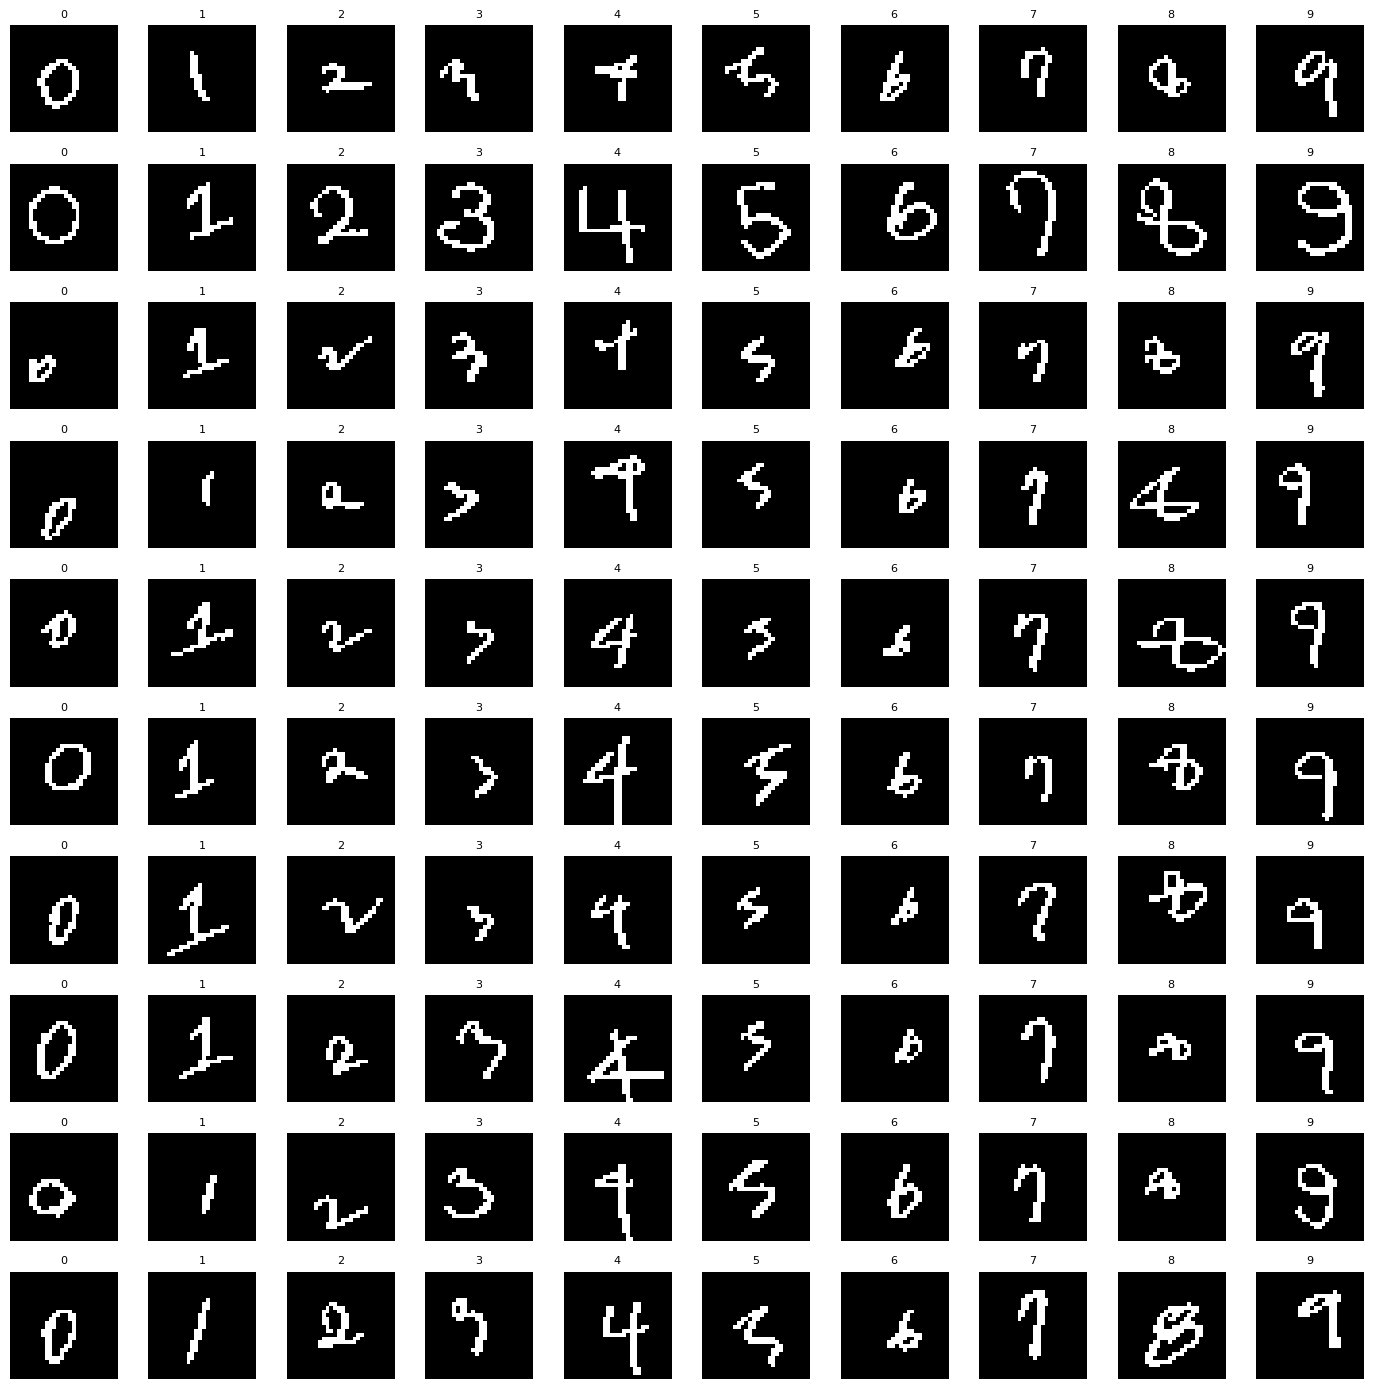


===== 페이지 74 / 95 | 이미지 7300 ~ 7399 =====


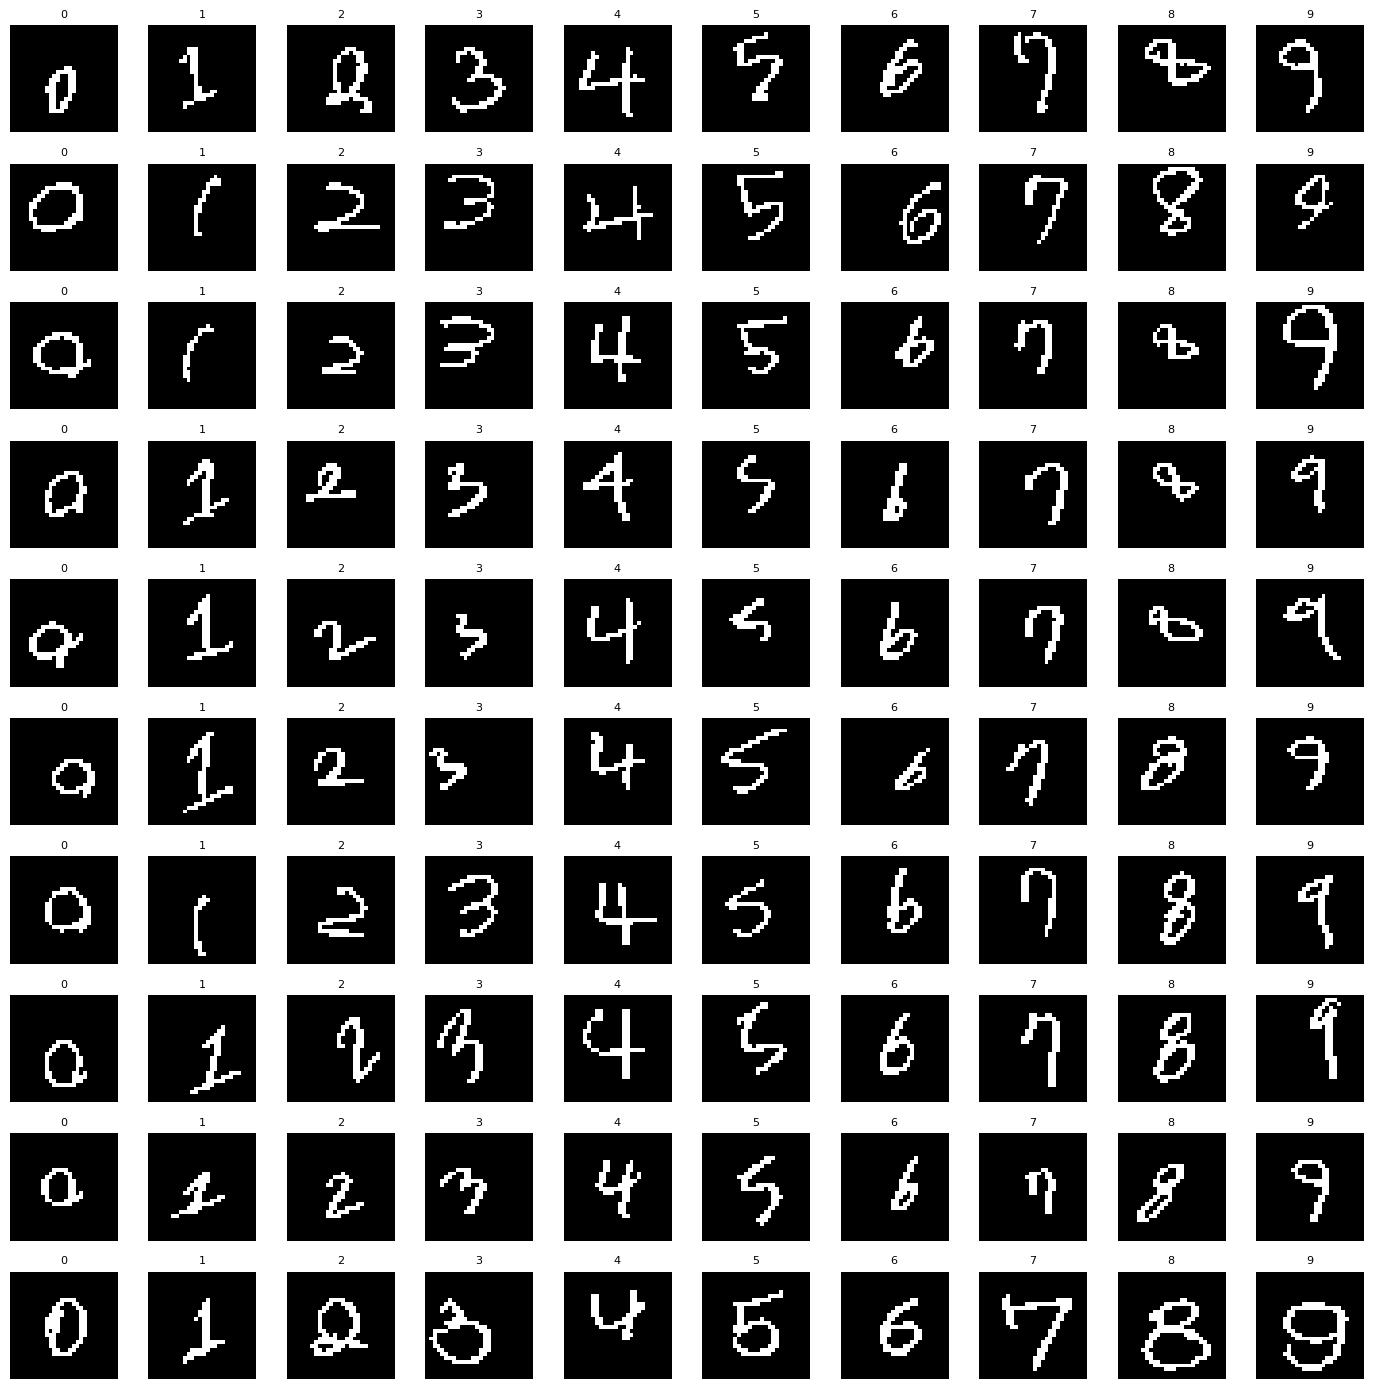


===== 페이지 75 / 95 | 이미지 7400 ~ 7499 =====


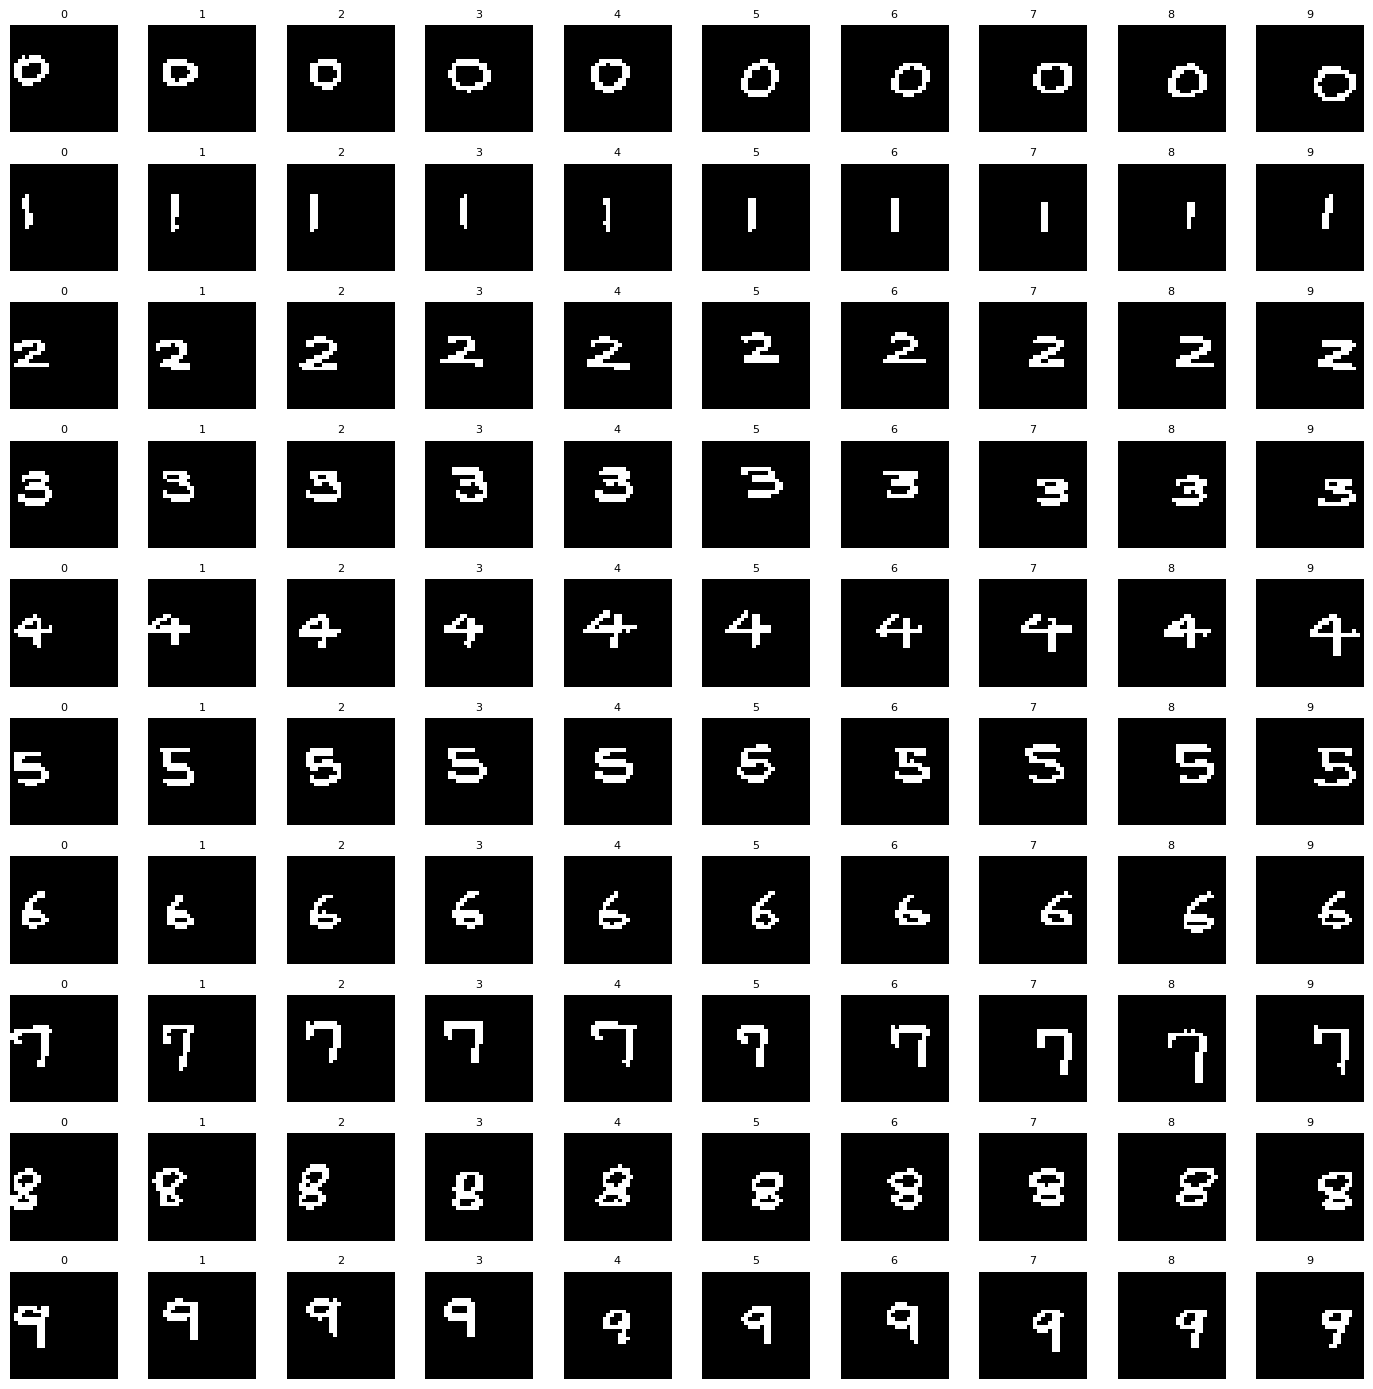


===== 페이지 76 / 95 | 이미지 7500 ~ 7599 =====


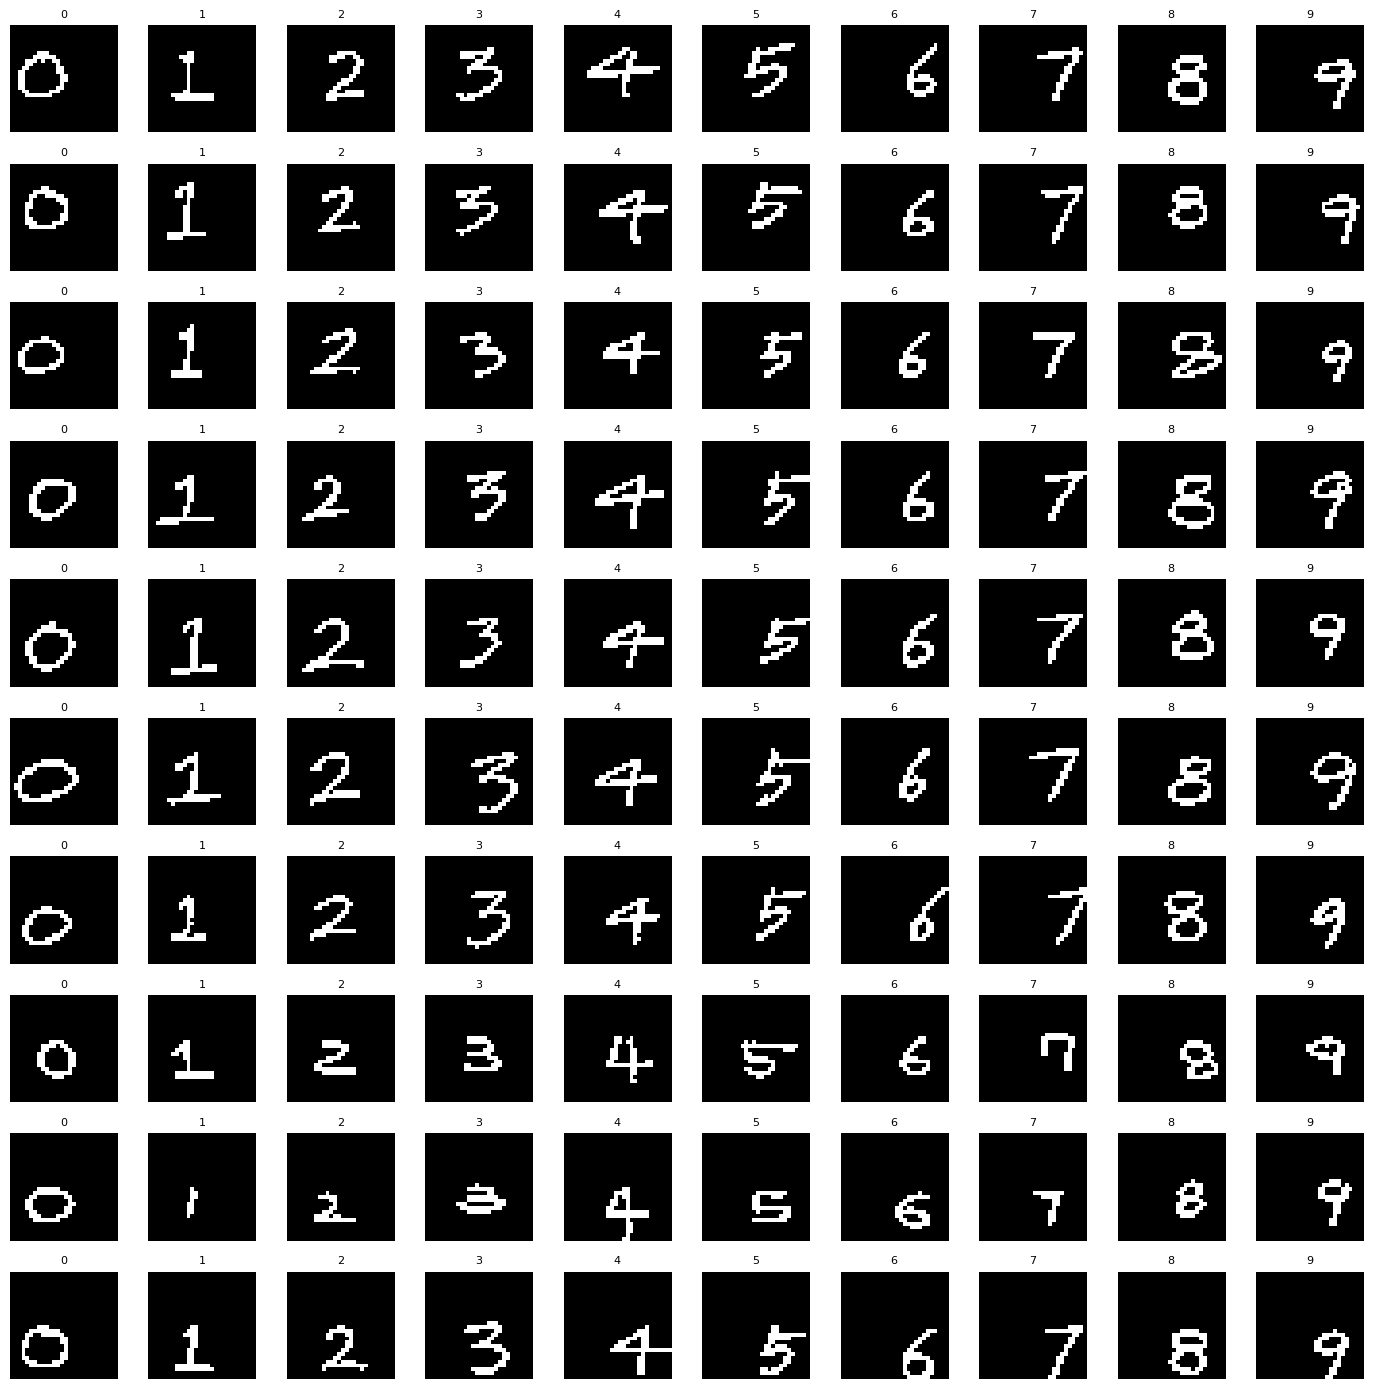


===== 페이지 77 / 95 | 이미지 7600 ~ 7699 =====


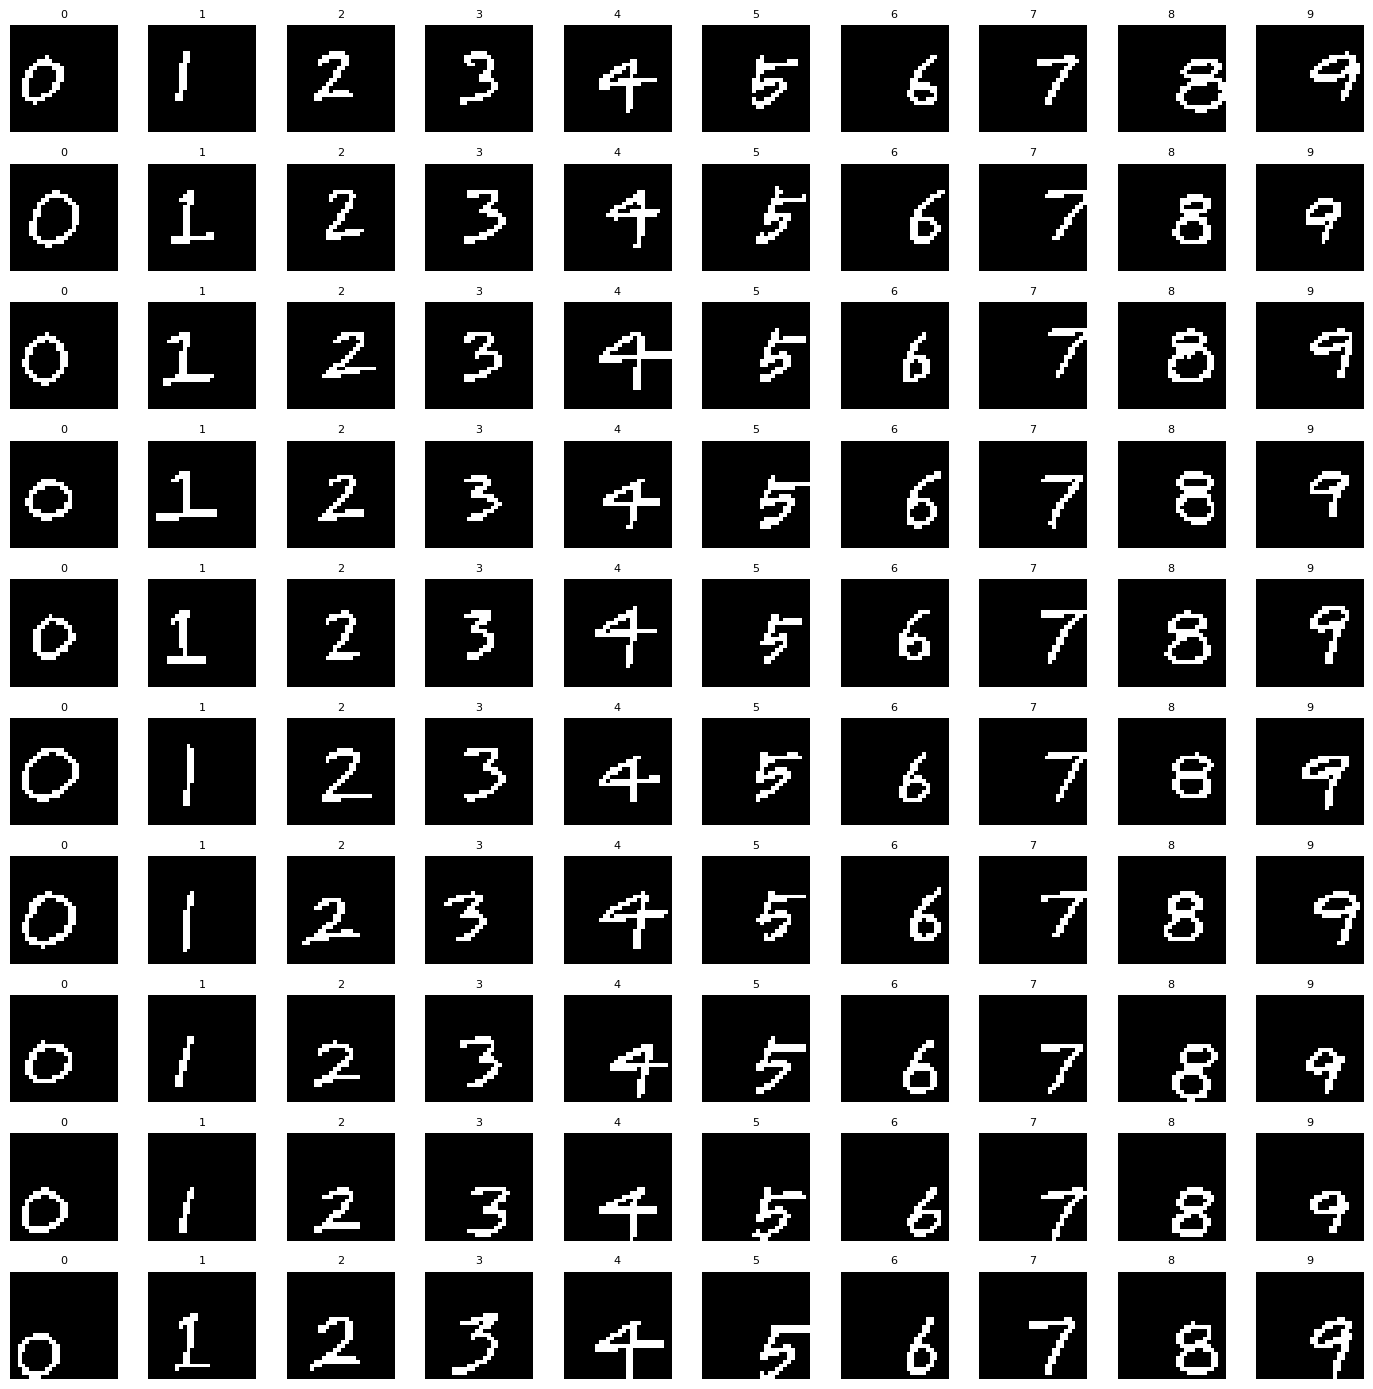


===== 페이지 78 / 95 | 이미지 7700 ~ 7799 =====


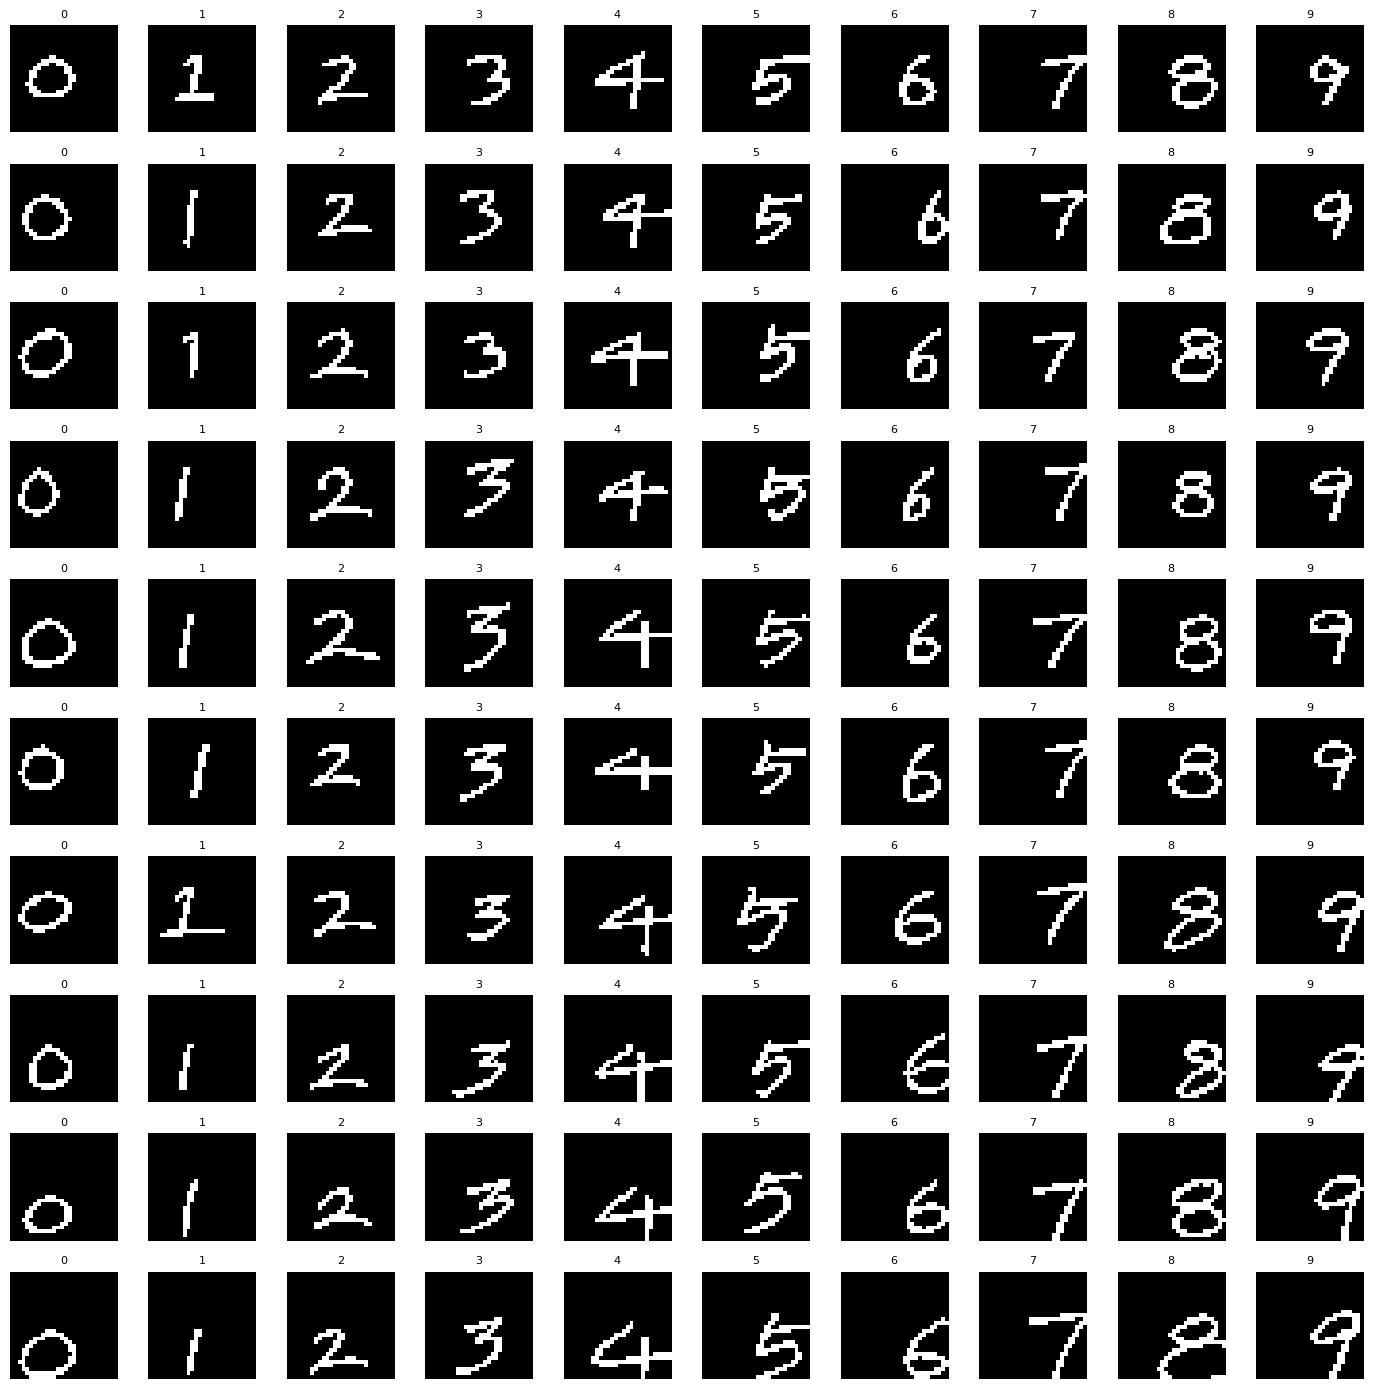


===== 페이지 79 / 95 | 이미지 7800 ~ 7899 =====


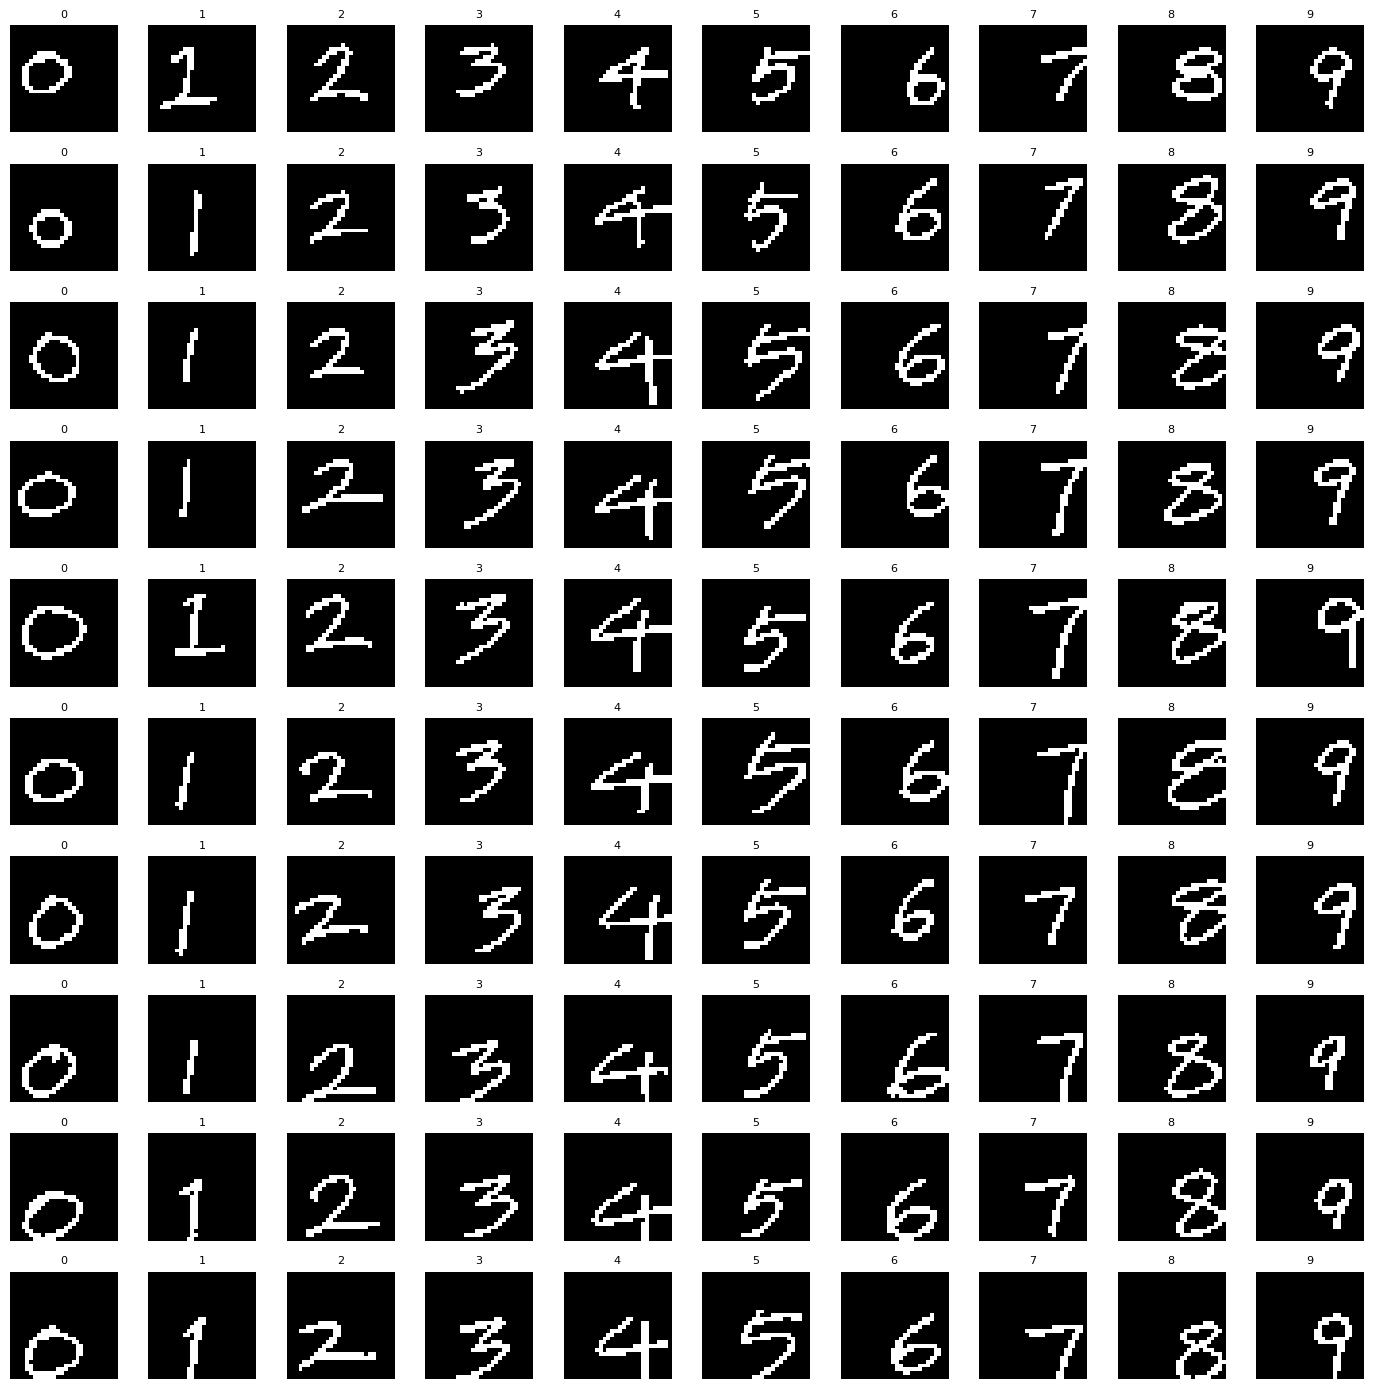


===== 페이지 80 / 95 | 이미지 7900 ~ 7999 =====


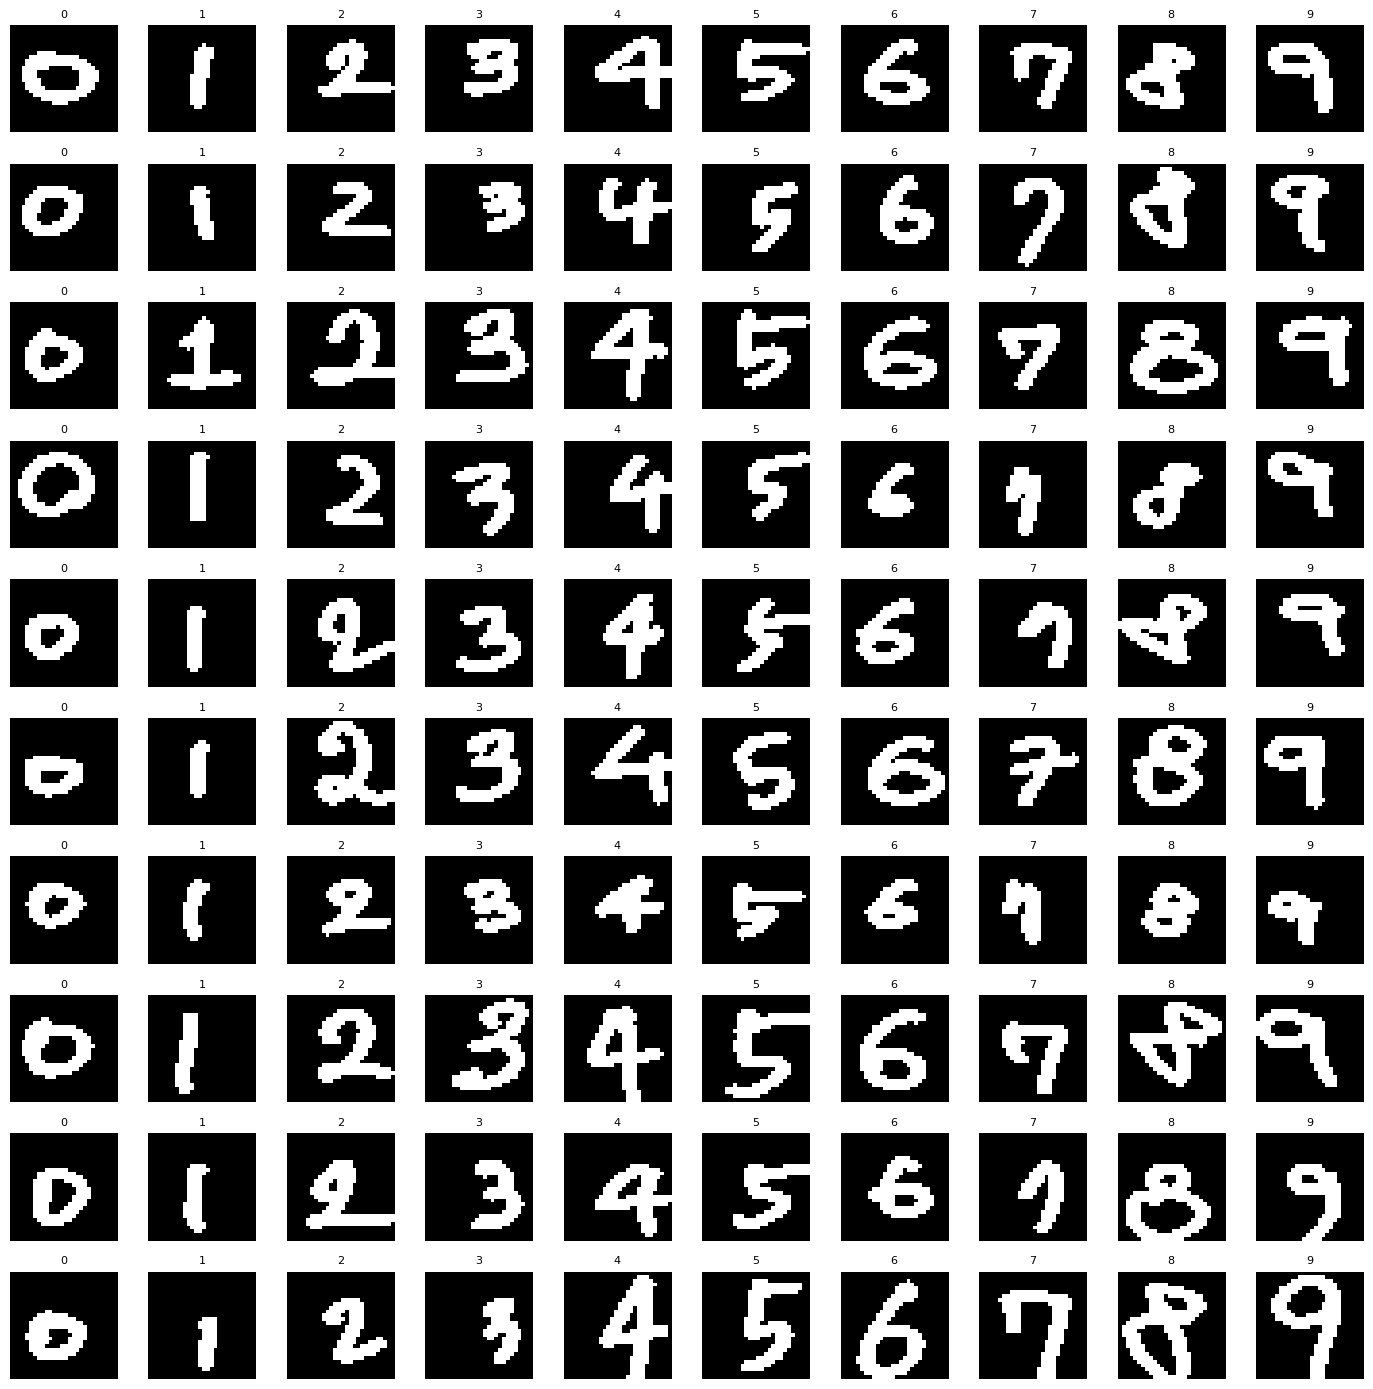


===== 페이지 81 / 95 | 이미지 8000 ~ 8099 =====


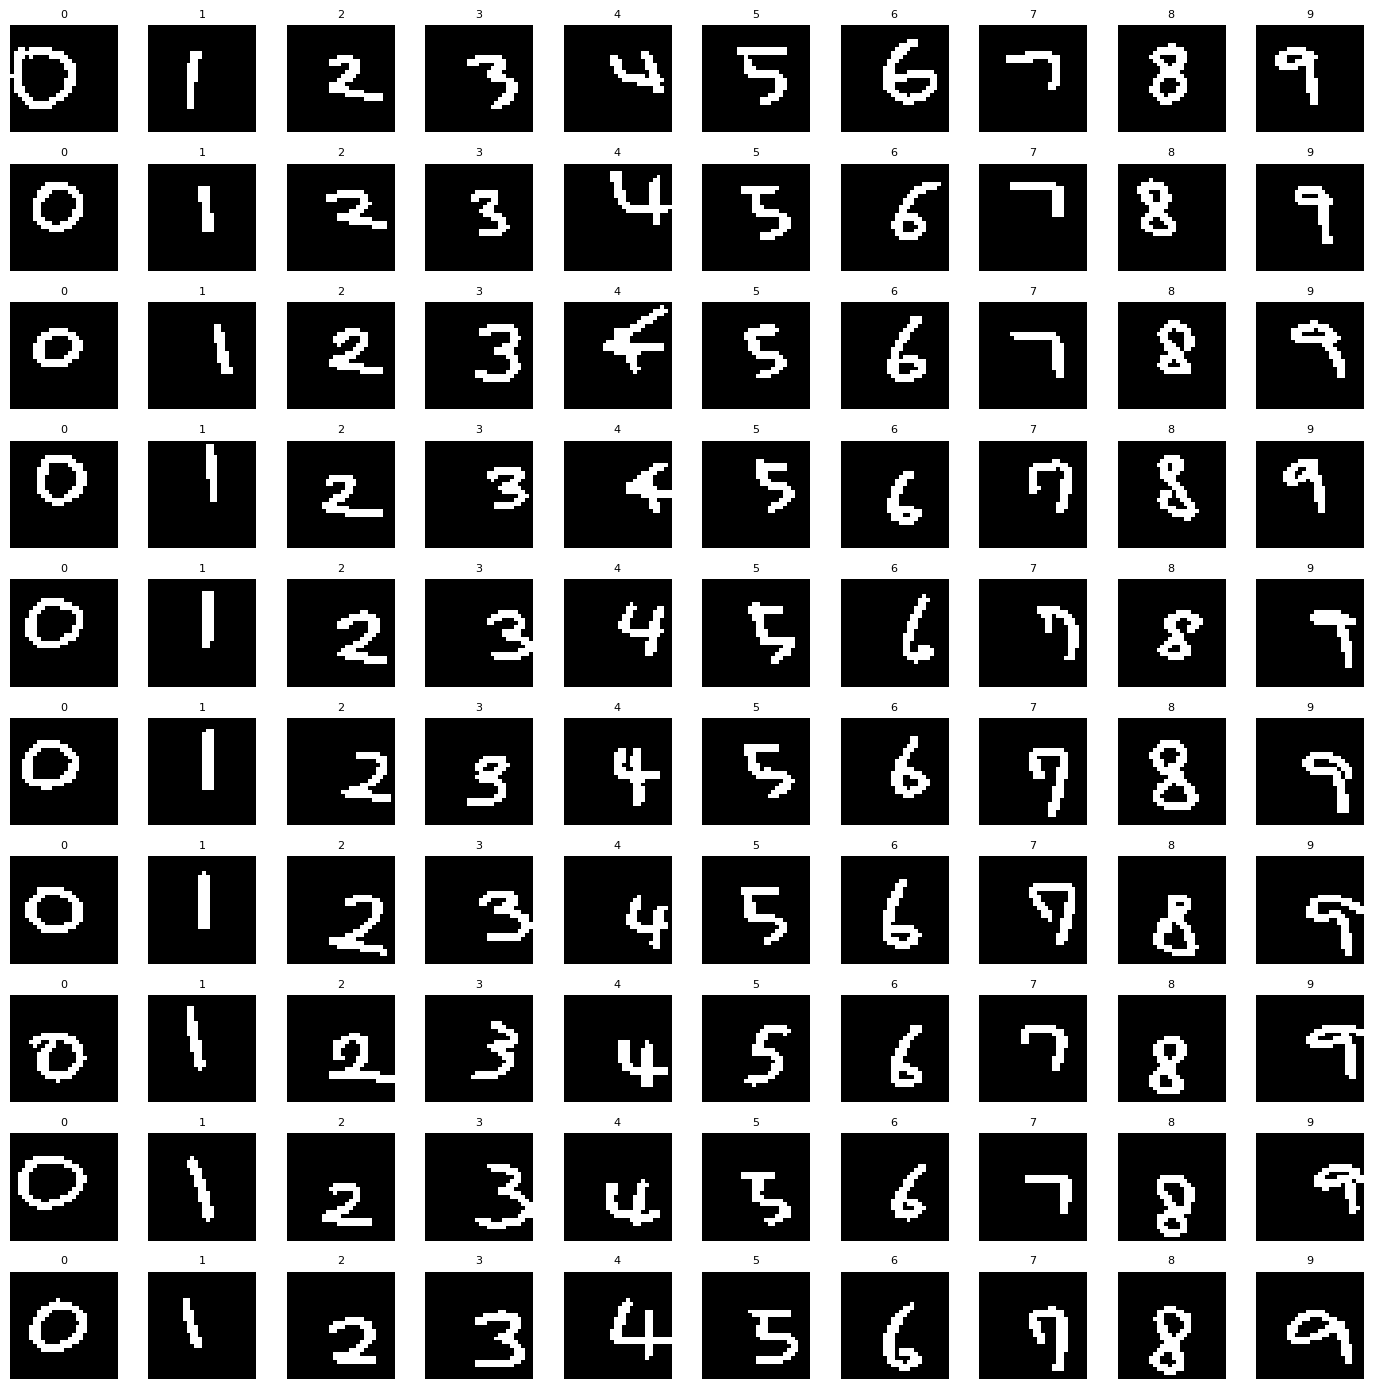


===== 페이지 82 / 95 | 이미지 8100 ~ 8199 =====


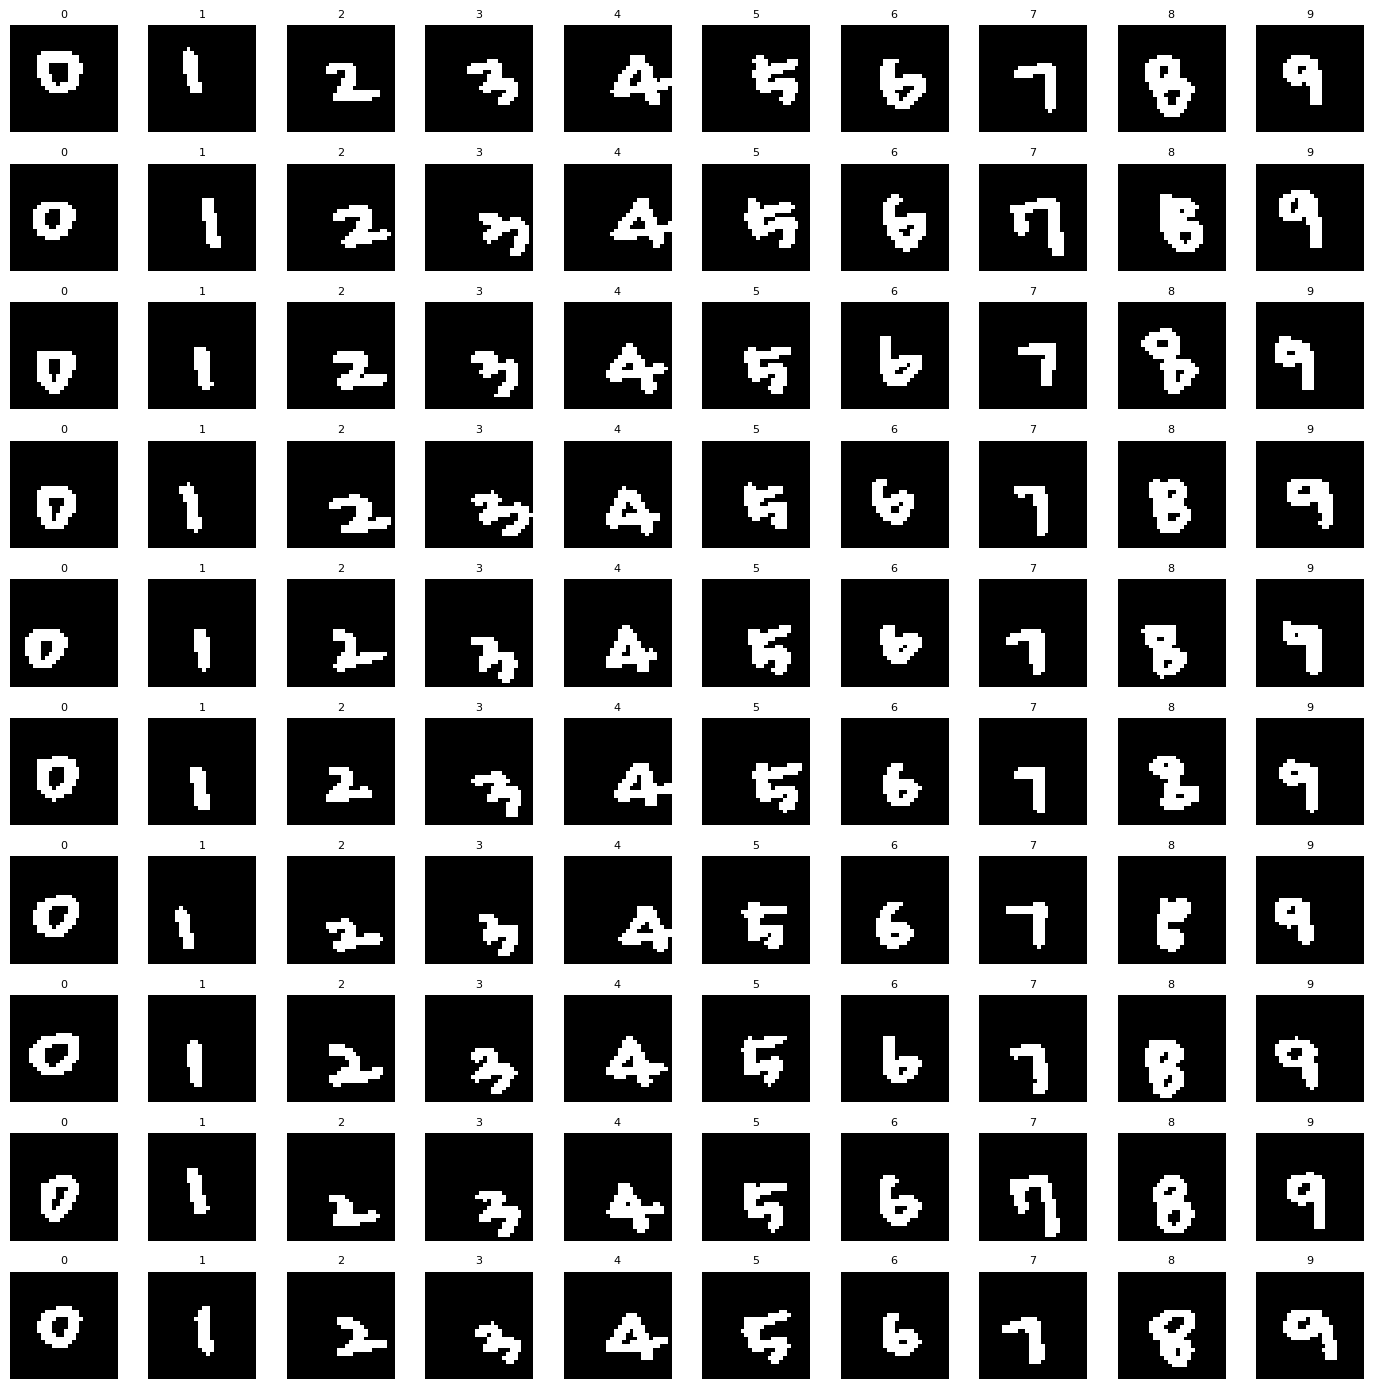


===== 페이지 83 / 95 | 이미지 8200 ~ 8299 =====


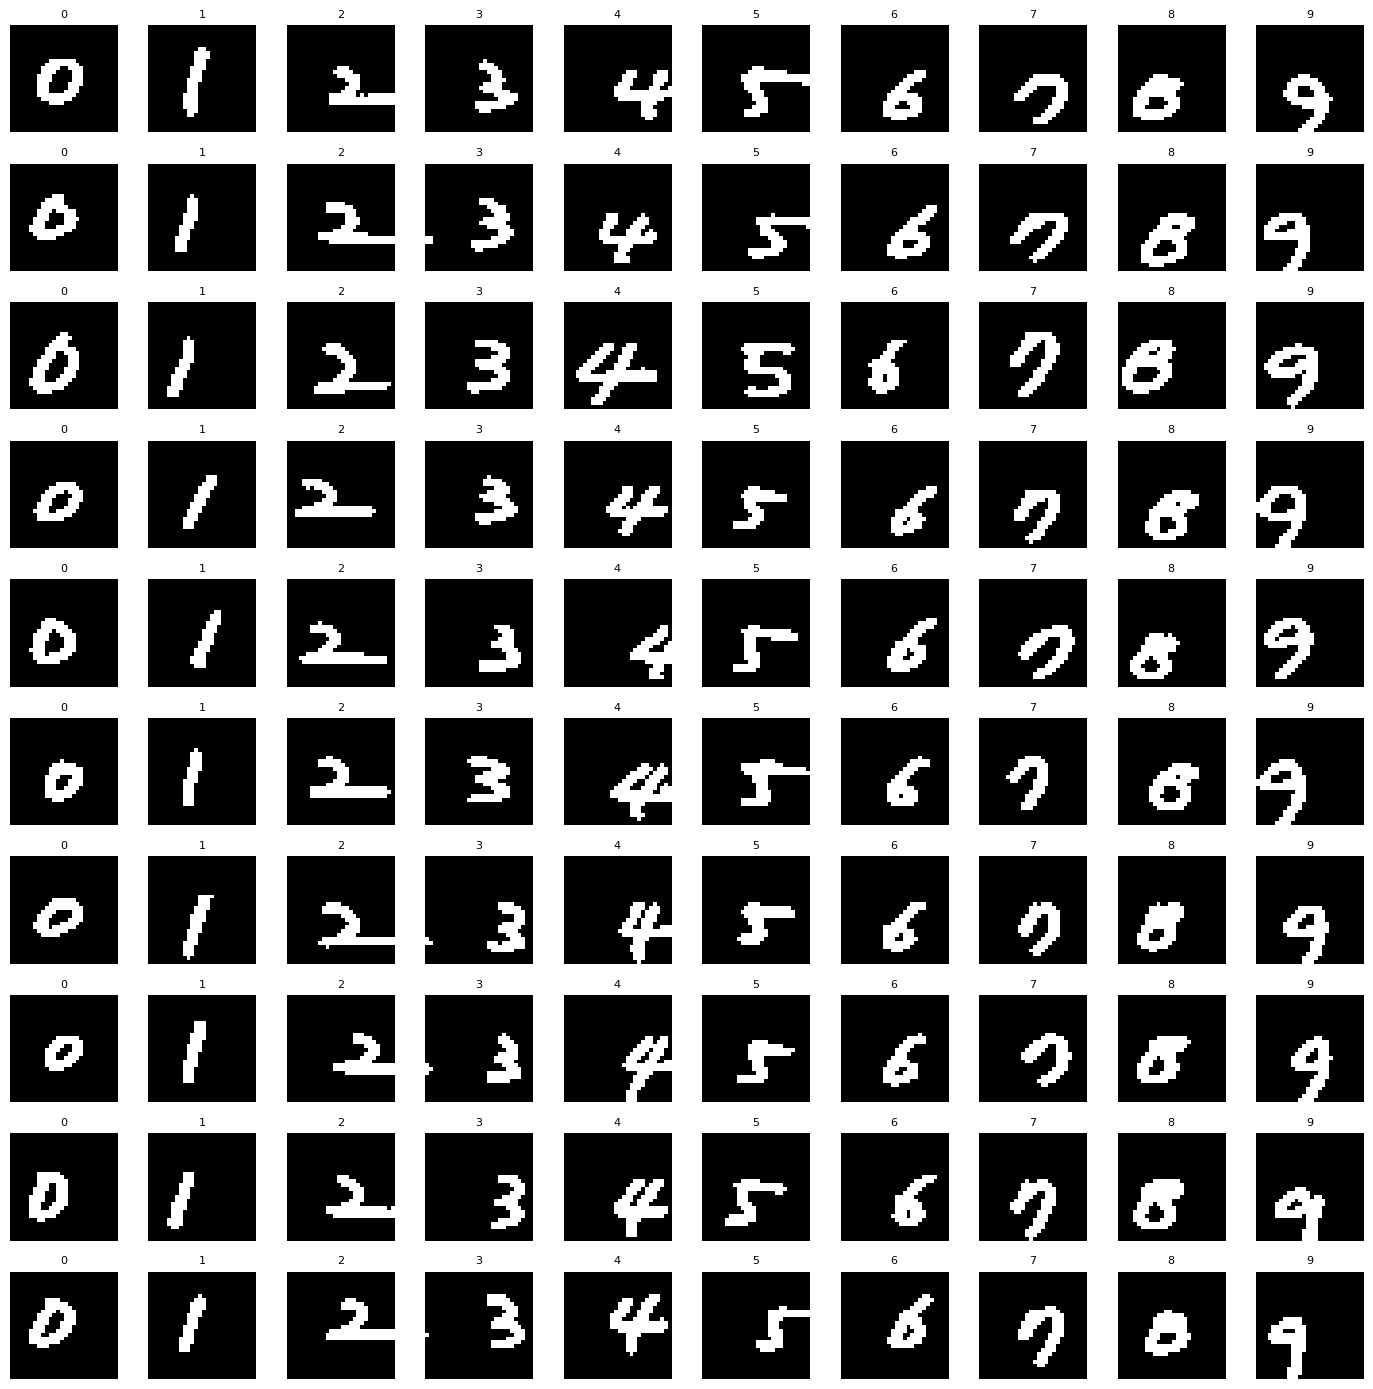


===== 페이지 84 / 95 | 이미지 8300 ~ 8399 =====


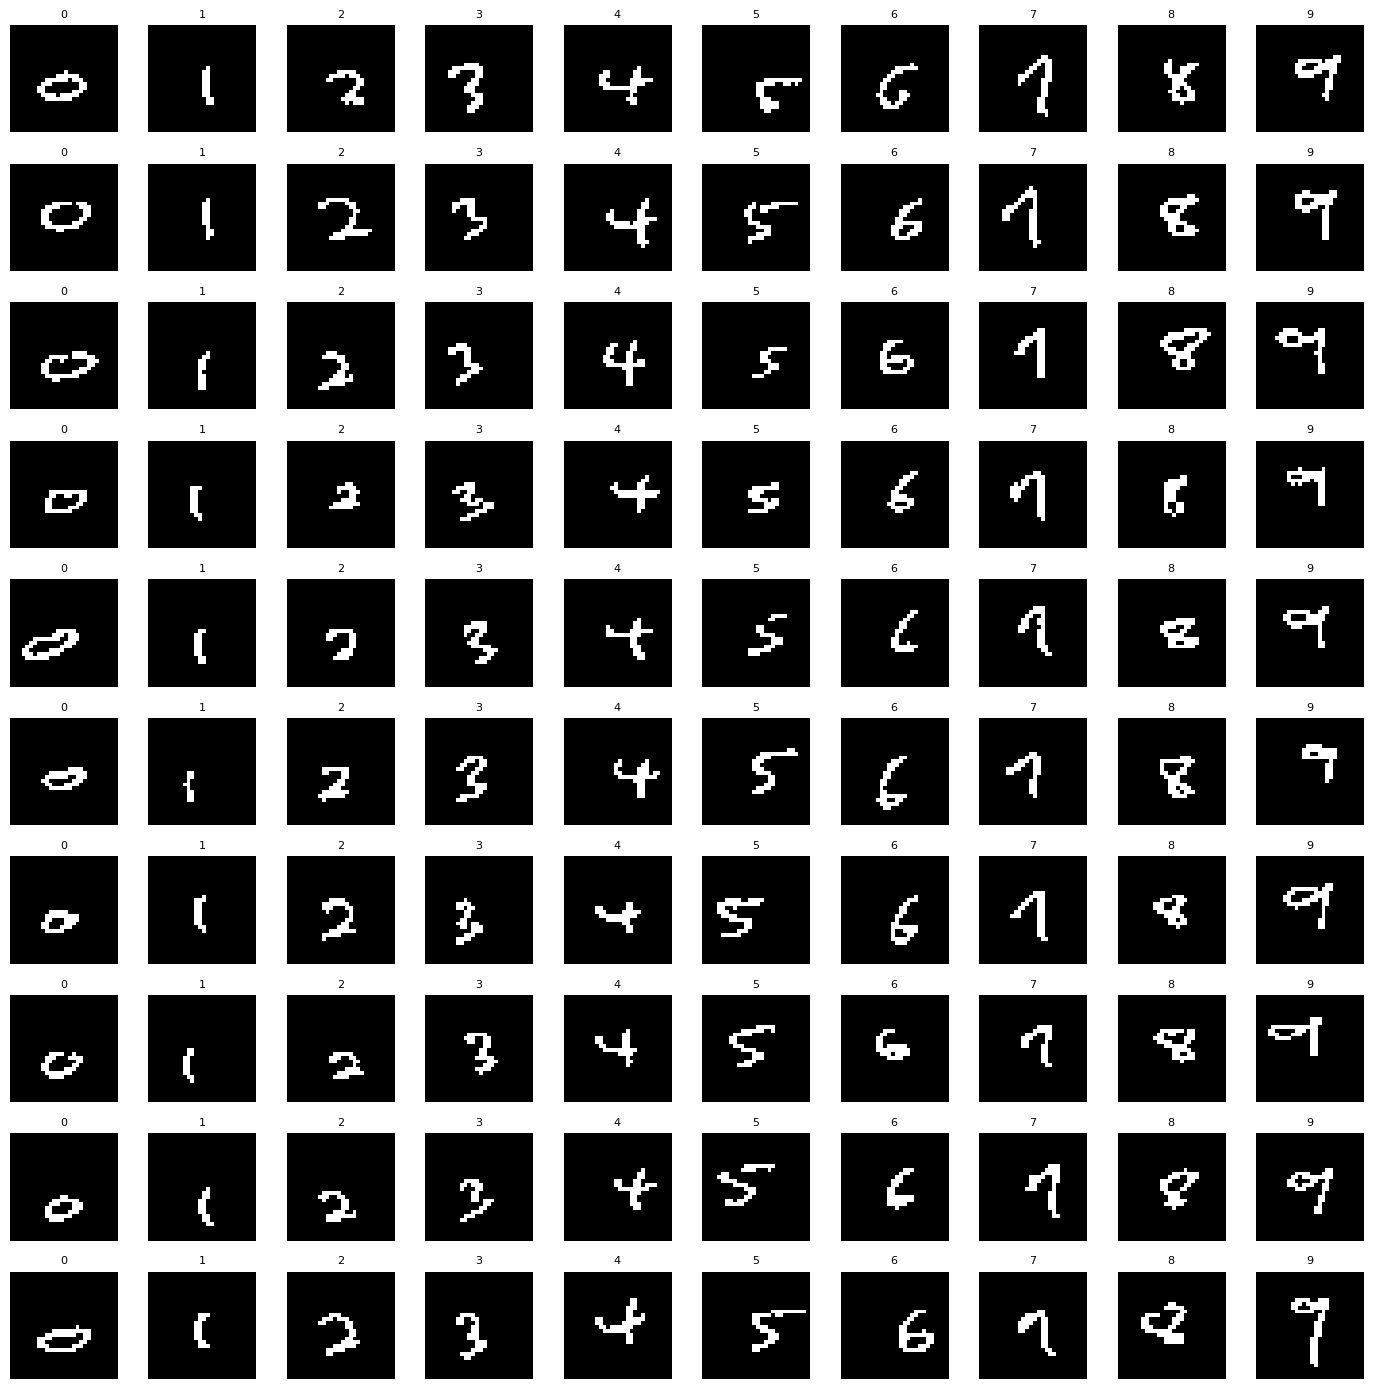


===== 페이지 85 / 95 | 이미지 8400 ~ 8499 =====


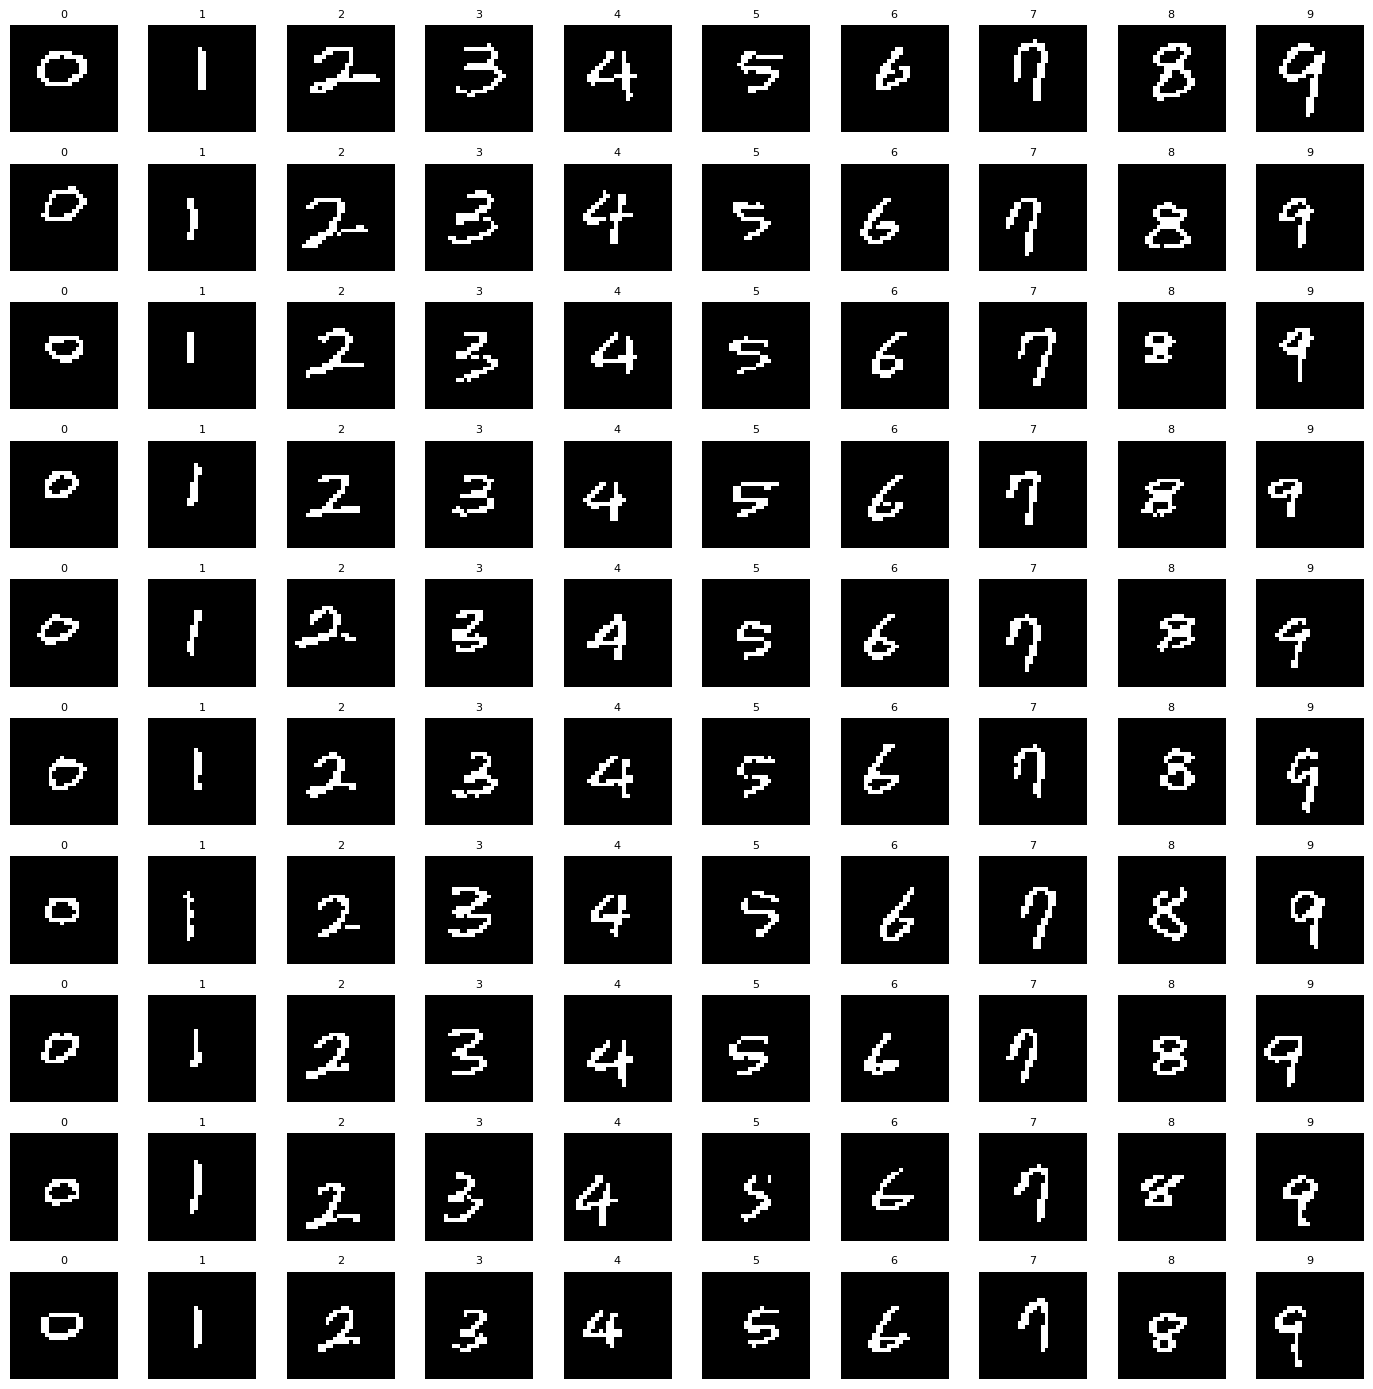


===== 페이지 86 / 95 | 이미지 8500 ~ 8599 =====


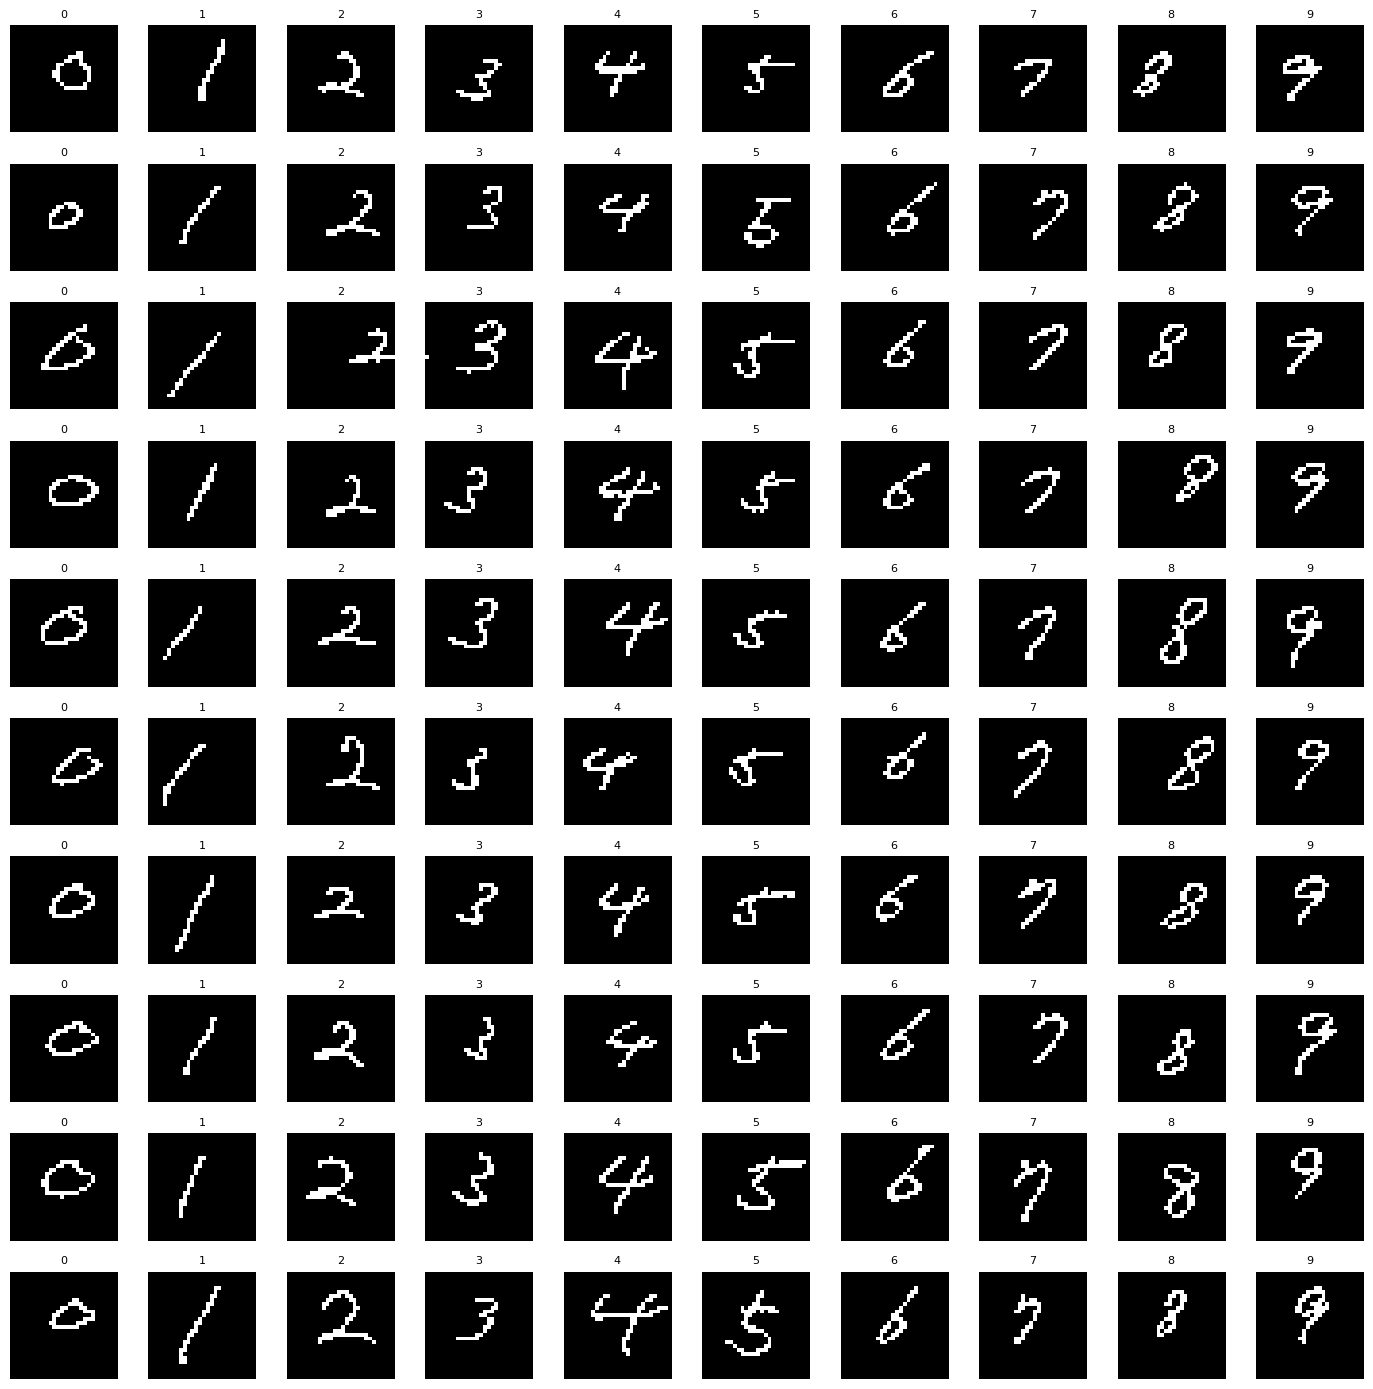


===== 페이지 87 / 95 | 이미지 8600 ~ 8699 =====


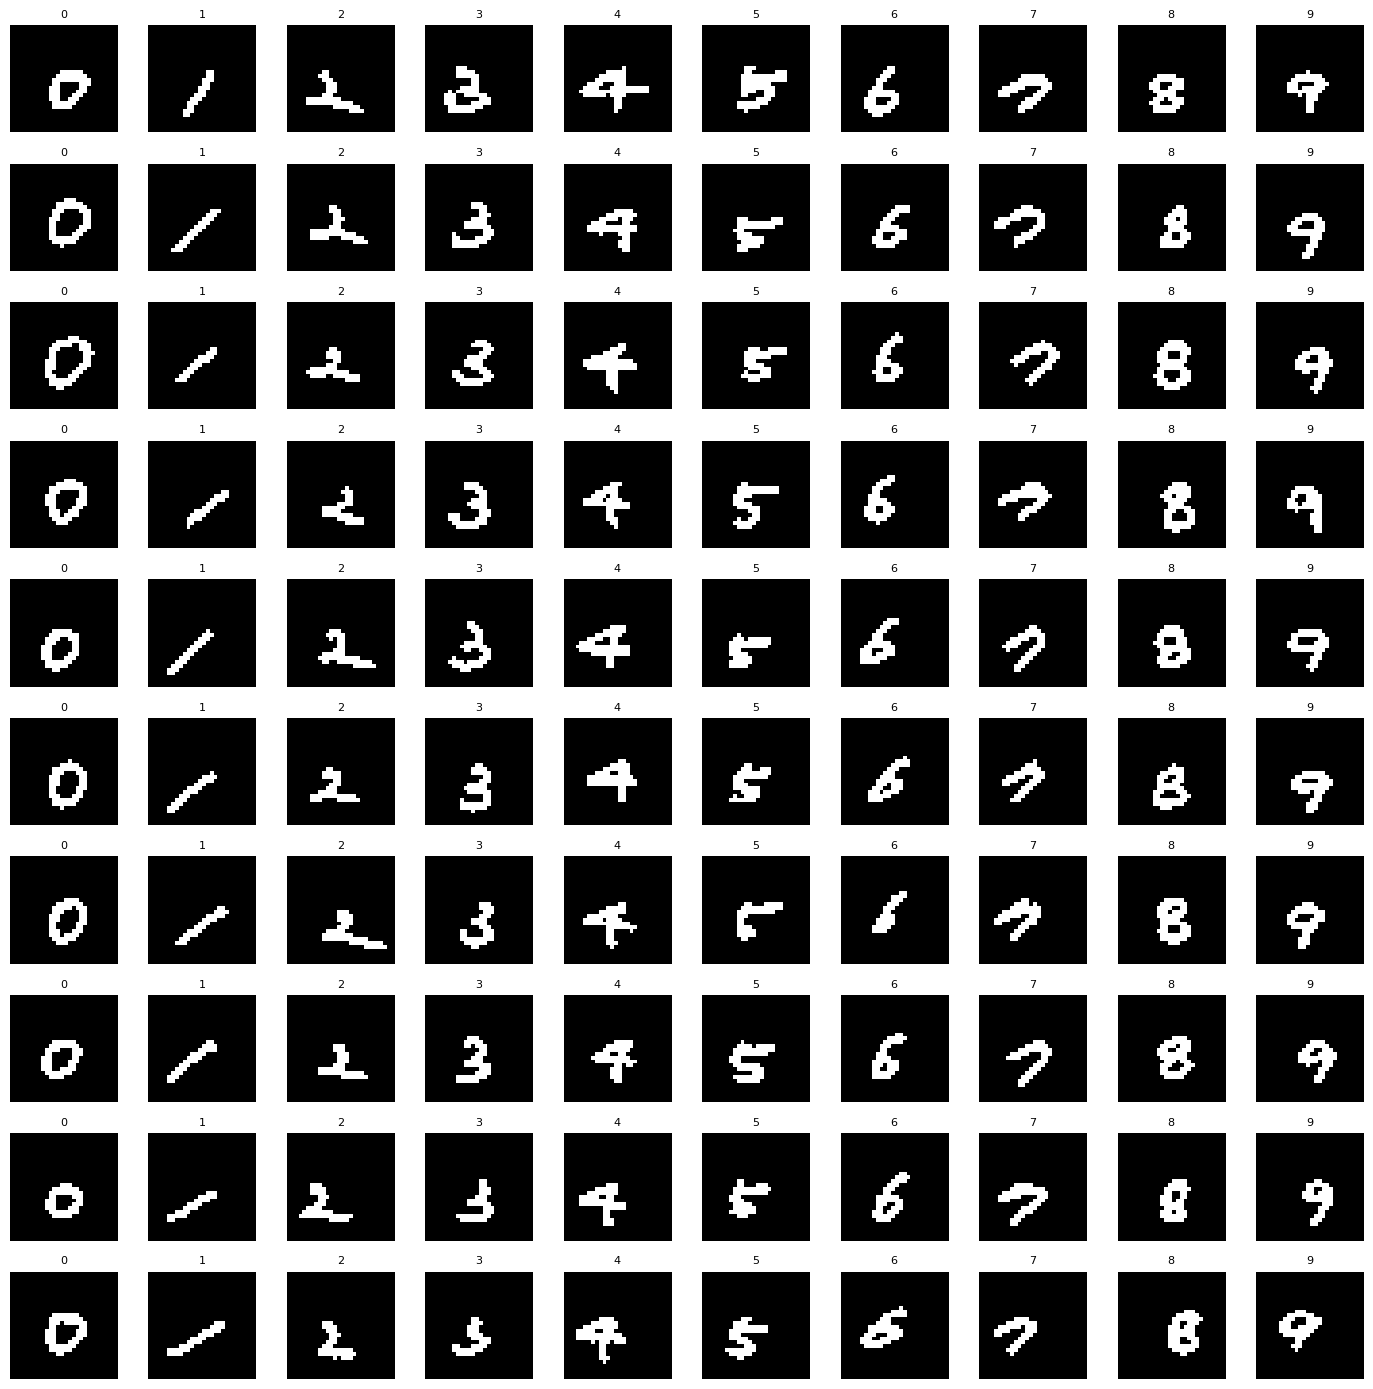


===== 페이지 88 / 95 | 이미지 8700 ~ 8799 =====


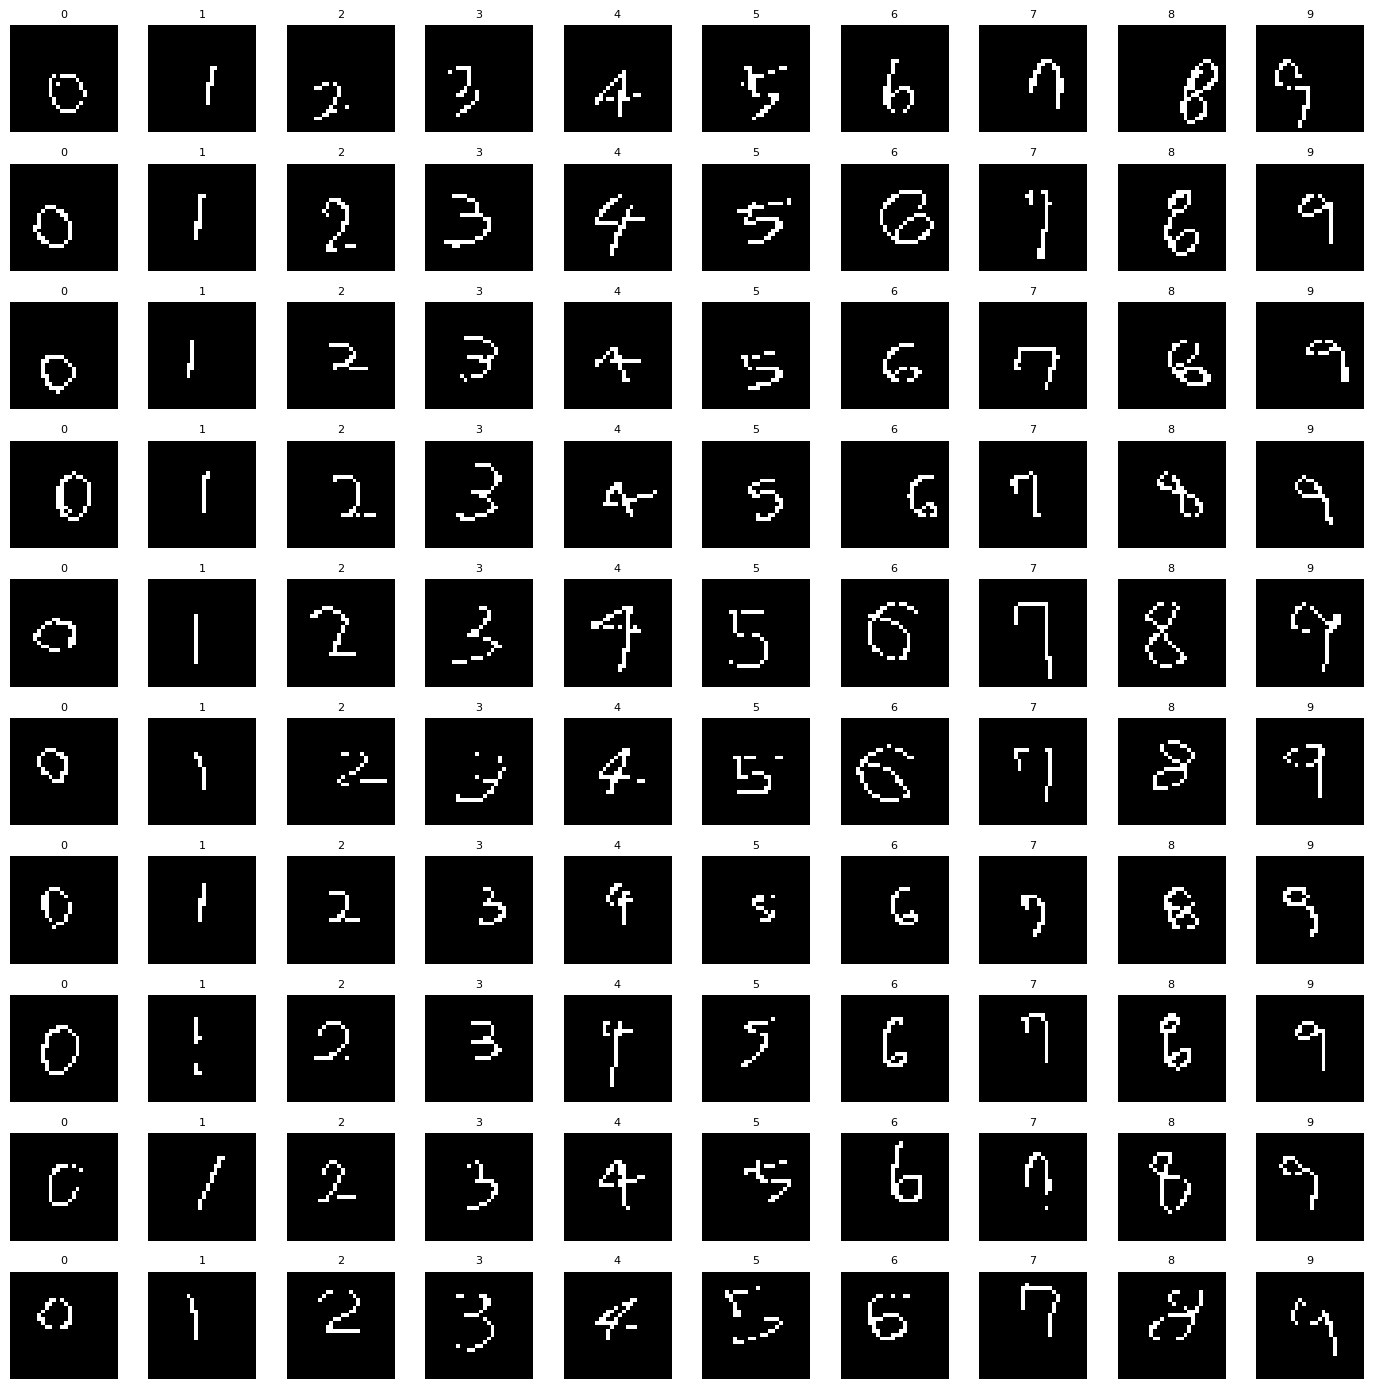


===== 페이지 89 / 95 | 이미지 8800 ~ 8899 =====


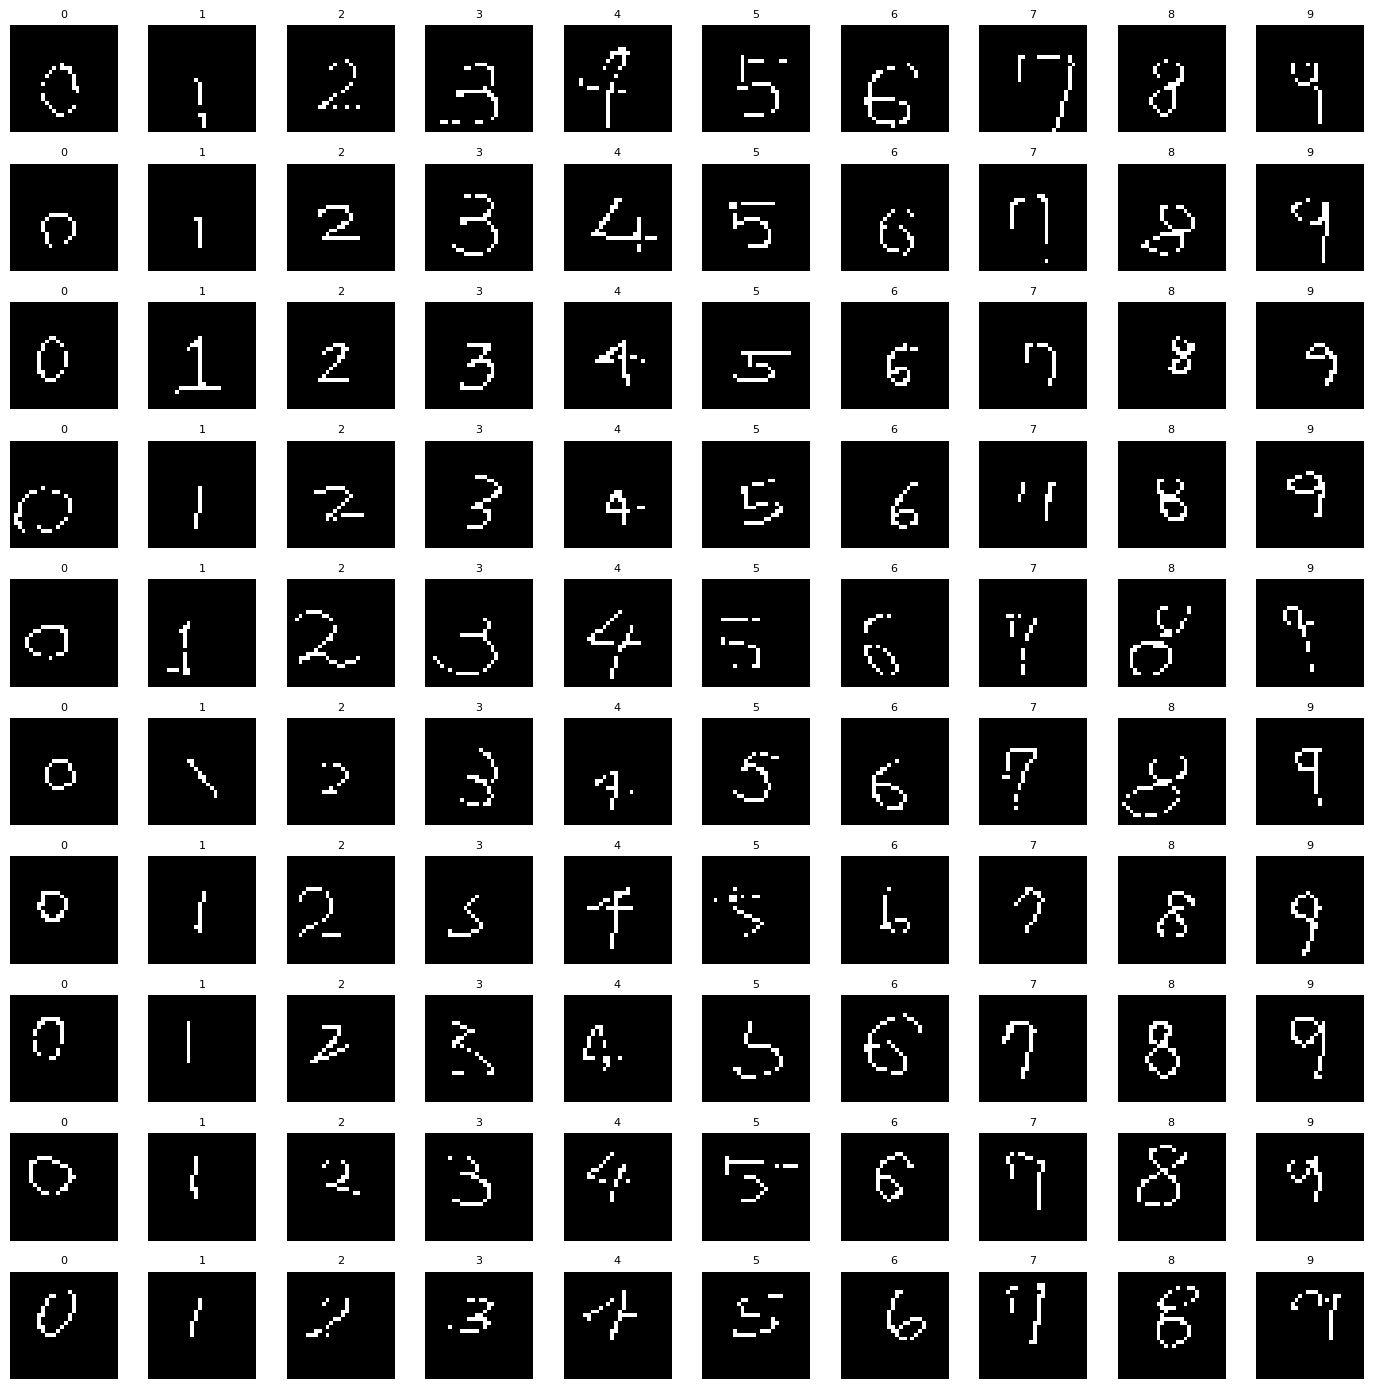


===== 페이지 90 / 95 | 이미지 8900 ~ 8999 =====


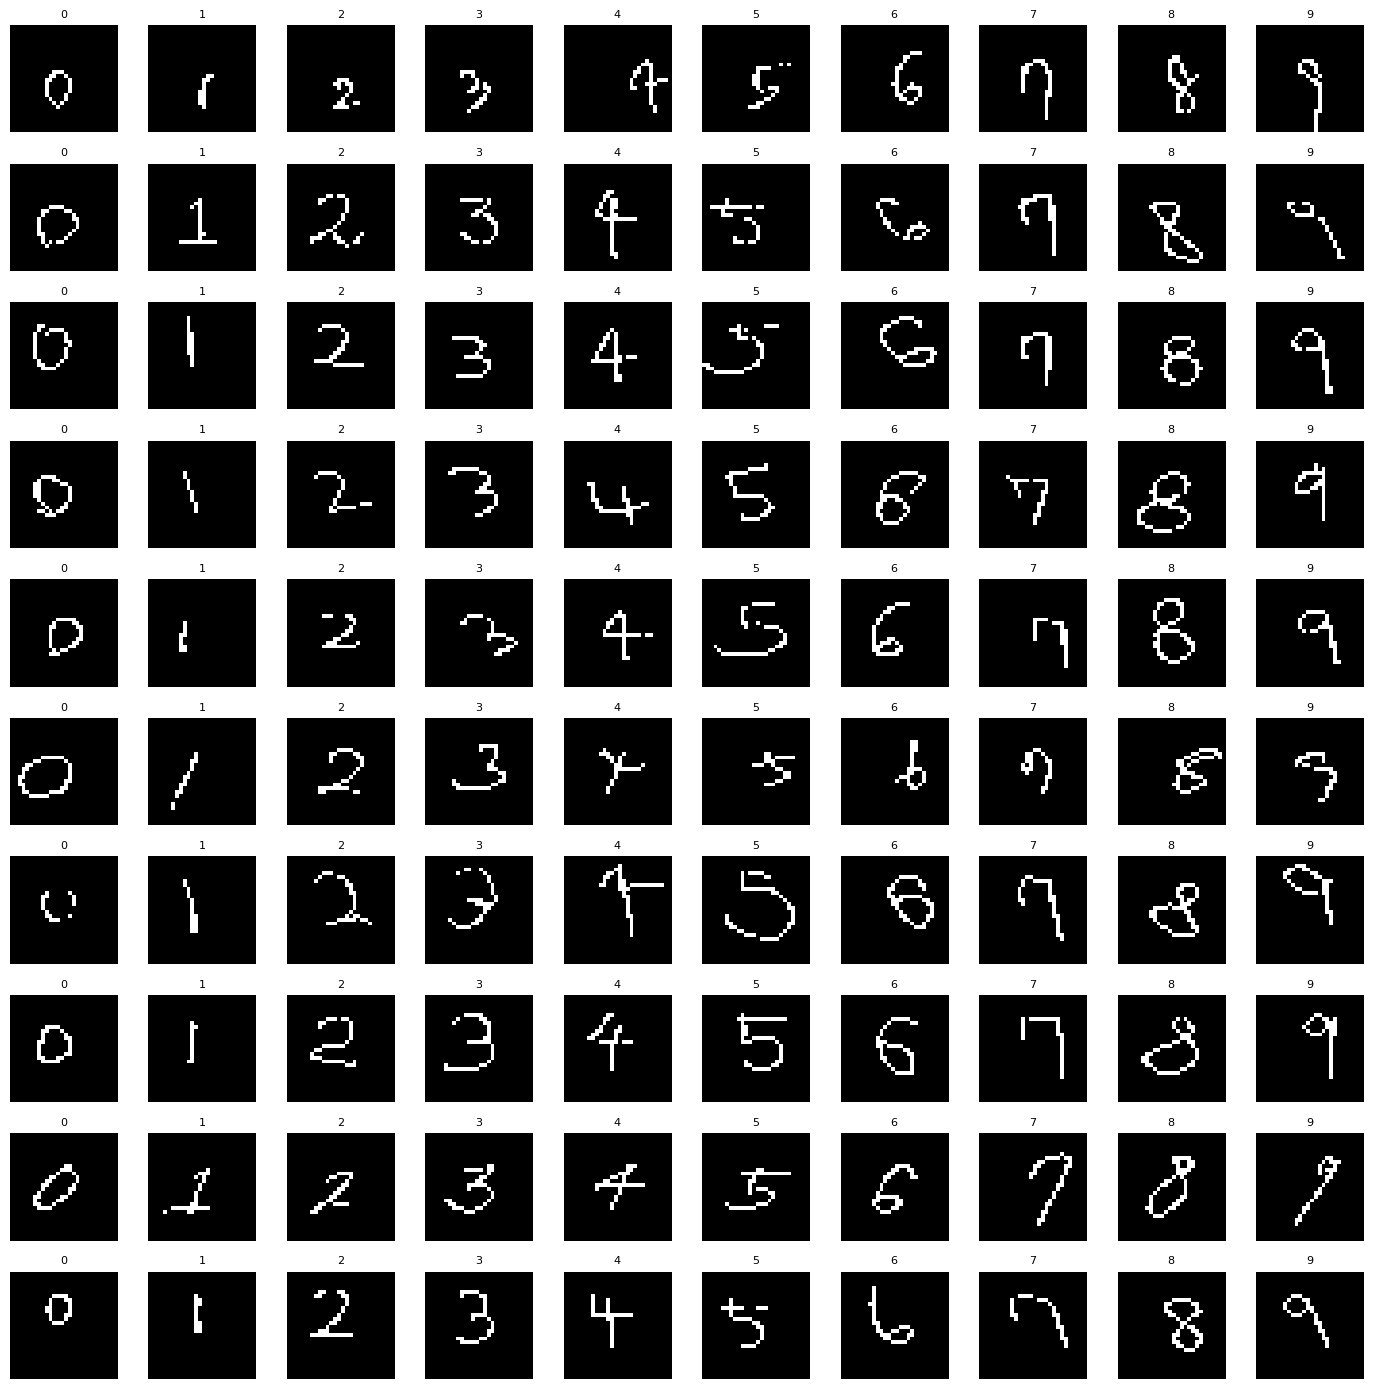


===== 페이지 91 / 95 | 이미지 9000 ~ 9099 =====


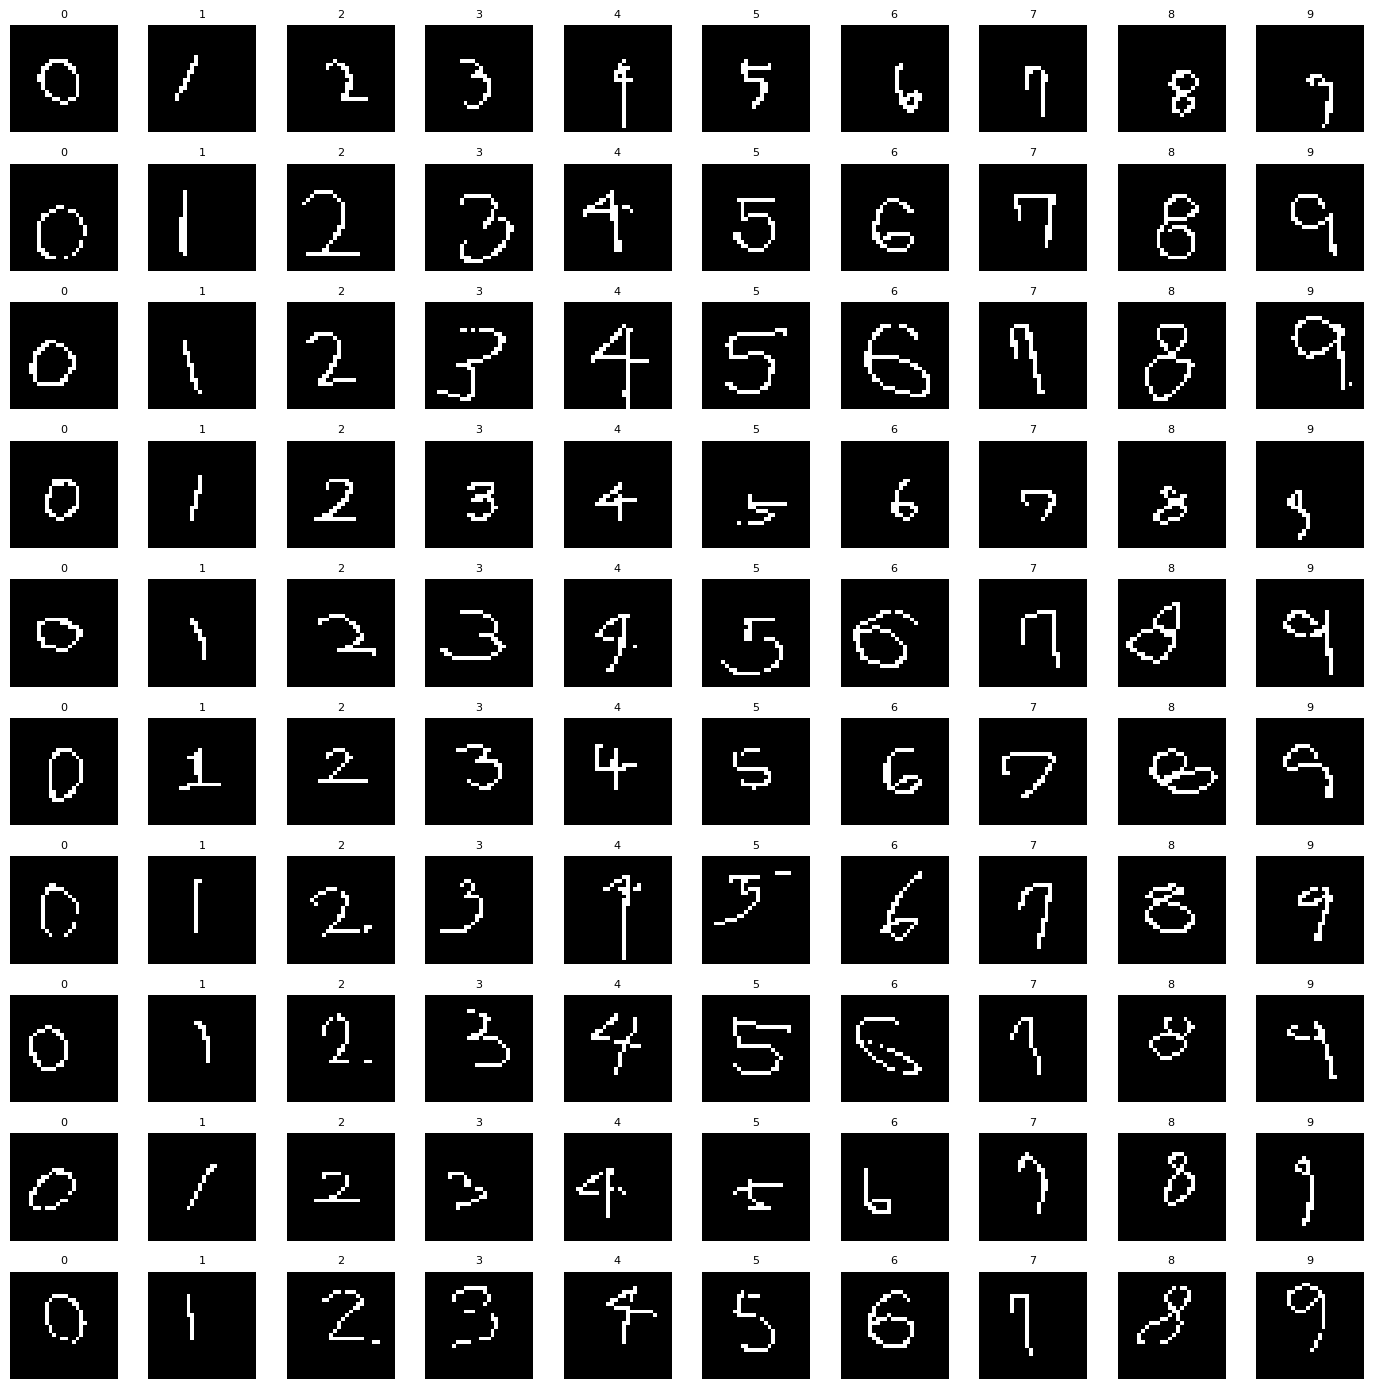


===== 페이지 92 / 95 | 이미지 9100 ~ 9199 =====


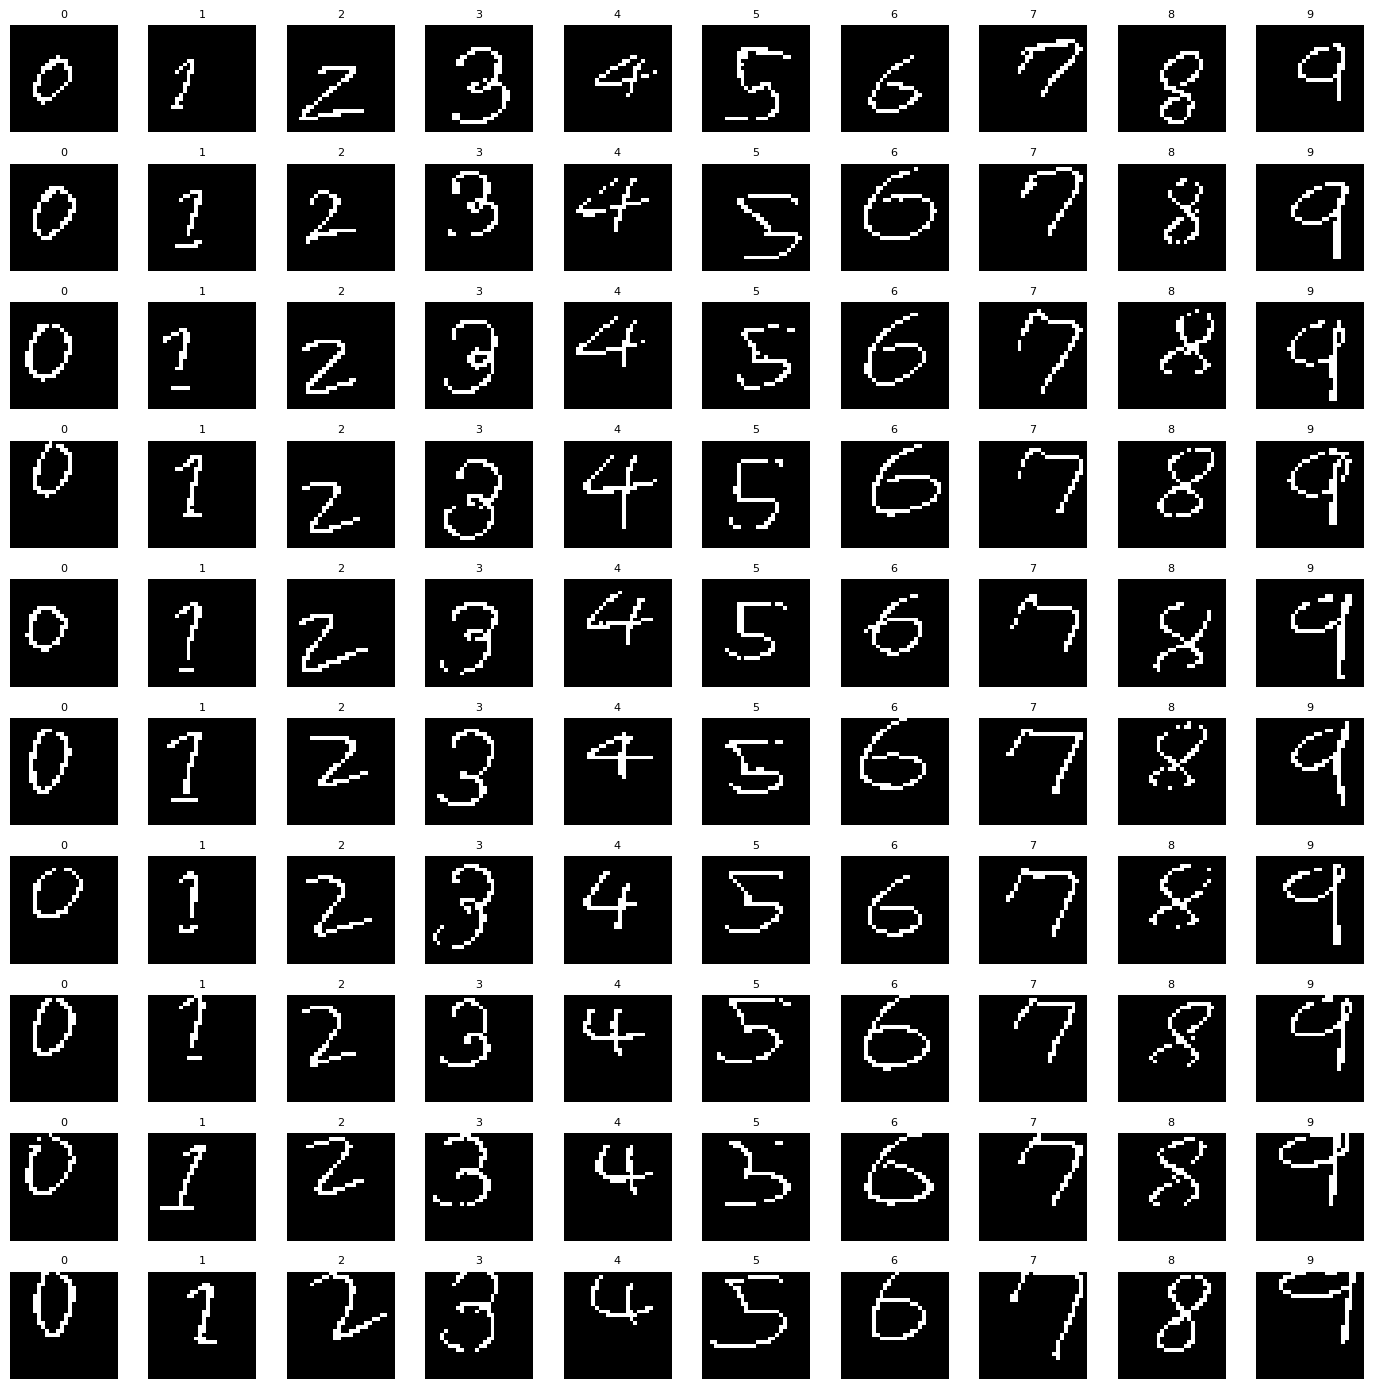


===== 페이지 93 / 95 | 이미지 9200 ~ 9299 =====


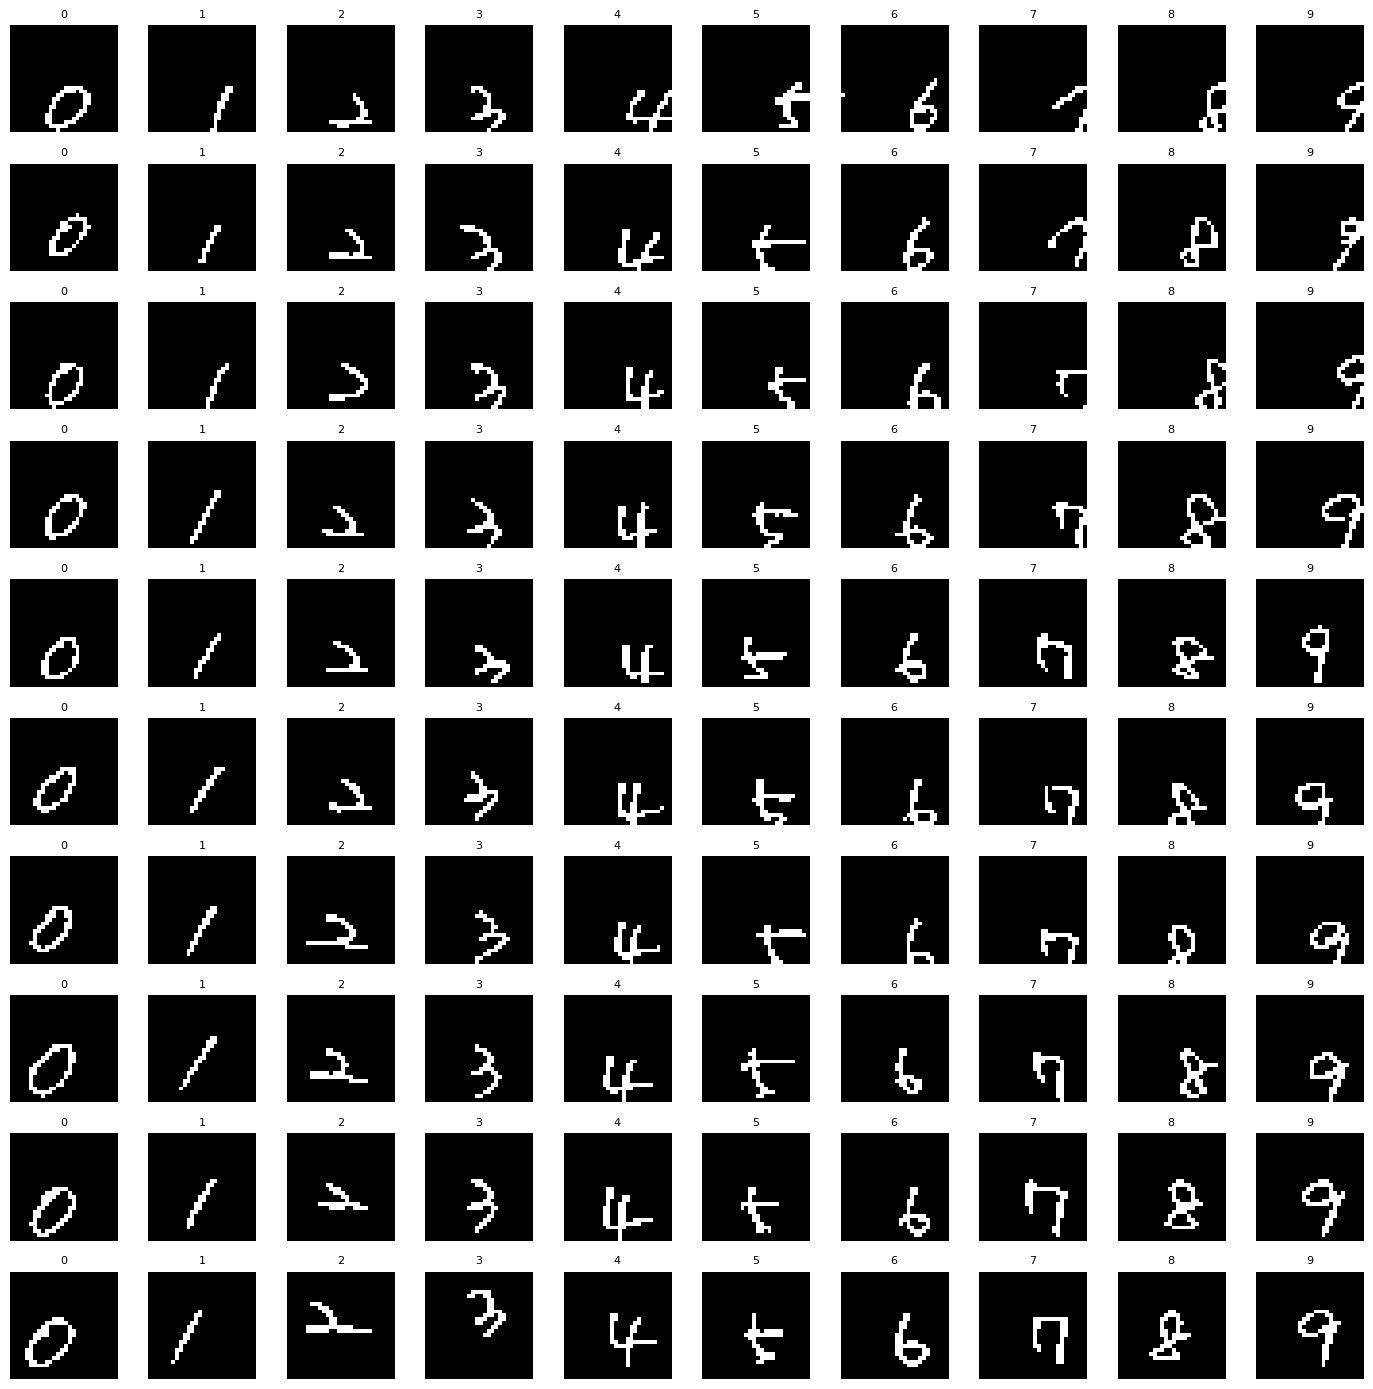


===== 페이지 94 / 95 | 이미지 9300 ~ 9399 =====


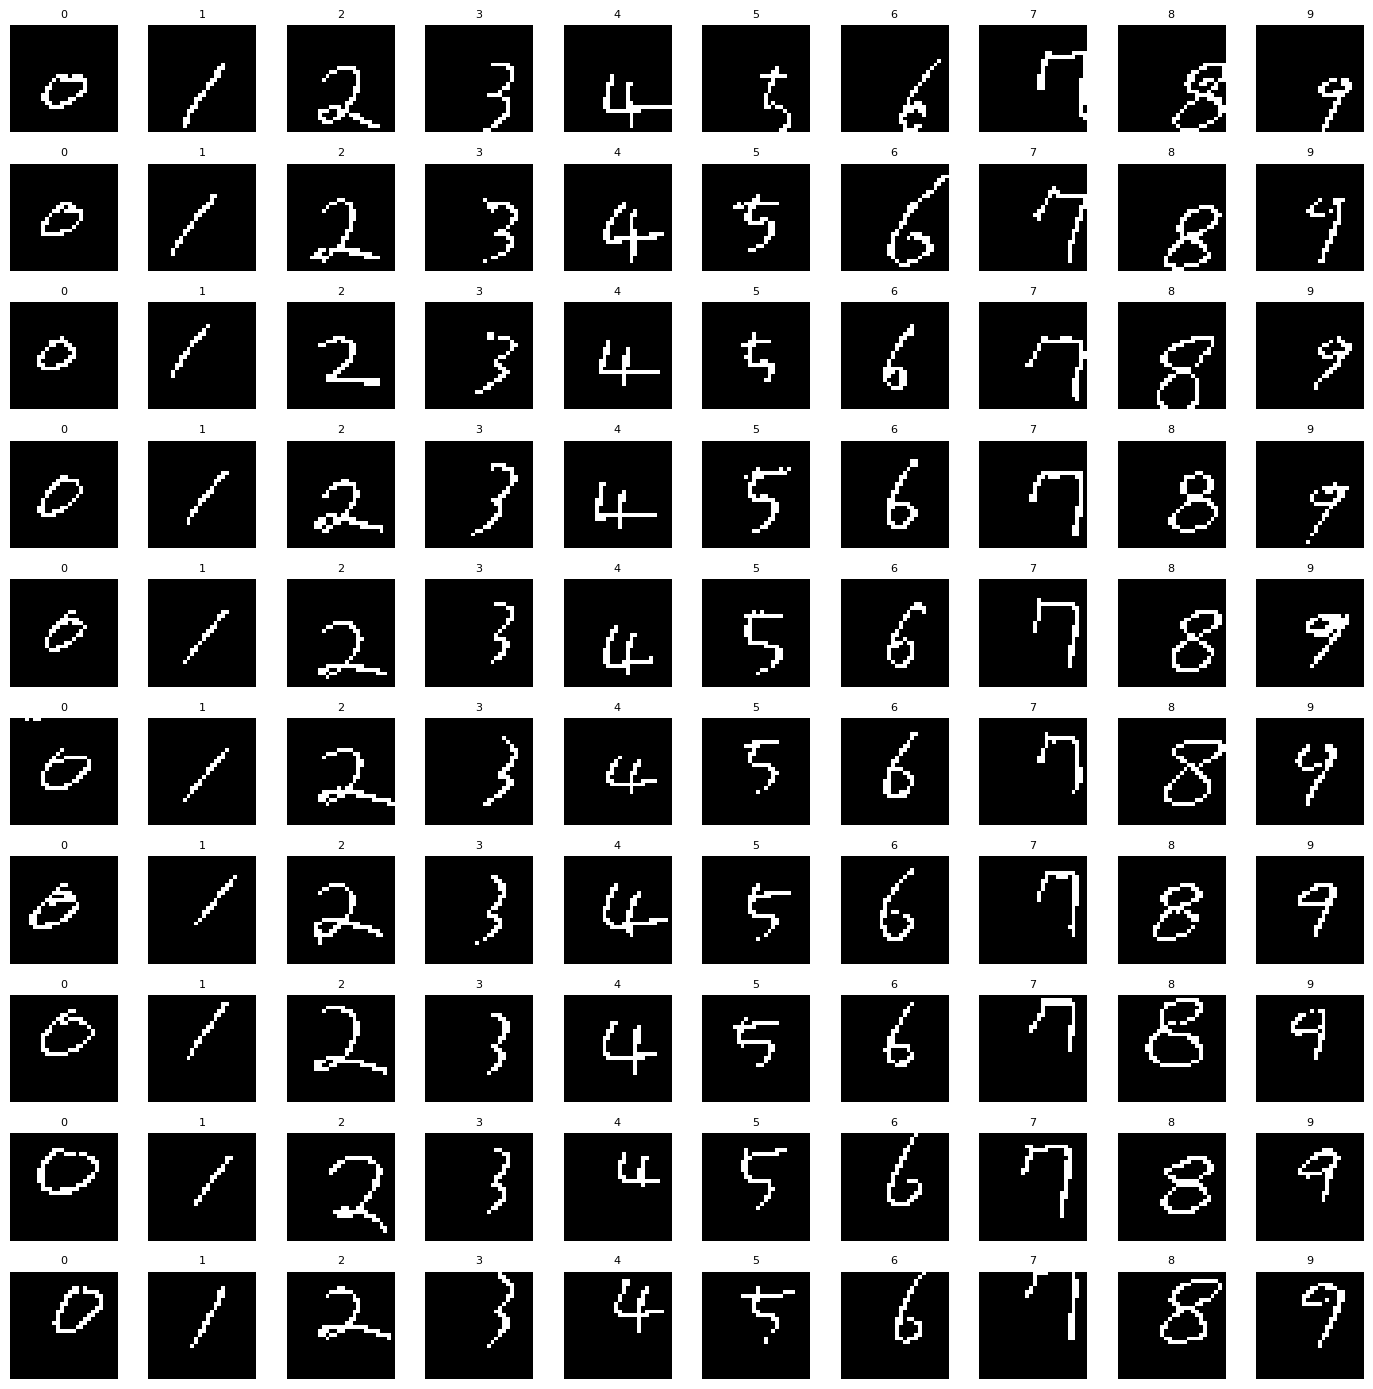


===== 페이지 95 / 95 | 이미지 9400 ~ 9499 =====


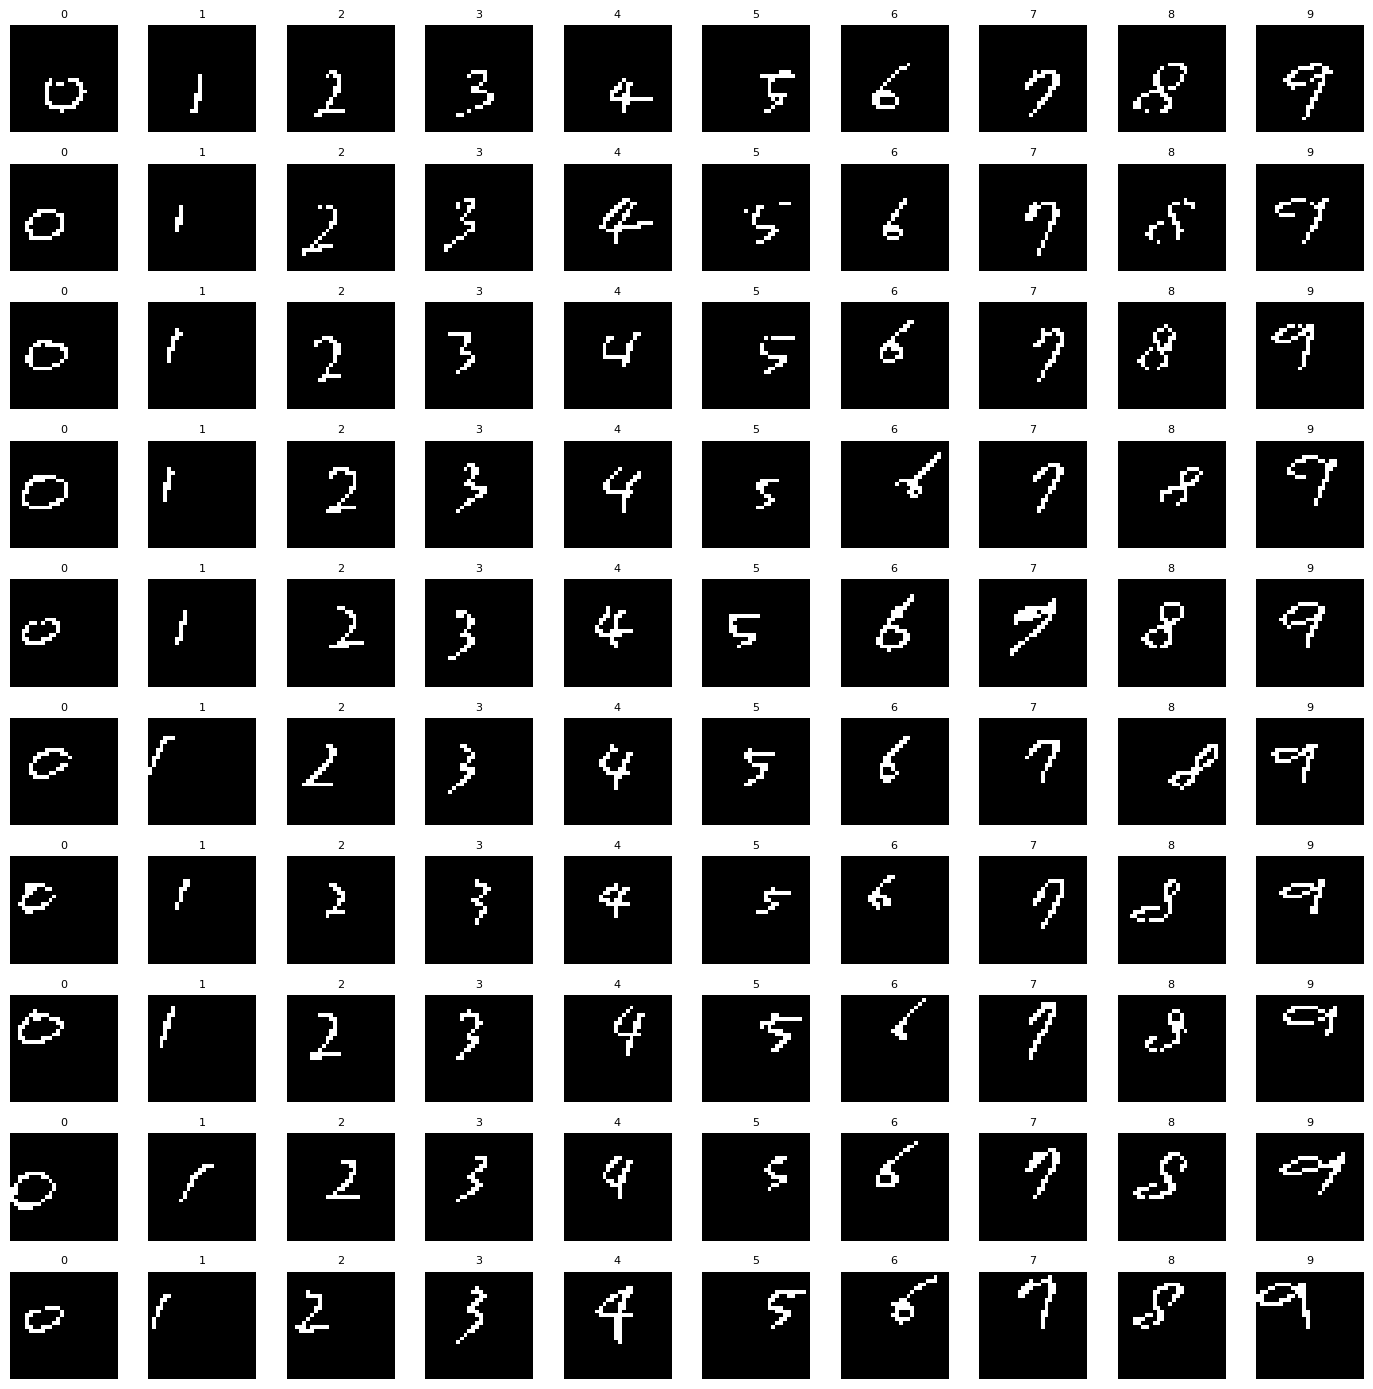

In [14]:
file_path = "npz모음/handmade_extra_mnist_1to32.npz"
data = np.load(file_path)

print("파일 키 목록:", list(data.keys()))

# 🔹 2) img / label 불러오기
images = data["img"]        # (N, 28, 28)
labels = data["label"]      # (N,)

images = np.array(images)
labels = np.array(labels)

unique_types = {type(v) for v in labels}
print("label types :", unique_types)


N = len(images)
print("총 이미지 개수:", N)

# 🔹 3) show_grid 함수
def show_grid(imgs, titles, cols=10, size=1.6):
    n = len(imgs)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * size, rows * size))
    for i, im in enumerate(imgs):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        ax.set_title(str(titles[i]), fontsize=8)
    plt.tight_layout()
    plt.show()

# 🔹 4) 전체 이미지 페이지 단위로 출력 (라벨 포함)
per_page = 100   # 10 x 10
num_pages = (N + per_page - 1) // per_page

print("총 페이지 수:", num_pages)

for page in range(num_pages):
    start = page * per_page
    end = min(N, start + per_page)

    print(f"\n===== 페이지 {page+1} / {num_pages} | 이미지 {start} ~ {end-1} =====")

    page_imgs = images[start:end]
    page_labels = labels[start:end]   

    show_grid(page_imgs, page_labels, cols=10, size=1.4)

총 이미지 개수: 400
one_block 길이: 100
one_block 앞 30개: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]
labels_fixed 길이: 400
labels_fixed 앞 120개: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 7 7 7 7
 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 1 1 1 1 1]
✅ 새 라벨로 저장 완료: mnist23_1-32/mnist_1_fixed.npz

=== 블록 1/4 : 이미지 0 ~ 99 ===


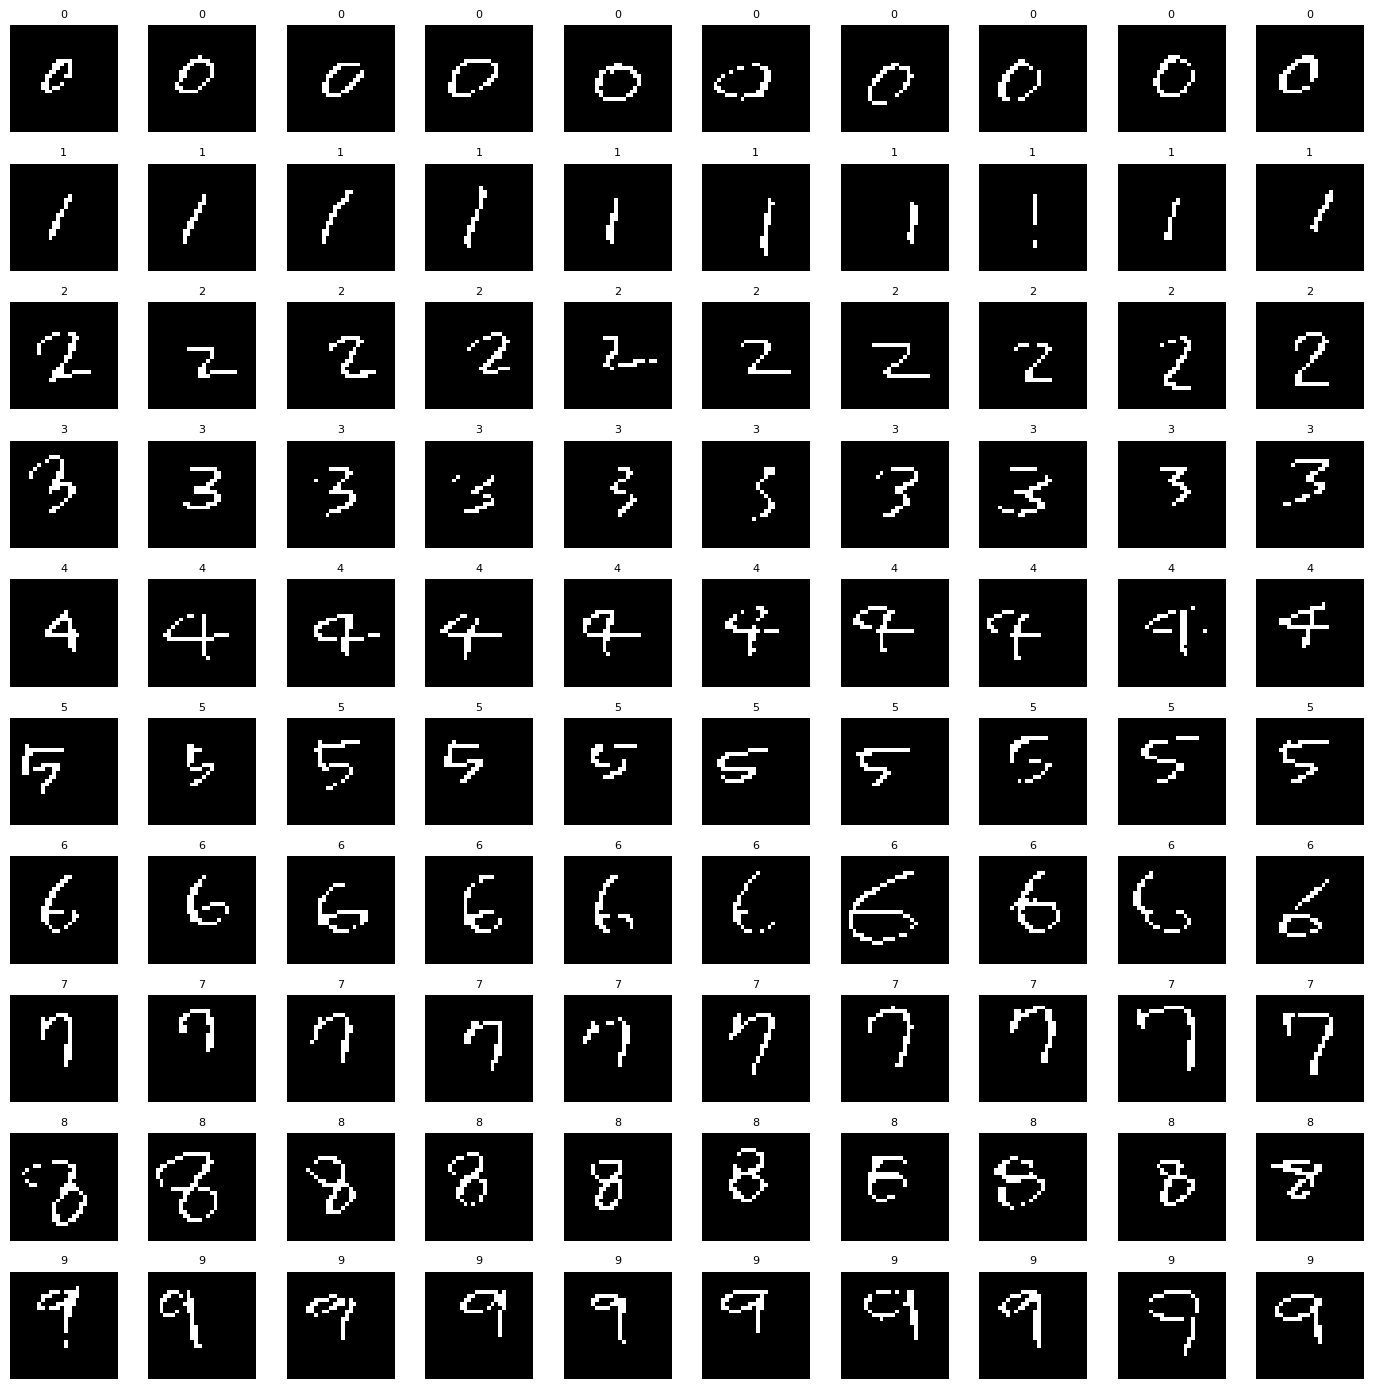


=== 블록 2/4 : 이미지 100 ~ 199 ===


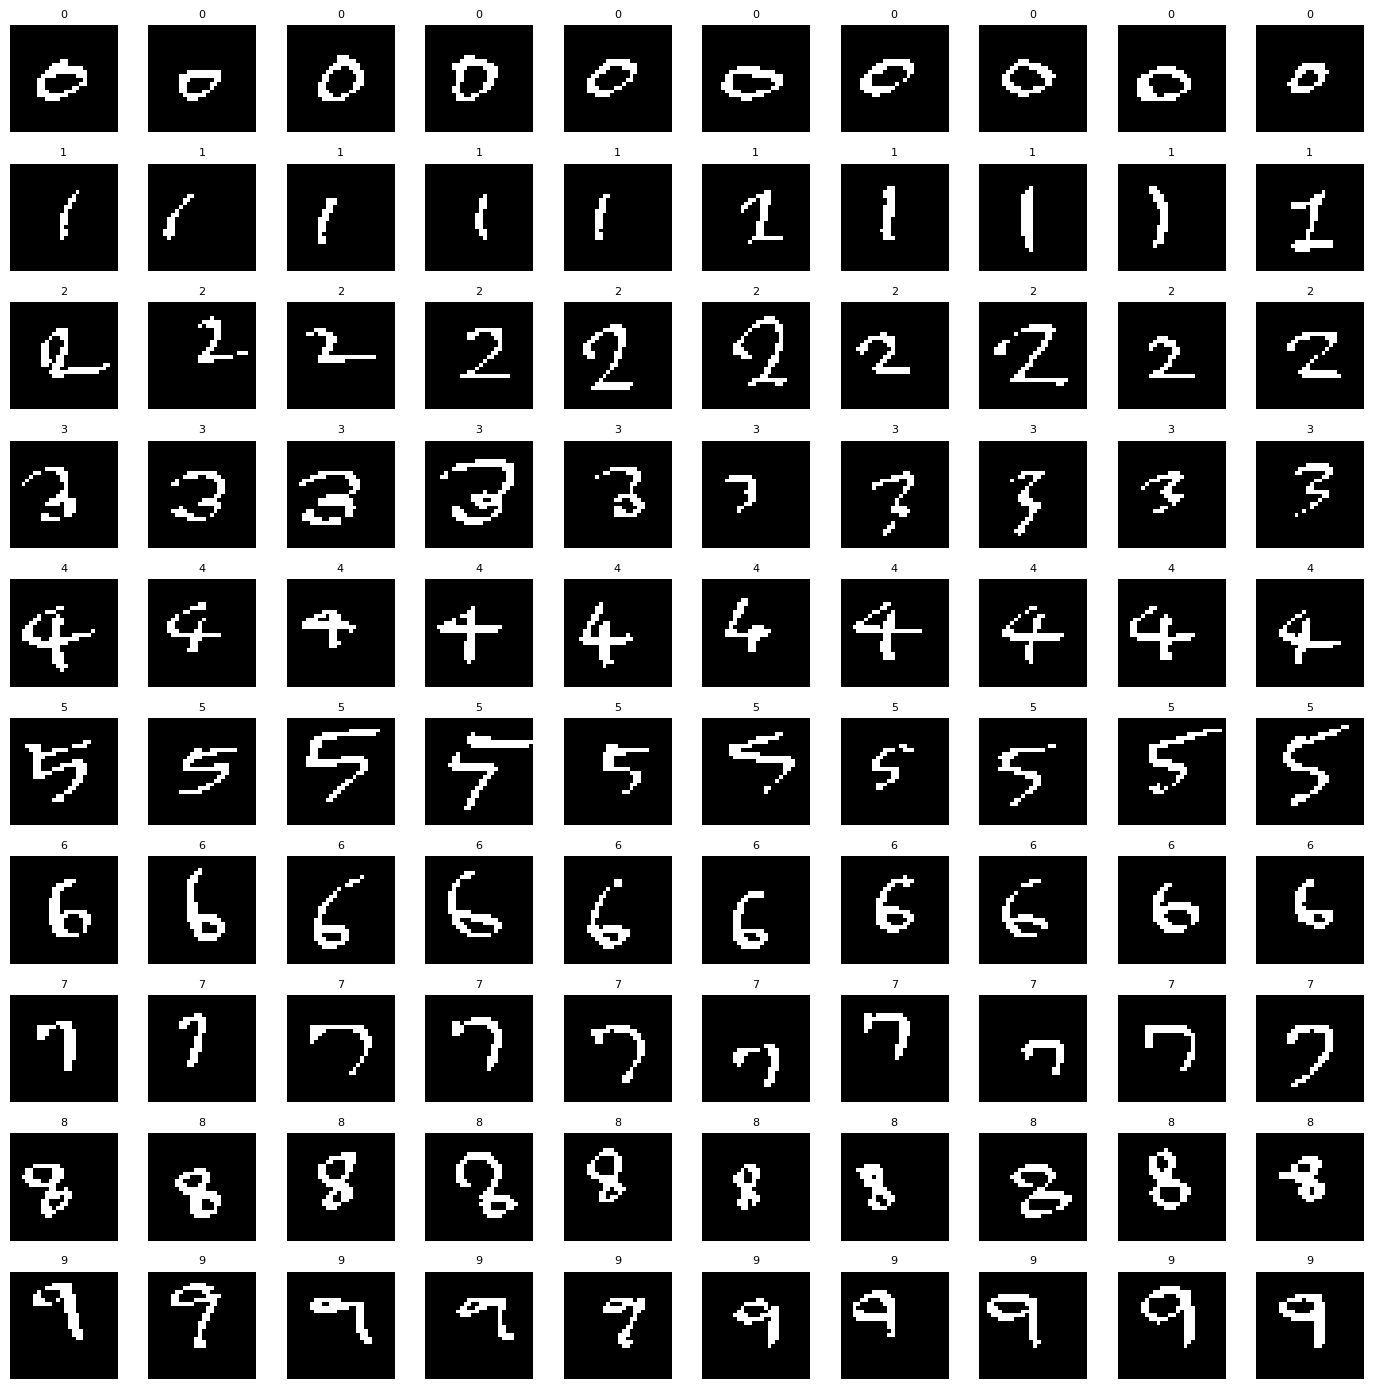


=== 블록 3/4 : 이미지 200 ~ 299 ===


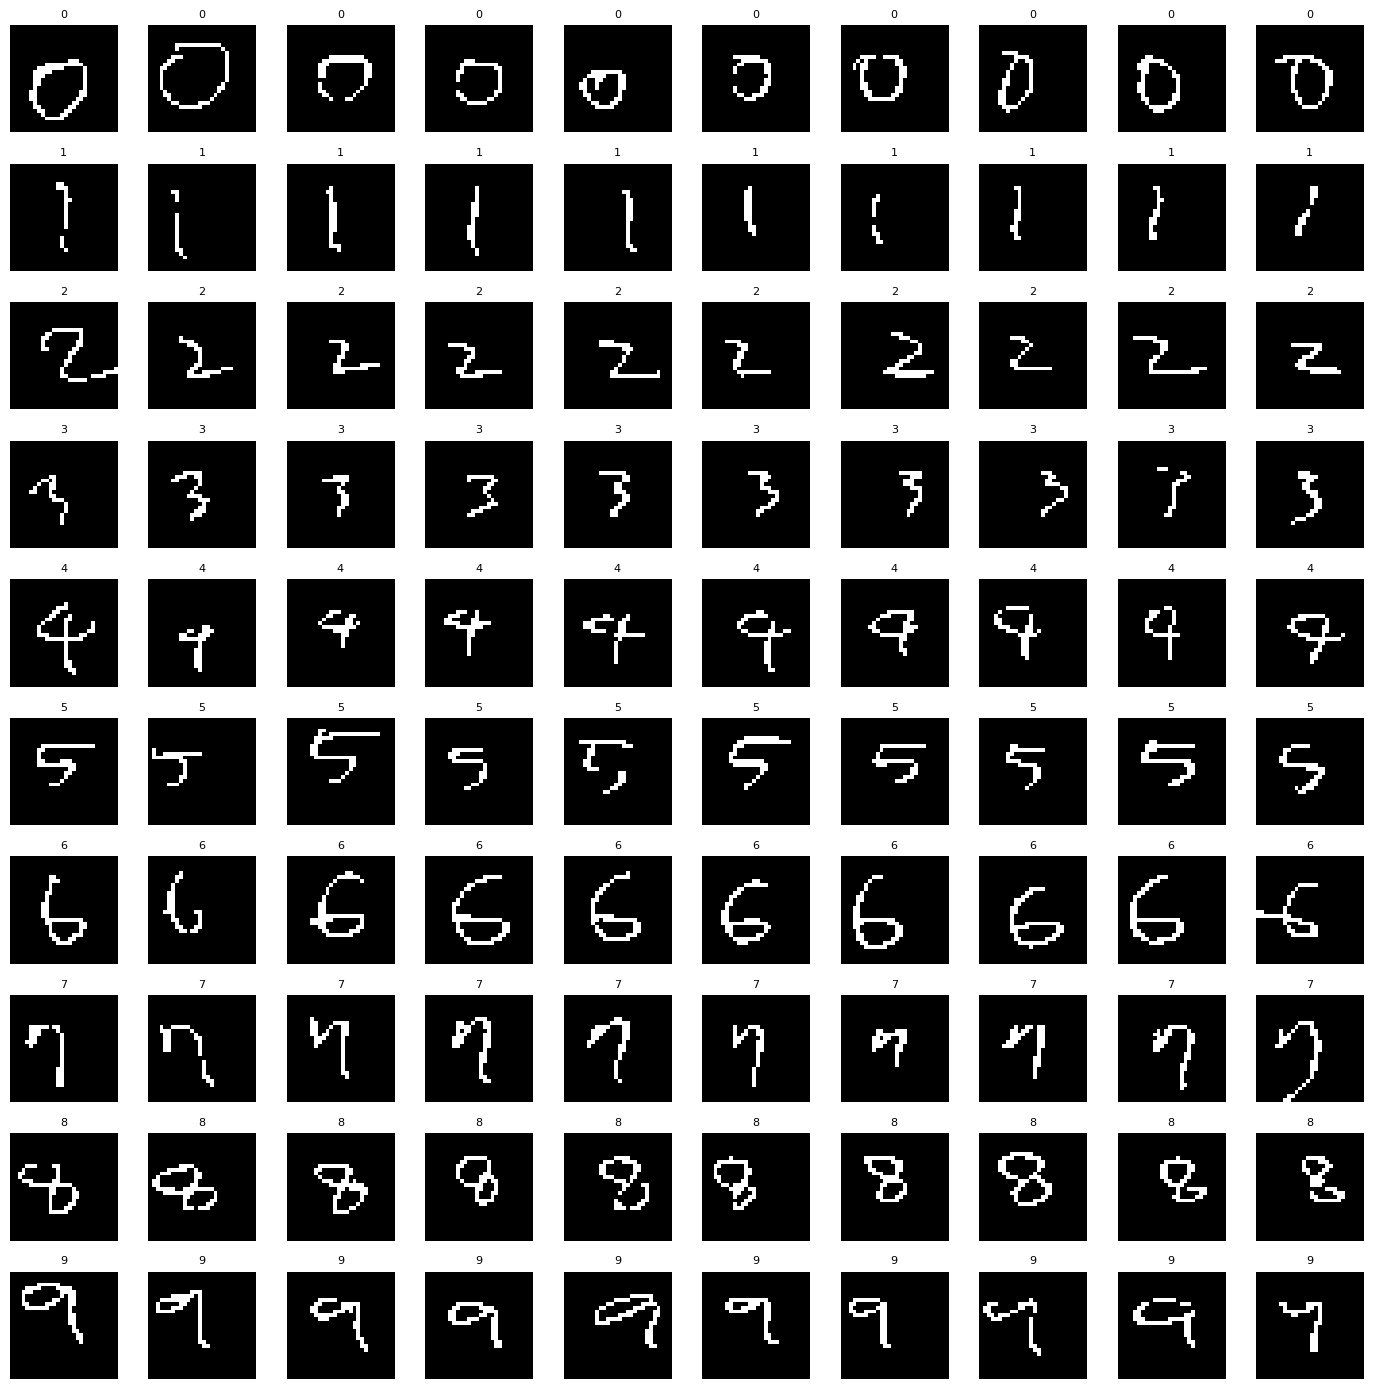


=== 블록 4/4 : 이미지 300 ~ 399 ===


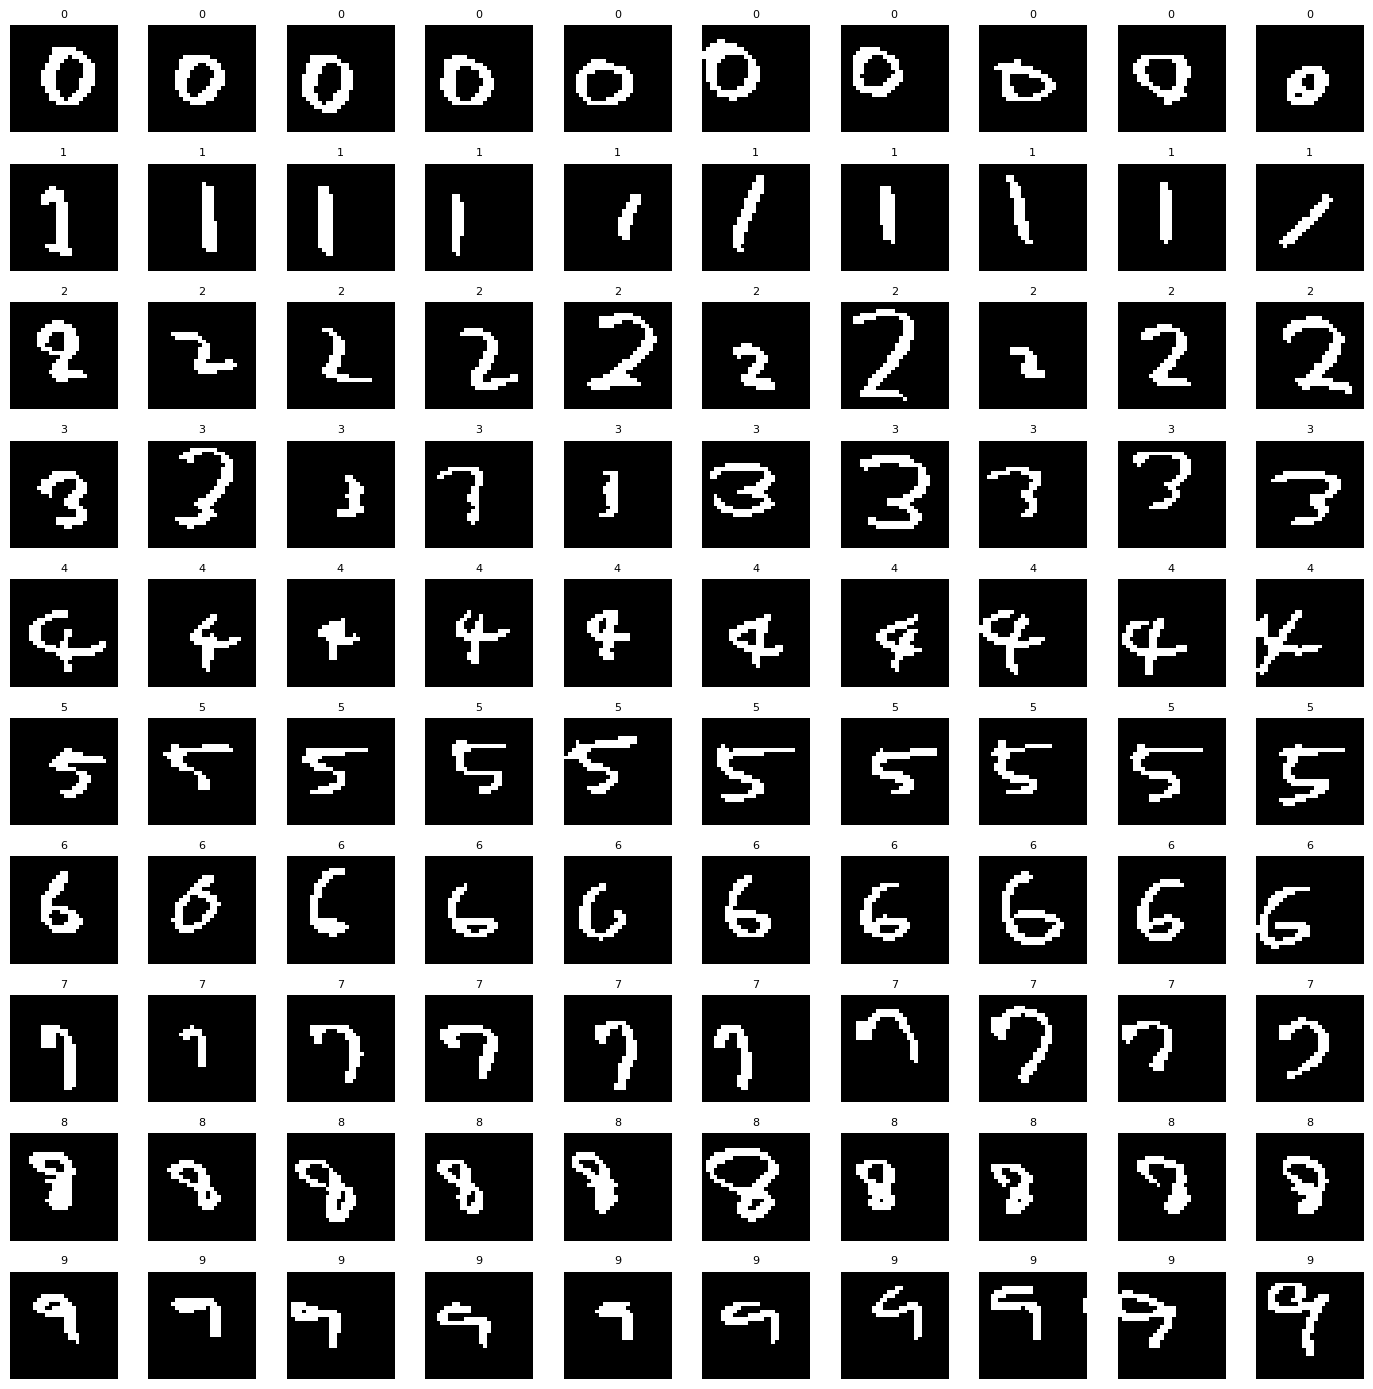

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1) npz 로드
file_path = "mnist23_1-32/mnist_1.npz"
data = np.load(file_path, allow_pickle=True)

images = data["img"]
N = len(images)
print("총 이미지 개수:", N)   # 400 나와야 함

# 2) 한 세트(0~9, 각 10장) 라벨 만들기
one_block = np.repeat(np.arange(10), 10)   # 길이 100: 0이 10개, 1이 10개, ... 9가 10개
print("one_block 길이:", len(one_block))
print("one_block 앞 30개:", one_block[:30])

# 3) 이 블록을 세트 개수만큼 반복
num_blocks = N // 100      # 400이면 4
if num_blocks * 100 != N:
    raise ValueError("이미지 개수가 100의 배수가 아님! 패턴이 다를 수 있어.")

labels_fixed = np.tile(one_block, num_blocks).astype(np.int32)
print("labels_fixed 길이:", len(labels_fixed))
print("labels_fixed 앞 120개:", labels_fixed[:120])

# 4) (원하면) 새 npz로 저장
save_path = "mnist23_1-32/mnist_1_fixed.npz"
np.savez_compressed(save_path, img=images, label=labels_fixed)
print("✅ 새 라벨로 저장 완료:", save_path)

# 5) 눈으로 확인용 grid 함수
def show_grid(imgs, titles, cols=10, size=1.6):
    n = len(imgs)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * size, rows * size))
    for i, im in enumerate(imgs):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        ax.set_title(str(titles[i]), fontsize=8)
    plt.tight_layout()
    plt.show()

# 6) 각 세트별로 확인 (0~9, 0~9, 0~9, 0~9)
for block in range(num_blocks):
    start = block * 100
    end = start + 100
    print(f"\n=== 블록 {block+1}/{num_blocks} : 이미지 {start} ~ {end-1} ===")
    show_grid(images[start:end], labels_fixed[start:end], cols=10, size=1.4)


In [19]:
import numpy as np
import os

# ================================
# 설정: 폴더 경로
# ================================
folder_path = "mnist23_1-32"   # 실제 경로로 변경해도 됨

# ================================
# 2 ~ 32 파일 처리
# ================================
for i in range(2, 33):
    filename = f"mnist_{i}.npz"
    file_path = os.path.join(folder_path, filename)

    if not os.path.exists(file_path):
        print(f"❌ 파일 없음 → {filename}, 건너뜀")
        continue

    print(f"\n===== 처리 중: {filename} =====")

    # 파일 로드
    data = np.load(file_path, allow_pickle=True)

    imgs = data["img"]
    labels = data["label"]

    # 타입 체크
    unique_types = {type(v) for v in labels}
    print("변환 전 label 타입:", unique_types)

    # str → int 변환
    labels_fixed = np.array(labels, dtype=np.int32)

    print("변환 후 label 타입:", labels_fixed.dtype)

    # 저장
    save_path = os.path.join(folder_path, f"mnist_{i}_fixed.npz")
    np.savez_compressed(save_path, img=imgs, label=labels_fixed)

    print(f"✅ 저장 완료 → {save_path}")

print("\n🎉 모든 파일 처리 완료!")



===== 처리 중: mnist_2.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_2_fixed.npz

===== 처리 중: mnist_3.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_3_fixed.npz

===== 처리 중: mnist_4.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_4_fixed.npz

===== 처리 중: mnist_5.npz =====
변환 전 label 타입: {<class 'numpy.int64'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_5_fixed.npz

===== 처리 중: mnist_6.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_6_fixed.npz

===== 처리 중: mnist_7.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_7_fixed.npz

===== 처리 중: mnist_8.npz =====
변환 전 label 타입: {<class 'numpy.int32'>}
변환 후 label 타입: int32
✅ 저장 완료 → mnist23_1-32\mnist_8_fixed.npz

===== 처리 중: mnist_9.npz =====
변환 전 label 타입: {<class 'numpy.str_'>}
변환 후 la

In [20]:
import numpy as np
import os

# ================================
# 설정: mnist_1_fixed ~ mnist_32_fixed 폴더
# ================================
folder_path = "mnist23_1-32"   # 폴더 경로 수정 가능

all_images = []
all_labels = []

# ================================
# 파일 순서대로 합치기
# ================================
for i in range(1, 33):   # 1~32 모두 포함
    filename = f"mnist_{i}_fixed.npz"
    file_path = os.path.join(folder_path, filename)

    if not os.path.exists(file_path):
        print(f"❌ 파일 없음: {filename}, 건너뜀")
        continue

    print(f"📥 로드 중: {filename}")

    data = np.load(file_path, allow_pickle=True)

    imgs = data["img"]
    lbls = data["label"]

    all_images.append(imgs)
    all_labels.append(lbls)


# ================================
# 최종 병합
# ================================
images_combined = np.concatenate(all_images, axis=0)
labels_combined = np.concatenate(all_labels, axis=0)

print("\n===== 병합 완료 =====")
print("총 이미지 개수:", len(images_combined))
print("총 라벨 개수:", len(labels_combined))
print("라벨 고유값:", np.unique(labels_combined))

# ================================
# 저장
# ================================
save_path = os.path.join(folder_path, "combined_mnist_1to32.npz")

np.savez_compressed(save_path, img=images_combined, label=labels_combined)

print(f"\n🎉 최종 저장 완료: {save_path}")


📥 로드 중: mnist_1_fixed.npz
📥 로드 중: mnist_2_fixed.npz
📥 로드 중: mnist_3_fixed.npz
📥 로드 중: mnist_4_fixed.npz
📥 로드 중: mnist_5_fixed.npz
📥 로드 중: mnist_6_fixed.npz
📥 로드 중: mnist_7_fixed.npz
📥 로드 중: mnist_8_fixed.npz
📥 로드 중: mnist_9_fixed.npz
📥 로드 중: mnist_10_fixed.npz
📥 로드 중: mnist_11_fixed.npz
📥 로드 중: mnist_12_fixed.npz
📥 로드 중: mnist_13_fixed.npz
📥 로드 중: mnist_14_fixed.npz
📥 로드 중: mnist_15_fixed.npz
📥 로드 중: mnist_16_fixed.npz
📥 로드 중: mnist_17_fixed.npz
📥 로드 중: mnist_18_fixed.npz
📥 로드 중: mnist_19_fixed.npz
📥 로드 중: mnist_20_fixed.npz
📥 로드 중: mnist_21_fixed.npz
📥 로드 중: mnist_22_fixed.npz
📥 로드 중: mnist_23_fixed.npz
📥 로드 중: mnist_24_fixed.npz
📥 로드 중: mnist_25_fixed.npz
📥 로드 중: mnist_26_fixed.npz
📥 로드 중: mnist_27_fixed.npz
📥 로드 중: mnist_28_fixed.npz
📥 로드 중: mnist_29_fixed.npz
📥 로드 중: mnist_30_fixed.npz
📥 로드 중: mnist_31_fixed.npz
📥 로드 중: mnist_32_fixed.npz

===== 병합 완료 =====
총 이미지 개수: 9500
총 라벨 개수: 9500
라벨 고유값: [0 1 2 3 4 5 6 7 8 9]

🎉 최종 저장 완료: mnist23_1-32\combined_mnist_1to32.npz


# 최종 테스트 데이터

파일 키 목록: ['img', 'label']
총 이미지 개수: 2500
총 페이지 수: 25

===== 페이지 1 / 25 | 이미지 0 ~ 99 =====


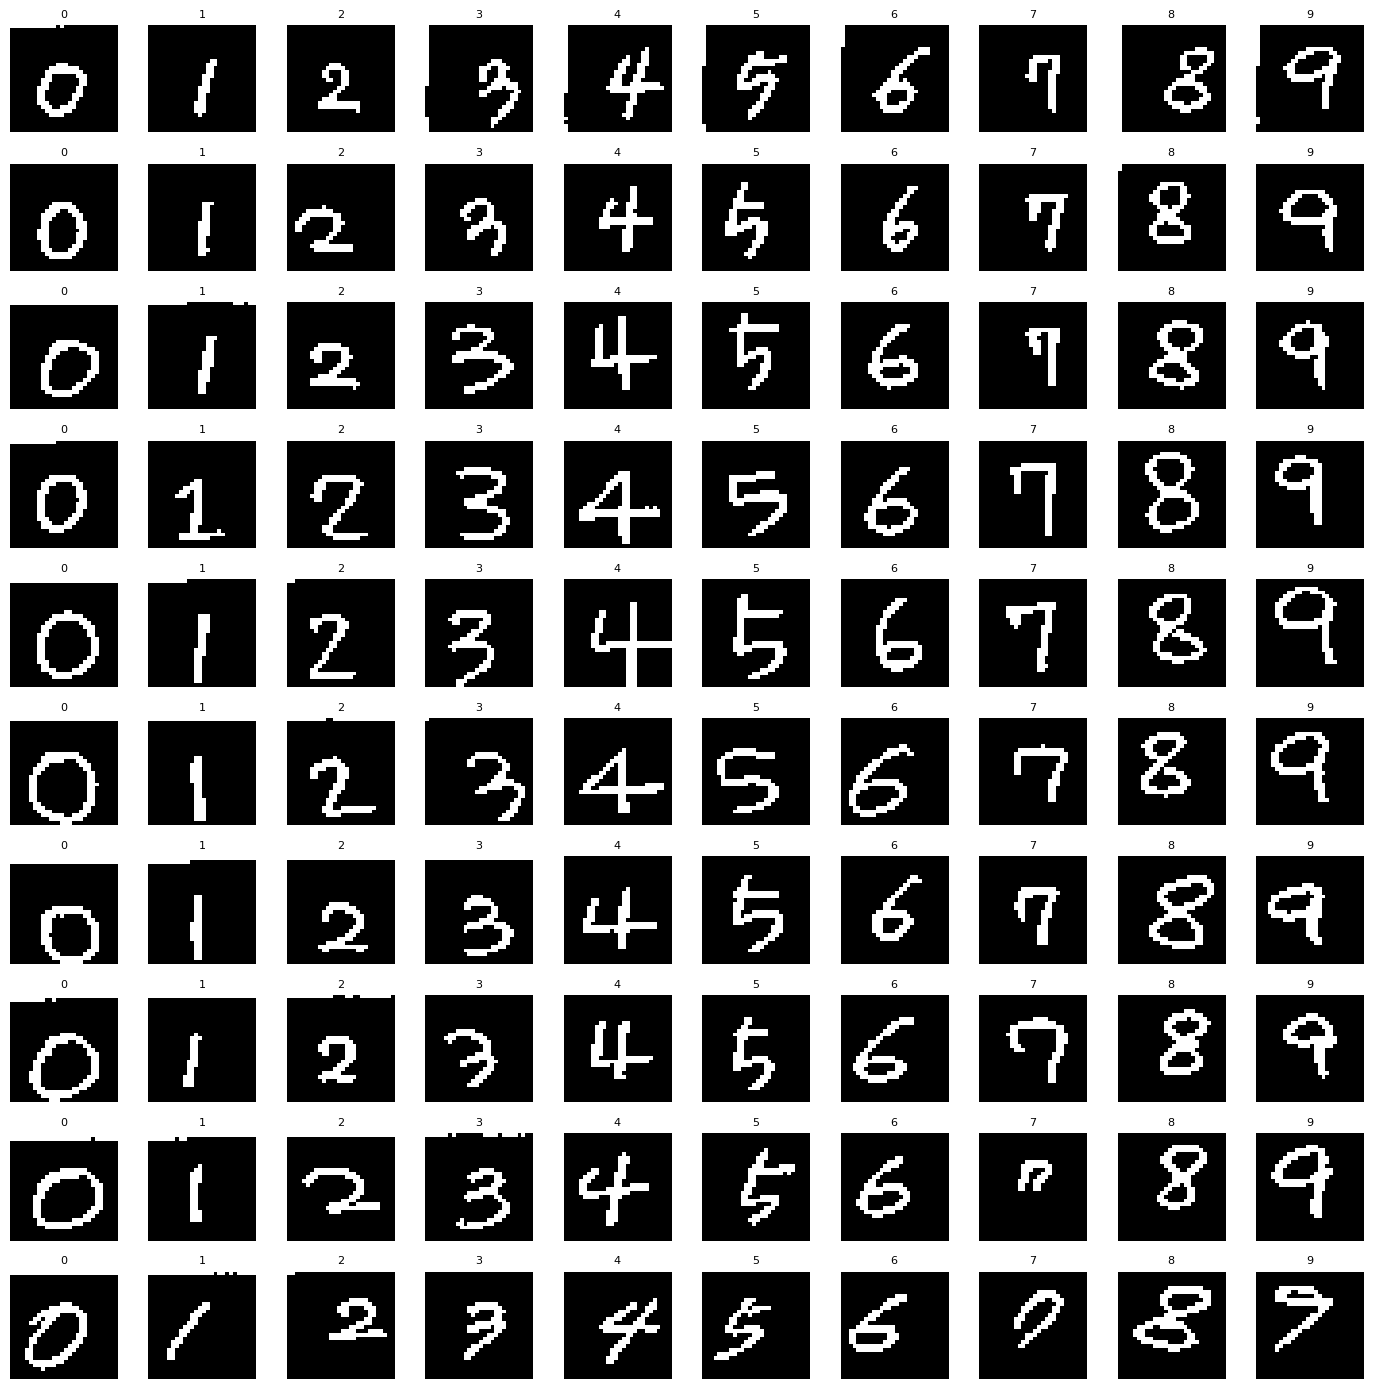


===== 페이지 2 / 25 | 이미지 100 ~ 199 =====


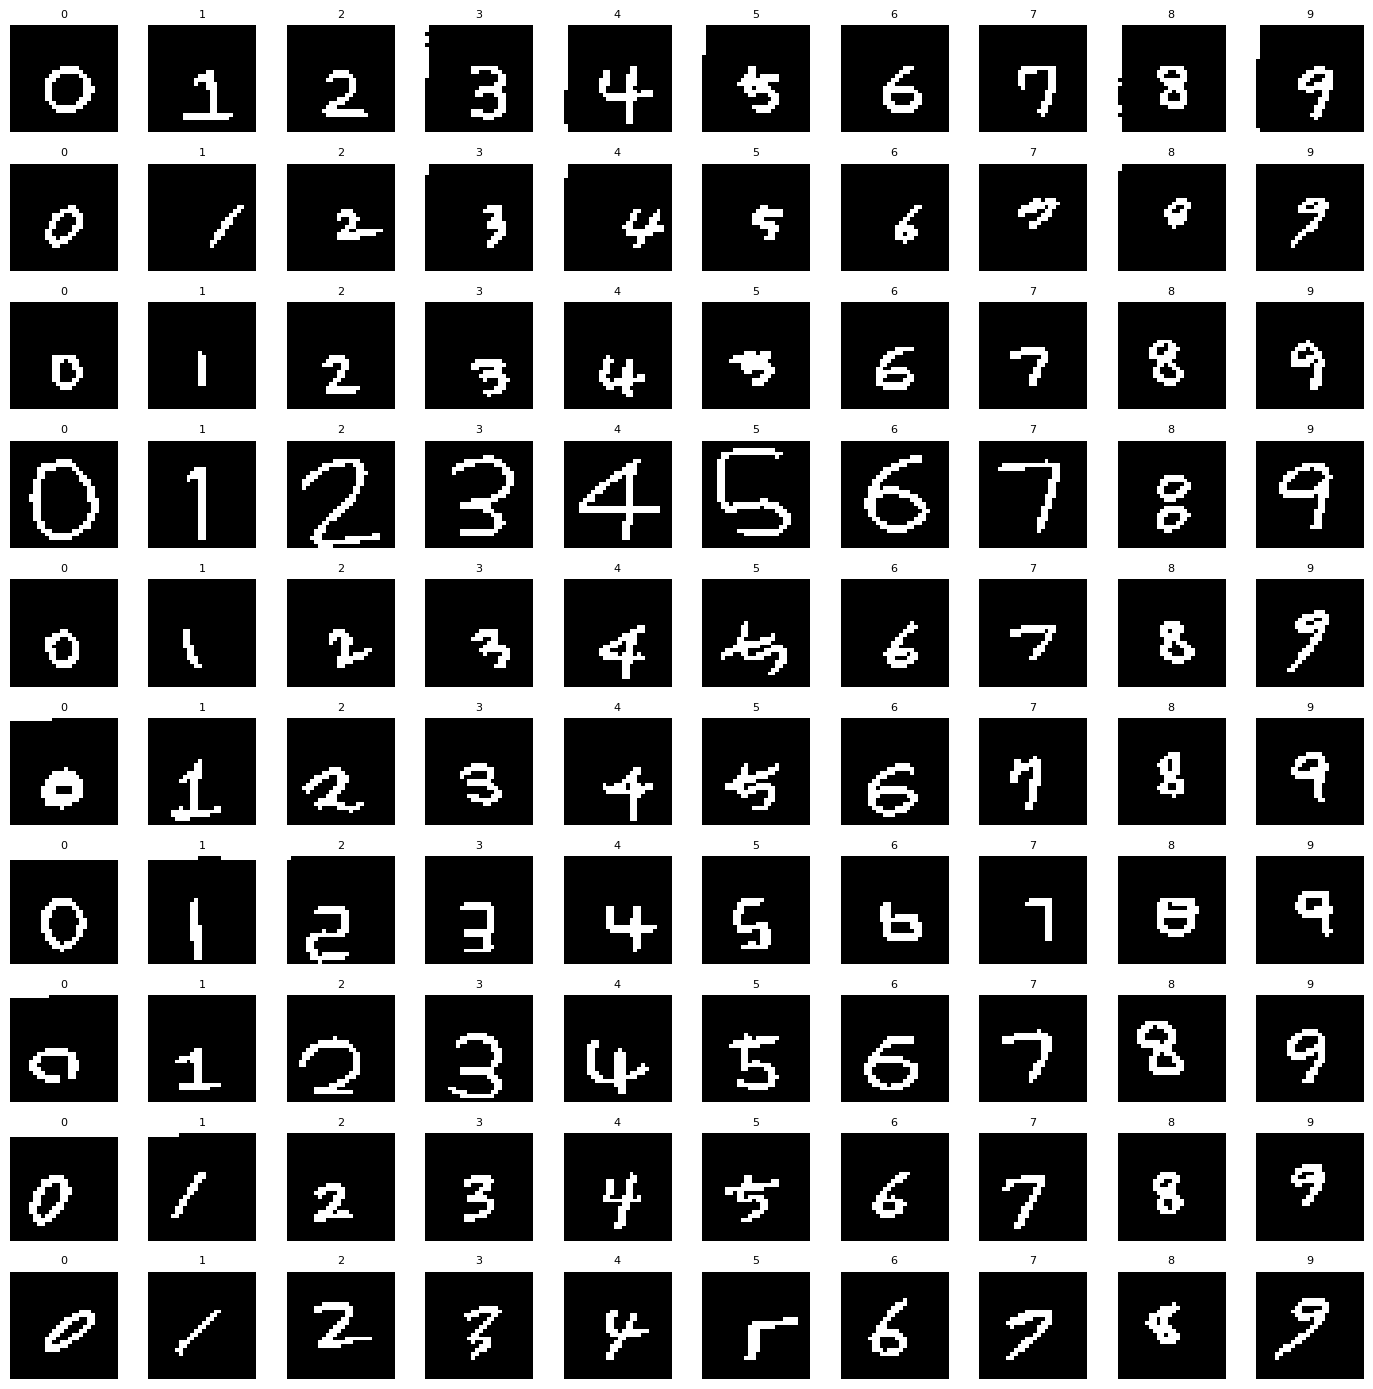


===== 페이지 3 / 25 | 이미지 200 ~ 299 =====


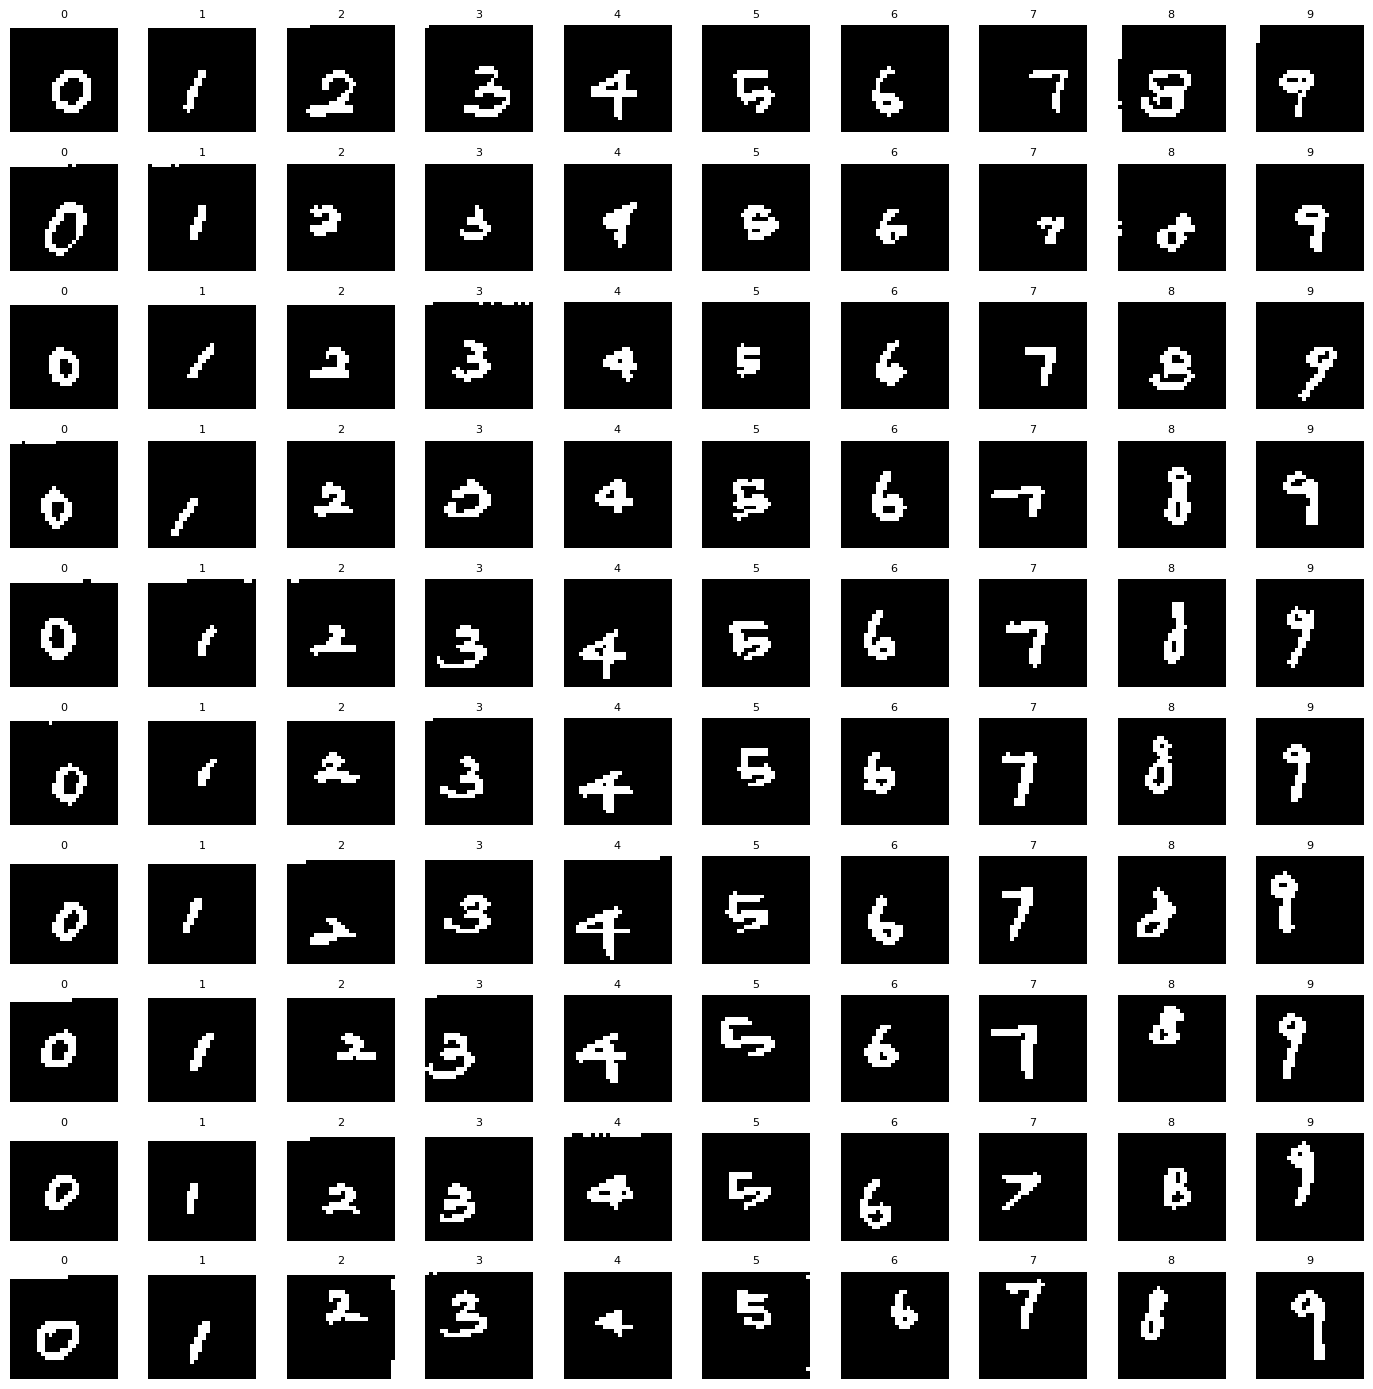


===== 페이지 4 / 25 | 이미지 300 ~ 399 =====


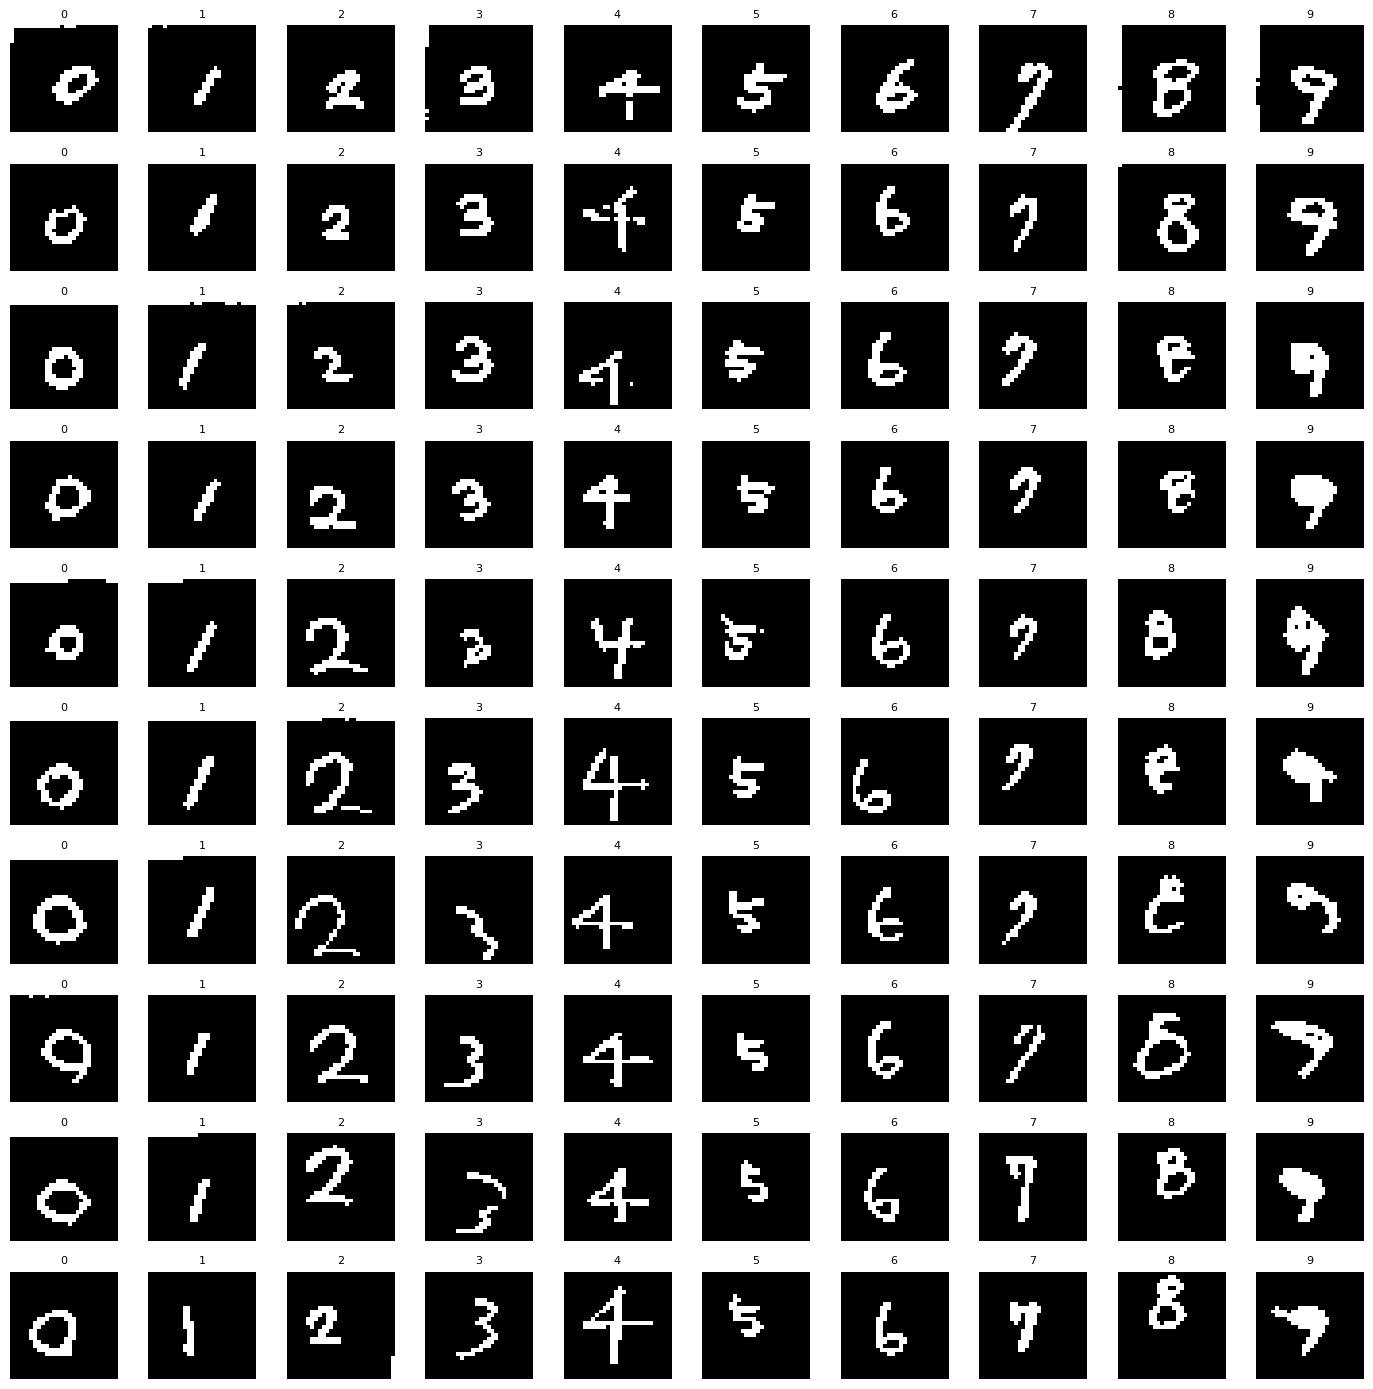


===== 페이지 5 / 25 | 이미지 400 ~ 499 =====


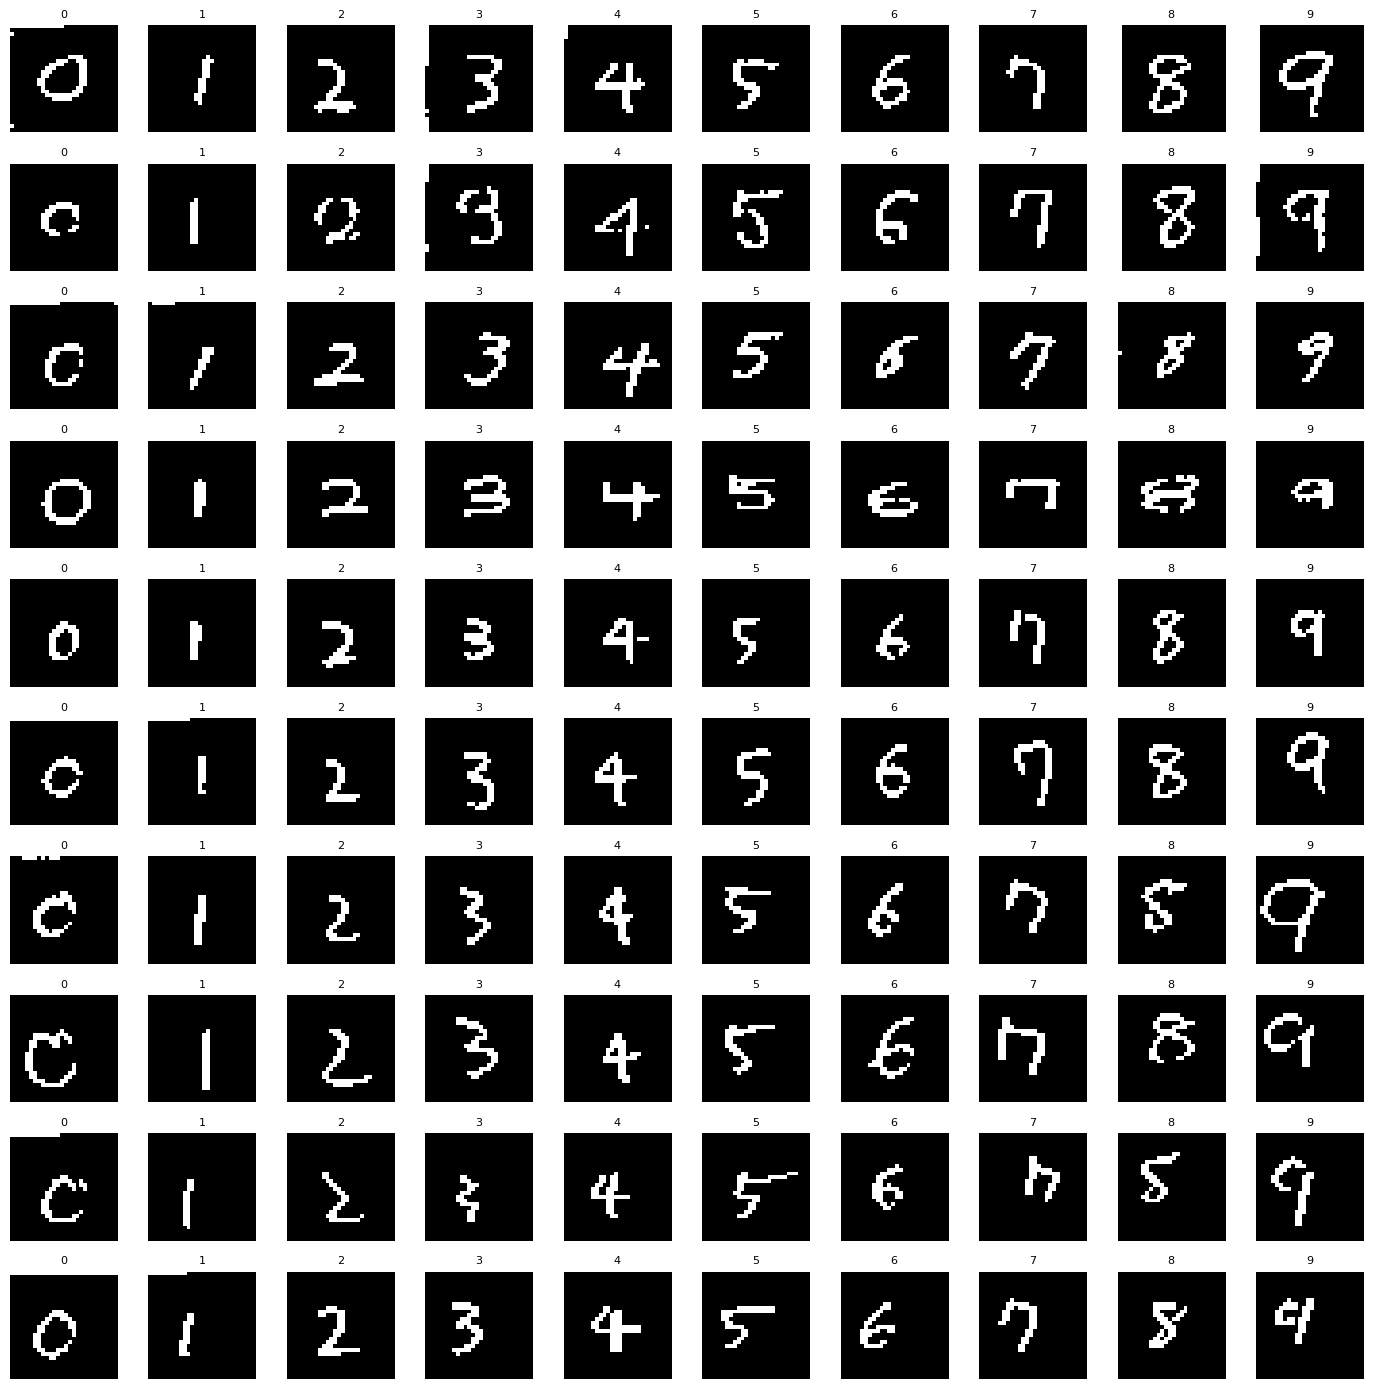


===== 페이지 6 / 25 | 이미지 500 ~ 599 =====


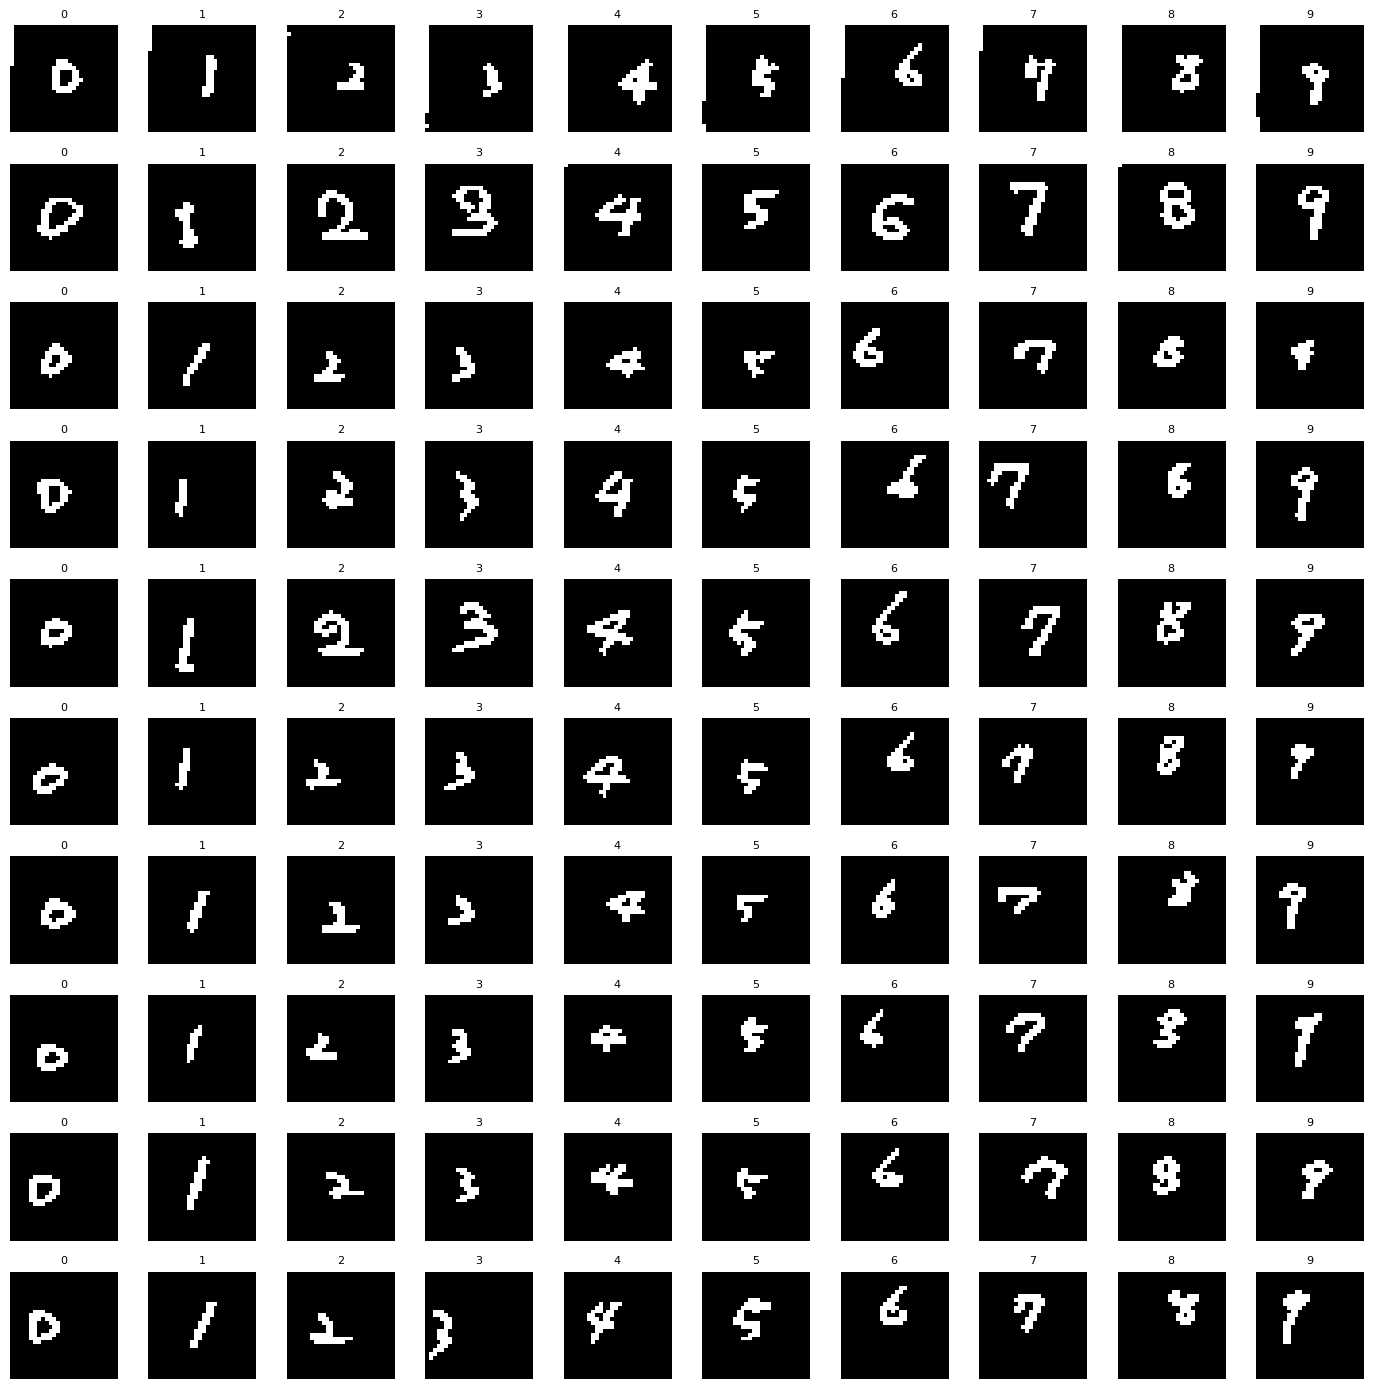


===== 페이지 7 / 25 | 이미지 600 ~ 699 =====


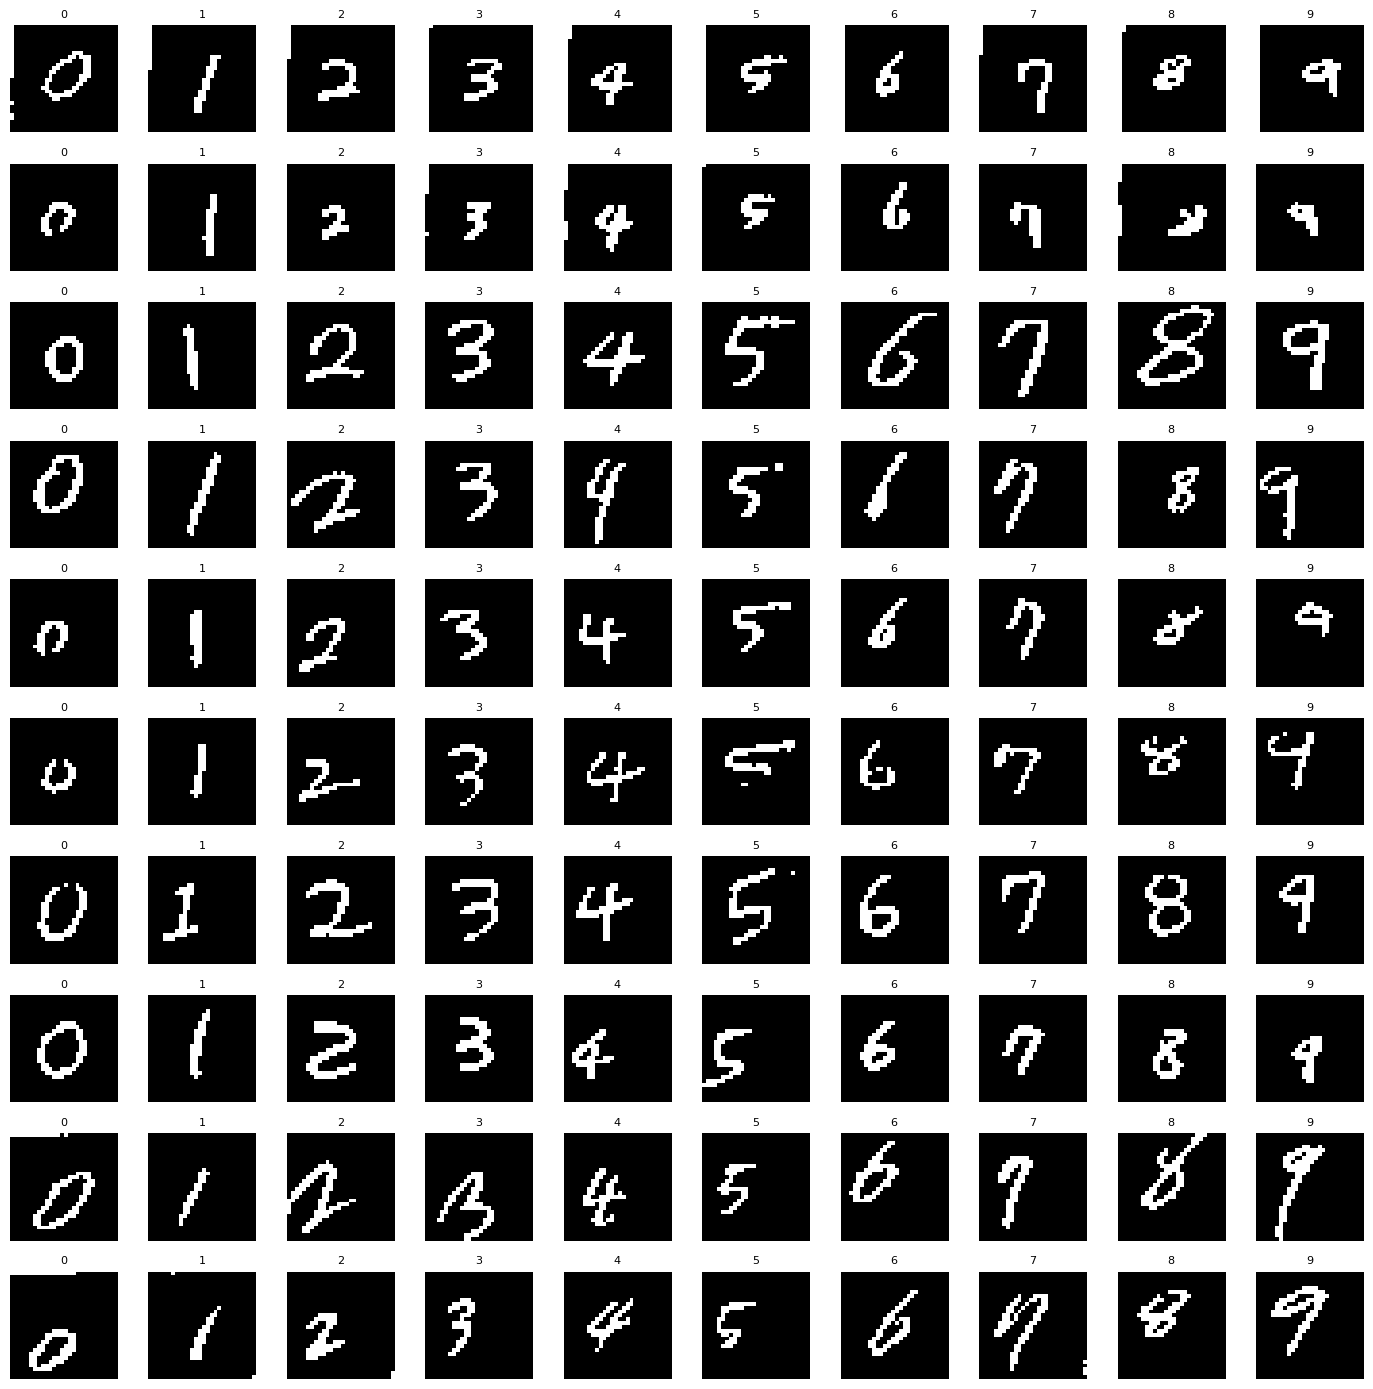


===== 페이지 8 / 25 | 이미지 700 ~ 799 =====


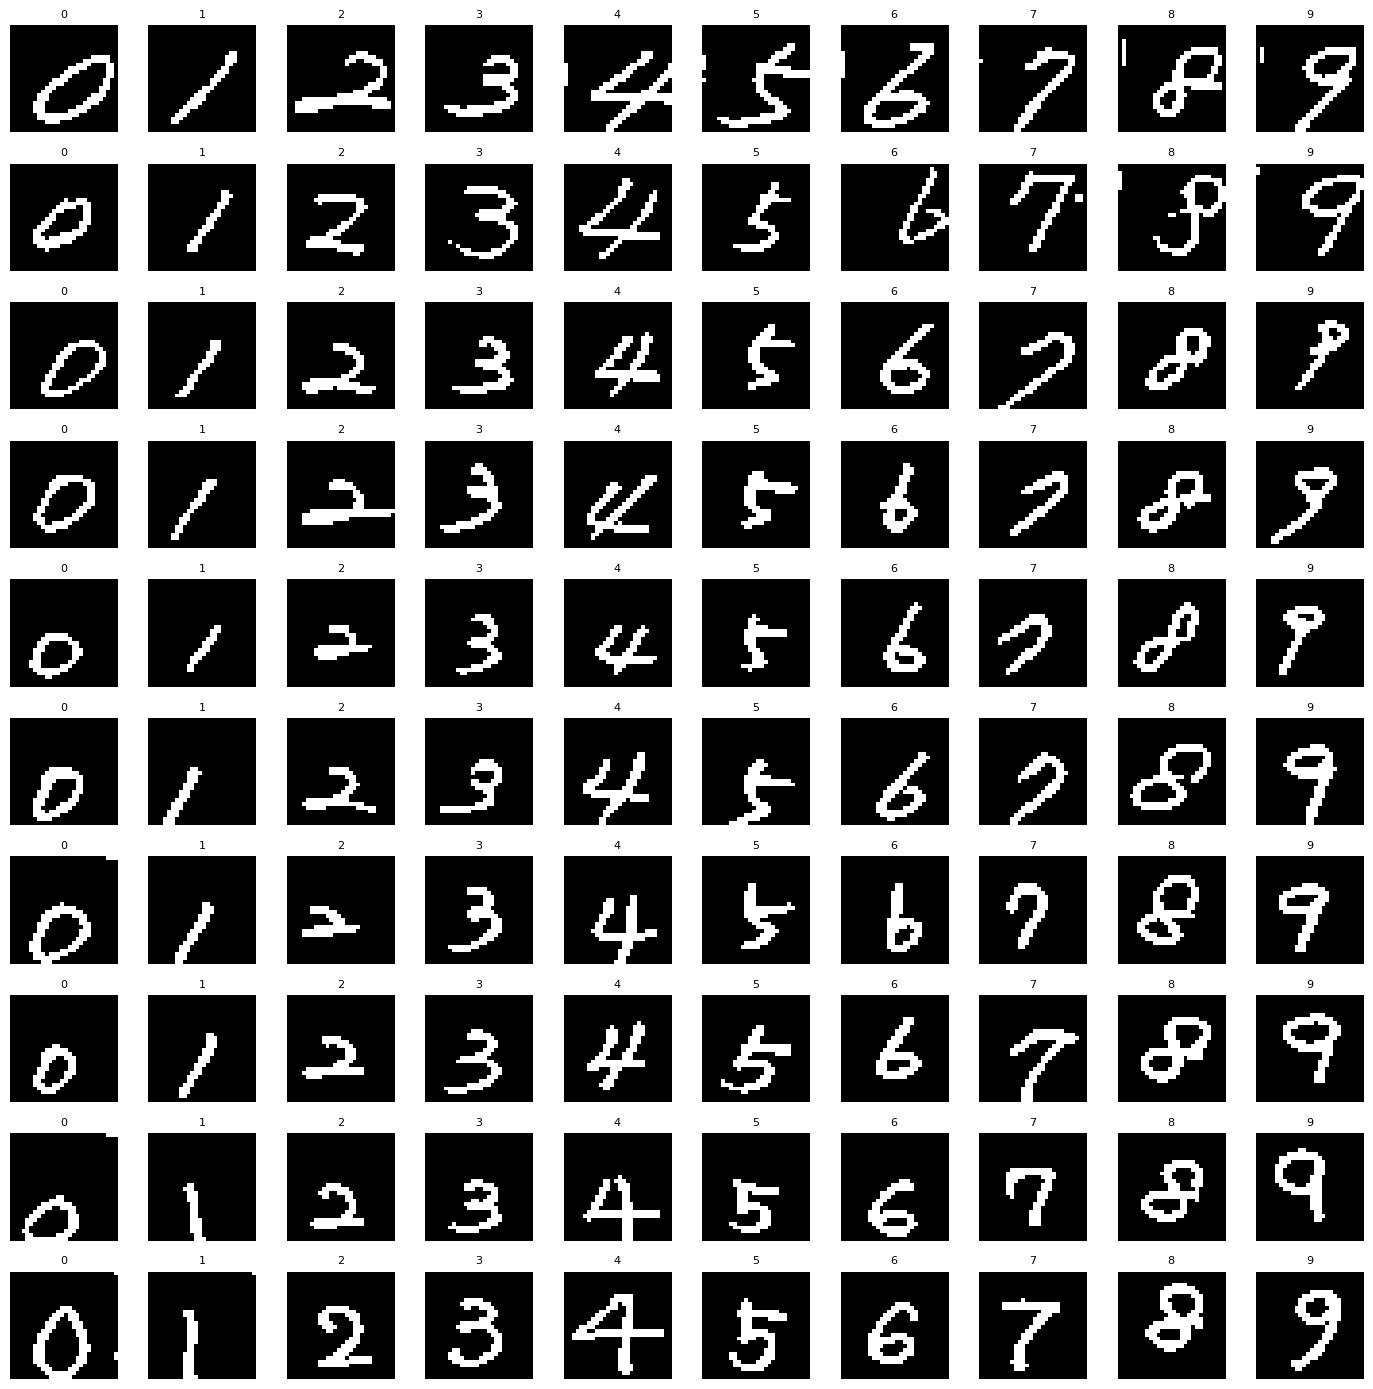


===== 페이지 9 / 25 | 이미지 800 ~ 899 =====


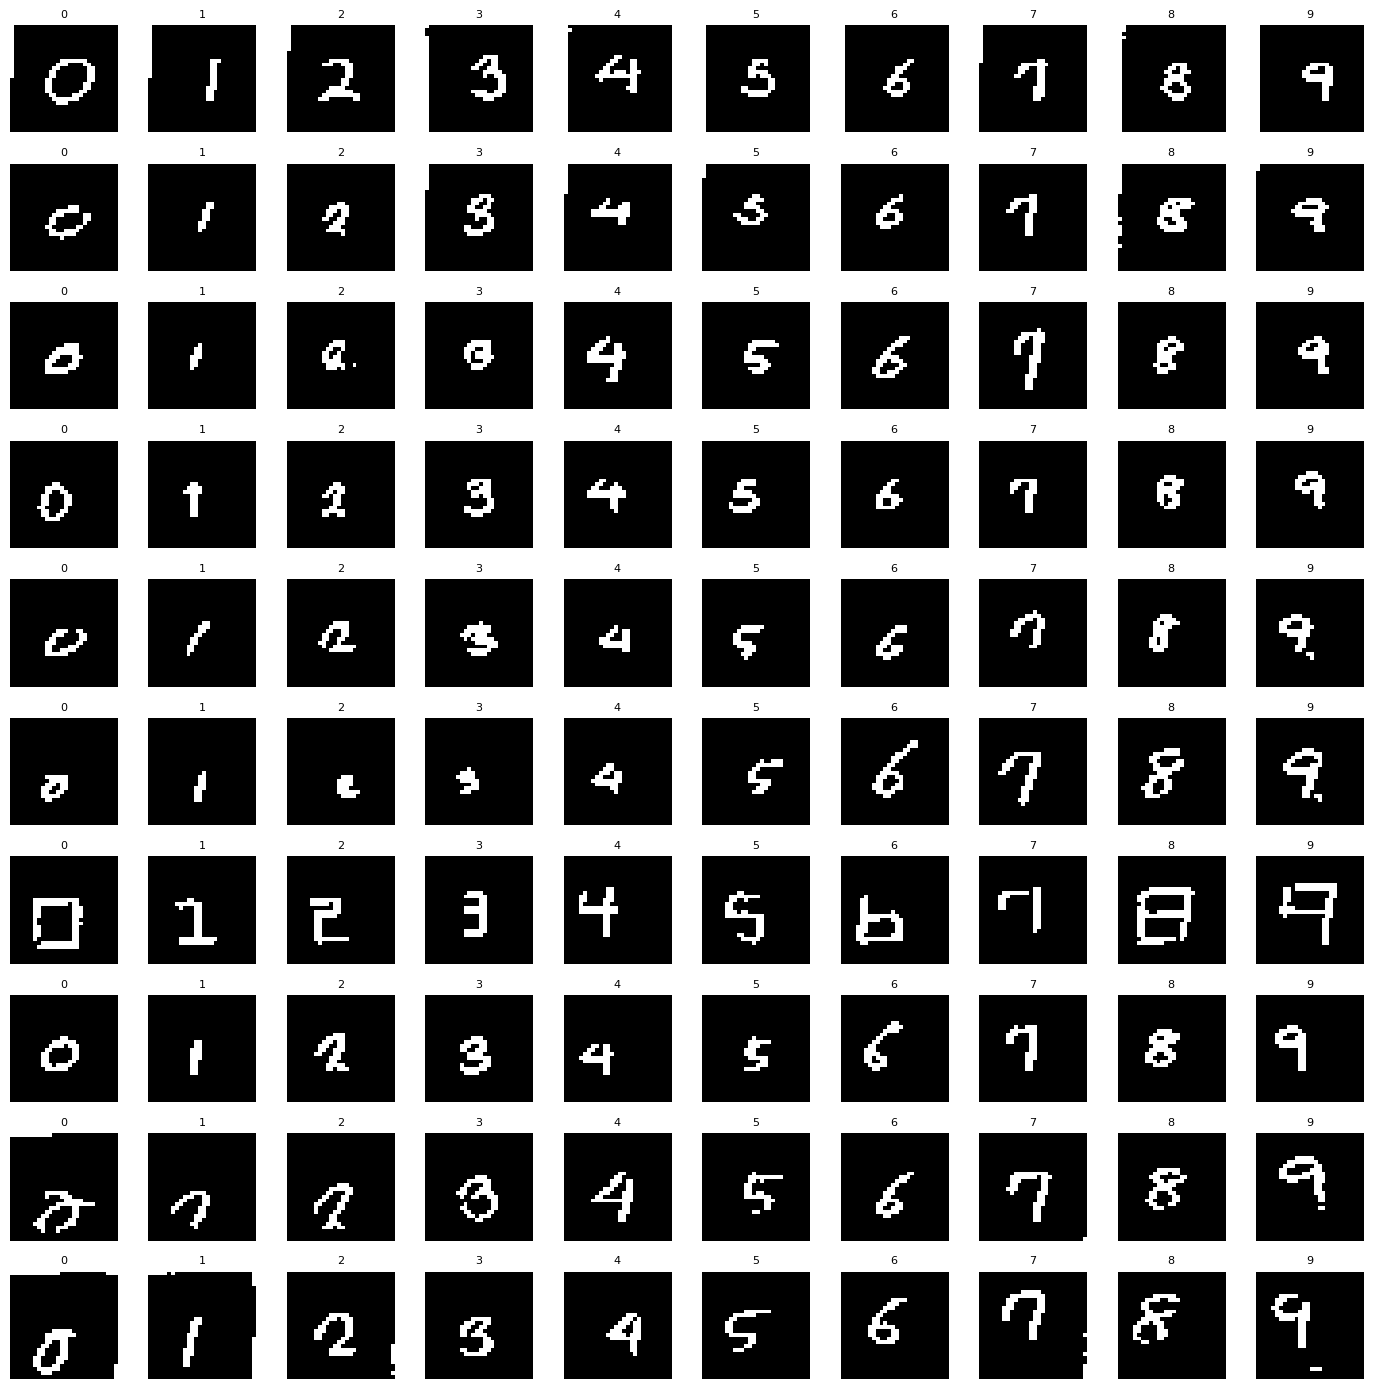


===== 페이지 10 / 25 | 이미지 900 ~ 999 =====


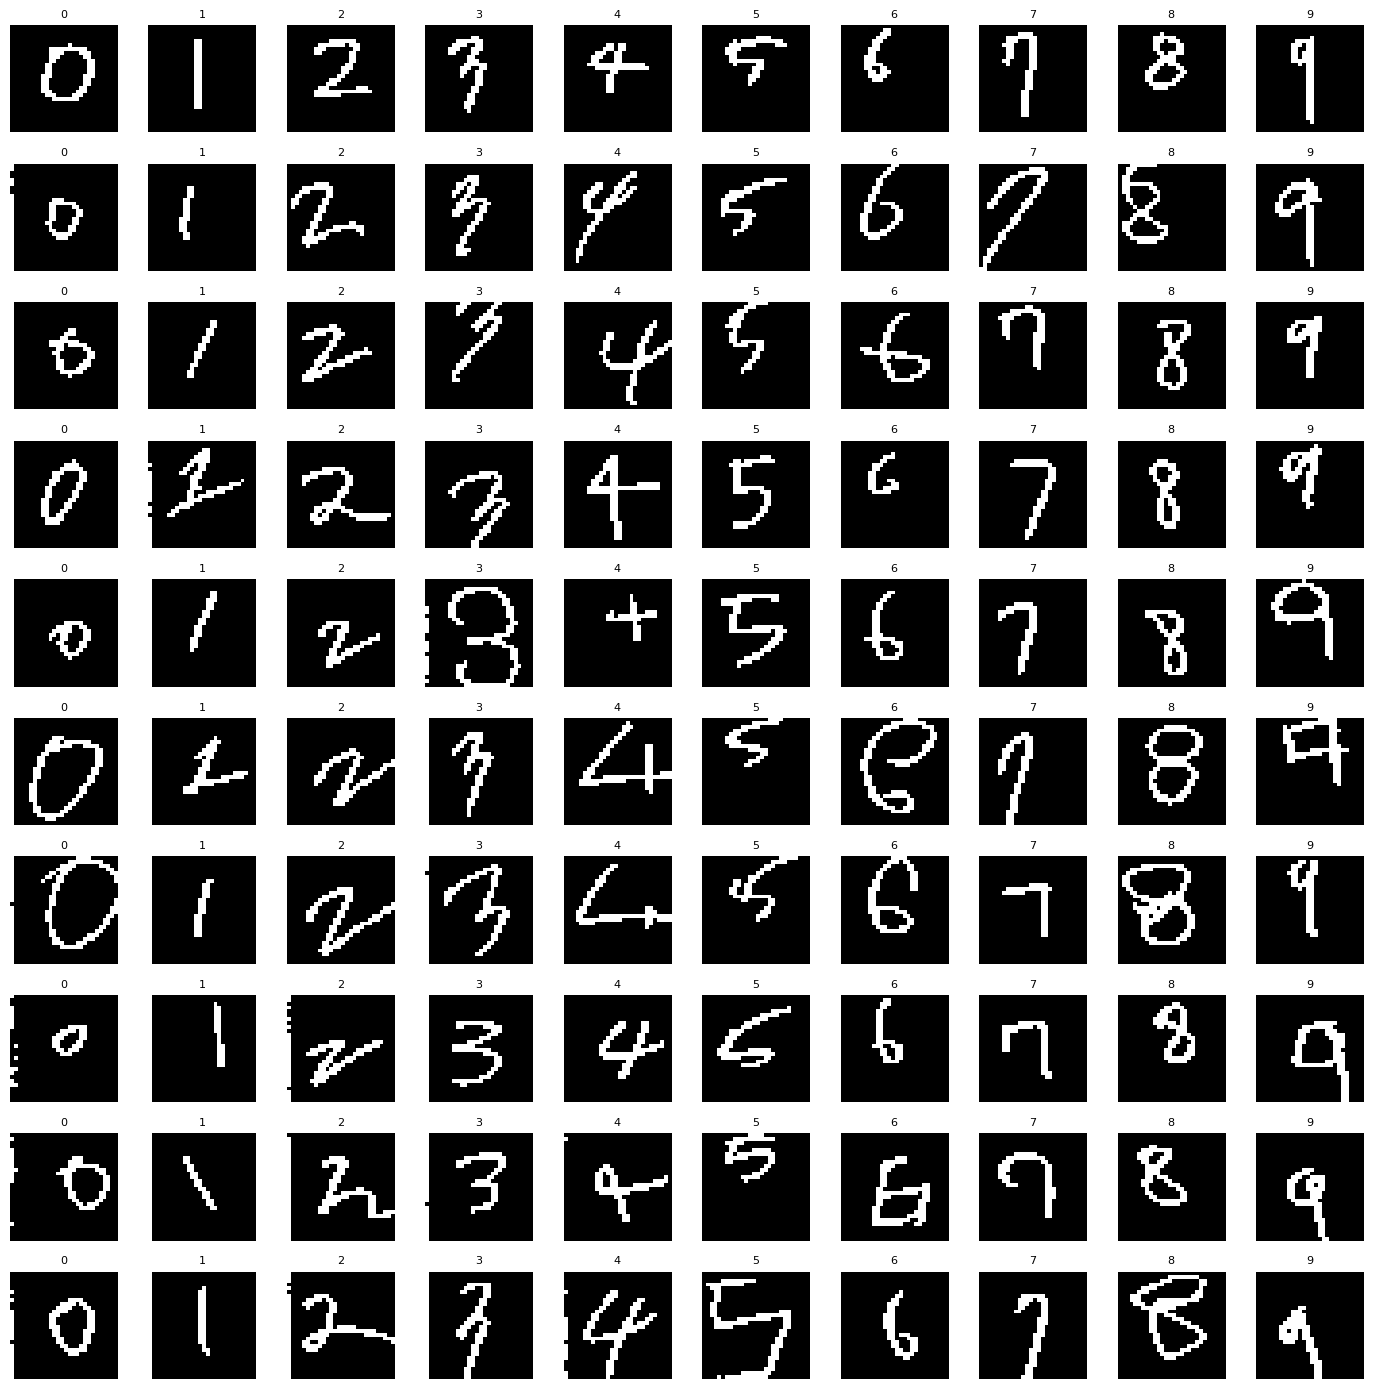


===== 페이지 11 / 25 | 이미지 1000 ~ 1099 =====


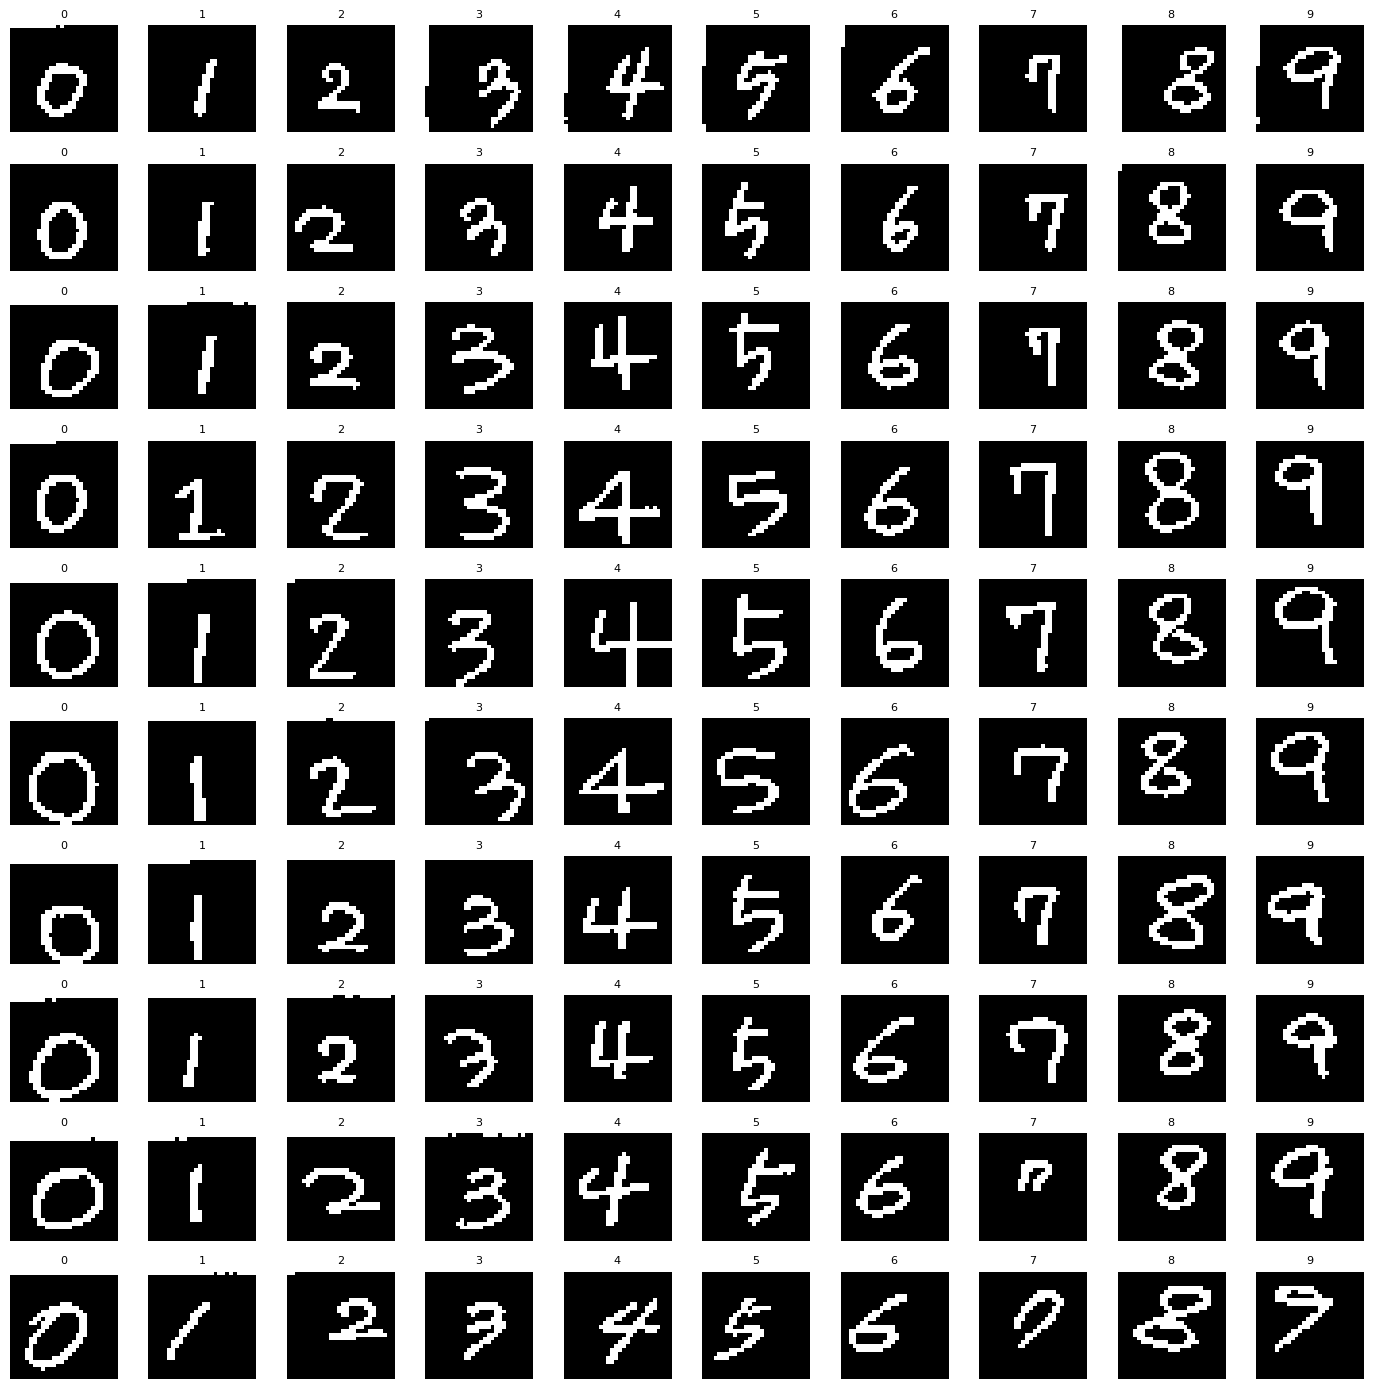


===== 페이지 12 / 25 | 이미지 1100 ~ 1199 =====


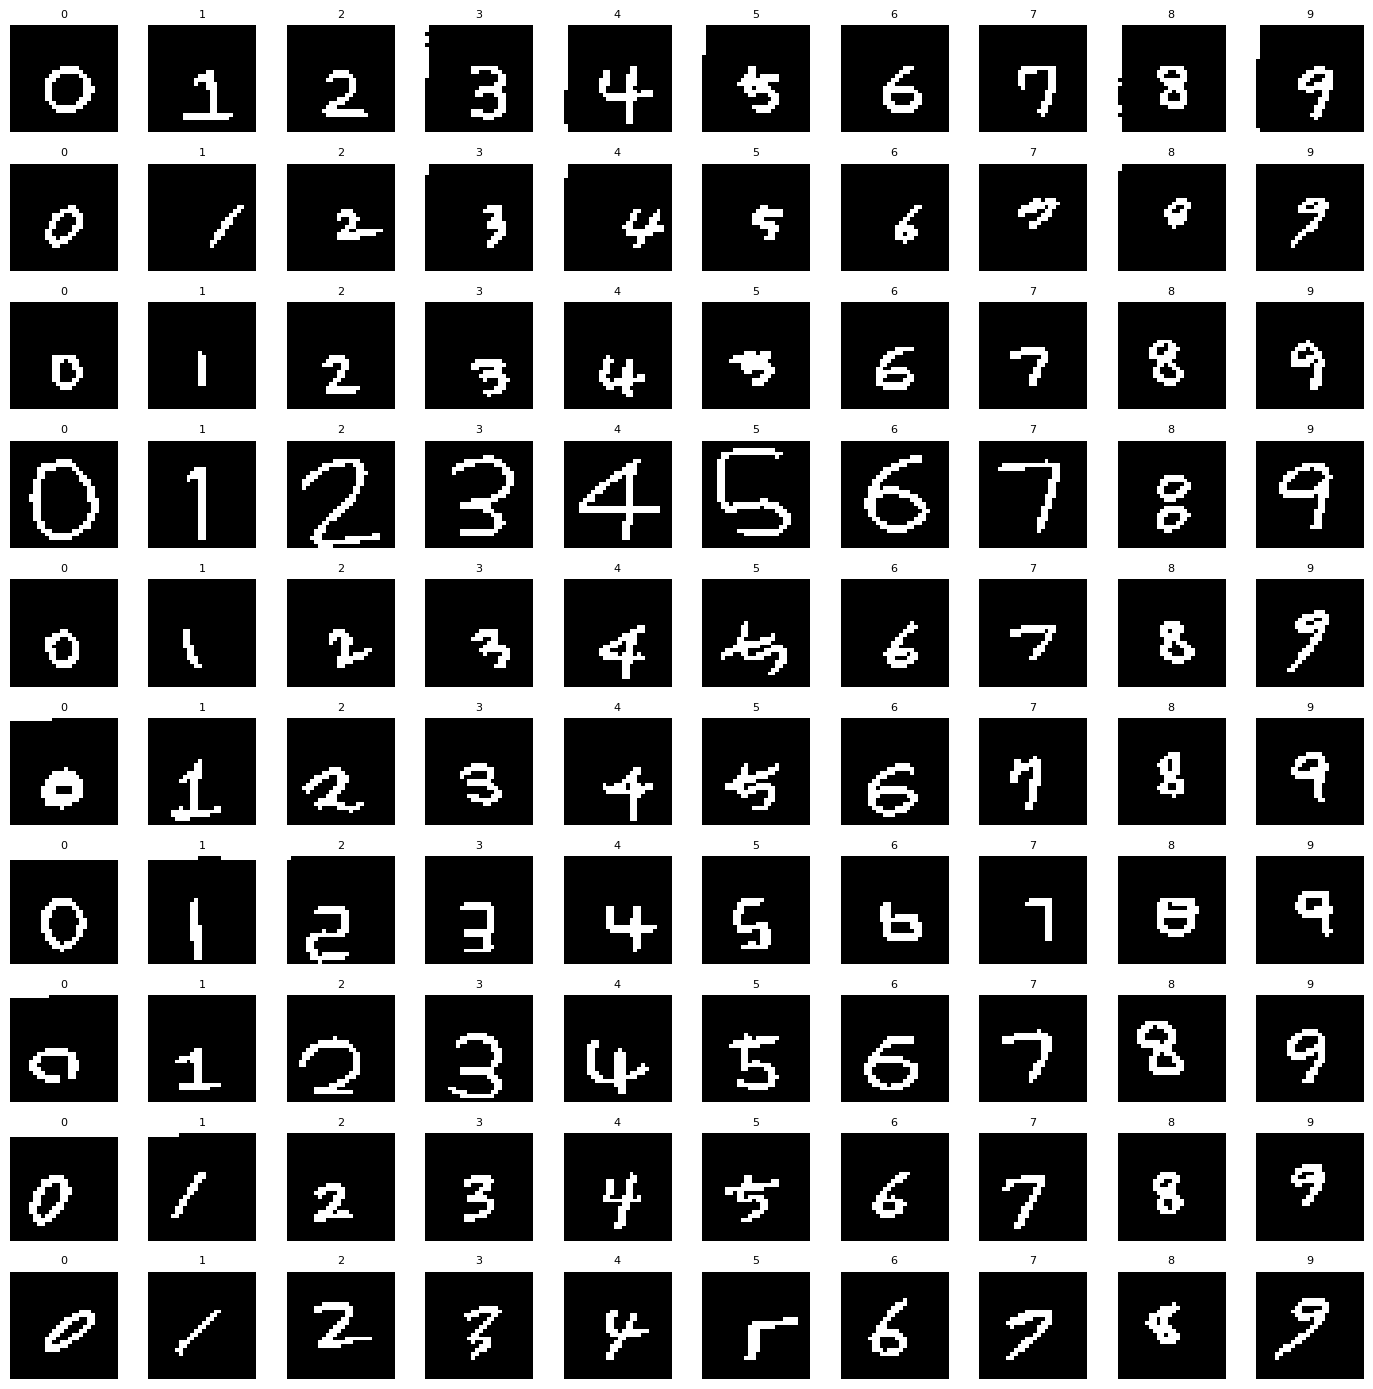


===== 페이지 13 / 25 | 이미지 1200 ~ 1299 =====


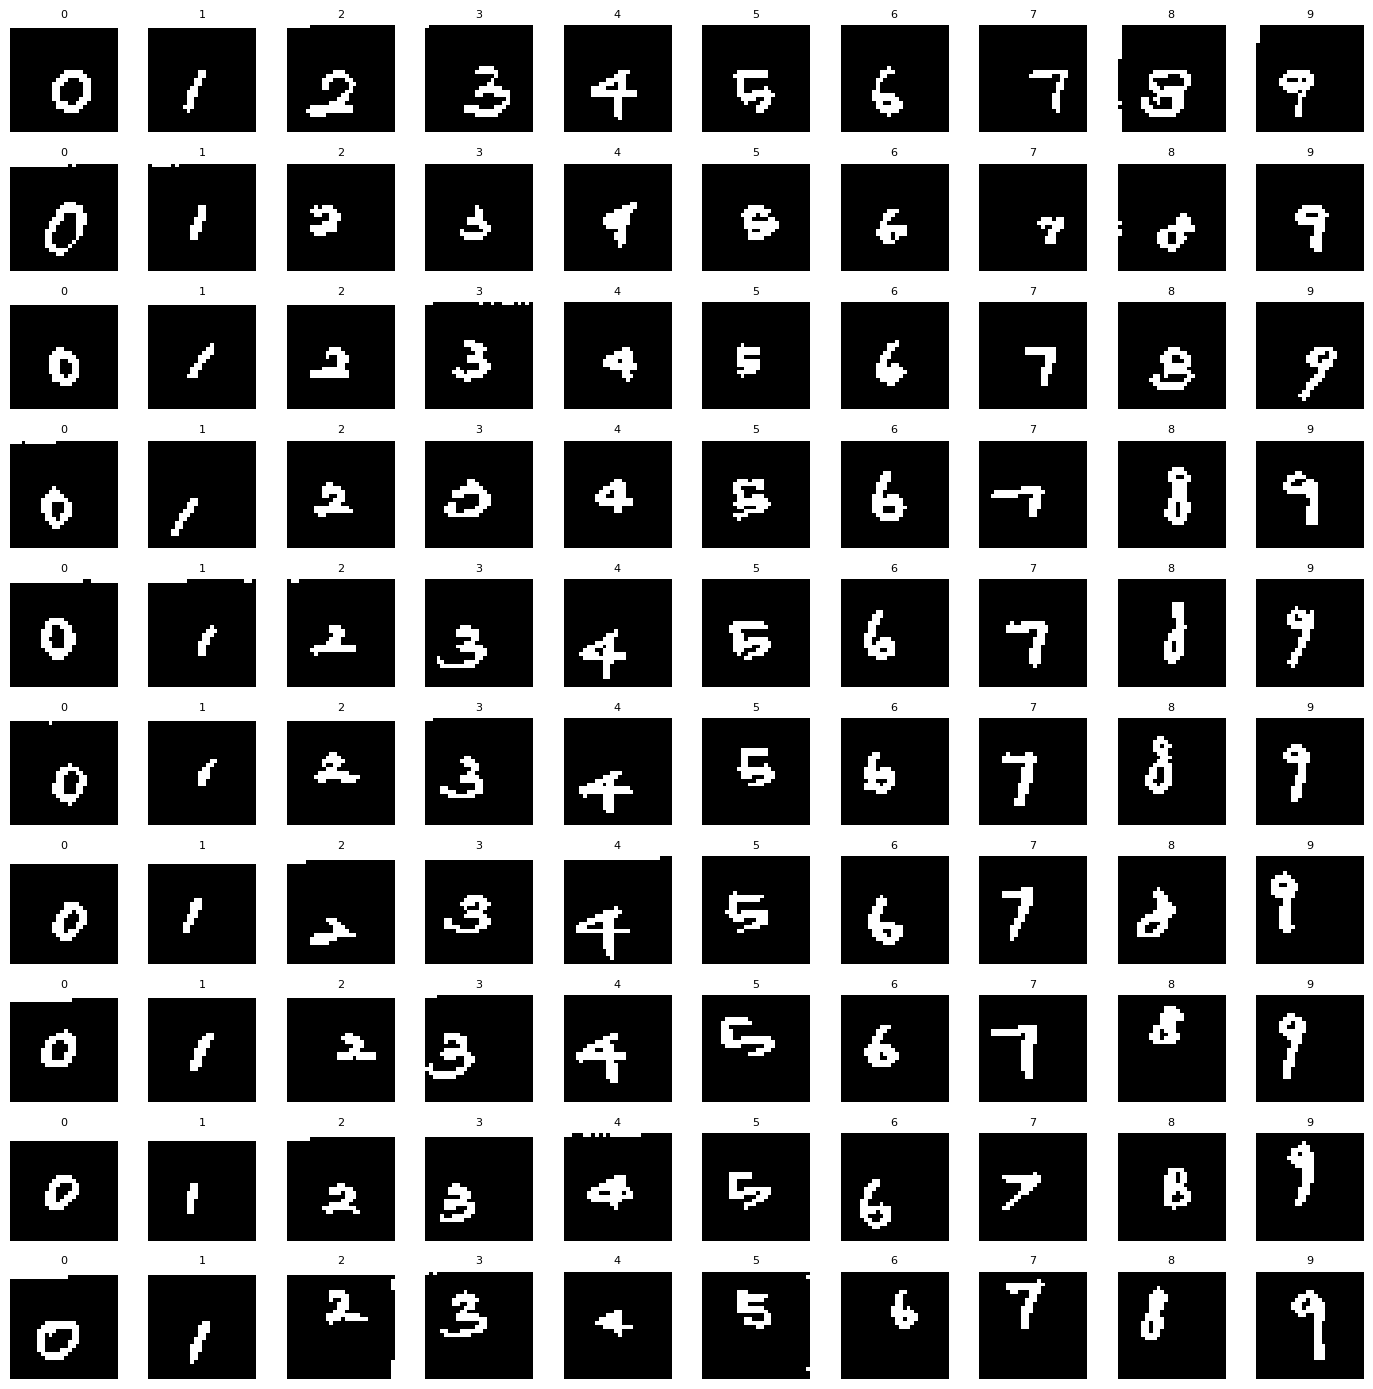


===== 페이지 14 / 25 | 이미지 1300 ~ 1399 =====


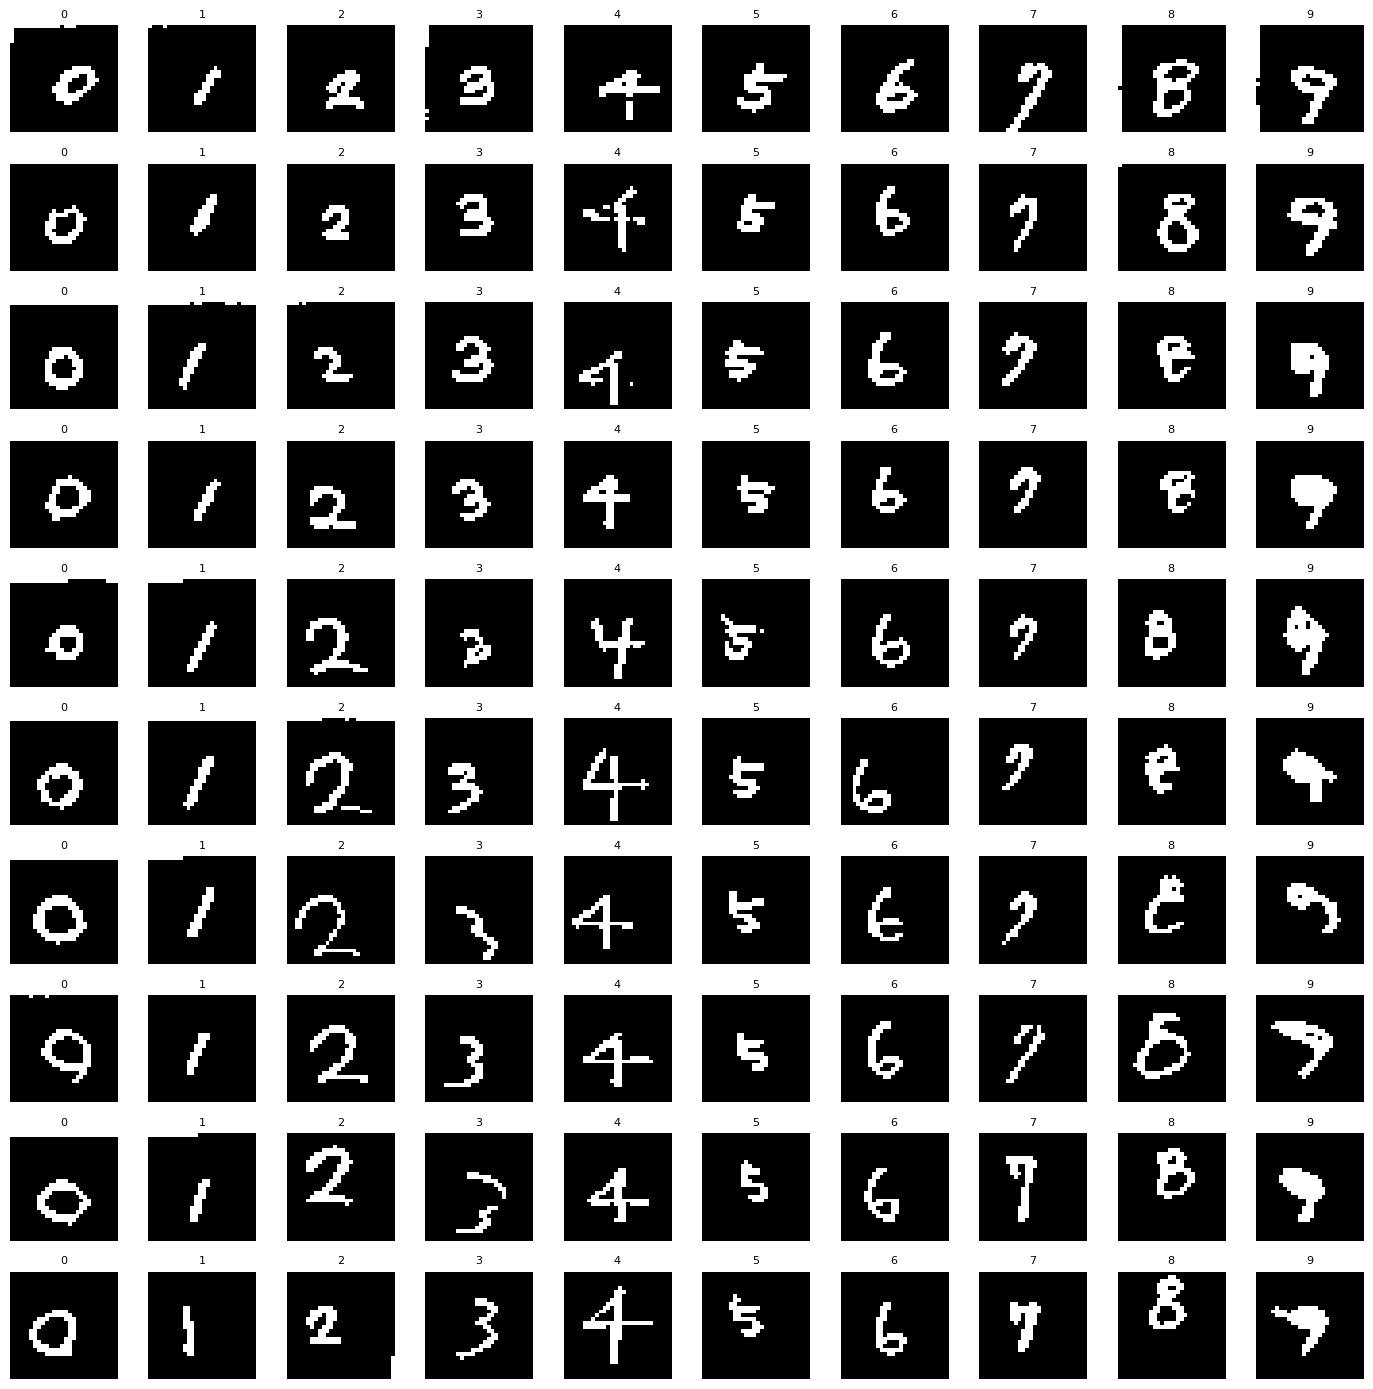


===== 페이지 15 / 25 | 이미지 1400 ~ 1499 =====


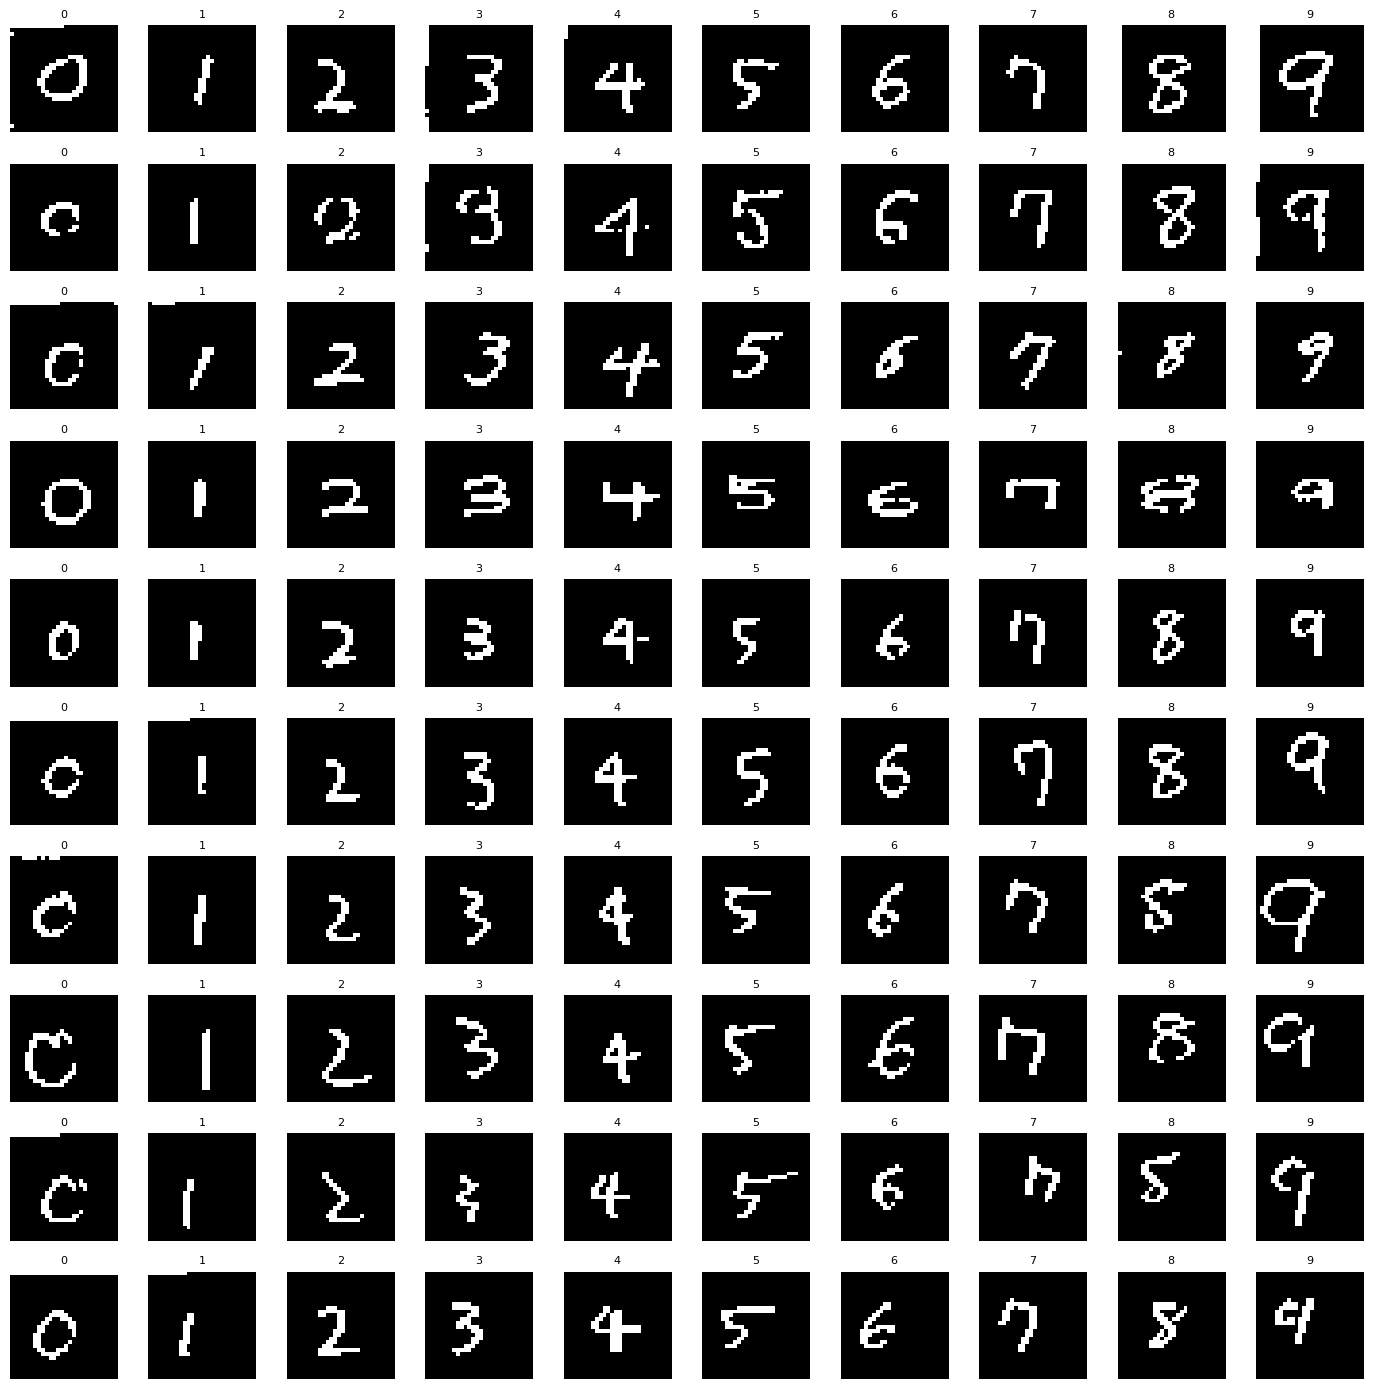


===== 페이지 16 / 25 | 이미지 1500 ~ 1599 =====


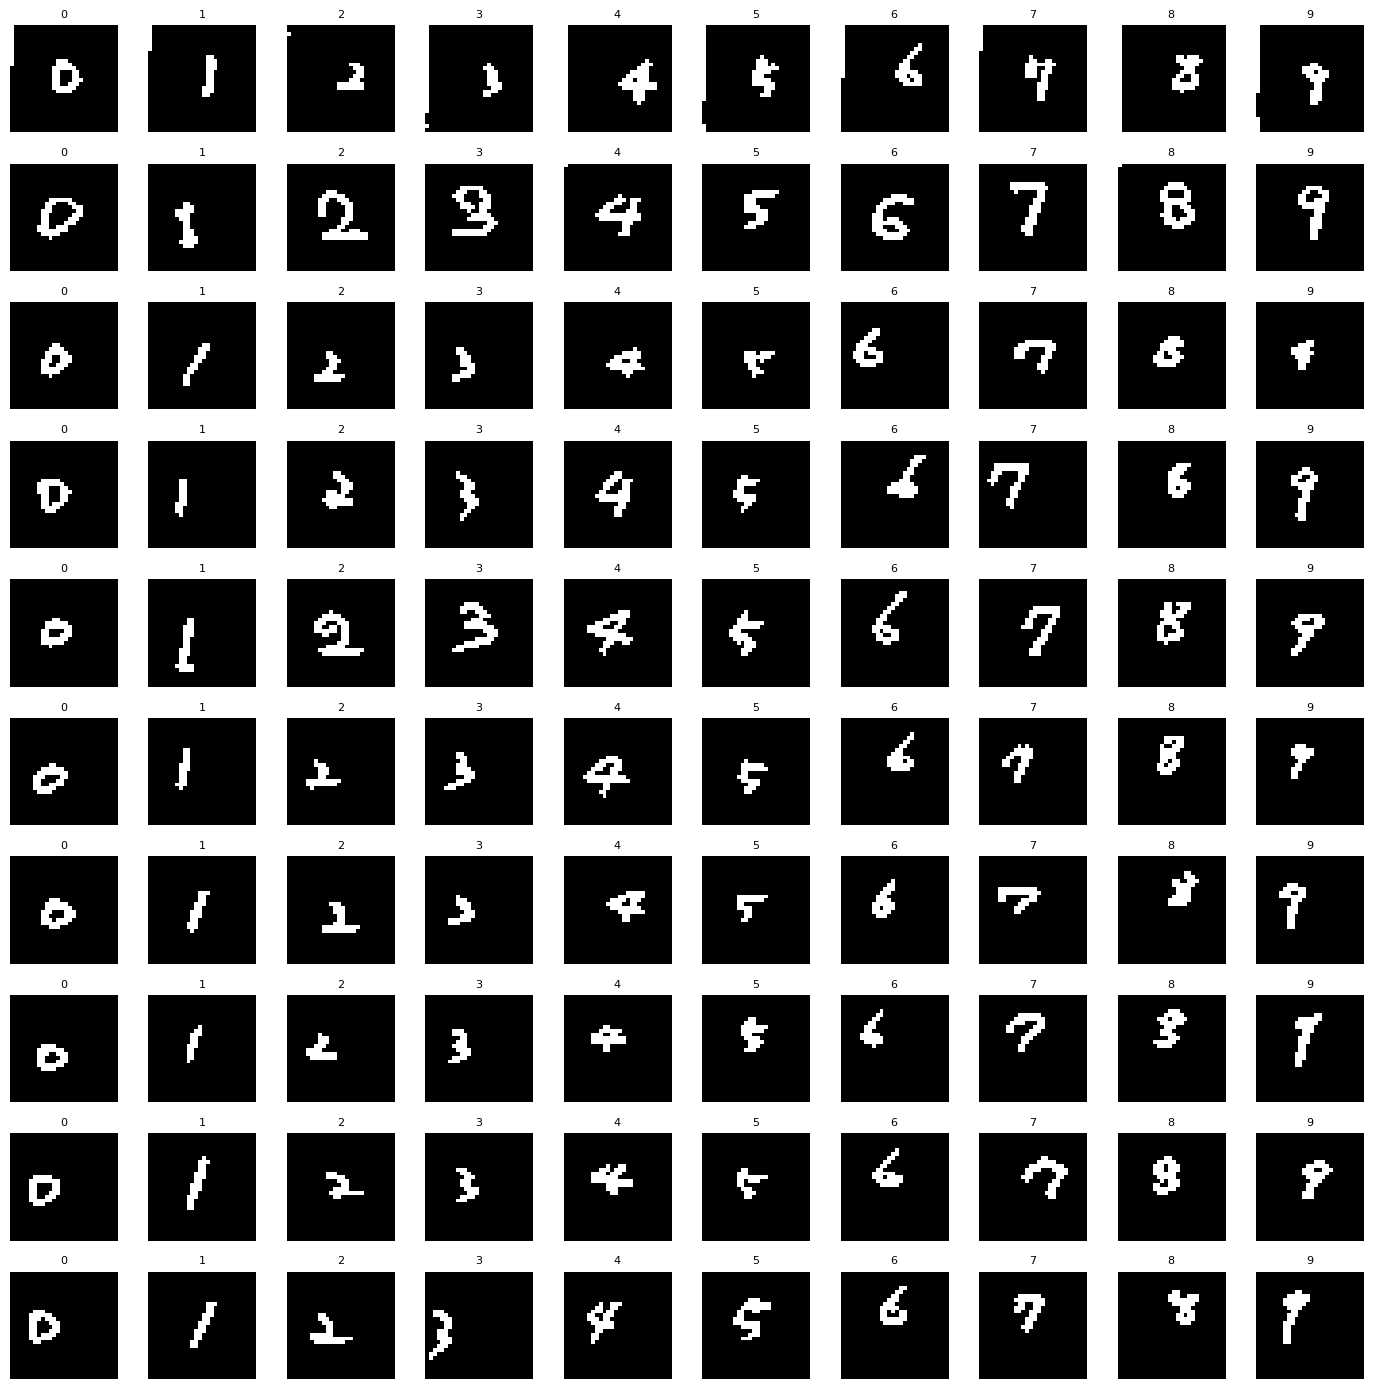


===== 페이지 17 / 25 | 이미지 1600 ~ 1699 =====


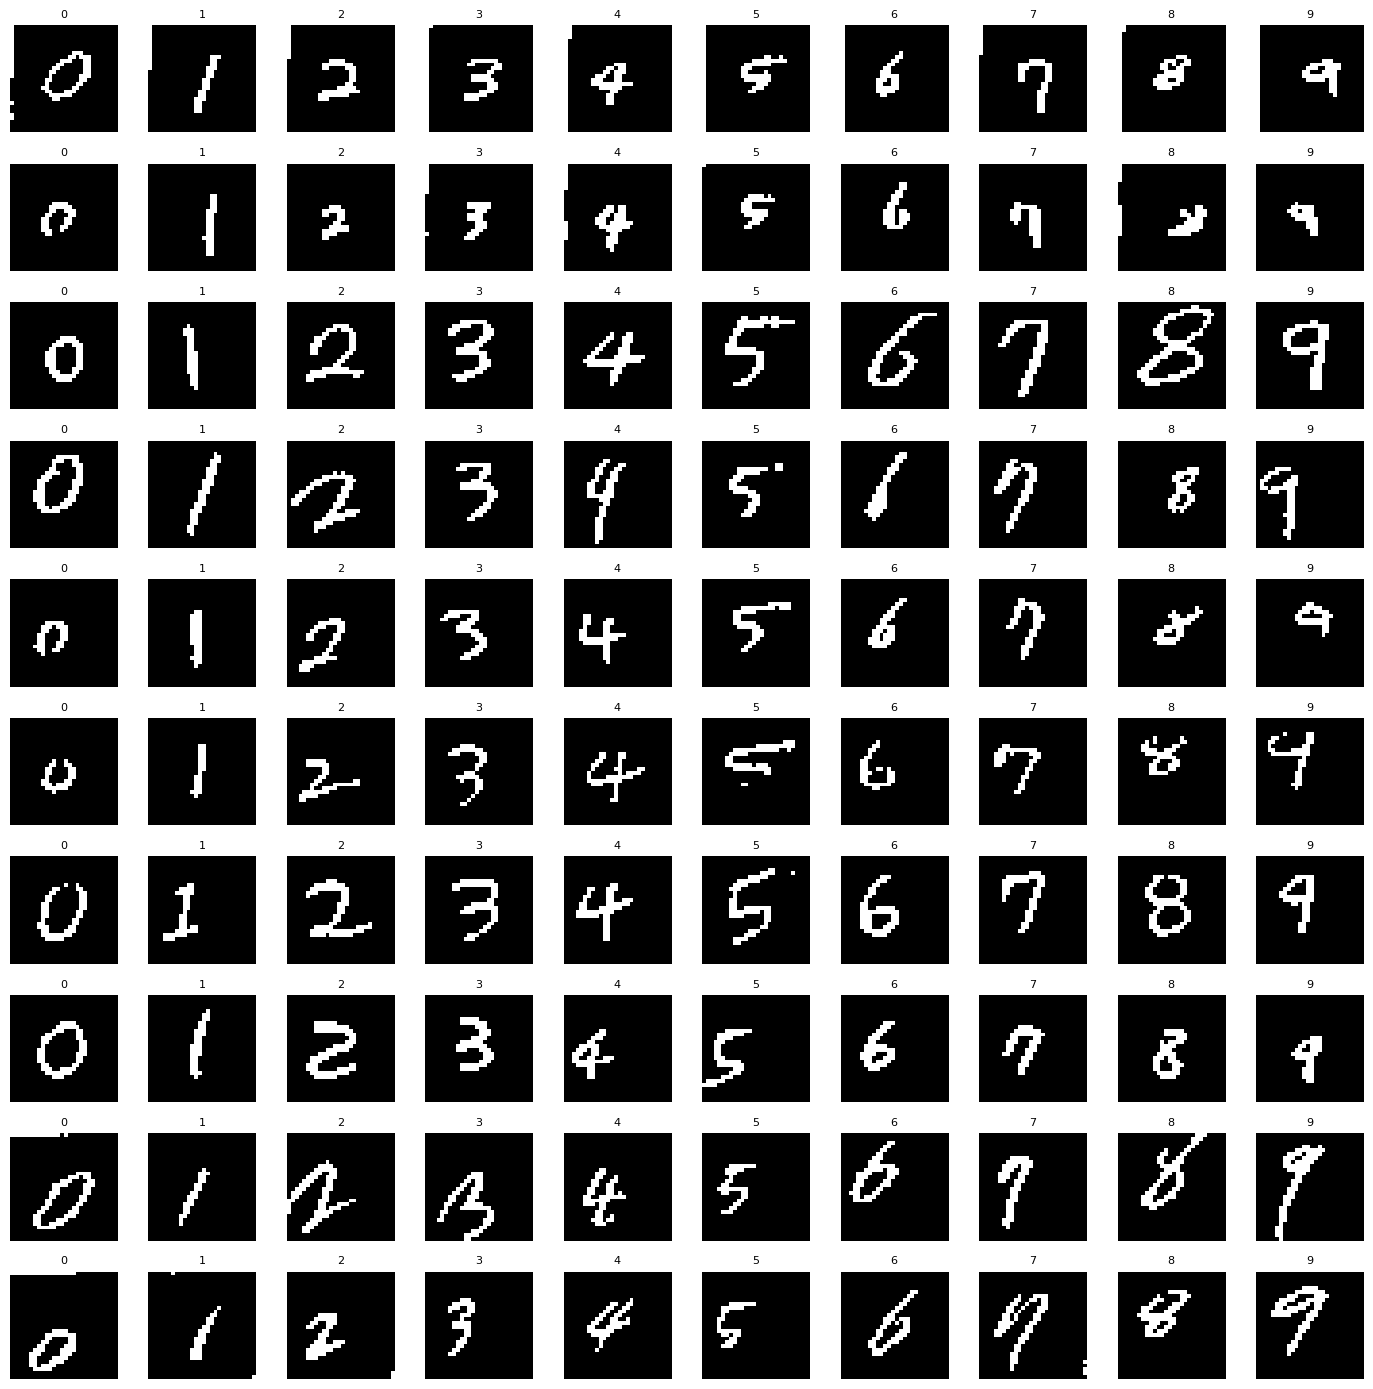


===== 페이지 18 / 25 | 이미지 1700 ~ 1799 =====


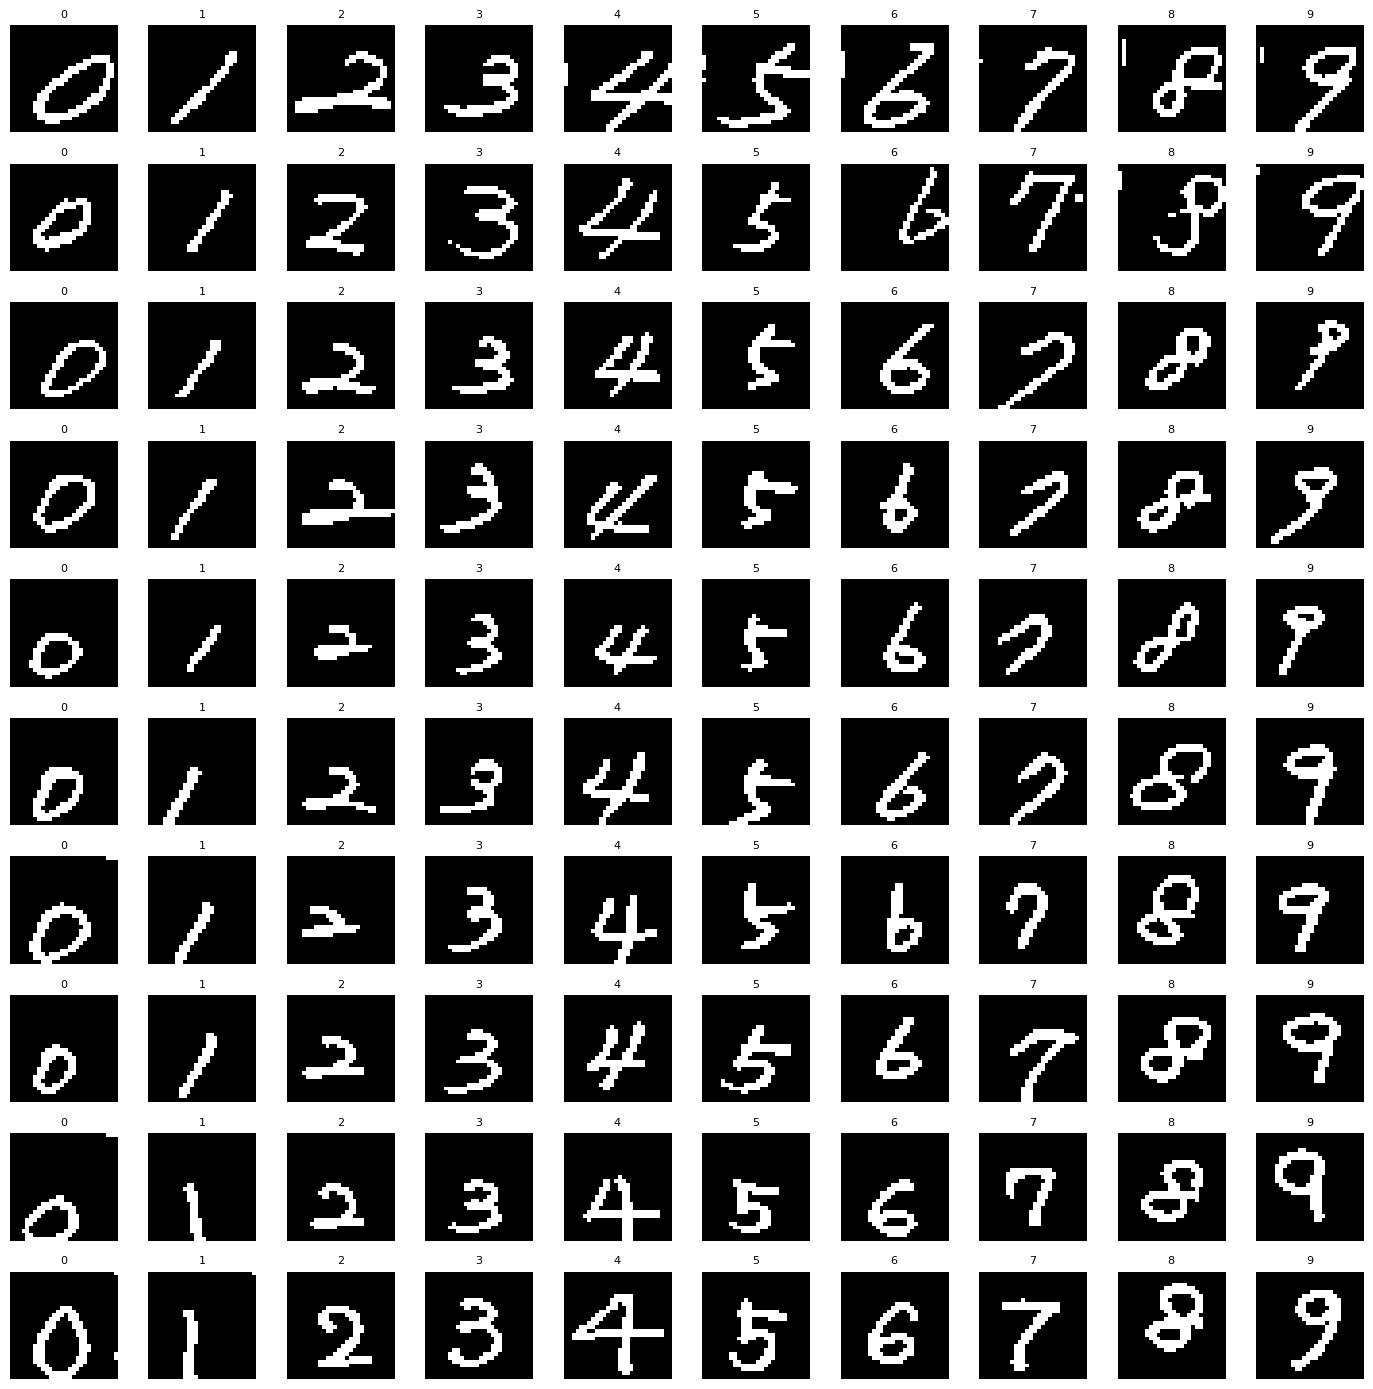


===== 페이지 19 / 25 | 이미지 1800 ~ 1899 =====


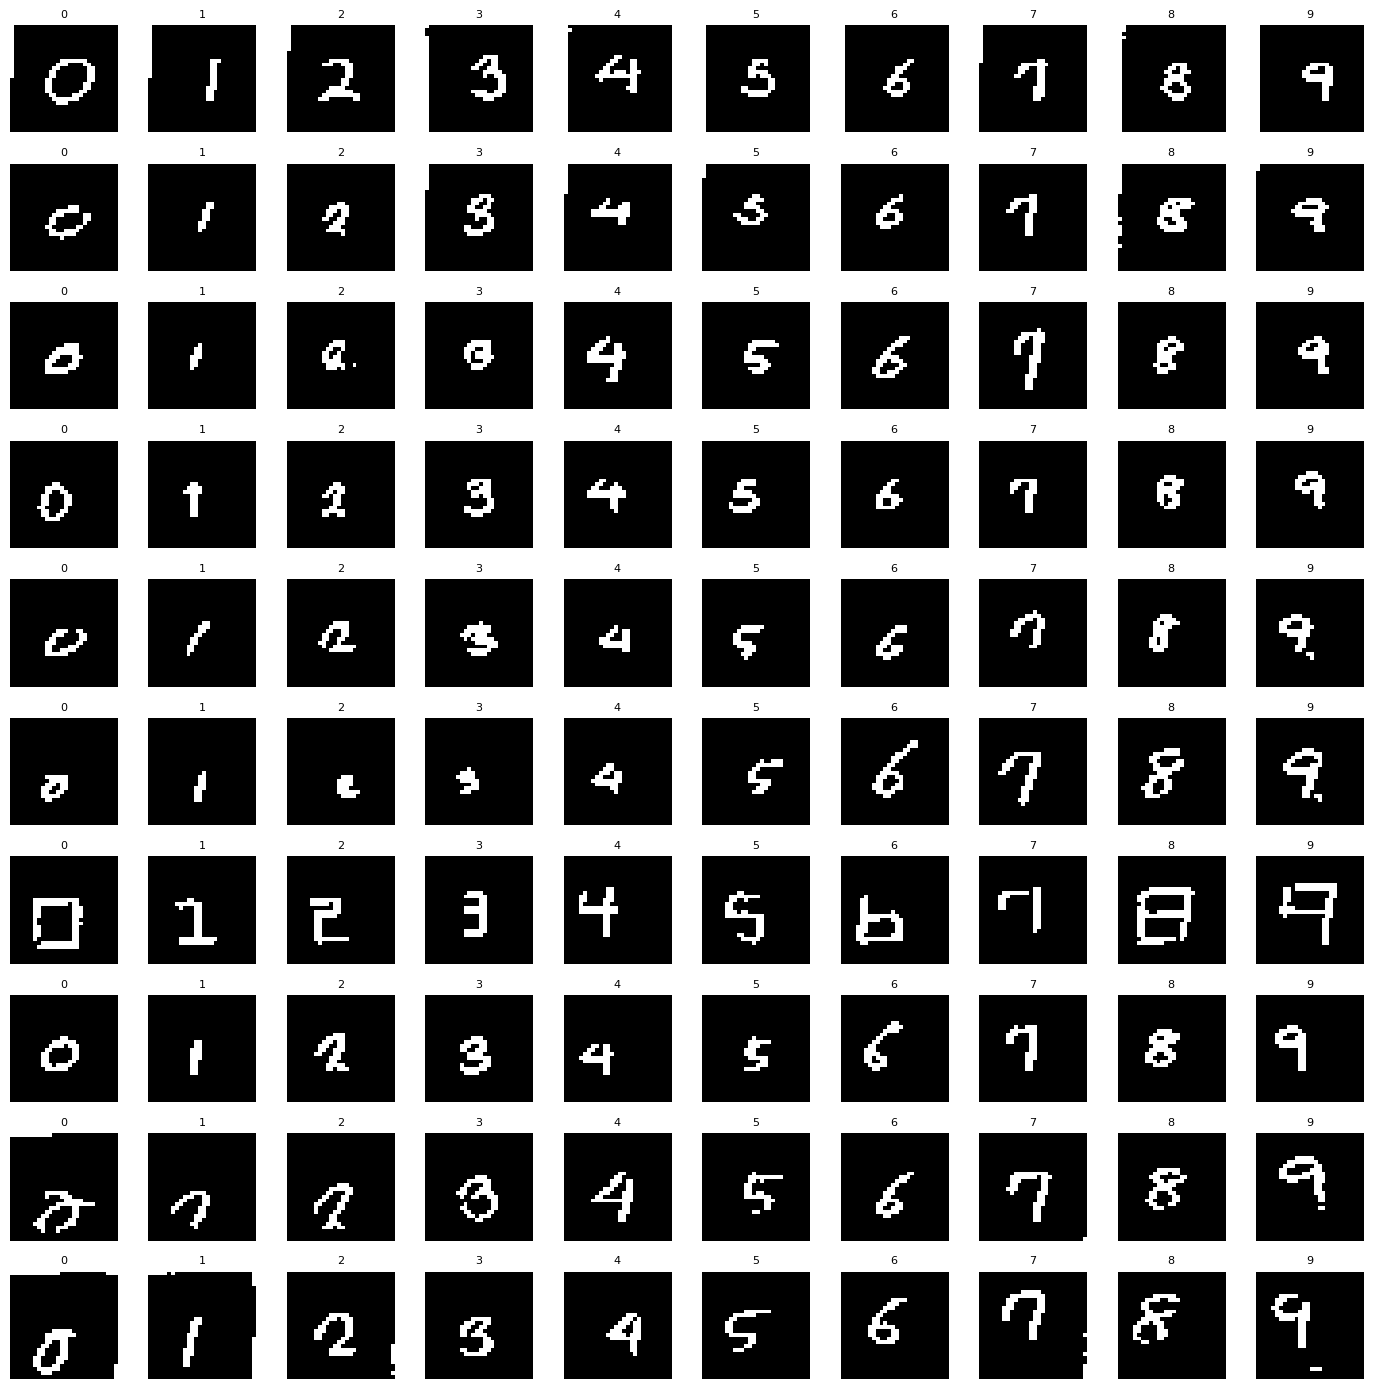


===== 페이지 20 / 25 | 이미지 1900 ~ 1999 =====


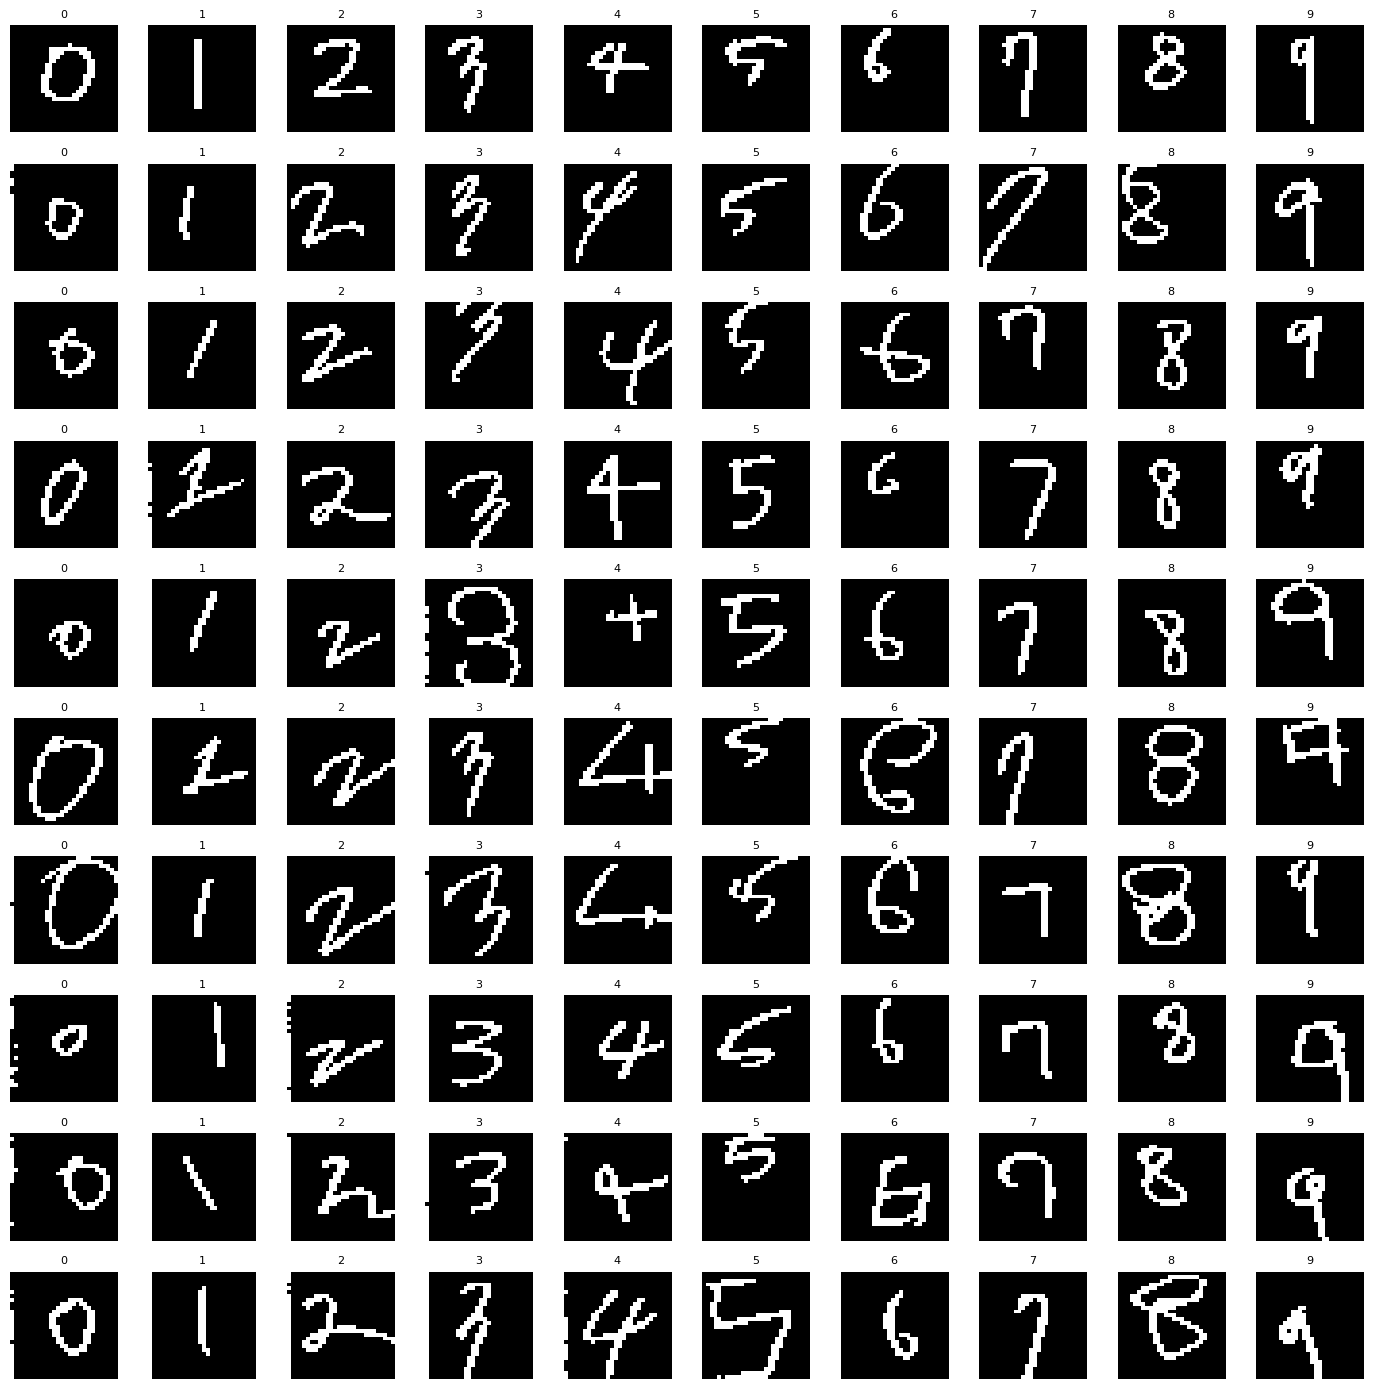


===== 페이지 21 / 25 | 이미지 2000 ~ 2099 =====


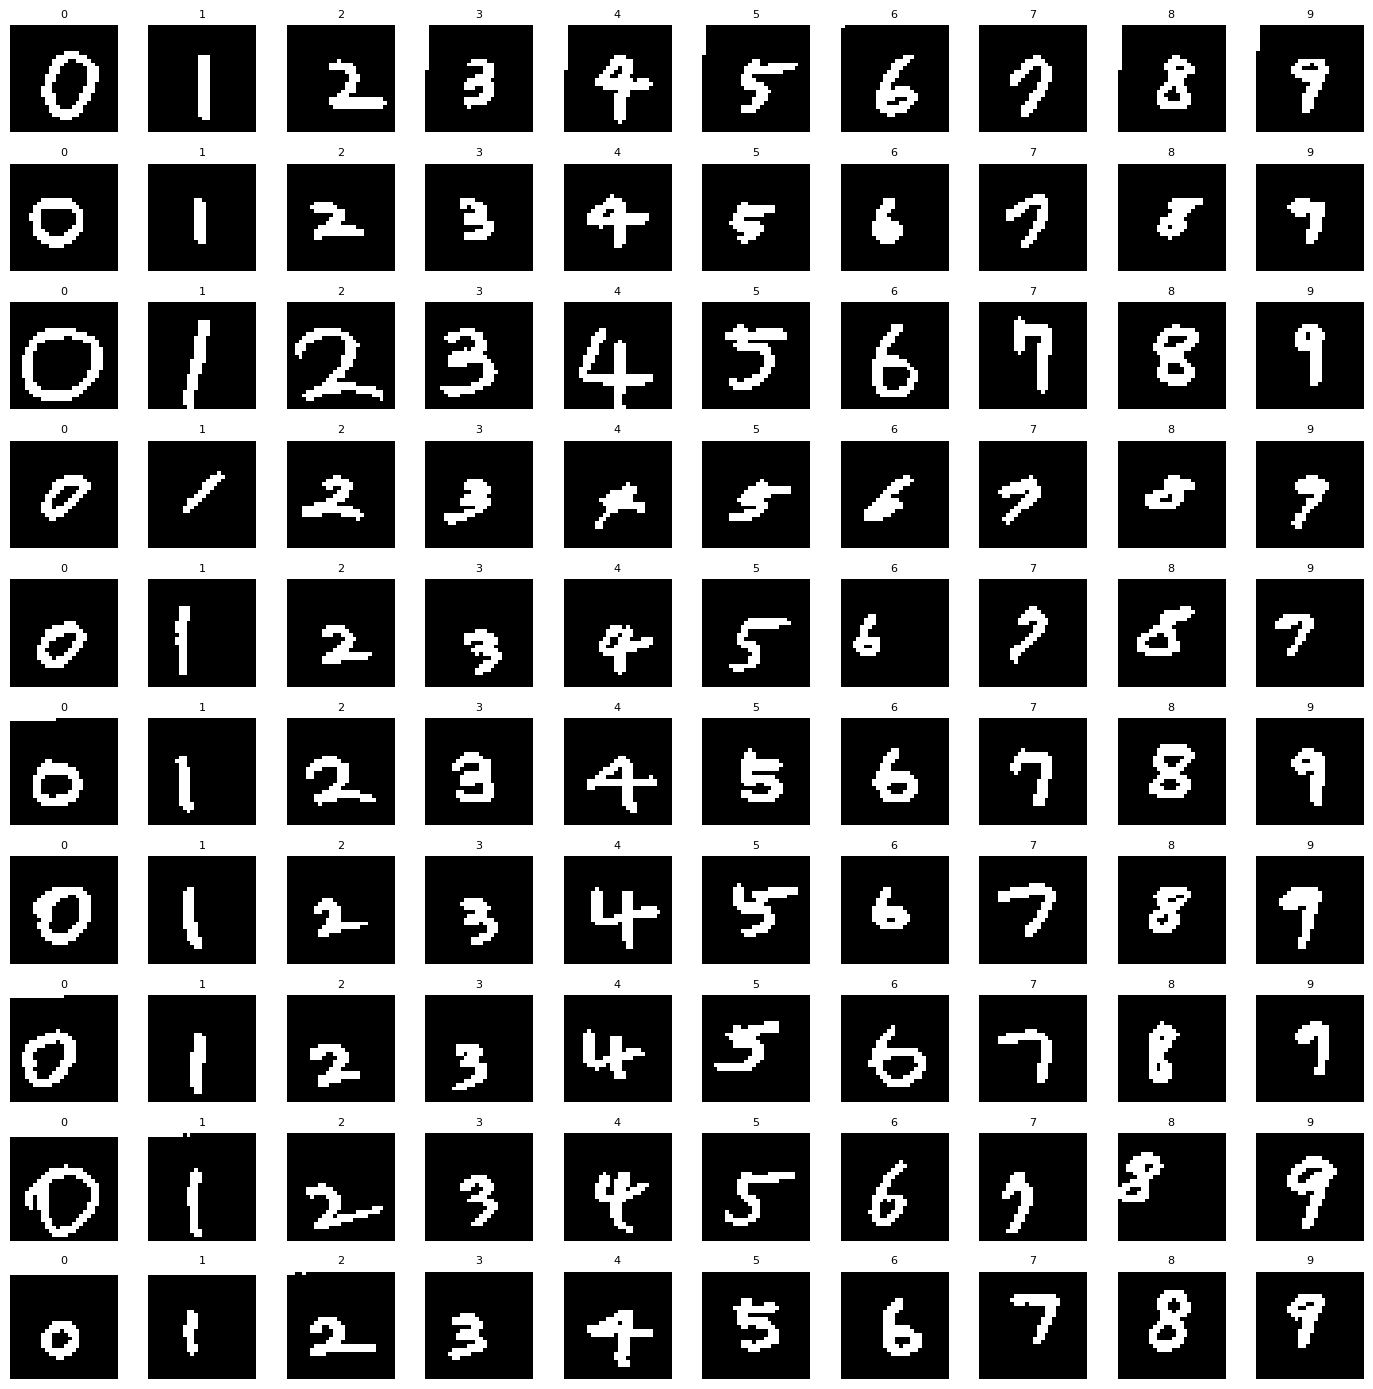


===== 페이지 22 / 25 | 이미지 2100 ~ 2199 =====


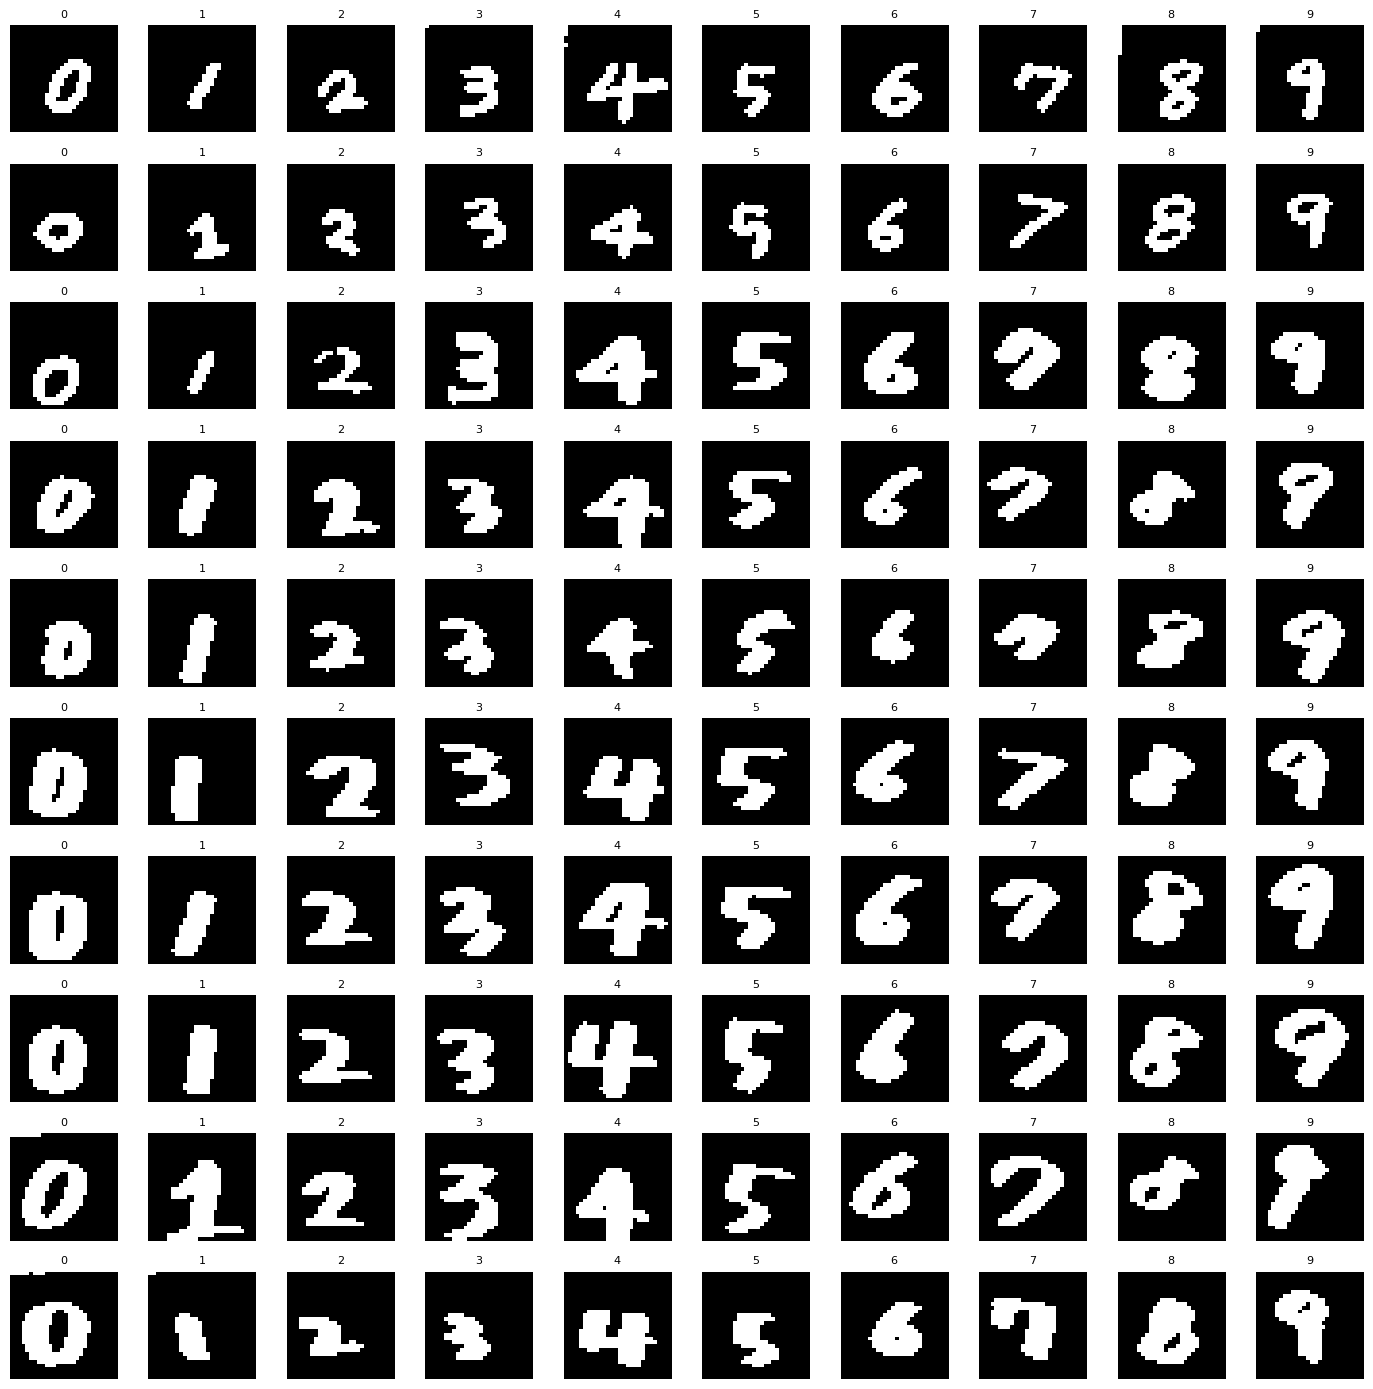


===== 페이지 23 / 25 | 이미지 2200 ~ 2299 =====


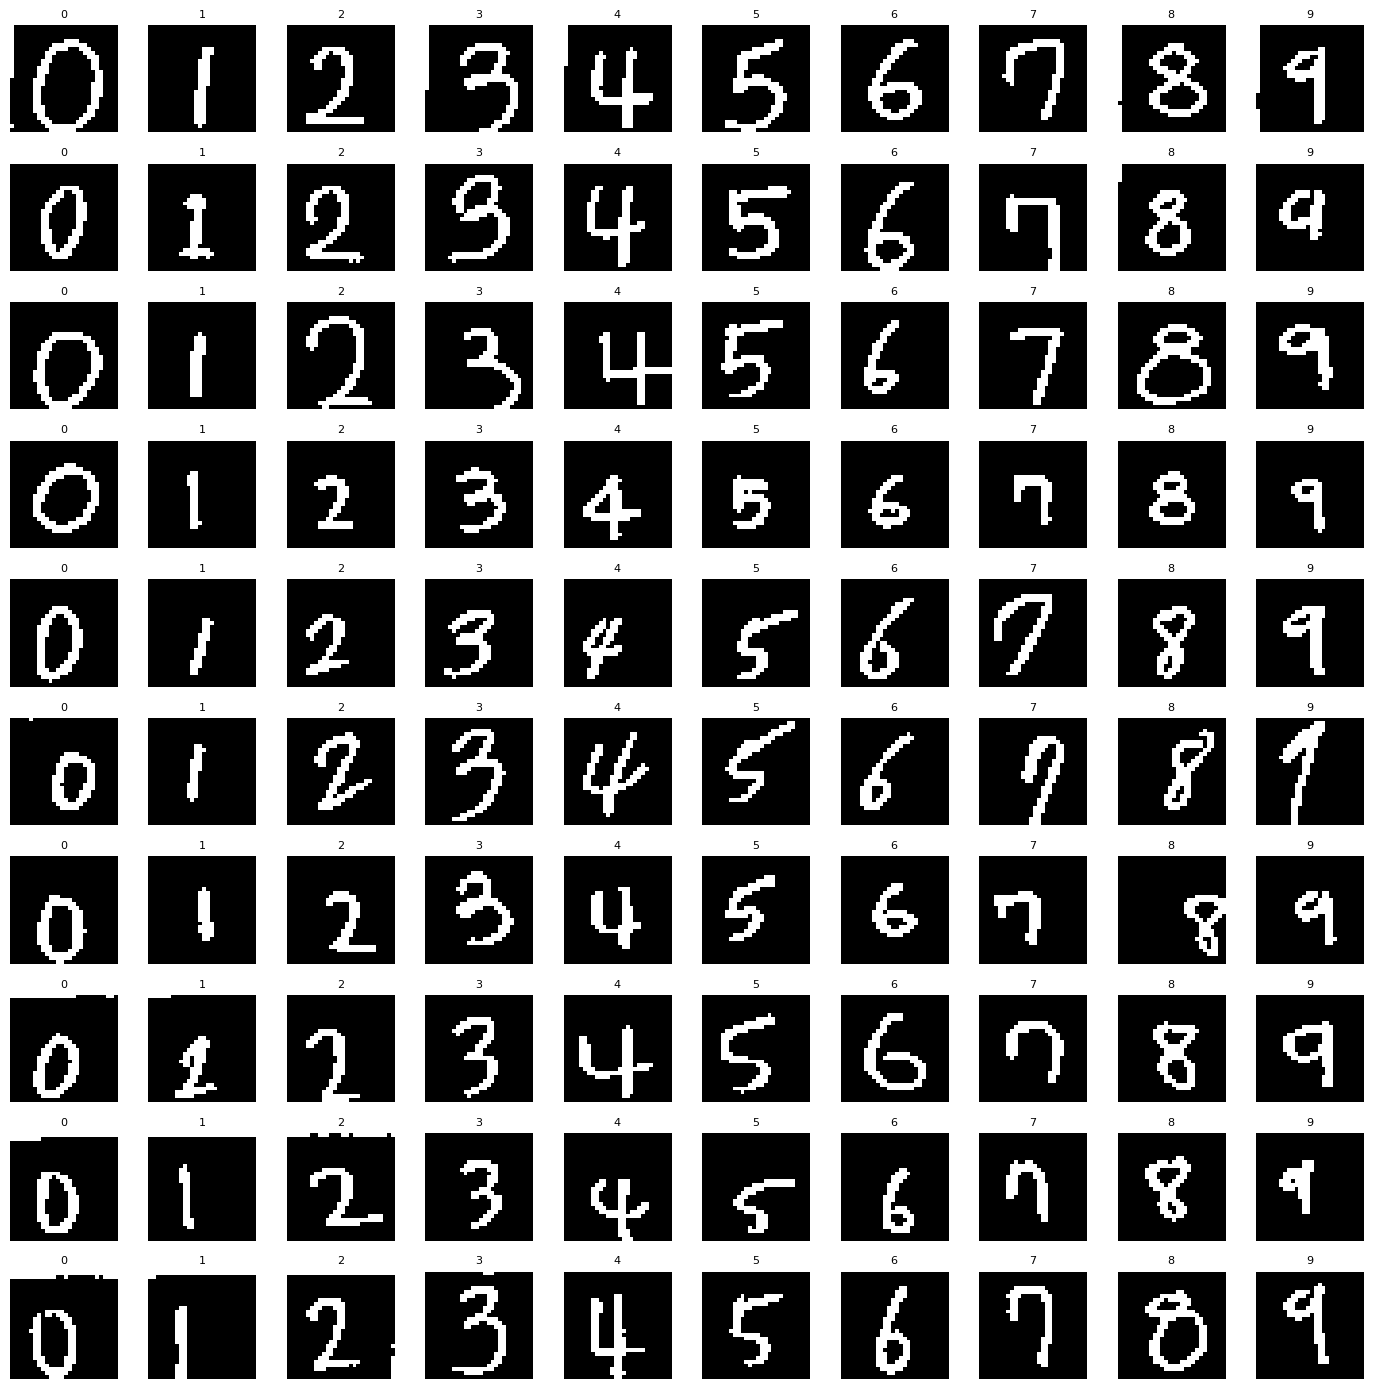


===== 페이지 24 / 25 | 이미지 2300 ~ 2399 =====


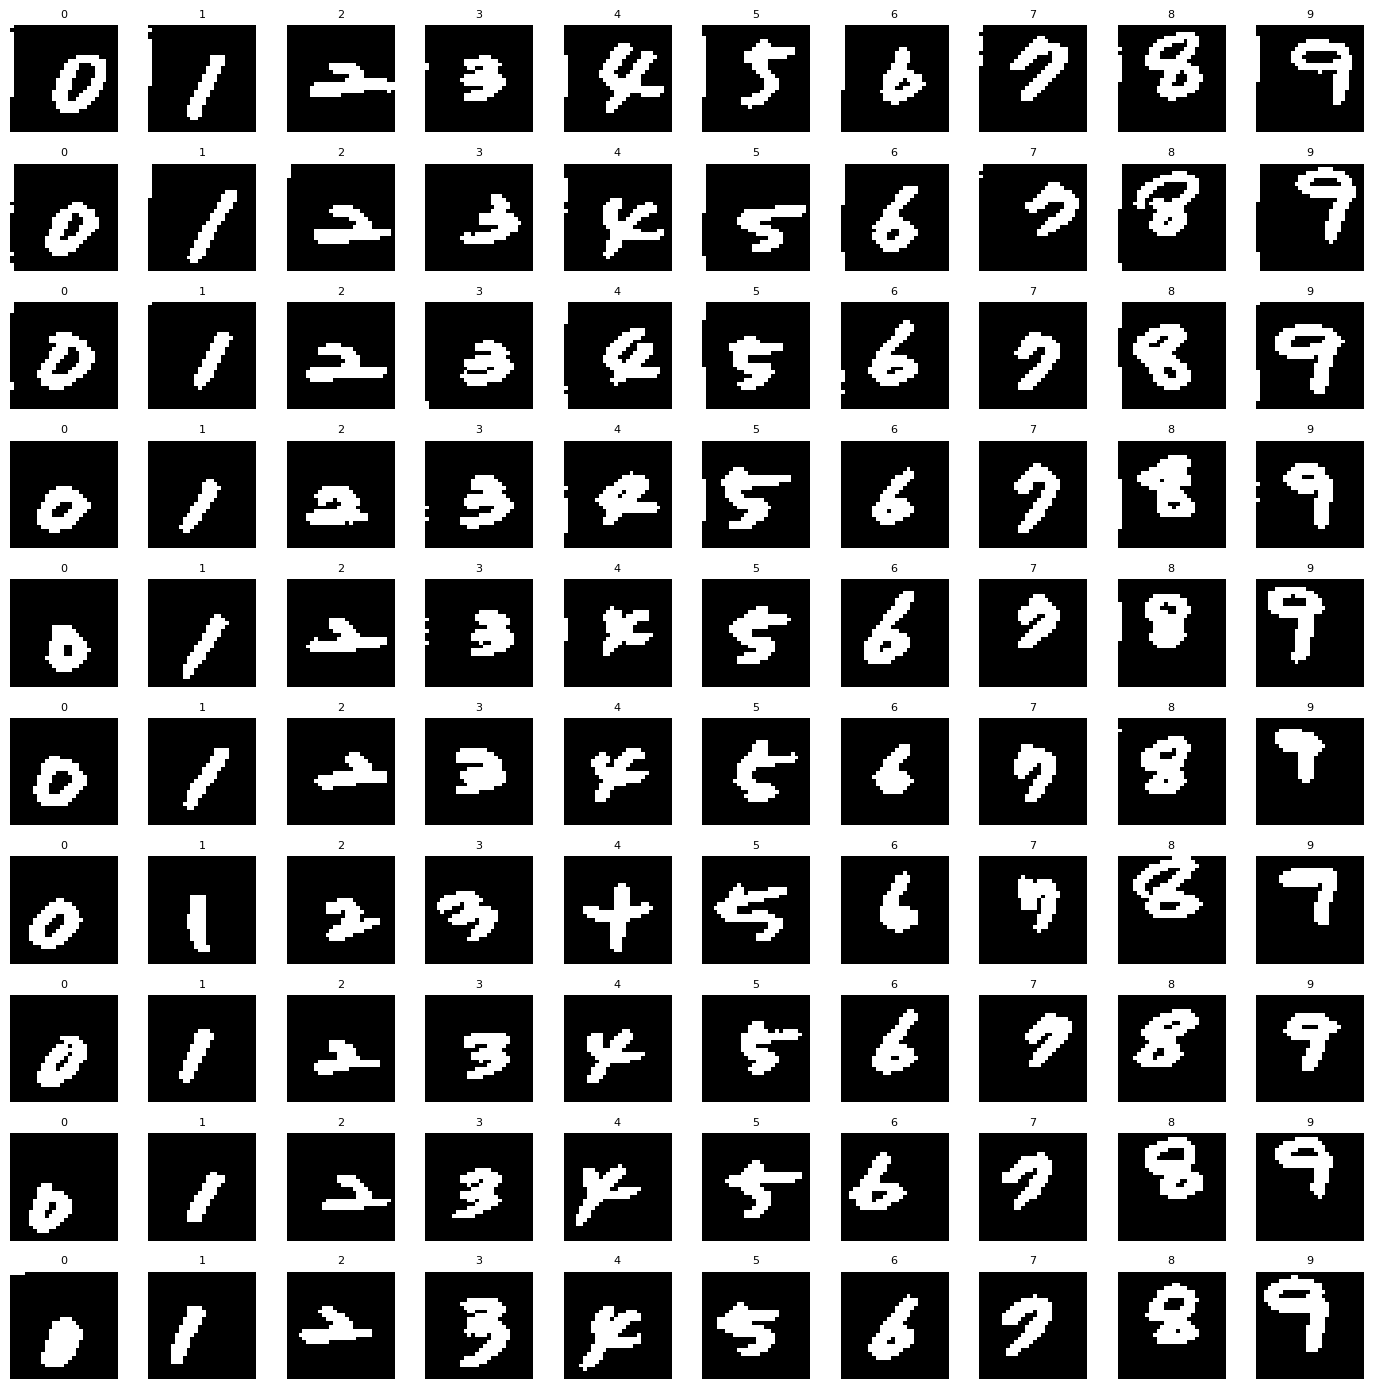


===== 페이지 25 / 25 | 이미지 2400 ~ 2499 =====


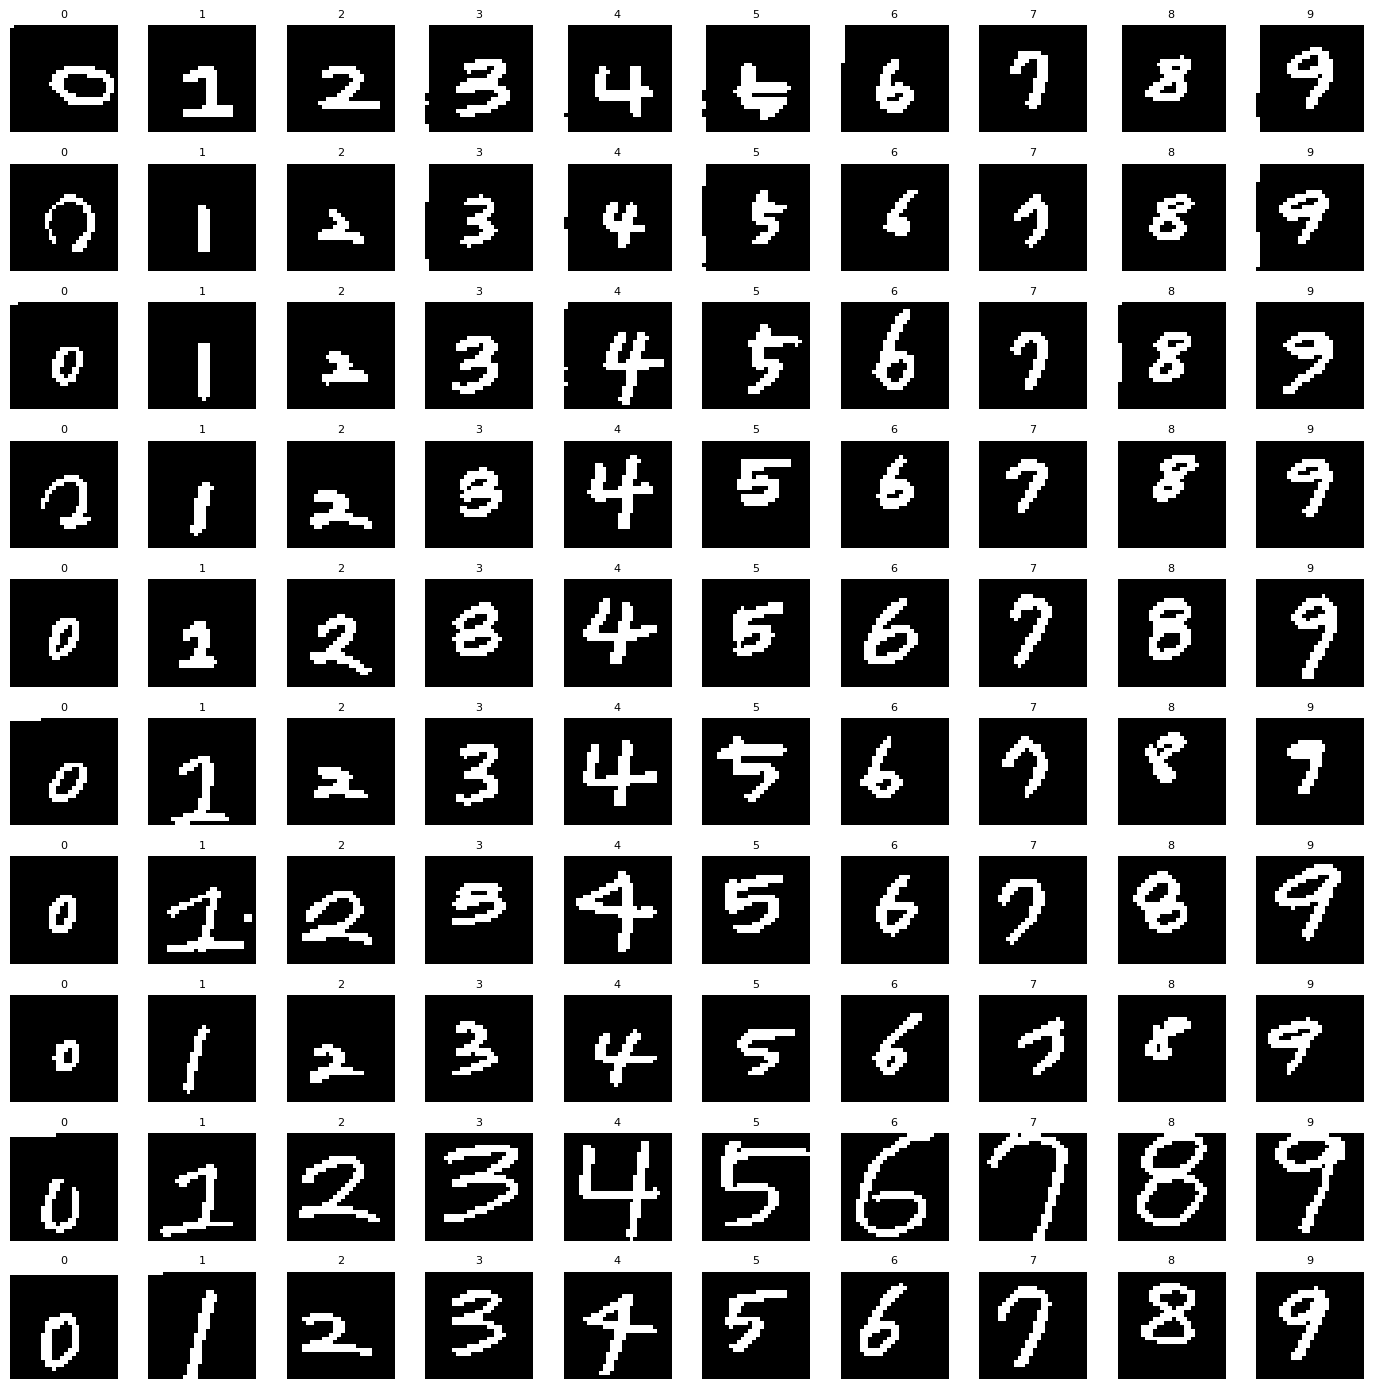

In [2]:
# =========================================
# 🧩 npz 파일의 모든 이미지를 페이지 단위로 전부 보기
# =========================================
import numpy as np
import matplotlib.pyplot as plt

# 🔹 1) 파일 로드
file_path = "SMNIST_test_25.npz"
data = np.load(file_path)

print("파일 키 목록:", list(data.keys()))

# 🔹 2) img / label 불러오기
images = data["img"]        # (N, 28, 28)
labels = data["label"]      # (N,)

images = np.array(images)
labels = np.array(labels)

N = len(images)
print("총 이미지 개수:", N)

# 🔹 3) show_grid 함수
def show_grid(imgs, titles, cols=10, size=1.6):
    n = len(imgs)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * size, rows * size))
    for i, im in enumerate(imgs):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        ax.set_title(str(titles[i]), fontsize=8)
    plt.tight_layout()
    plt.show()

# 🔹 4) 전체 이미지 페이지 단위로 출력 (라벨 포함)
per_page = 100   # 10 x 10
num_pages = (N + per_page - 1) // per_page

print("총 페이지 수:", num_pages)

for page in range(num_pages):
    start = page * per_page
    end = min(N, start + per_page)

    print(f"\n===== 페이지 {page+1} / {num_pages} | 이미지 {start} ~ {end-1} =====")

    page_imgs = images[start:end]
    page_labels = labels[start:end]   

    show_grid(page_imgs, page_labels, cols=10, size=1.4)

In [3]:
unique_types = {type(v) for v in labels}
print("label types :", unique_types)


label types : {<class 'numpy.int32'>}


In [24]:
import numpy as np

def analyze_image_scales(npz_path, key_hint=None):
    """
    npz 파일 안의 '이미지' 배열을 찾아서
    - 0~1 스케일인 이미지 개수
    - 0~255 스케일인 이미지 개수
    를 세고 비율을 표 형태로 출력.
    """
    print(f"\n===== {npz_path} 픽셀 스케일 분석 =====")

    data = np.load(npz_path, allow_pickle=True)
    keys = list(data.files)
    print("📌 포함된 key:", keys)

    # 1) 어떤 key가 이미지 데이터인지 찾기
    img_keys = []

    for key in keys:
        arr = data[key]
        if not isinstance(arr, np.ndarray):
            continue

        # 레이블(y)처럼 보이면 제외 (dtype int + 값이 0~9)
        if np.issubdtype(arr.dtype, np.integer) and arr.max() <= 9:
            continue

        # 2D(flatten) 또는 3D(28x28 이미지)면 후보로 추가
        if arr.ndim >= 2:
            img_keys.append(key)

    if key_hint is not None and key_hint in keys:
        img_keys = [key_hint]

    if not img_keys:
        print("❗ 이미지 데이터로 보이는 배열을 찾지 못했어요.")
        return

    # 여러 개면 그냥 첫 번째만 사용 (필요하면 바꿀 수 있음)
    img_key = img_keys[0]
    X = data[img_key]
    print(f"✨ 분석에 사용할 이미지 배열 key: '{img_key}', shape={X.shape}")

    # (N, 28, 28) or (N, 784) 모두 지원
    if X.ndim == 2:
        # (N, 784) 같은 형태라고 가정
        N = X.shape[0]
    elif X.ndim == 3:
        N = X.shape[0]
        X = X.reshape(N, -1)   # 편하게 다루려고 flatten
    else:
        print("❗ 지원하지 않는 이미지 차원입니다:", X.shape)
        return

    count_01 = 0
    count_255 = 0
    count_other = 0

    for i in range(N):
        img = X[i]
        mx = img.max()
        mn = img.min()

        if mx <= 1.0:
            count_01 += 1
        elif mx <= 255:
            count_255 += 1
        else:
            count_other += 1

    total = count_01 + count_255 + count_other

    # 비율 계산
    def ratio(c):
        return 100.0 * c / total if total > 0 else 0.0

    print("\n범위                 개수        비율")
    print("------------------------------------------")
    print(f"0.0 - 1.0 범위 (정규화된 실수) : {count_01:5d}개   {ratio(count_01):6.2f}%")
    print(f"0 - 255 범위   (비정규화된 값) : {count_255:5d}개   {ratio(count_255):6.2f}%")
    print("------------------------------------------")
    print(f"전체 이미지                     : {total:5d}개   100.00%")
    if count_other > 0:
        print(f"⚠ 255 초과 등 기타 값 포함 이미지 : {count_other}개")
    print("==========================================")



In [25]:
analyze_image_scales("npz모음/custom_MNIST2.npz")


===== npz모음/custom_MNIST2.npz 픽셀 스케일 분석 =====
📌 포함된 key: ['images', 'labels']
✨ 분석에 사용할 이미지 배열 key: 'images', shape=(11687, 28, 28)

범위                 개수        비율
------------------------------------------
0.0 - 1.0 범위 (정규화된 실수) :  8787개    75.19%
0 - 255 범위   (비정규화된 값) :  2900개    24.81%
------------------------------------------
전체 이미지                     : 11687개   100.00%
